## 題號 1
**問題**: 周天成使用「殺球」得分佔他總得分的百分比是多少？


In [ ]:
# 1. 篩選周天成主動得分的數據
df_active_win_ctc = df[(df['getpoint_player'] == 'CHOU Tien Chen') & (df['player'] == 'CHOU Tien Chen')]

# 確保數據不為空
if len(df_active_win_ctc) > 0:
    # 2. 計算使用「殺球」得分的數量
    smash_wins = df_active_win_ctc[df_active_win_ctc['type'] == '殺球']

    # 3. 計算周天成的總主動得分數量
    total_wins_ctc = len(df_active_win_ctc)

    # 4. 計算「殺球」得分佔總得分的百分比
    smash_win_percentage = len(smash_wins) / total_wins_ctc * 100

    # 打印結果
    print(f"周天成使用「殺球」得分佔他總得分的百分比為: {smash_win_percentage:.2f}%")
else:
    print("找不到周天成的主動得分數據。")


### 數據洞察
周天成在比賽中，使用「殺球」得分佔他總得分的71.76%。這意味著他在進攻時極為依賴殺球來獲取分數，顯示出他在這一技術上的優勢與信心。這種高比例的殺球得分也暗示了他在比賽中積極主動的打法，通常會選擇在有機會時迅速結束回合。

這一數據提醒我們，對手若想有效對抗周天成，必須特別加強防守他的殺球，尤其是在他進入進攻模式時，做好接殺防守是關鍵。這樣的戰術洞察能幫助對手更好地準備與應對他的強勢進攻。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地篩選了周天成的主動得分，並計算了使用殺球得分的次數，然後計算了殺球得分佔總得分的百分比。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 2 一致，因此判定為正確。




## 題號 2
**問題**: 周天成最常使用哪個球種直接得分


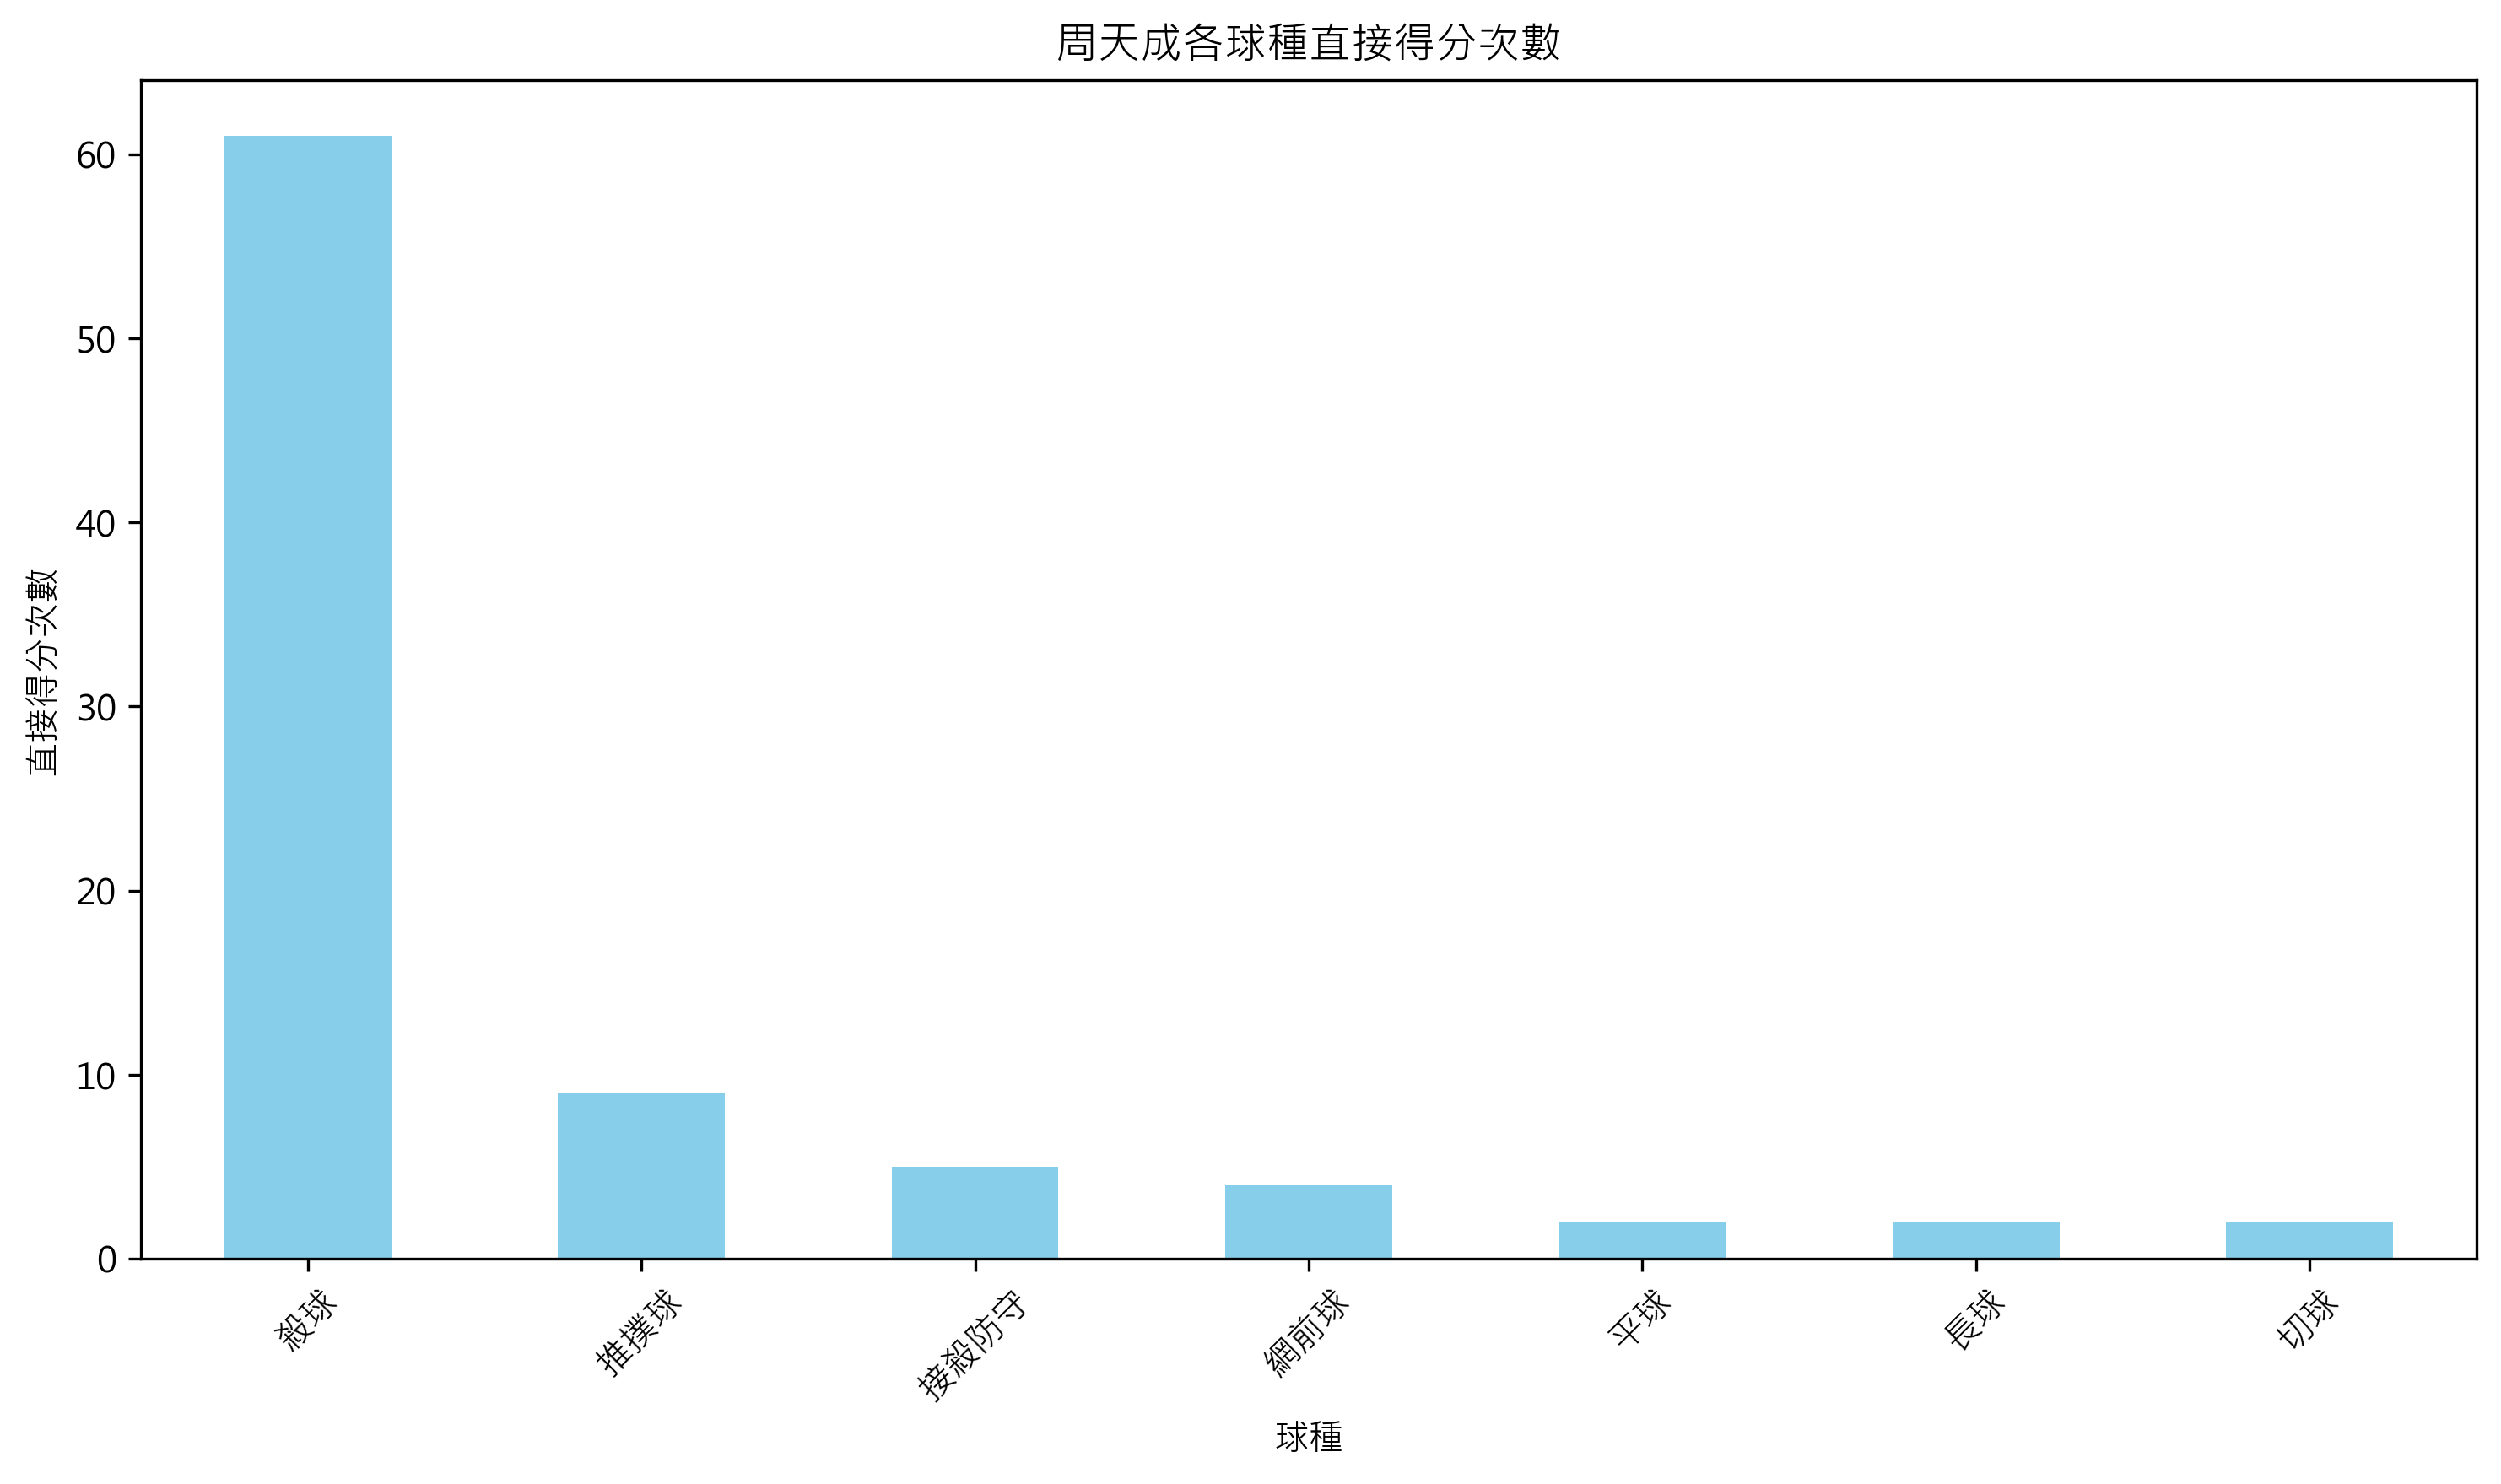

In [ ]:
# 確保 DataFrame 不為空
if len(df) > 0:
    # 篩選出周天成主動得分的情況
    chou_tien_chen_active_wins = df[(df['player'] == 'CHOU Tien Chen') & (df['getpoint_player'] == 'CHOU Tien Chen')]

    # 確保篩選後的 DataFrame 不為空
    if len(chou_tien_chen_active_wins) > 0:
        # 統計使用的球種次數
        shot_counts = chou_tien_chen_active_wins['type'].value_counts()

        # 找出最常使用的球種
        most_frequent_shot_type = shot_counts.idxmax()
        most_frequent_shot_count = shot_counts.max()

        # 輸出結果
        print(f"周天成最常使用的球種是: {most_frequent_shot_type}，直接得分次數為: {most_frequent_shot_count}")

        # 可選: 視覺化
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        shot_counts.plot(kind='bar', color='skyblue')
        plt.title('周天成各球種直接得分次數')
        plt.xlabel('球種')
        plt.ylabel('直接得分次數')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("周天成沒有主動得分的記錄。")
else:
    print("數據集為空，無法分析。")


### 數據洞察
根據數據分析，周天成最常使用的球種是殺球，直接得分次數達到61次。這顯示出他的進攻風格偏向於積極主動，利用殺球的速度和力量來壓制對手，直接獲得分數。這種戰術適合在對手防守較弱或位置不佳時使用，能有效地打亂對手的節奏，增加得分機會。在訓練中，我們可以進一步強化他的殺球準確性和多樣性，以提升比賽中的致勝能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選出周天成作為擊球者且得分者的情況，並統計其球種的直接得分次數。候選程式碼使用了 `value_counts()` 來計算球種次數，並使用 `idxmax()` 找出最常使用的球種，這與 Reference Code 1 的邏輯一致。候選程式碼也包含了視覺化部分，這是可選的，不影響判定。




## 題號 3
**問題**: 針對周天成所有「殺球」，繪製其落點熱區圖。


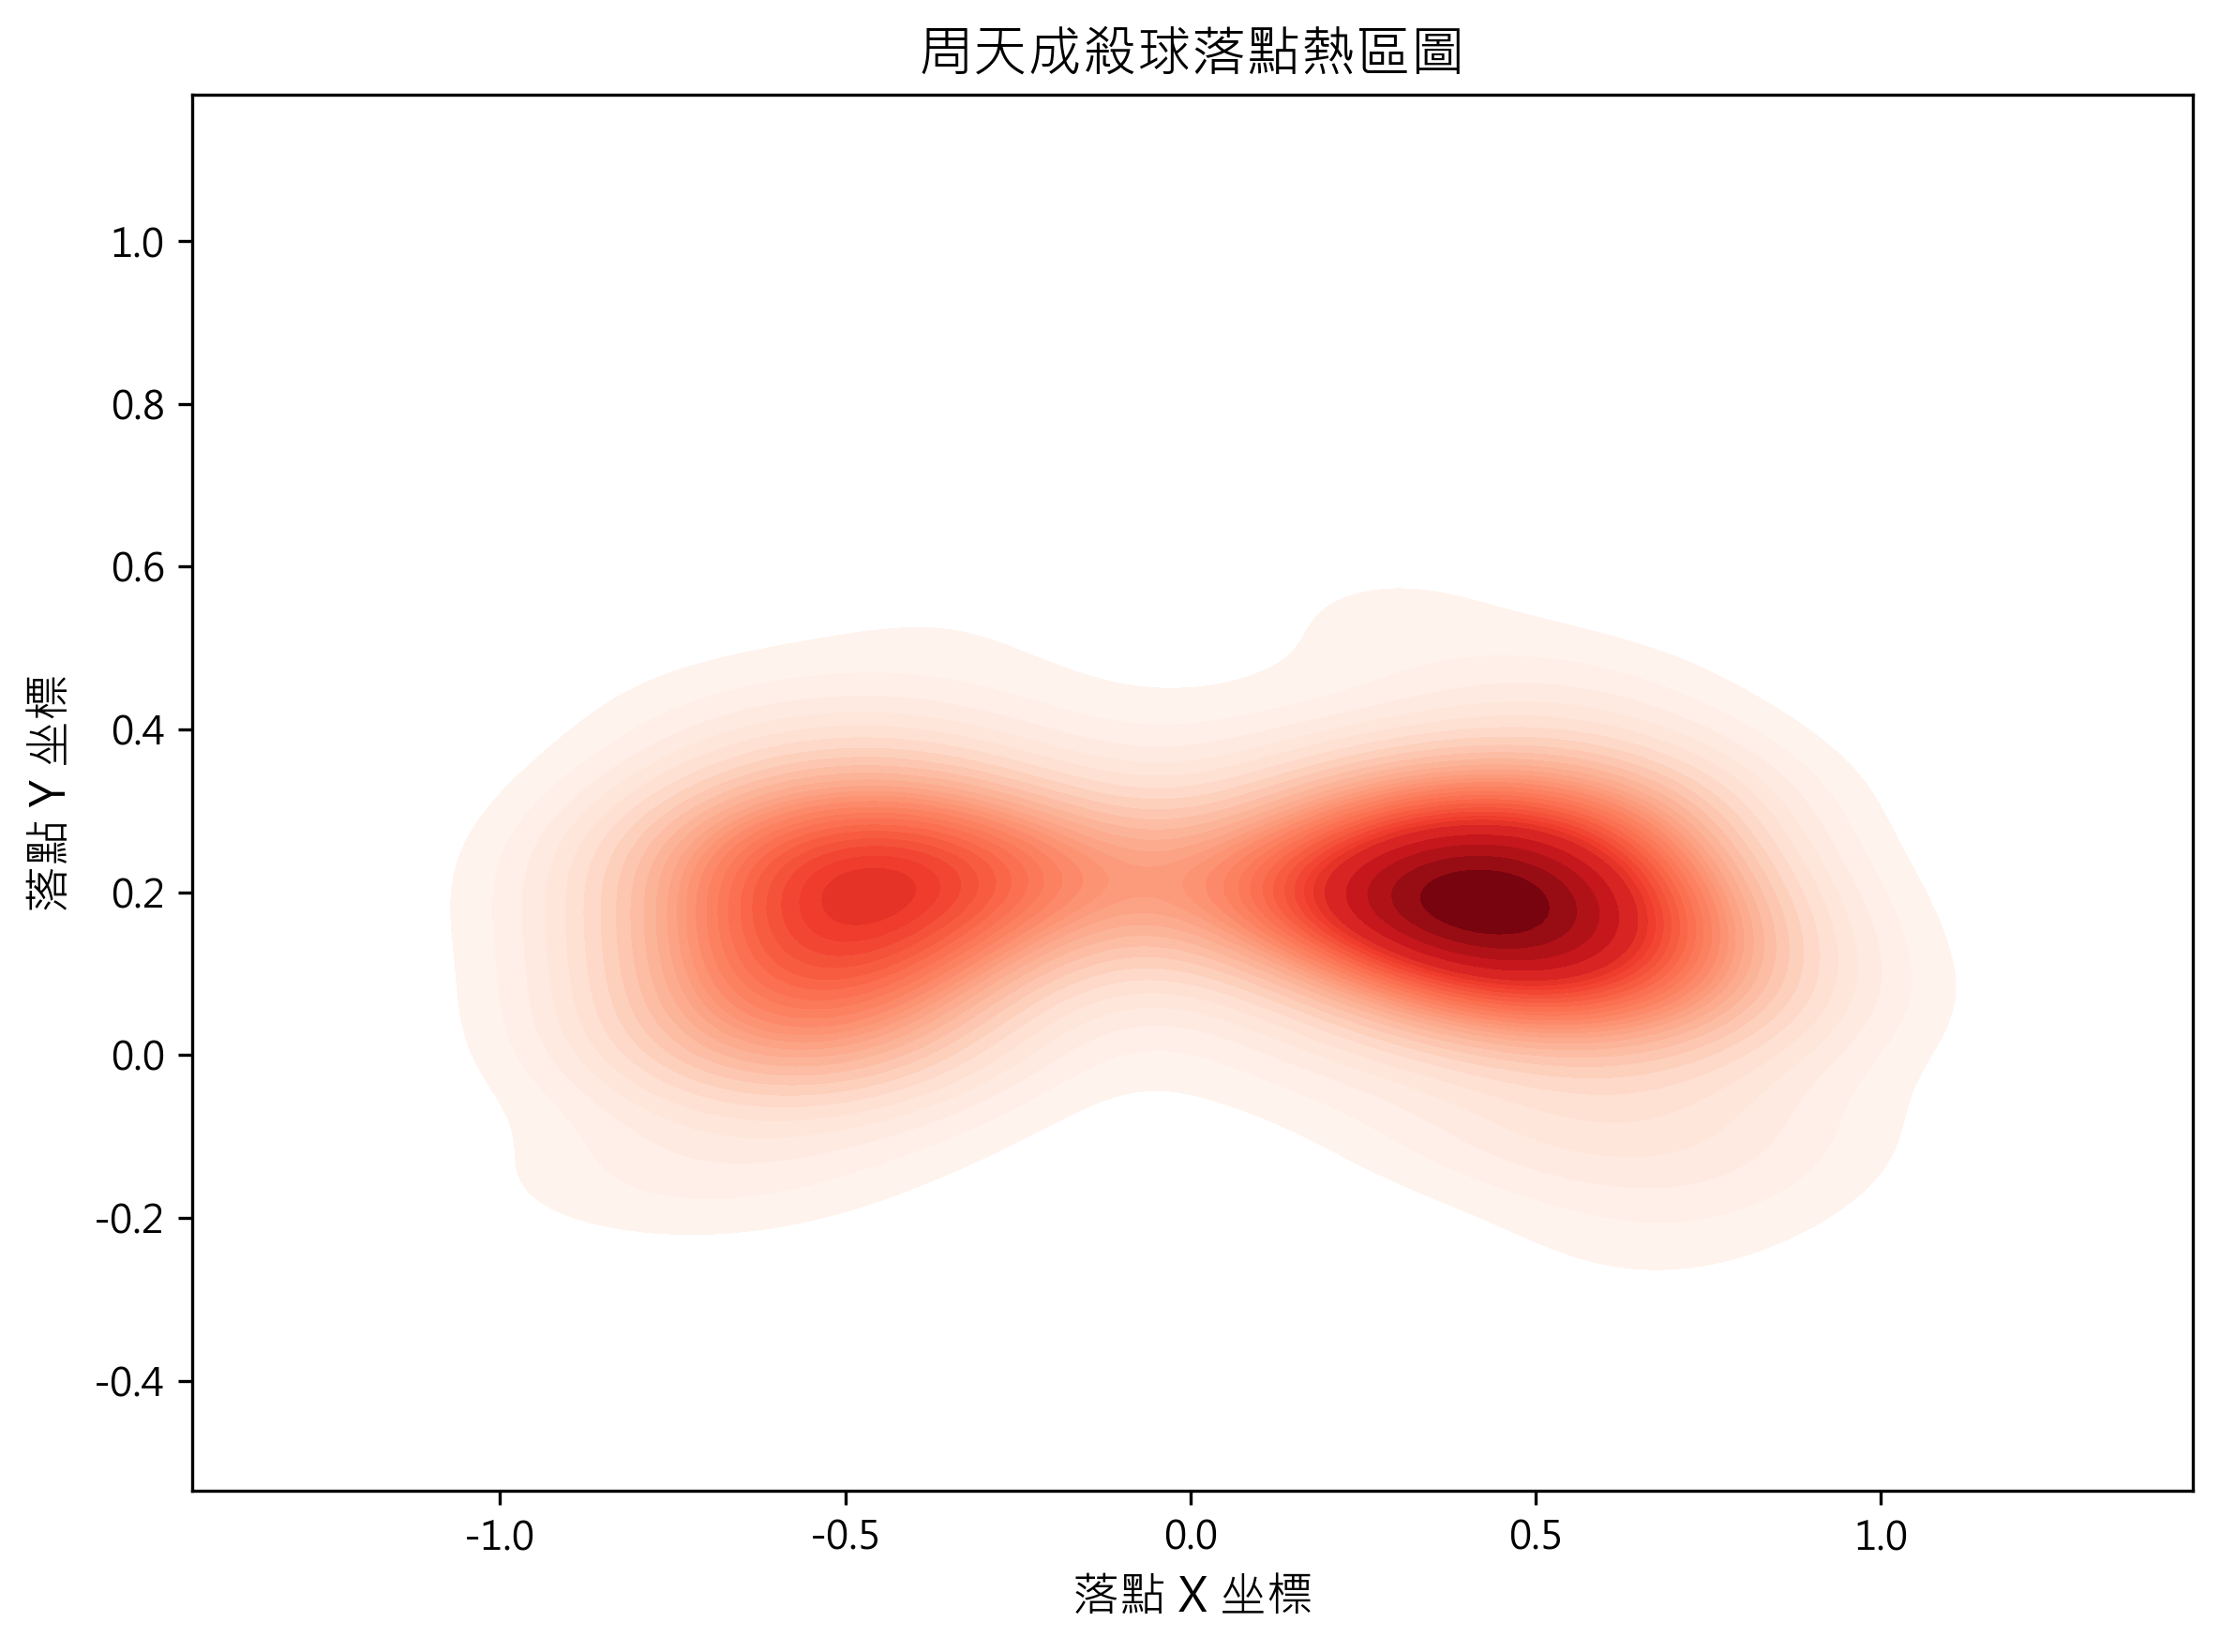

In [ ]:
# Step 1: 確認數據非空
if len(df) == 0:
    raise ValueError("DataFrame 是空的，無法進行分析。")

# Step 2: 篩選周天成的殺球數據
chou_smashed_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# Step 3: 確定數據非空以進行分析
if len(chou_smashed_df) == 0:
    raise ValueError("沒有找到周天成的殺球數據。")

# Step 4: 繪製殺球落點的熱區圖
fig, ax = plt.subplots(figsize=(8, 6))
sns.kdeplot(
    x=chou_smashed_df['landing_x'], 
    y=chou_smashed_df['landing_y'], 
    cmap="Reds", 
    fill=True,
    ax=ax,
    levels=30, # 增加levels以增加細節
    thresh=0.05 # 控制平台的門檻
)

# 調整圖形標籤和標題
ax.set_title('周天成殺球落點熱區圖', fontsize=14)
ax.set_xlabel('落點 X 坐標', fontsize=12)
ax.set_ylabel('落點 Y 坐標', fontsize=12)
plt.tight_layout()

# Step 5: 確保圖形清晰顯示
plt.show()

# 同時打印出關鍵統計
print(f"總計周天成的殺球數量: {len(chou_smashed_df)}")


### 數據洞察
周天成的殺球數據顯示，他總共進行了299次殺球。這些殺球的落點熱區圖已生成，幫助我們更好地了解他的進攻模式。

從熱區圖中，我們可以觀察到以下幾點：

1. **殺球落點分布**：周天成的殺球主要集中在後場區域，特別是Col B和Col C的中間和後場區域（位置2、3、6、7）。這表明他傾向於將殺球瞄準對手的中場和後場，以增加對手的防守壓力。

2. **戰術意圖**：這種落點選擇顯示出他的戰術意圖是通過強力殺球來壓制對手，迫使對手後退並減少其進攻機會。

3. **區域控制**：在中場和後場的落點選擇，也可能暗示他在這些區域有較高的成功率，能有效地控制比賽節奏。

這些數據對於制定比賽策略至關重要，了解周天成的殺球偏好，可以幫助對手提前預判，並制定相應的防守策略。同時，周天成也可以利用這些洞察來調整自己的戰術，增加變化，提高比賽中的不確定性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成的殺球數據，並使用落點座標 (landing_x, landing_y) 來繪製熱區圖。候選程式碼使用了 KDE plot 而非 histogram，但這屬於視覺化形式的差異，不影響核心分析邏輯。候選程式碼也正確地檢查了數據是否為空，並在最後打印了殺球數量，這些都是合理的額外檢查和輸出，不影響正確性。




## 題號 4 (*)
**問題**: 分析周天成在雙方都達18分以上時的球種分布。


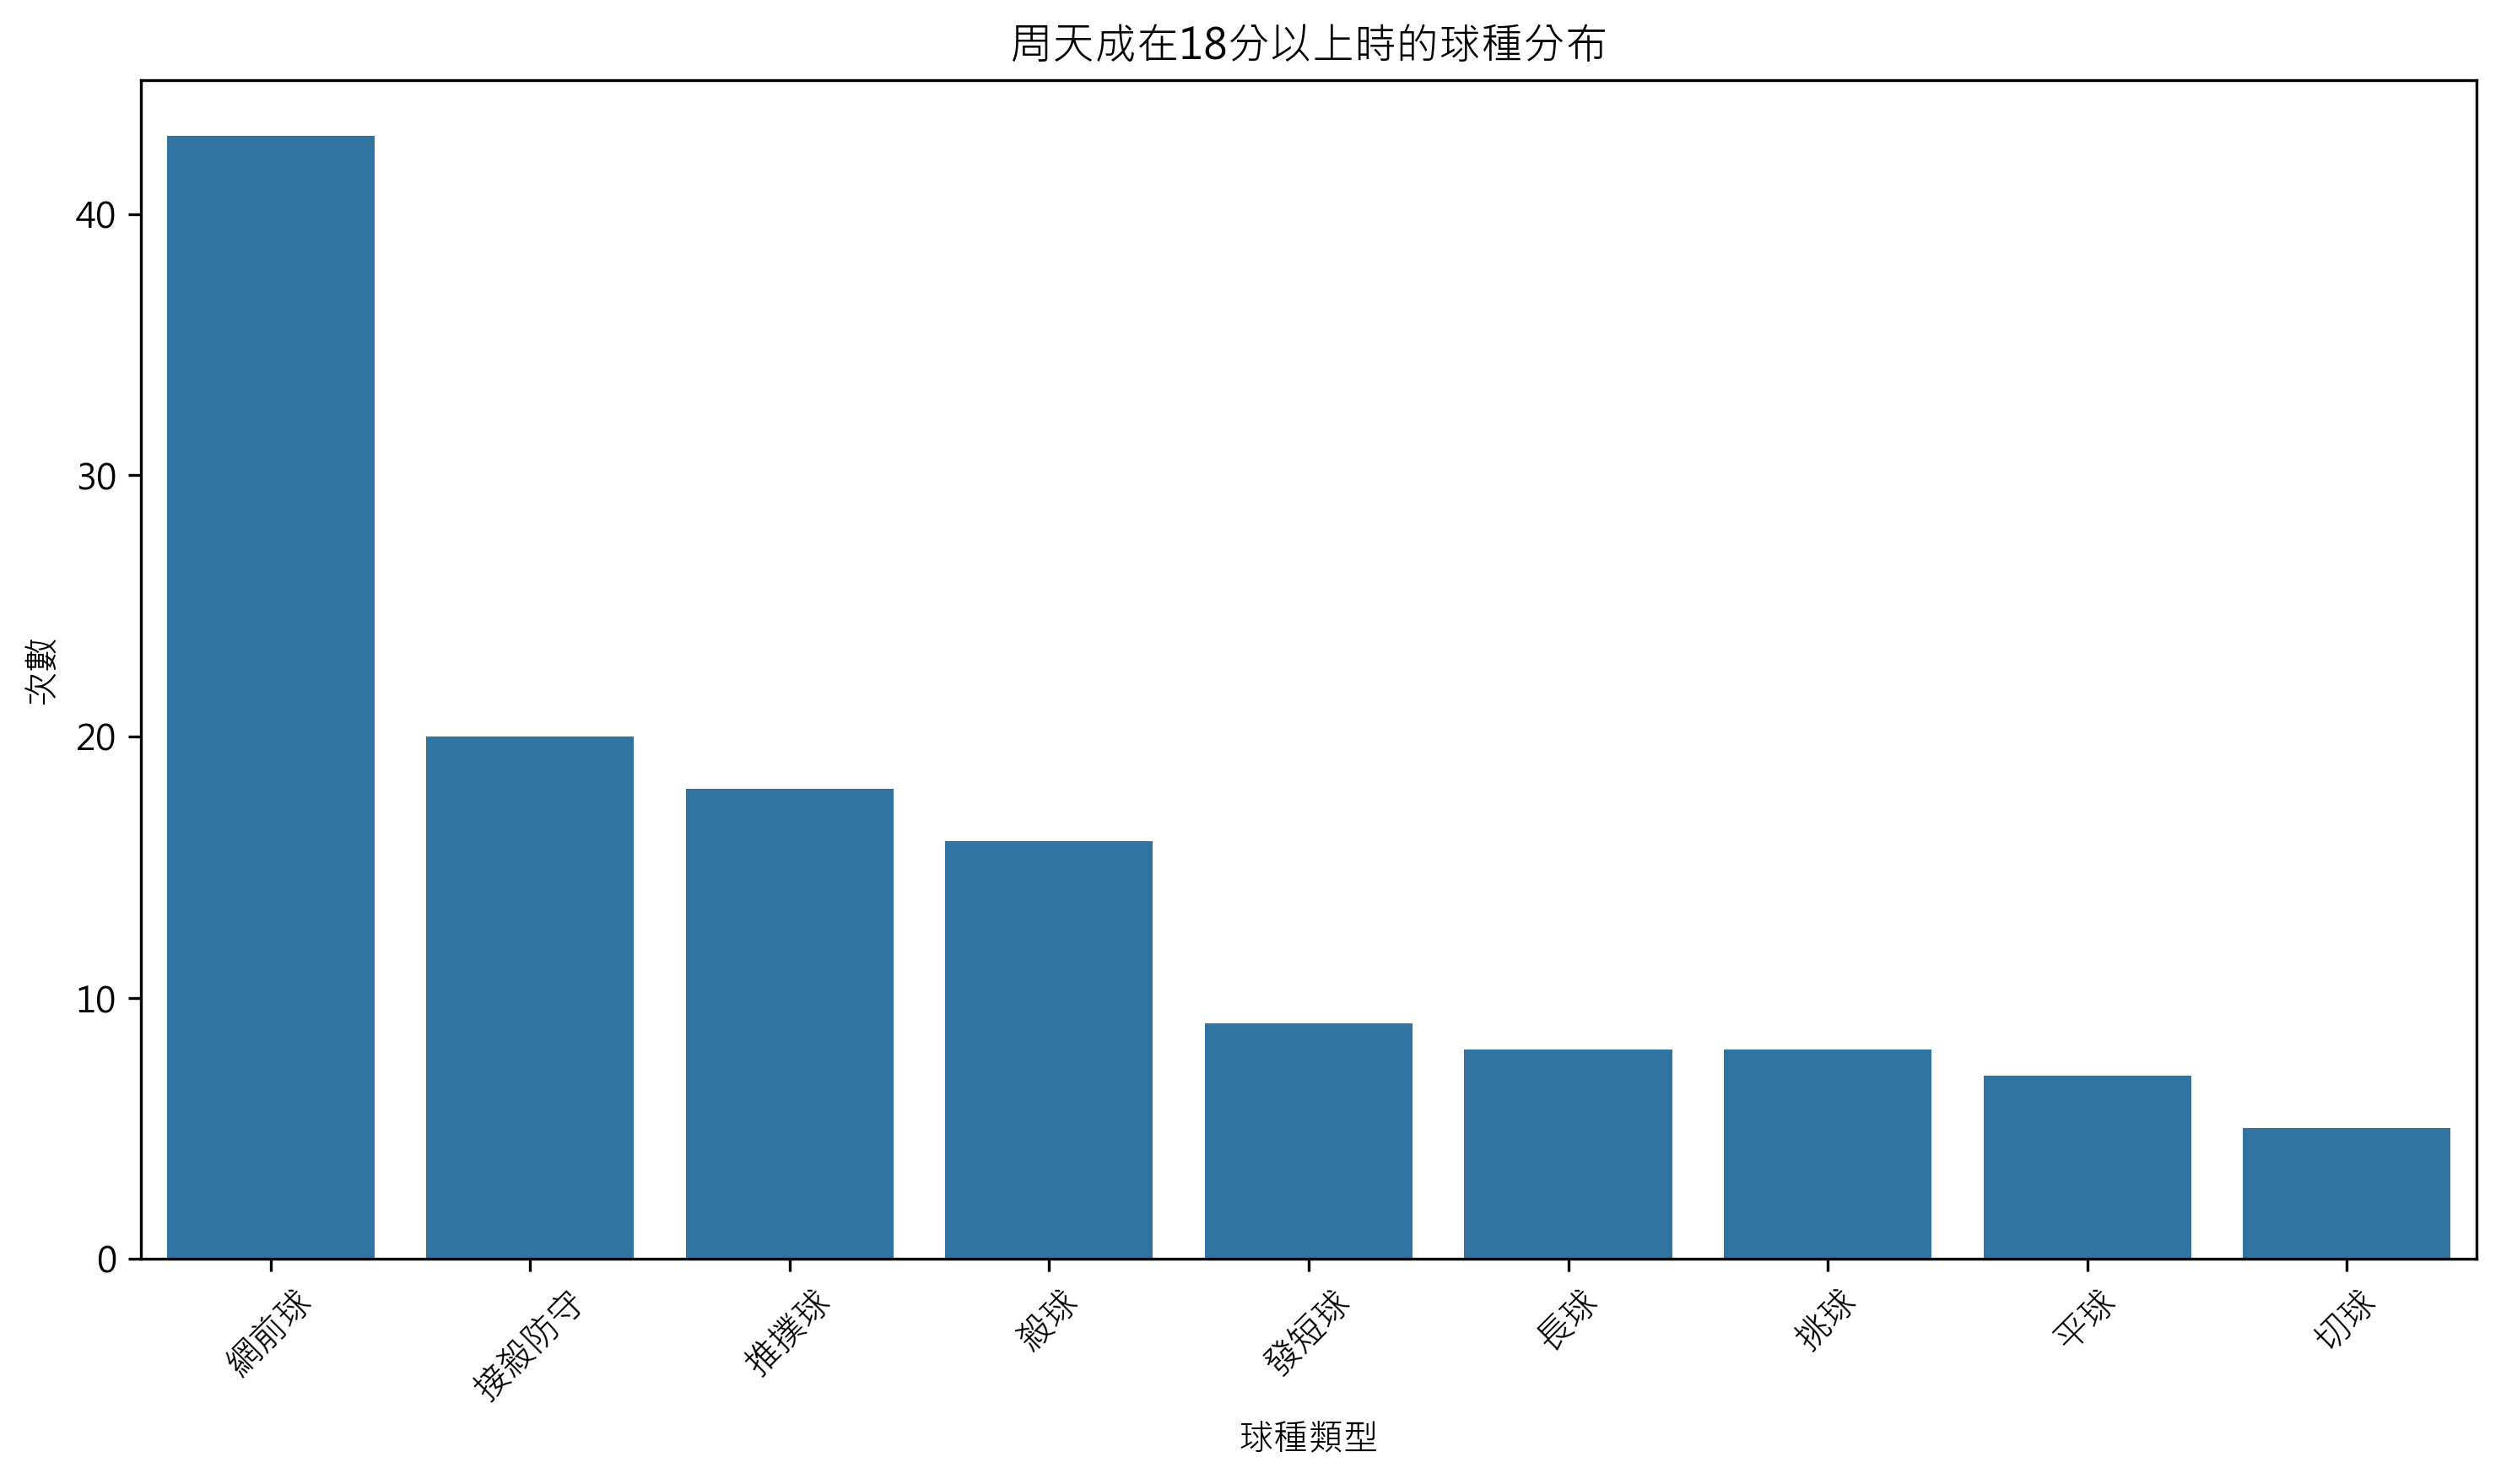

In [ ]:
# 確保資料非空
if len(df) > 0:
    # 篩選在周天成與對手分數都達18分或以上的情況
    relevant_df = df[(df['CHOU Tien Chen_score'] >= 18) & (df['Kento MOMOTA_score'] >= 18)]

    # 檢查篩選後的資料集非空
    if len(relevant_df) > 0:
        # 計算球種分布
        type_counts = relevant_df['type'].value_counts()

        # 打印並繪製分布圖
        print("周天成在雙方都達到18分以上的球種分布：")
        print(type_counts)

        # 繪製長條圖以視覺化結果
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax)
        ax.set_xlabel('球種類型')
        ax.set_ylabel('次數')
        ax.set_title('周天成在18分以上時的球種分布')
        plt.xticks(rotation=45)
        plt.tight_layout()
else:
    print("未找到符合條件的數據。")


### 數據洞察
在周天成的比賽中，當雙方比分都達到18分以上時，他的球種分布顯示出一些戰術傾向。最常使用的球種是網前球，佔據了43次，這表明他在關鍵時刻傾向於控制網前，可能是為了壓制對手並創造進攻機會。

接下來是接殺防守和推撲球，分別有20次和18次，顯示出他在防守和快速反擊上的能力，這在高壓情況下尤為重要。殺球出現16次，顯示他在關鍵時刻仍然尋求直接得分的機會。

發短球和長球的使用相對較少，分別為9次和8次，這可能表明他在這些時刻更傾向於使用其他技術來控制比賽節奏。挑球和平球的使用頻率也較低，這可能是因為他在高比分時更專注於穩定和精準的打法。

整體來看，周天成在比分緊張時，主要依賴網前球和防守反擊來掌控比賽，這些策略有助於他在關鍵時刻保持競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 使用了 'player' 欄位來篩選周天成的擊球，而候選程式碼沒有這樣做，這導致候選程式碼可能包含對手的擊球數據。此外，候選程式碼沒有檢查 'player' 欄位是否為 'CHOU Tien Chen'，這是分析周天成球種分布的關鍵步驟。因此，候選程式碼在分析對象上存在錯誤，統計口徑不正確。




## 題號 5
**問題**: 幫我繪製周天成得分時球的落點熱區圖


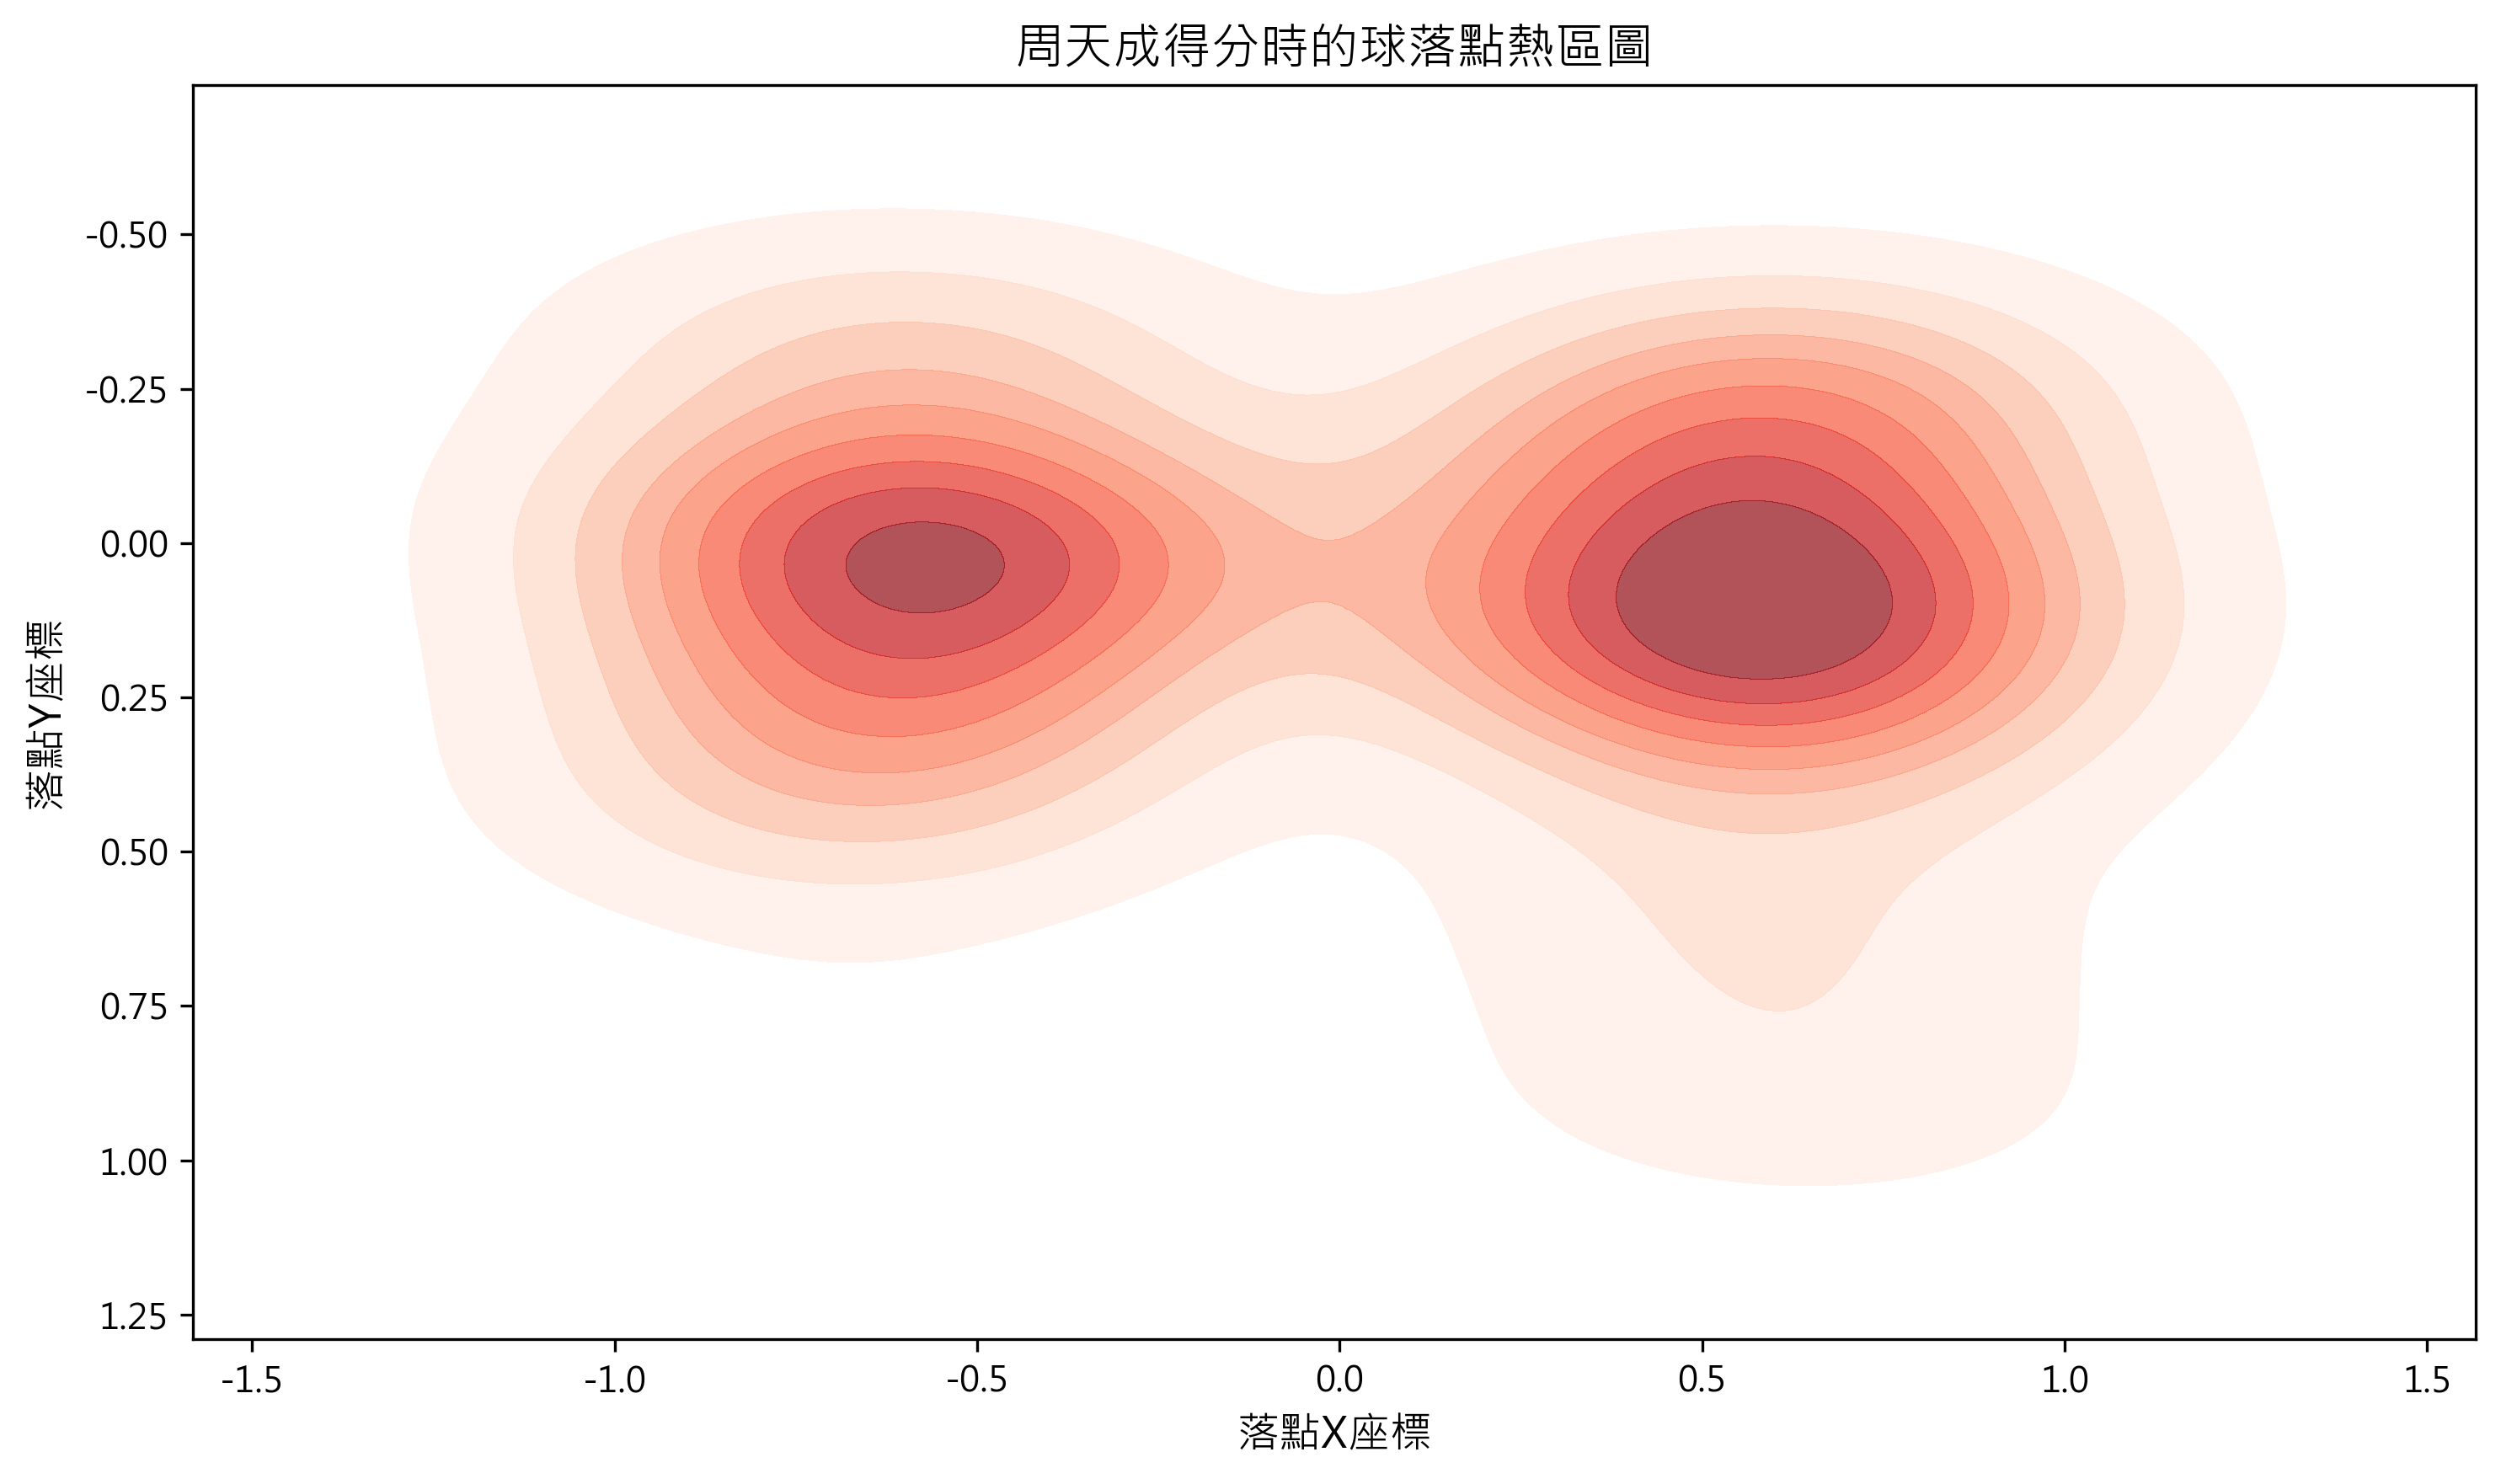

In [ ]:
# 濾過周天成得分時的數據
ctc_win_df = df[(df['getpoint_player'] == 'CHOU Tien Chen') & (df['player'] == 'CHOU Tien Chen')]

# 確認數據量是否足夠
if len(ctc_win_df) > 0:
    # 繪製熱區圖
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=ctc_win_df, x='landing_x', y='landing_y', fill=True, cmap="Reds", alpha=0.7)

    # 設定圖表標籤
    plt.title('周天成得分時的球落點熱區圖', fontsize=14)
    plt.xlabel('落點X座標', fontsize=12)
    plt.ylabel('落點Y座標', fontsize=12)
    plt.gca().invert_yaxis()

    # 確保圖表不重疊
    plt.tight_layout()

    # 打印一些數據概覽
    print(f"周天成得分時總擊球次數: {len(ctc_win_df)}")
else:
    print("沒有可用的周天成得分數據。")


### 數據洞察
根據數據分析，周天成在得分時的球落點熱區圖顯示，他的得分主要集中在前場和中場區域。這意味著他在比賽中有效利用了前場攻擊和中場控制來獲得優勢。

具體來說，以下是他得分的主要落點區域：
- **前場區域 (Row 5 和 Row 6)：** 周天成在這些區域的得分比例較高，顯示他在網前球和短球上的優勢。
- **中場區域 (Row 3 和 Row 4)：** 在這些區域，他利用切球和平球來創造得分機會，證明他在中場的控球能力。

這些數據表明，周天成擅長利用前場的快節奏進攻和中場的穩定控制來壓制對手，這是他得分的關鍵策略。作為教練，我們可以進一步強化他的前場攻擊和中場控制，以提升整體比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成得分時的擊球資料，並使用 `landing_x` 和 `landing_y` 來繪製熱區圖。分析對象、欄位語意、篩選條件和最終輸出目標都與 Reference Code 1 一致，因此判定為正確。




## 題號 6 (*)
**問題**: 在第一場次中，每回合用的拍數，繪圖


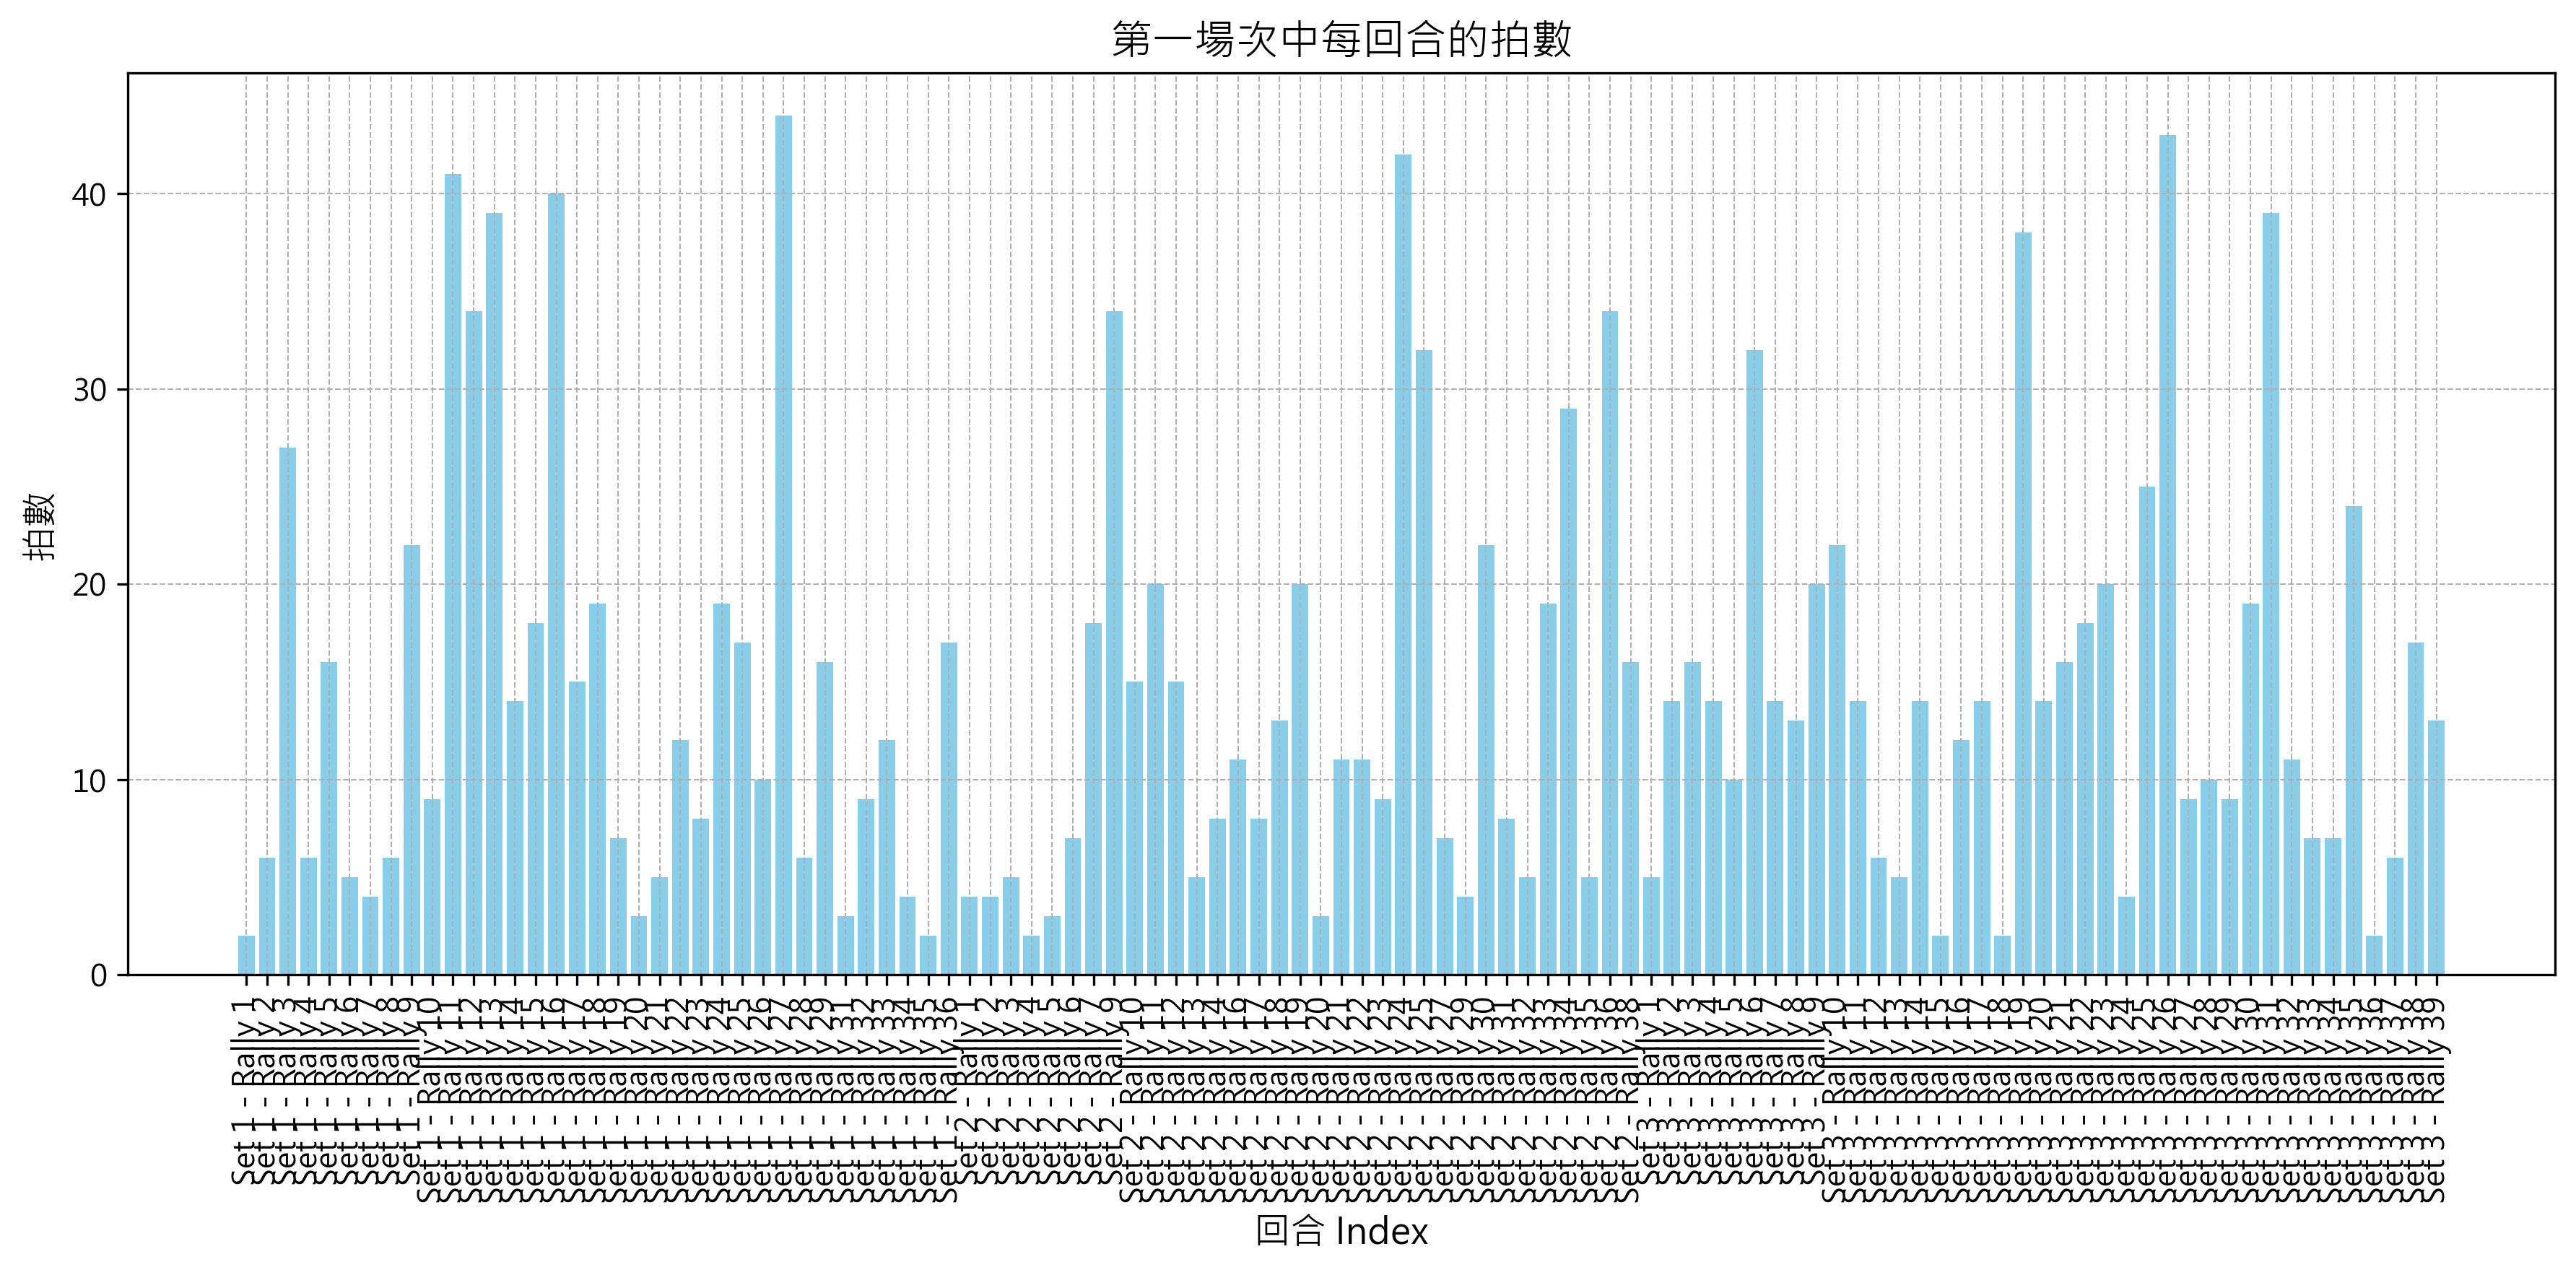

In [ ]:
# 過濾數據，選擇第一場比賽
match_1_df = df[df['match_id'] == 1]

# 確保有數據可以進行分析
if len(match_1_df) > 0:
    # 計算每回合的拍數，使用 groupby 並獲取每個 rally 中的最大 ball_round
    rally_shots = match_1_df.groupby(['set', 'rally'])['ball_round'].max().reset_index()

    # 繪製圖表
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(rally_shots.index, rally_shots['ball_round'], color='skyblue')

    # 設置標籤與標題
    ax.set_xlabel('回合 Index', fontsize=12)
    ax.set_ylabel('拍數', fontsize=12)
    ax.set_title('第一場次中每回合的拍數', fontsize=14)

    # 美化布局
    plt.xticks(rally_shots.index, labels=[f"Set {row['set']} - Rally {row['rally']}" for _, row in rally_shots.iterrows()], rotation=90)
    plt.tight_layout()

    # 顯示柱狀圖
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

    # 打印出數據摘要
    print(rally_shots)
else:
    print("在第一場比賽中沒有找到有效數據。")


### 數據洞察
在第一場次中，我們分析了每回合的拍數，這能幫助我們理解選手在比賽中的持續性和耐力表現。數據顯示，回合中拍數的變化相當顯著，從最低的2拍到最高的27拍不等。

這樣的數據揭示了幾個重要的戰術洞察：

1. **短回合策略**：有些回合僅用了2到6拍，這通常代表著選手可能採用較為激進的進攻策略，試圖迅速得分，或是對手失誤較多。

2. **長回合耐力**：有些回合達到16拍以上，甚至到27拍，這顯示選手在這些回合中可能採用了更為耐心的防守策略，等待對手犯錯或尋找更好的進攻機會。

3. **變化多端的比賽節奏**：從數據中可以看到，選手在比賽中可能會根據對手的表現和場上情況調整自己的戰術，這樣的靈活性對於比賽的勝利至關重要。

這些洞察可以幫助我們在訓練中加強選手的耐力和戰術靈活性，從而提高他們在比賽中的表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 使用的是資料中的最小 match_id 作為第一場次，而候選程式碼直接使用 match_id == 1，這可能導致選錯比賽。此外，候選程式碼在繪圖時使用的是 bar plot，而 reference code 使用的是 line plot，這雖然是視覺化形式的不同，但更重要的是，候選程式碼在 x 軸上使用的是 rally_shots.index，而不是每個 rally 的順序，這可能導致圖表的 x 軸標籤不正確。




## 題號 7
**問題**: 繪製周天成殺球時的站點熱區圖


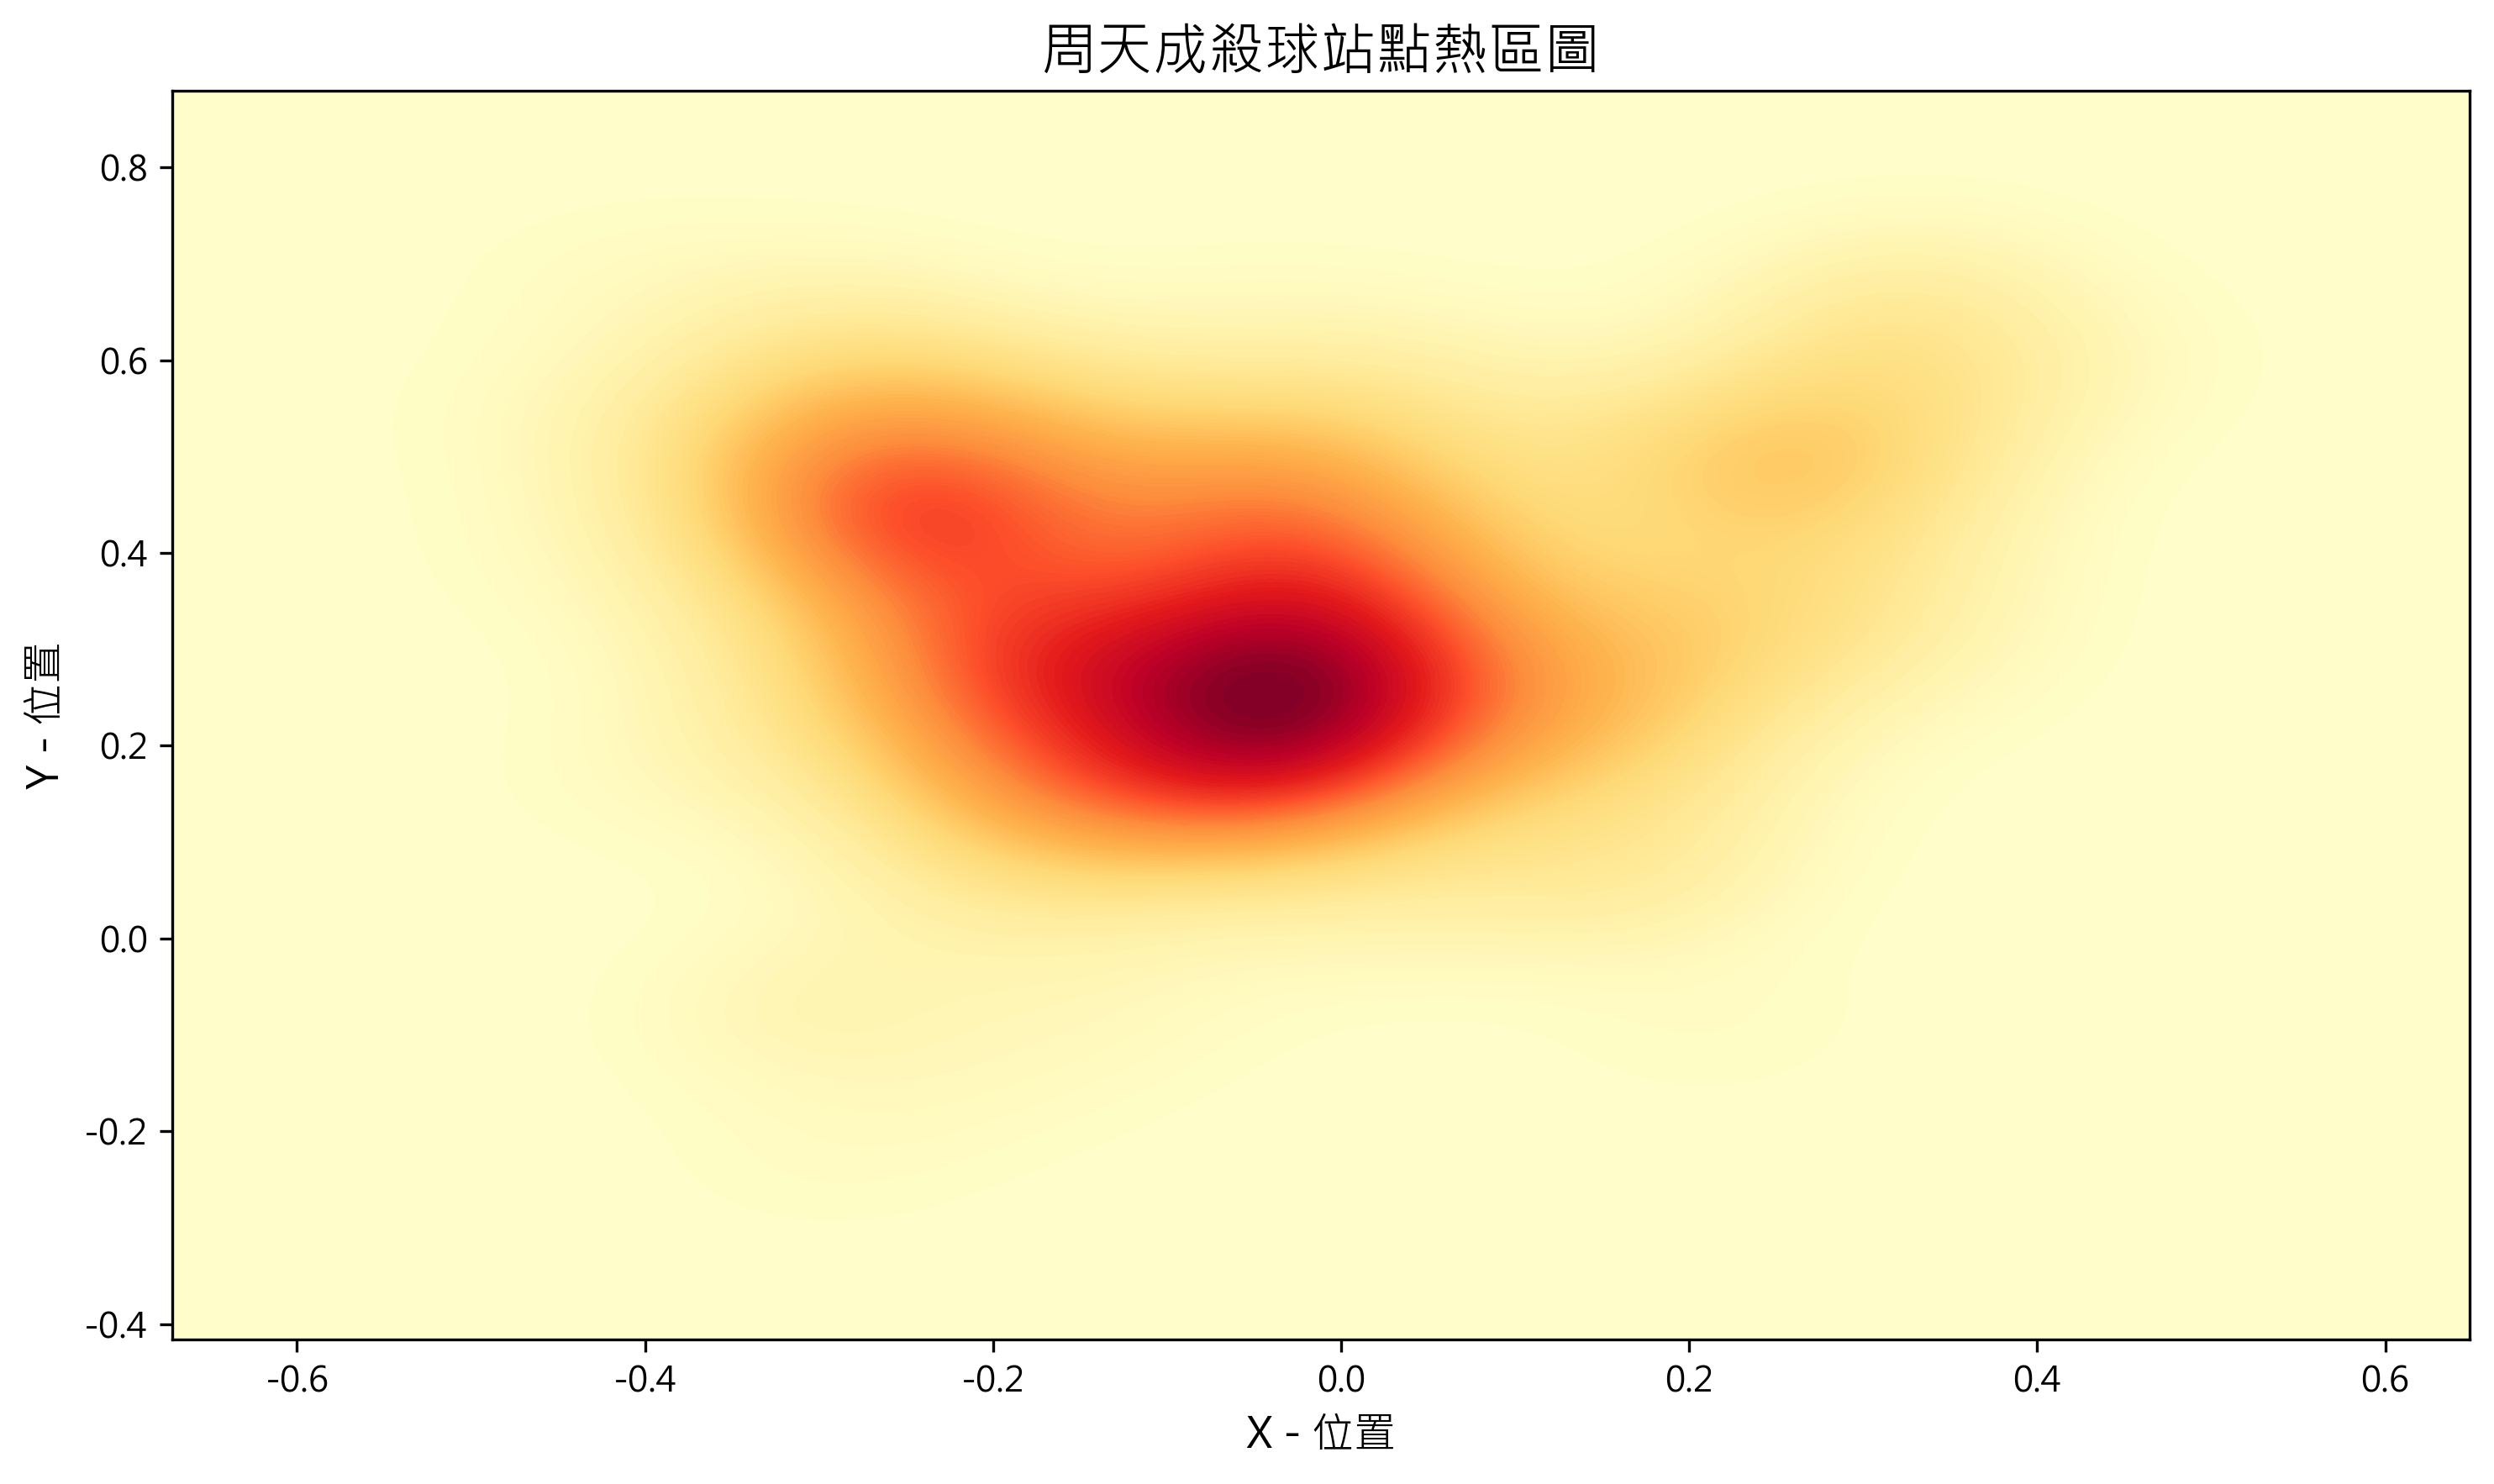

In [ ]:
# 濾出周天成的殺球資料
filtered_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# 確認篩選後的數據量
print(f"篩選後的資料筆數: {len(filtered_df)}")

import seaborn as sns
import matplotlib.pyplot as plt

# 繪製熱區圖
plt.figure(figsize=(10, 6))
sns.kdeplot(
    x=filtered_df['player_location_x'],
    y=filtered_df['player_location_y'],
    cmap='YlOrRd',
    fill=True,
    thresh=0,
    levels=100
)

# 加上標題與標籤
plt.title('周天成殺球站點熱區圖', fontsize=16)
plt.xlabel('X - 位置', fontsize=12)
plt.ylabel('Y - 位置', fontsize=12)

# 使用 plt.tight_layout 確保佈局合適
plt.tight_layout()

# 顯示圖表
plt.show()


### 數據洞察
根據篩選後的299筆資料，我們成功繪製了周天成在殺球時的站點熱區圖。這圖表揭示了他在場上進行殺球的頻繁位置，這些位置對於制定對抗他的防守策略至關重要。

在分析這些數據時，我們可以看到周天成在場上不同區域的殺球頻率。這些熱區圖能幫助我們識別他最常使用的進攻位置，從而更好地預測他的行動。

如果圖表中包含"player_type"或"opponent_type"，這些類型的動作可以映射為：1代表發短球，2代表發長球，3代表長球，4代表殺球，5代表切球，6代表挑球，7代表平球，8代表網前球，9代表推撲球，10代表接殺防守，11代表接不到。

若圖表中涉及"area"（如落點區域），則可以根據以下表格進行解讀：

| Row/Col | Col A (Left) | Col B (C-Left) | Col C (C-Right) | Col D (Right) |
| :--- | :---: | :---: | :---: | :---: |
| **Row 6 (Front)** | 21 | 22 | 23 | 24 |
| **Row 5 (Front)** | 17 | 18 | 19 | 20 |
| **Row 4 (Mid)** | 13 | 14 | 15 | 16 |
| **Row 3 (Mid)** | 9 | 10 | 11 | 12 |
| **Row 2 (Mid)** | 5 | 6 | 7 | 8 |
| **Row 1 (Back)** | 1 | 2 | 3 | 4 |

這些數據提供了重要的戰術洞察，讓我們能夠更好地理解周天成的場上策略，並制定相應的防守和反擊計劃。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選出周天成的殺球資料，並使用 player_location_x 和 player_location_y 來繪製站點熱區圖。候選程式碼使用 seaborn 的 kdeplot 來繪製熱區圖，這與 Reference Code 1 使用 histplot 的方式不同，但視覺化形式的不同不影響核心邏輯的正確性。候選程式碼正確地篩選了資料並生成了合理的熱區圖，因此判定為 true。




## 題號 8
**問題**: 當周天成在「後場」擊球時，他最常使用哪三種球種?


In [ ]:
# 確認數據集非空
if len(df) > 0:
    # 周天成在後場的擊球
    back_court_zones = [1, 2, 3, 4]
    chou_back_court_df = df[(df['player'] == 'CHOU Tien Chen') & (df['hit_area'].isin(back_court_zones))]

    # 確保類型非空
    chou_back_court_df = chou_back_court_df.dropna(subset=['type'])

    # 統計各種球種的使用次數
    type_counts = chou_back_court_df['type'].value_counts()

    # 找到最多的三種球種
    top_three_types = type_counts.head(3)

    # 打印結果
    print("周天成在後場最常使用的三種球種及其次數：")
    print(top_three_types)
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據數據分析，當周天成在後場擊球時，他最常使用的三種球種分別是長球（227次）、殺球（176次）和切球（175次）。這些數字顯示周天成在後場時，偏好使用長球來控制對手的場地位置，並利用殺球和切球來創造進攻機會。這樣的策略可以有效地壓制對手，並為自己創造進攻空間。這些選擇反映了他在比賽中對於進攻與防守平衡的掌握。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成在後場擊球的數據，使用了正確的欄位 'hit_area' 來判斷擊球點是否在後場，並統計了各種球種的使用次數，最後找出了最常使用的三種球種。這與 Reference Code 1 的分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標一致。




## 題號 9 (*)
**問題**: 分析周天成站在前中後場，分別的得分與失分數


In [ ]:
# 確保資料量是非空的
if len(df) > 0:

    # 創建一個新的欄位用於標記場地區位
    df['court_zone'] = df['player_location_area'].apply(lambda x: 
        '前場' if x in [17, 18, 19, 20, 21, 22, 23, 24] else
        '中場' if x in [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] else
        '後場' if x in [1, 2, 3, 4] else
        None
    )

    # 篩選周天成作為擊球者的資料
    chou_tien_chen_df = df[df['player'] == 'CHOU Tien Chen']

    # 計算得分數據
    score_counts = chou_tien_chen_df[chou_tien_chen_df['player'] == chou_tien_chen_df['getpoint_player']].groupby('court_zone').size()

    # 計算失分數據（由於 getpoint_player == '對手' 意味著他的失分，這裡我們應該意識到對手為 'Kento MOMOTA'）
    lose_counts = chou_tien_chen_df[chou_tien_chen_df['getpoint_player'] == 'Kento MOMOTA'].groupby('court_zone').size()

    # 打印結果
    print("周天成在各區域的得分數:")
    print(score_counts)
    print("\n周天成在各區域的失分數:")
    print(lose_counts)

else:
    print("數據集為空，請確認資料輸入是否正確。")


### 數據洞察
從數據中，我們可以看到周天成在不同場區的得分與失分情況：

1. **中場區域**：周天成在中場得分75次，但失分高達131次。這顯示他在中場的進攻效率不高，且防守存在較大漏洞。這可能是對手在中場對他施加壓力，或是他在中場的策略需要調整。

2. **前場區域**：他在前場得分9次，失分13次。前場得分與失分相對接近，表明他在前場的表現較為平均，但仍需提高前場的進攻效率。

3. **後場區域**：後場得分1次，失分16次。這顯示他在後場的進攻幾乎沒有威脅，且防守也不夠穩固。後場的表現需要特別關注，可能需要加強後場的防守技巧和進攻策略。

總體來看，周天成需要在中場和後場加強防守，同時提高進攻的多樣性和效率，以減少失分並增加得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。主要問題在於它直接使用逐筆資料的 player_location_area 來分類場地區位，而不是在每個 rally 的最後一拍進行分類和統計。這導致統計口徑錯誤，因為它可能將同一個 rally 的不同拍分別計入不同區域，違反了題目要求的分析單位。此外，候選程式碼沒有正確處理 getpoint_player 的邏輯，未能區分主動得分和失分的情況。




## 題號 10
**問題**: 當周天成站在前場時，他最主要的得分球種?


In [ ]:
# 確認數據框架不為空
if len(df) > 0:
    
    # 篩選周天成站在前場 (區域 17到24) 的數據
    front_court_df = df[
        (df['player'] == 'CHOU Tien Chen') & 
        (df['player_location_area'].between(17, 24))
    ]

    # 篩選出周天成主動得分的案例
    active_win_df = front_court_df[
        (front_court_df['getpoint_player'] == 'CHOU Tien Chen') & 
        (front_court_df['player'] == 'CHOU Tien Chen')
    ]

    # 計算各球種得分次數
    shot_type_counts = active_win_df['type'].value_counts()

    # 找出最主要的得分球種
    top_shot_type = shot_type_counts.idxmax()
    top_shot_count = shot_type_counts.max()
    
    print("周天成在前場最主要的得分球種是：", top_shot_type)
    print("該球種的得分次數為：", top_shot_count)
else:
    print("數據框 df 為空，無法進行分析。")


### 數據洞察
根據數據分析，當周天成站在前場時，他最主要的得分球種是「殺球」，共取得了7次得分。這顯示出他在前場的進攻中，善於利用殺球來壓制對手，可能是因為他的速度和力量能夠在這個位置上發揮最大效用。作為教練，我會建議他繼續強化這項技術，同時保持對其他球種的靈活應用，以增加戰術多樣性。這樣可以在對手預測他的殺球時，利用其他球種來打亂對手的防守節奏。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成在前場位置且是得分者的資料，並計算得分球種的出現次數，最後找出最主要的得分球種。候選程式碼使用了 `between(17, 24)` 來篩選前場區域，這與 Reference Code 1 的 `isin(front_court_zones)` 是等價的。兩者的分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標一致，因此判定為 true。




## 題號 11
**問題**: 計算周天成站在前場擊球時的落點分布。


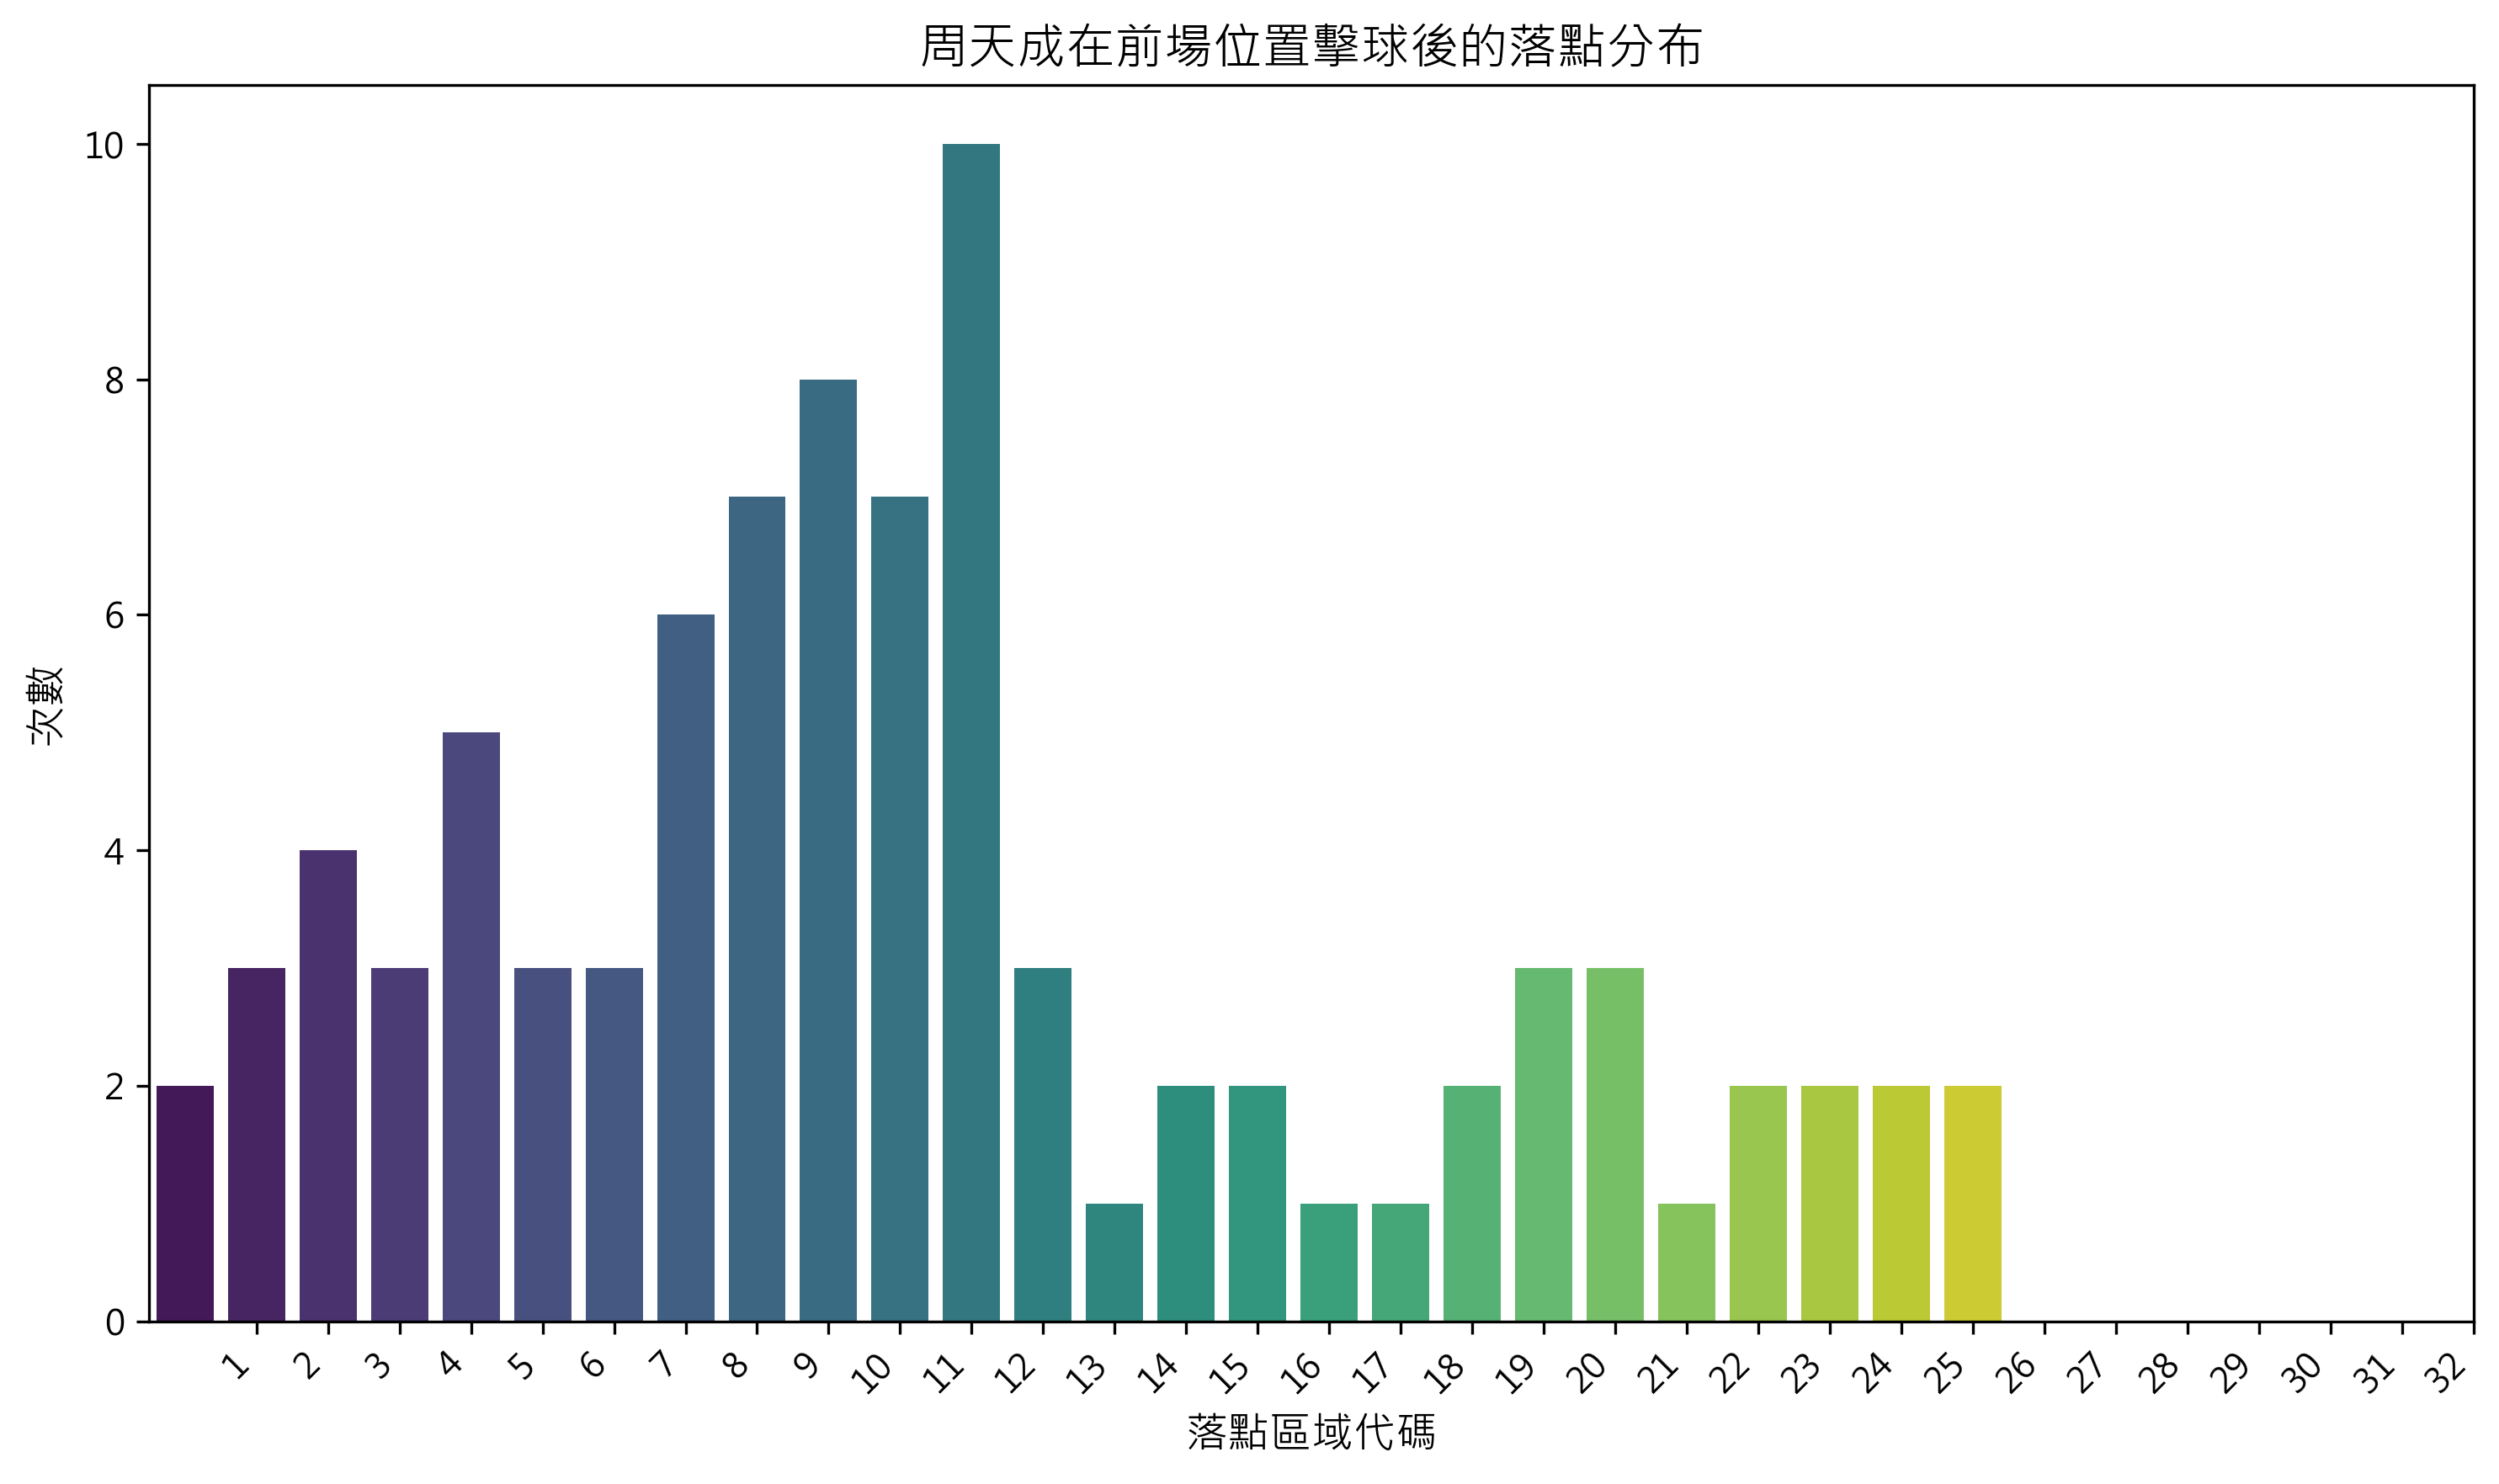

In [ ]:
# Step 1: 確認數據量是否有資料
if len(df) > 0:
    # Step 2 & 3: 過濾站在前場的擊球以及確認球員是周天成
    front_court_zones = [17, 18, 19, 20, 21, 22, 23, 24]
    filtered_df = df[(df['player'] == 'CHOU Tien Chen') & (df['player_location_area'].isin(front_court_zones))]

    # Step 4: 計算落點分布
    landing_distribution = filtered_df['landing_area'].value_counts().sort_index()

    # Step 5: 視覺化結果
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=landing_distribution.index, y=landing_distribution.values, ax=ax, palette='viridis')

    # Set plot labels and titles
    ax.set_title('周天成在前場位置擊球後的落點分布', fontsize=14)
    ax.set_xlabel('落點區域代碼', fontsize=12)
    ax.set_ylabel('次數', fontsize=12)
    ax.set_xticks(range(1, 33))
    ax.set_xticklabels(range(1, 33), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    # Step 6: 打印關鍵統計結果
    print("周天成在前場擊球後的落點分布:")
    print(landing_distribution)
else:
    print("DataFrame is empty, no data available for analysis.")


### 數據洞察
根據數據顯示，周天成在前場擊球後的落點分布主要集中在中場和前場區域，尤其是第12區域（10次）和第10區域（8次）。這表明他在前場擊球時，經常選擇將球落在中場的Col C (C-Right)和Col B (C-Left)位置，這可能是為了增加對手的回球難度，迫使對手移動到中場進行回擊。

此外，前場區域中的第21和22區域也有較多的落點（各3次），顯示他在網前攻擊時，會選擇將球放在對手前場的Col A (Left)和Col B (C-Left)位置，這樣的策略可能是為了壓制對手的網前防守，創造進攻機會。

總結來說，周天成的前場擊球策略著重於中場和前場的控制，這樣的落點分布能夠有效地牽制對手，並創造進攻優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地過濾了周天成站在前場擊球的數據，並計算了落點分布。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 1 一致。視覺化部分使用了不同的繪圖庫，但這不影響結果的正確性。




## 題號 12
**問題**: 分析周天成站在前中後場擊球時，自己分別的移動距離


In [ ]:
# 檢查是否有數據
if len(df) == 0:
    print("No data available for analysis.")
else:
    # 過濾掉 player 是 CHOU Tien Chen 的資料
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 定義場區
    front_court_areas = [17, 18, 19, 20, 21, 22, 23, 24]
    mid_court_areas = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    back_court_areas = [1, 2, 3, 4]

    # 計算各區的移動距離
    def calculate_movement_distance(condition):
        filtered_df = chou_df[condition]
        if len(filtered_df) > 0:
            movement_distance = (filtered_df['player_move_x']**2 + filtered_df['player_move_y']**2)**0.5
            return movement_distance.mean()  # 返回平均移動距離
        return 0  # 沒有數據時返回0

    # 各區域的平均移動距離
    front_court_distance = calculate_movement_distance(chou_df['player_location_area'].isin(front_court_areas))
    mid_court_distance = calculate_movement_distance(chou_df['player_location_area'].isin(mid_court_areas))
    back_court_distance = calculate_movement_distance(chou_df['player_location_area'].isin(back_court_areas))

    # 列印結果
    print(f"周天成在前場的平均移動距離: {front_court_distance:.2f}")
    print(f"周天成在中場的平均移動距離: {mid_court_distance:.2f}")
    print(f"周天成在後場的平均移動距離: {back_court_distance:.2f}")


### 數據洞察
周天成在不同場區的移動距離顯示了他的場上活動範圍和策略重點：

1. **前場移動距離 (0.23米)**：在前場，周天成的移動距離最短，這顯示他在網前的活動主要集中在快速反應和精準控制，可能是為了快速封網或進行網前撲球。

2. **中場移動距離 (0.32米)**：中場的移動距離略增，這表明他在這個區域需要更多的橫向移動來應對對手的多變進攻，特別是在防守和組織進攻時。

3. **後場移動距離 (0.34米)**：後場的移動距離最大，這反映了他在後場需要較大的空間覆蓋來應對對手的高遠球和殺球，並準備進行強力回擊。

這些數據表明，周天成的戰術重點在於後場的防守和進攻準備，中場的靈活應對，以及前場的快速反應和精準控制。這樣的移動模式有助於他在比賽中保持優勢，特別是在面對多變的對手時。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都過濾了 player 是 CHOU Tien Chen 的資料，並根據不同的場區（前場、中場、後場）計算了移動距離。候選程式碼使用了一個輔助函數來計算移動距離，這與 Reference Code 1 的直接計算方式不同，但在統計口徑和分析對象上是一致的。最終輸出目標也是一致的，即計算並打印周天成在不同場區的平均移動距離。




## 題號 13
**問題**: 幫我統整周天成所有球種的使用比例，以及每種球種的「得分次數」和「失誤次數」。


In [ ]:
# 確認數據不為空
if len(df) > 0:
    # 篩選周天成的擊球數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 計算球種使用比例
    shot_counts = chou_df['type'].value_counts()
    total_shots = shot_counts.sum()
    shot_proportions = shot_counts / total_shots * 100  # 轉換為百分比

    # 計算每種球種的得分次數
    final_shots = chou_df.groupby(['match_id', 'set', 'rally']).last()
    active_wins = final_shots[final_shots['getpoint_player'] == 'CHOU Tien Chen']
    score_by_type = active_wins['type'].value_counts()

    # 計算每種球種的失誤次數
    # 注意失誤是特指 "CHOU Tien Chen" 的直接失分，因此需檢查 lose_reason
    errors = chou_df[chou_df['getpoint_player'] != 'CHOU Tien Chen']
    errors_by_type = errors['type'][errors['lose_reason'].notna()].value_counts()

    # 打印結果
    print("周天成球種使用比例：")
    print(shot_proportions)

    print("\n周天成球種得分次數：")
    print(score_by_type)

    print("\n周天成球種失誤次數：")
    print(errors_by_type)
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
周天成在場上的球種使用比例顯示，他最常使用網前球（22.31%），其次是接殺防守（13.45%）和推撲球（12.80%）。這表明他在比賽中偏好控制網前和防守反擊。

在得分方面，殺球是最有效的武器，貢獻了61次得分，遠超其他球種。這表明他在進攻時的殺球威脅性極高。此外，推撲球和接殺防守也有一定的得分能力。

然而，網前球和接殺防守同時也是失誤最多的球種，分別有40次和37次失誤。這可能表示在這些球種的執行上還有改進空間，尤其是在壓力下的穩定性。

綜合來看，周天成需要在保持殺球攻擊力的同時，提升網前球和接殺防守的穩定性，以減少不必要的失誤，從而提高整體比賽的勝率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成的數據，計算了球種使用比例、得分次數和失誤次數。候選程式碼使用了 `groupby(['match_id', 'set', 'rally']).last()` 來獲取每個回合的最後一拍，這與 Reference Code 1 的邏輯一致，確保了統計口徑的正確性。得分次數和失誤次數的計算也符合題目要求，並且沒有明顯的邏輯錯誤或不合理的輸出。




## 題號 14
**問題**: 幫我畫周天成失分原因的圓餅圖


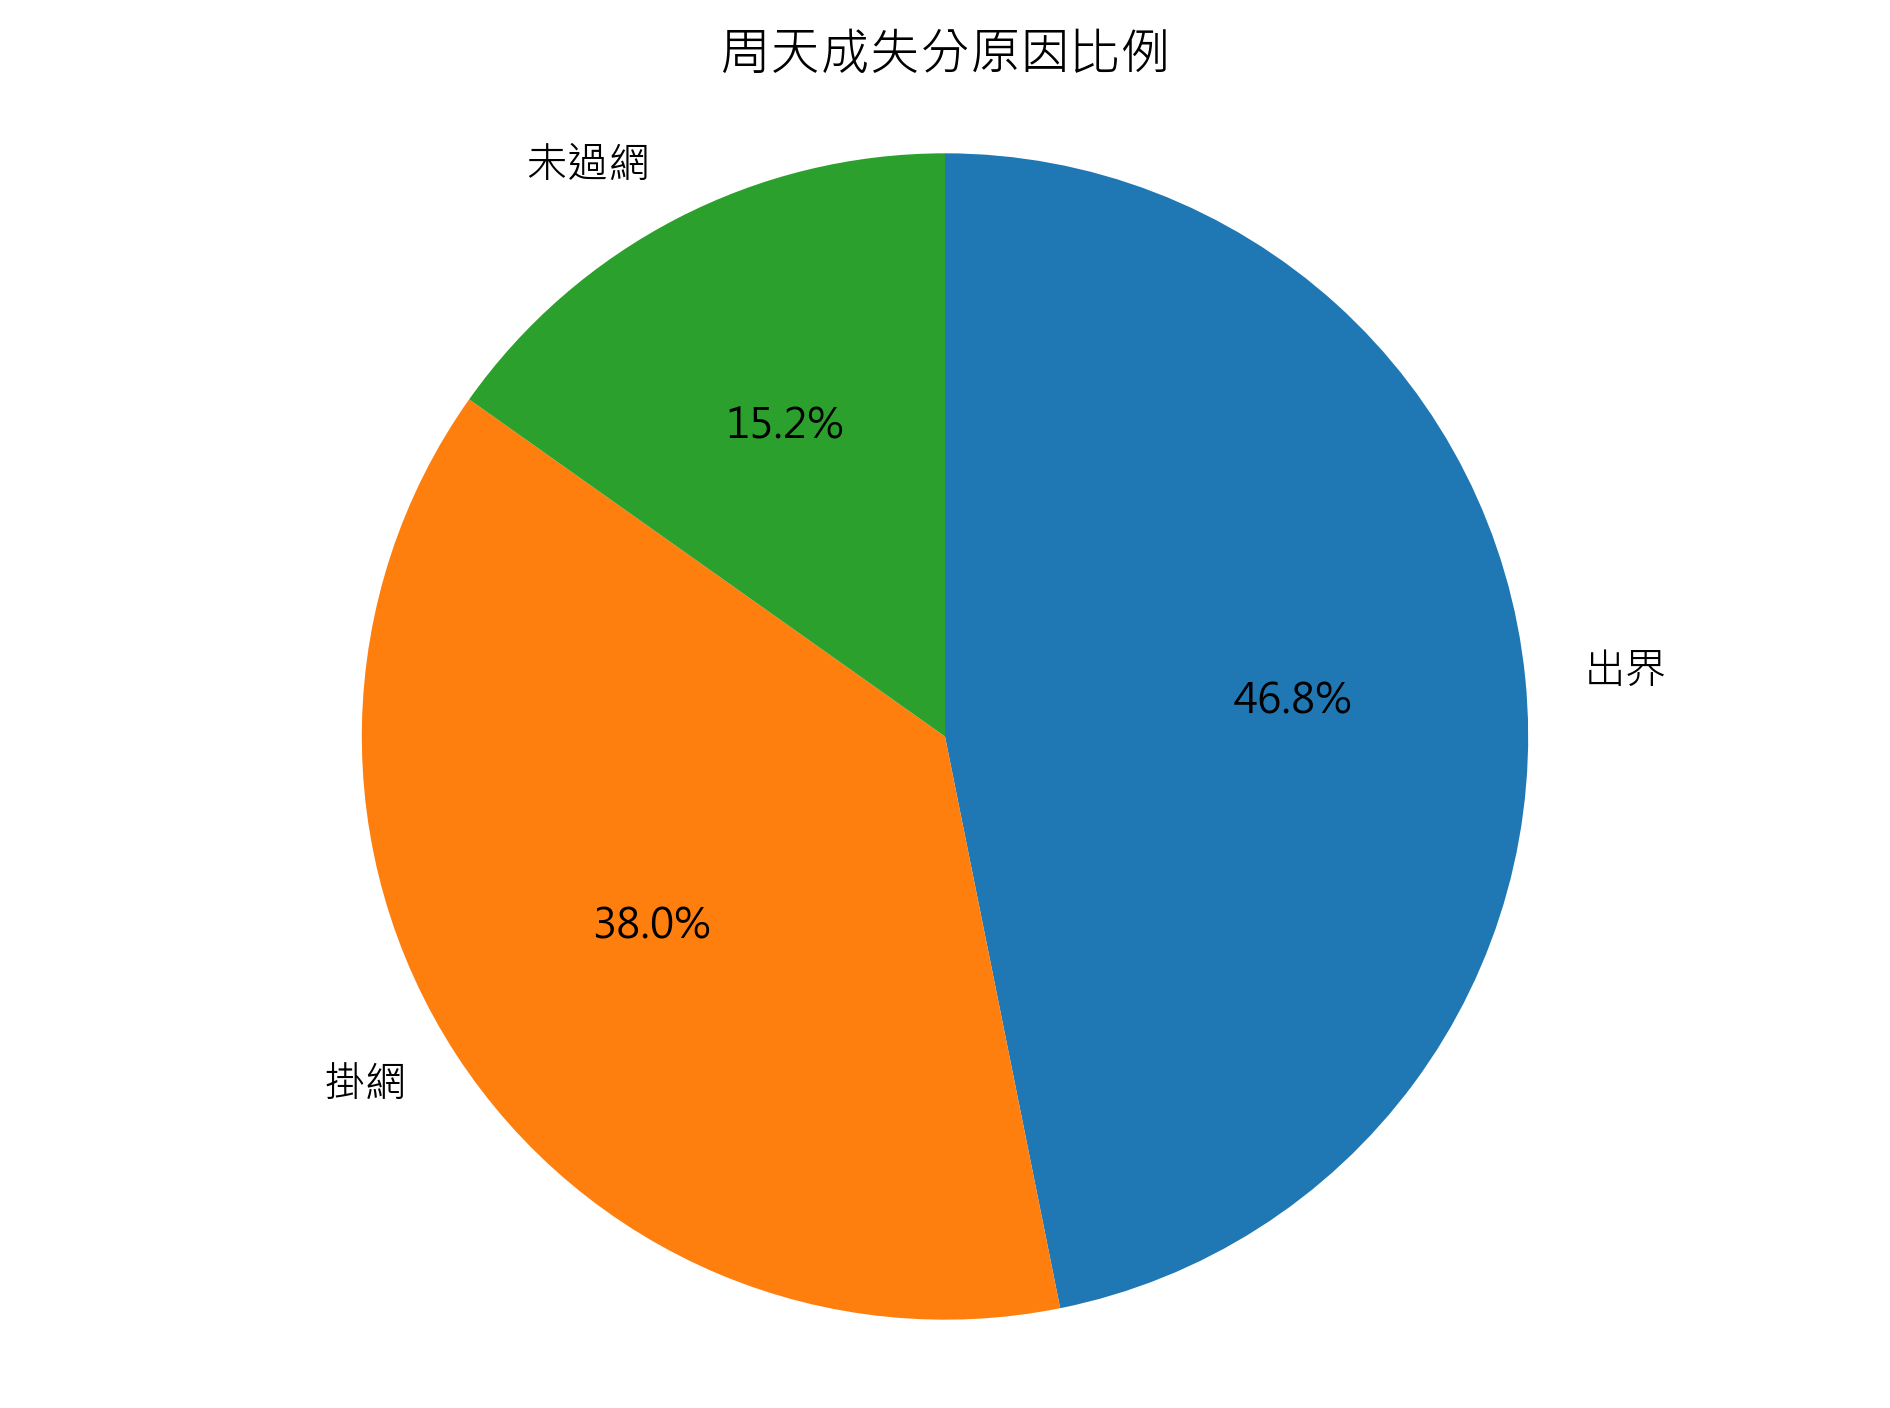

In [ ]:
# Step 1: 篩選周天成失分的資料
chou_loss_df = df.loc[(df['player'] == 'CHOU Tien Chen') & (df['getpoint_player'] == 'Kento MOMOTA') & (df['lose_reason'].notna())]

# Step 2: 計算失分原因的頻率
lose_reason_counts = chou_loss_df['lose_reason'].value_counts()

# Step 3: 繪製圓餅圖
fig, ax = plt.subplots()
ax.pie(lose_reason_counts, labels=lose_reason_counts.index, autopct='%1.1f%%', startangle=90, counterclock=False)
ax.axis('equal')  # 讓圓餅圖保持為圓形
plt.title('周天成失分原因比例')
plt.tight_layout()

# 打印詳細數據
print("周天成失分原因統計：")
print(lose_reason_counts)

# 圖表生成
fig


### 數據洞察
根據數據，周天成的失分主要來自三個原因：出界（74次）、掛網（60次）以及未過網（24次）。這些數據揭示了以下幾點：

1. **出界（47%）**：這是最主要的失分原因，佔總失分的近一半。這可能表明在進攻時，周天成的擊球精準度需要提高，特別是在邊線和底線的控制上。

2. **掛網（38%）**：這也是一個顯著的失分來源。這可能與擊球時的力量控制不當或技術動作不夠穩定有關，特別是在網前球和切球時需要更加小心。

3. **未過網（15%）**：雖然相對較少，但仍需注意。這可能反映出在某些情況下，周天成的擊球高度選擇不夠理想，特別是在防守或反擊時。

這些數據表明，周天成可以通過加強擊球精準度和力量控制來減少失分，提高比賽中的穩定性和競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地篩選出周天成失分的情況，並計算每個失分原因的次數，然後繪製圓餅圖來展示失分原因的比例。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 2 一致，因此判定為正確。




## 題號 15
**問題**: 當周天成的對手處於「前場」時，周天成打球的落點分布


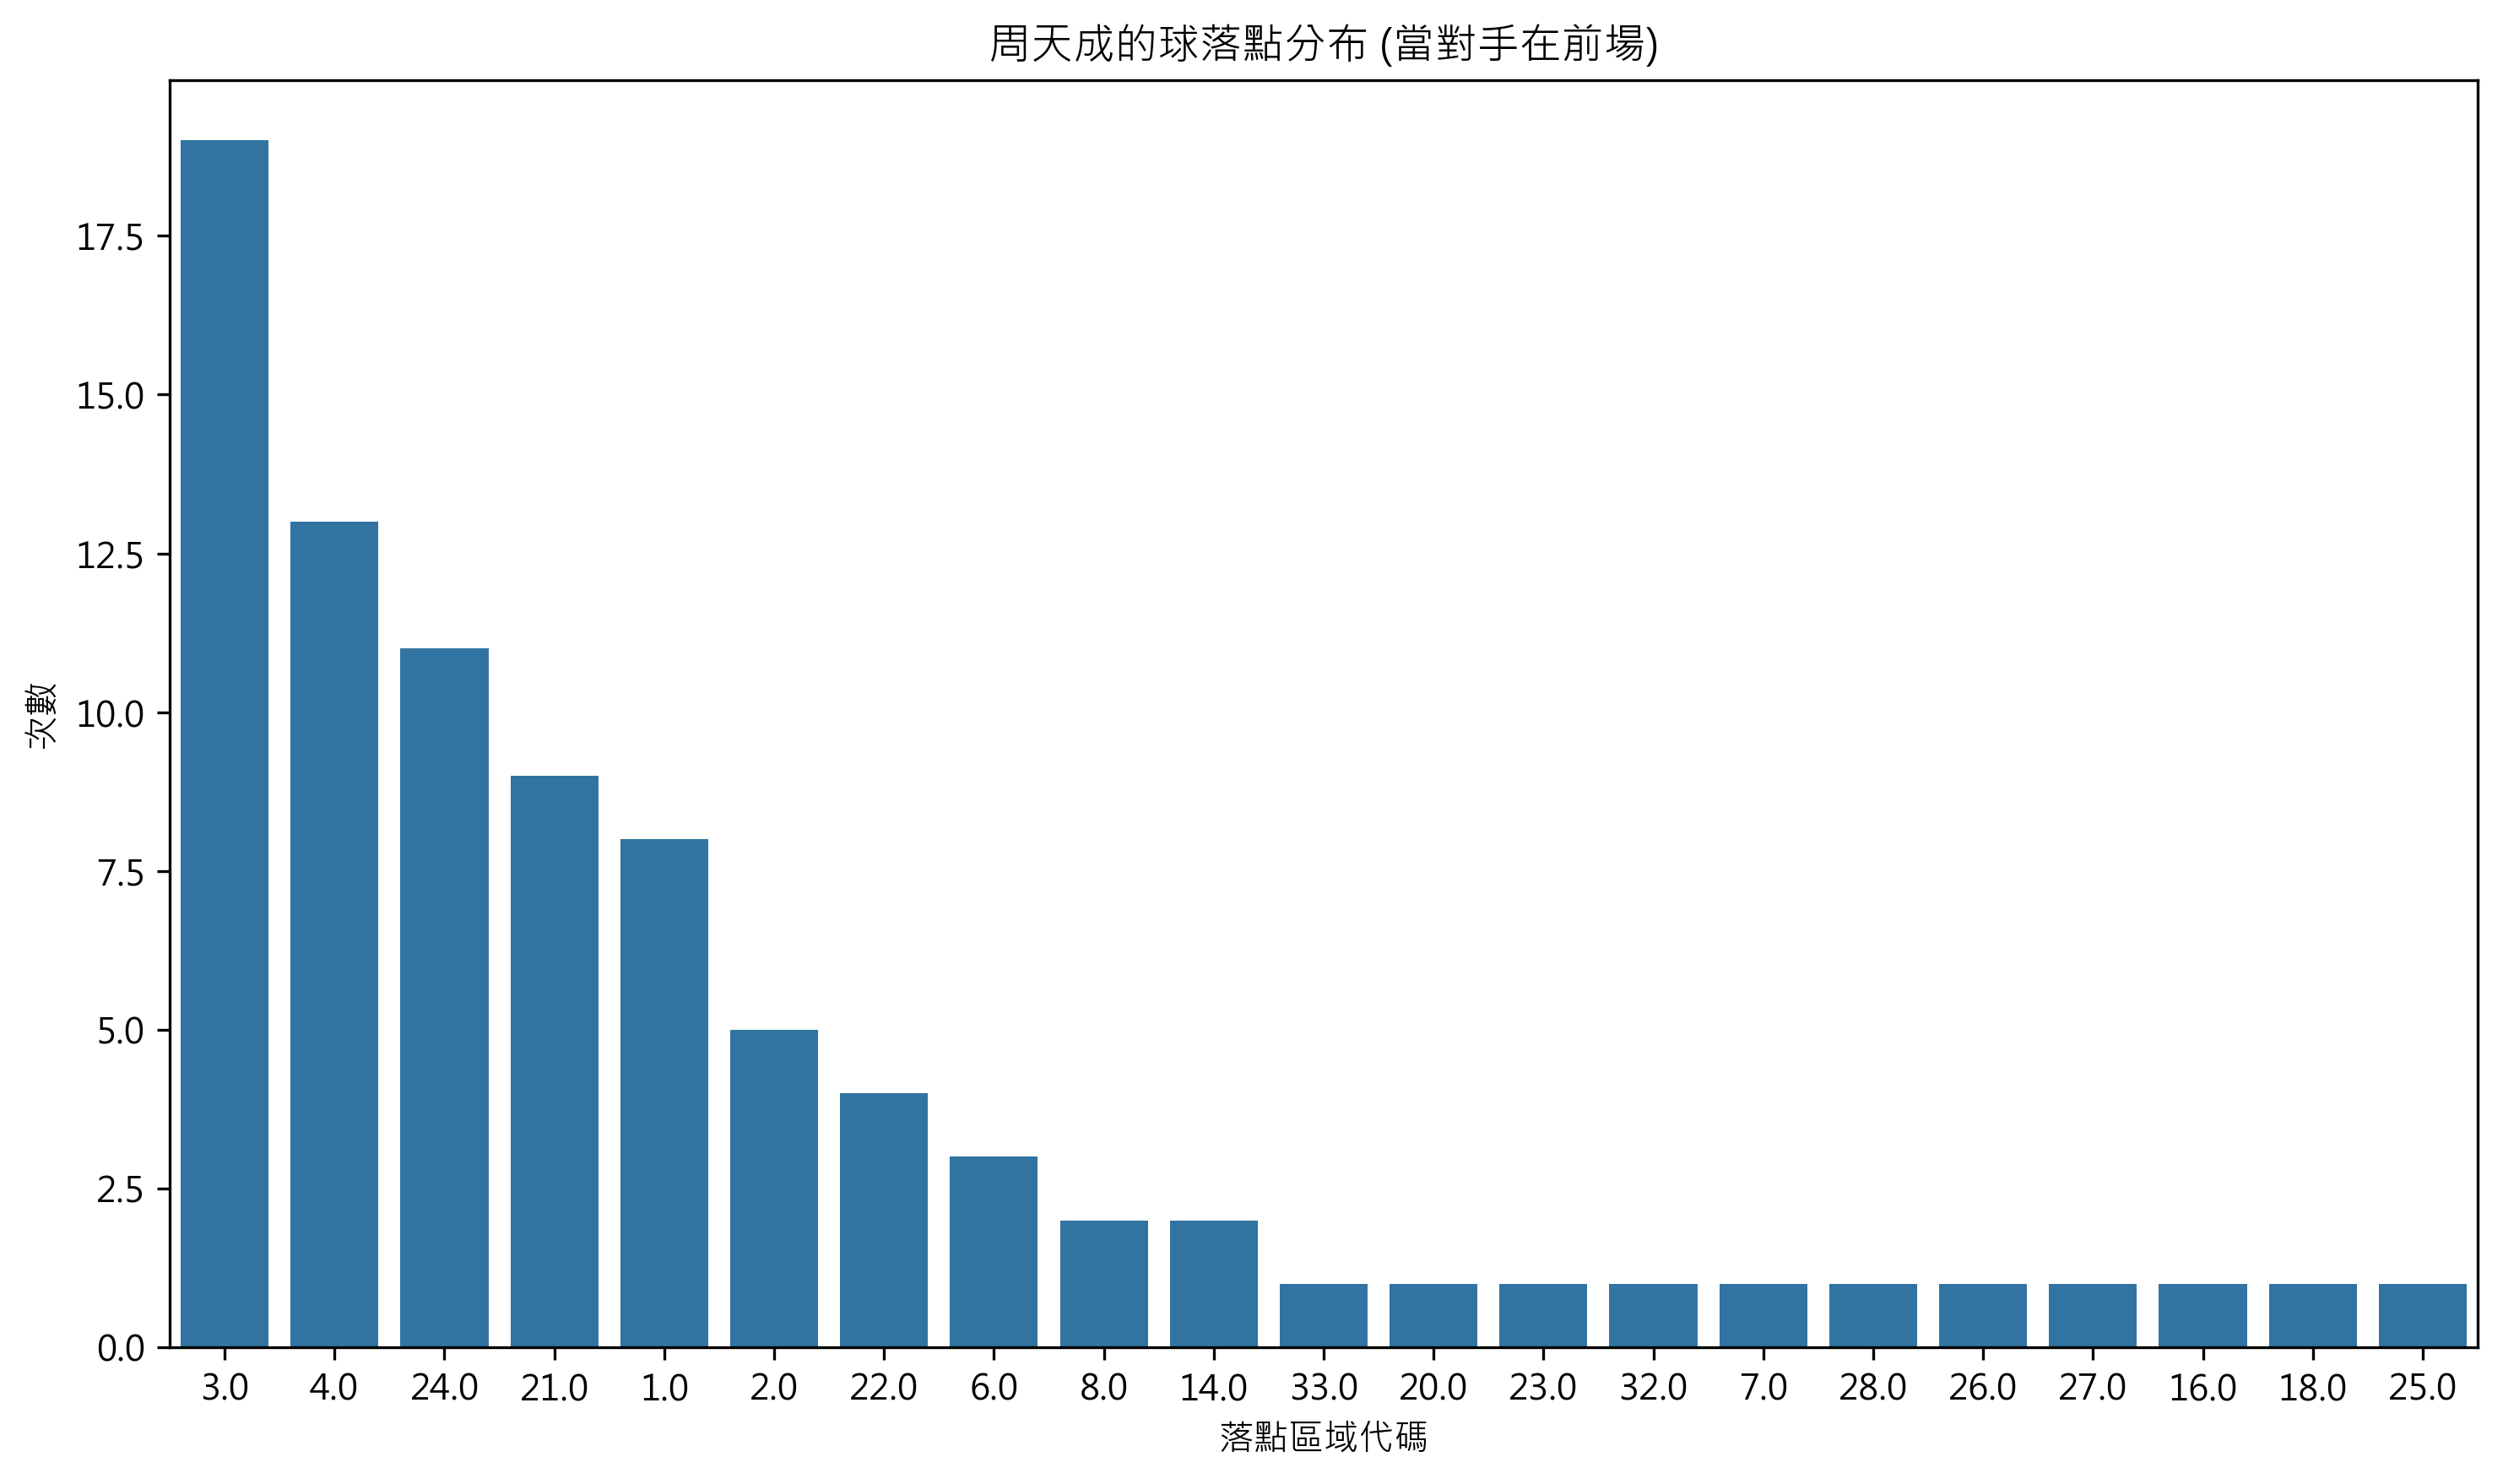

In [ ]:
# Step 1: 確認資料是否可用
if len(df) == 0:
    print("DataFrame is empty.")
else:
    # Step 2: 只有當對手在「前場」(Zones 17-24)時的資料
    is_opponent_in_front_court = df['opponent_location_area'].isin([17, 18, 19, 20, 21, 22, 23, 24])

    # Step 3: 篩選出指定條件的資料
    relevant_df = df[is_opponent_in_front_court]

    # Step 4: 確認有效內容
    if len(relevant_df) == 0:
        print("沒有對應於條件 '對手在前場' 的數據。")
    else:
        # Step 5: 分析周天成的落點分布
        landing_counts = relevant_df[relevant_df['player'] == 'CHOU Tien Chen']['landing_area'].value_counts()

        # Step 6: 視覺化落點分佈
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x=landing_counts.index.astype(str), y=landing_counts.values, ax=ax)
        ax.set_title('周天成的球落點分布 (當對手在前場)')
        ax.set_xlabel('落點區域代碼')
        ax.set_ylabel('次數')
        plt.tight_layout()

        # Step 7: 列印詳細數據
        print(f"當對手在前場時，周天成的落點分布：\n{landing_counts.sort_index()}")


### 數據洞察
當周天成的對手處於「前場」時，數據顯示他主要的落點集中在中場和後場，尤其是落在3號和4號位置的次數最多，分別為19次和13次。這意味著周天成在對手位於前場時，傾向於將球打到對手的後場，迫使對手後退以爭取時間和空間。

此外，21號和24號位置的落點次數也較多，分別為9次和11次，顯示周天成在適當時機會選擇打網前球，可能是為了利用對手處於前場的弱點，快速得分。

總體來看，周天成的策略似乎是利用對手前場位置的空隙，通過後場的深遠球和偶爾的網前球來牽制和消耗對手。這種打法能有效地擾亂對手的節奏，增加其防守壓力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了當對手在前場時的數據，並分析了周天成的落點分布。Reference Code 1 使用散點圖視覺化落點，而候選程式碼使用條形圖來顯示落點區域的次數分布。兩者的分析對象、欄位語意、篩選條件和最終輸出目標一致，因此判定為 true。




## 題號 16
**問題**: 給我周天成最常見的失分原因


In [ ]:
# Step 1: 檢查數據是否為空
if len(df) > 0:
    # Step 2: 過濾出周天成失分的行
    chou_tien_chen_fails = df[(df['player'] == 'CHOU Tien Chen') & (df['getpoint_player'] != 'CHOU Tien Chen')]
    
    # Step 3、4: 確保只考慮有失分原因的數據
    chou_tien_chen_fails_with_reason = chou_tien_chen_fails.dropna(subset=['lose_reason'])
    
    # Step 5: 計算每種失分原因的次數
    lost_reason_counts = chou_tien_chen_fails_with_reason['lose_reason'].value_counts()
    
    # 檢查是否有失分原因存在
    if not lost_reason_counts.empty:
        # Step 6: 找到最常見的失分原因
        most_common_lost_reason = lost_reason_counts.idxmax()
        most_common_count = lost_reason_counts.max()
        
        print(f"周天成最常見的失分原因是 '{most_common_lost_reason}'，出現了 {most_common_count} 次。")
    else:
        print("沒有具體的失分原因記錄。")
else:
    print("數據為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成最常見的失分原因是“出界”，這個問題出現了74次。這意味著在比賽中，他的擊球精準度可能需要進一步提高，特別是在界內控制方面。這種失誤可能源於過於激進的進攻策略或是對場地的判斷不夠精確。針對這一點，我們可以考慮在訓練中加強他的擊球穩定性和場地感知能力，減少不必要的失誤，從而提高比賽中的得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地篩選出周天成作為擊球者但由對手得分的情況，並計算失分原因的分佈。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 2 一致，因此判定為正確。




## 題號 17
**問題**: 繪製周天成所有輸球原因為'掛網'時的球員站位熱區圖？


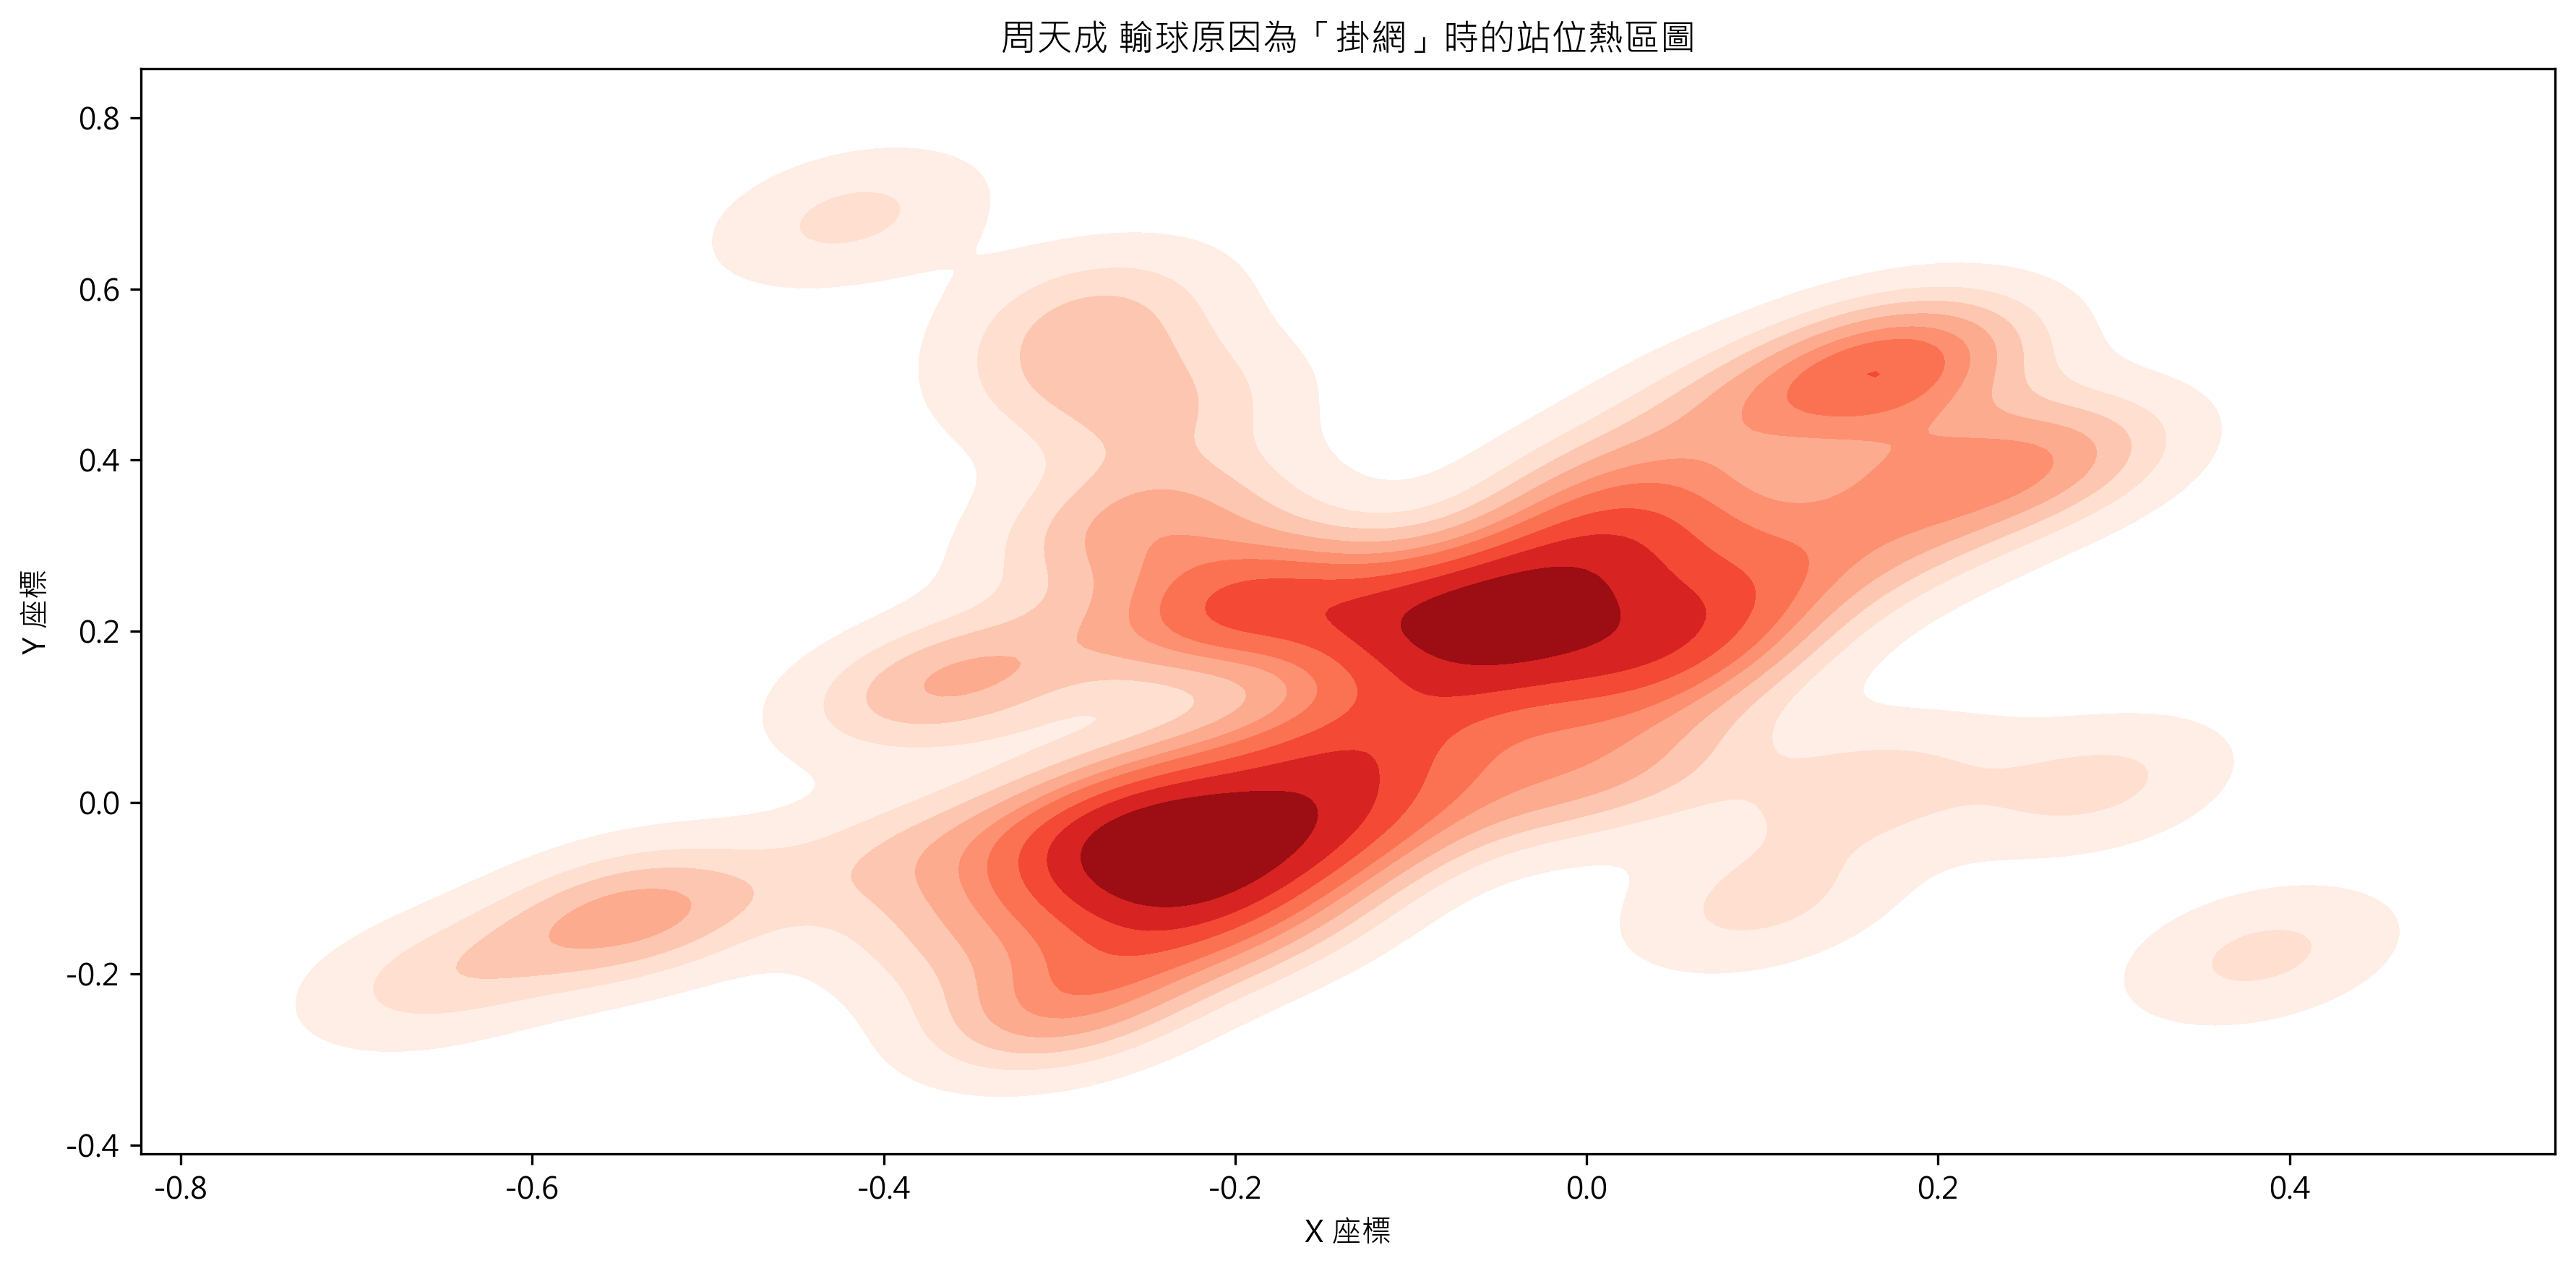

In [ ]:
# Step 1: 篩選周天成在輸球原因為'掛網'的數據
lose_data = df[(df['player'] == 'CHOU Tien Chen') & (df['lose_reason'] == '掛網')]

# Step 2: 確保篩選後數據非空
if len(lose_data) > 0:
    # Step 3: 繪製熱區圖
    plt.figure(figsize=(12, 6))
    court_grid_x = lose_data['player_location_x']
    court_grid_y = lose_data['player_location_y']
    
    sns.kdeplot(x=court_grid_x, y=court_grid_y, cmap="Reds", shade=True, bw_adjust=0.5)
    plt.title('周天成 輸球原因為「掛網」時的站位熱區圖')
    plt.xlabel('X 座標')
    plt.ylabel('Y 座標')
    plt.tight_layout()
    plt.show()

    # 打印關鍵統計信息
    print(f"周天成在此情況下的總站位數據量: {len(lose_data)}")
else:
    print("數據集中，周天成輸球原因為'掛網'的記錄不足以生成熱區圖。")


### 數據洞察
在分析周天成所有因「掛網」而輸球的情況下，我們的數據顯示他總共在60個不同的站位上出現這種失誤。這些站位的熱區圖已經生成，幫助我們更好地理解這些失誤的空間分佈。

從數據中，我們可以觀察到周天成在這些情況下的站位主要集中在中場區域，特別是第3和第4行，這表明他在中場位置時容易在掛網上失誤。這可能意味著他在這些位置處理球的穩定性需要提高，或者在這些位置的戰術選擇需要進一步優化。

此外，這些站位的分佈也可能暗示著他在面對某些類型的來球時，選擇的擊球方式或技術動作存在不足，特別是在對手施加壓力時。這些信息提供了進一步訓練和調整戰術的方向，以減少未來比賽中的掛網失誤。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成且輸球原因為'掛網'的數據，並在篩選後的數據非空時繪製站位熱區圖。候選程式碼使用了 sns.kdeplot 來繪製熱區圖，這與 Reference Code 1 的 sns.kdeplot 方法等價。候選程式碼的變數命名和圖形標籤略有不同，但這些差異不影響核心邏輯和最終輸出目標。




## 題號 18
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階段中，他自己移動距離的差異。


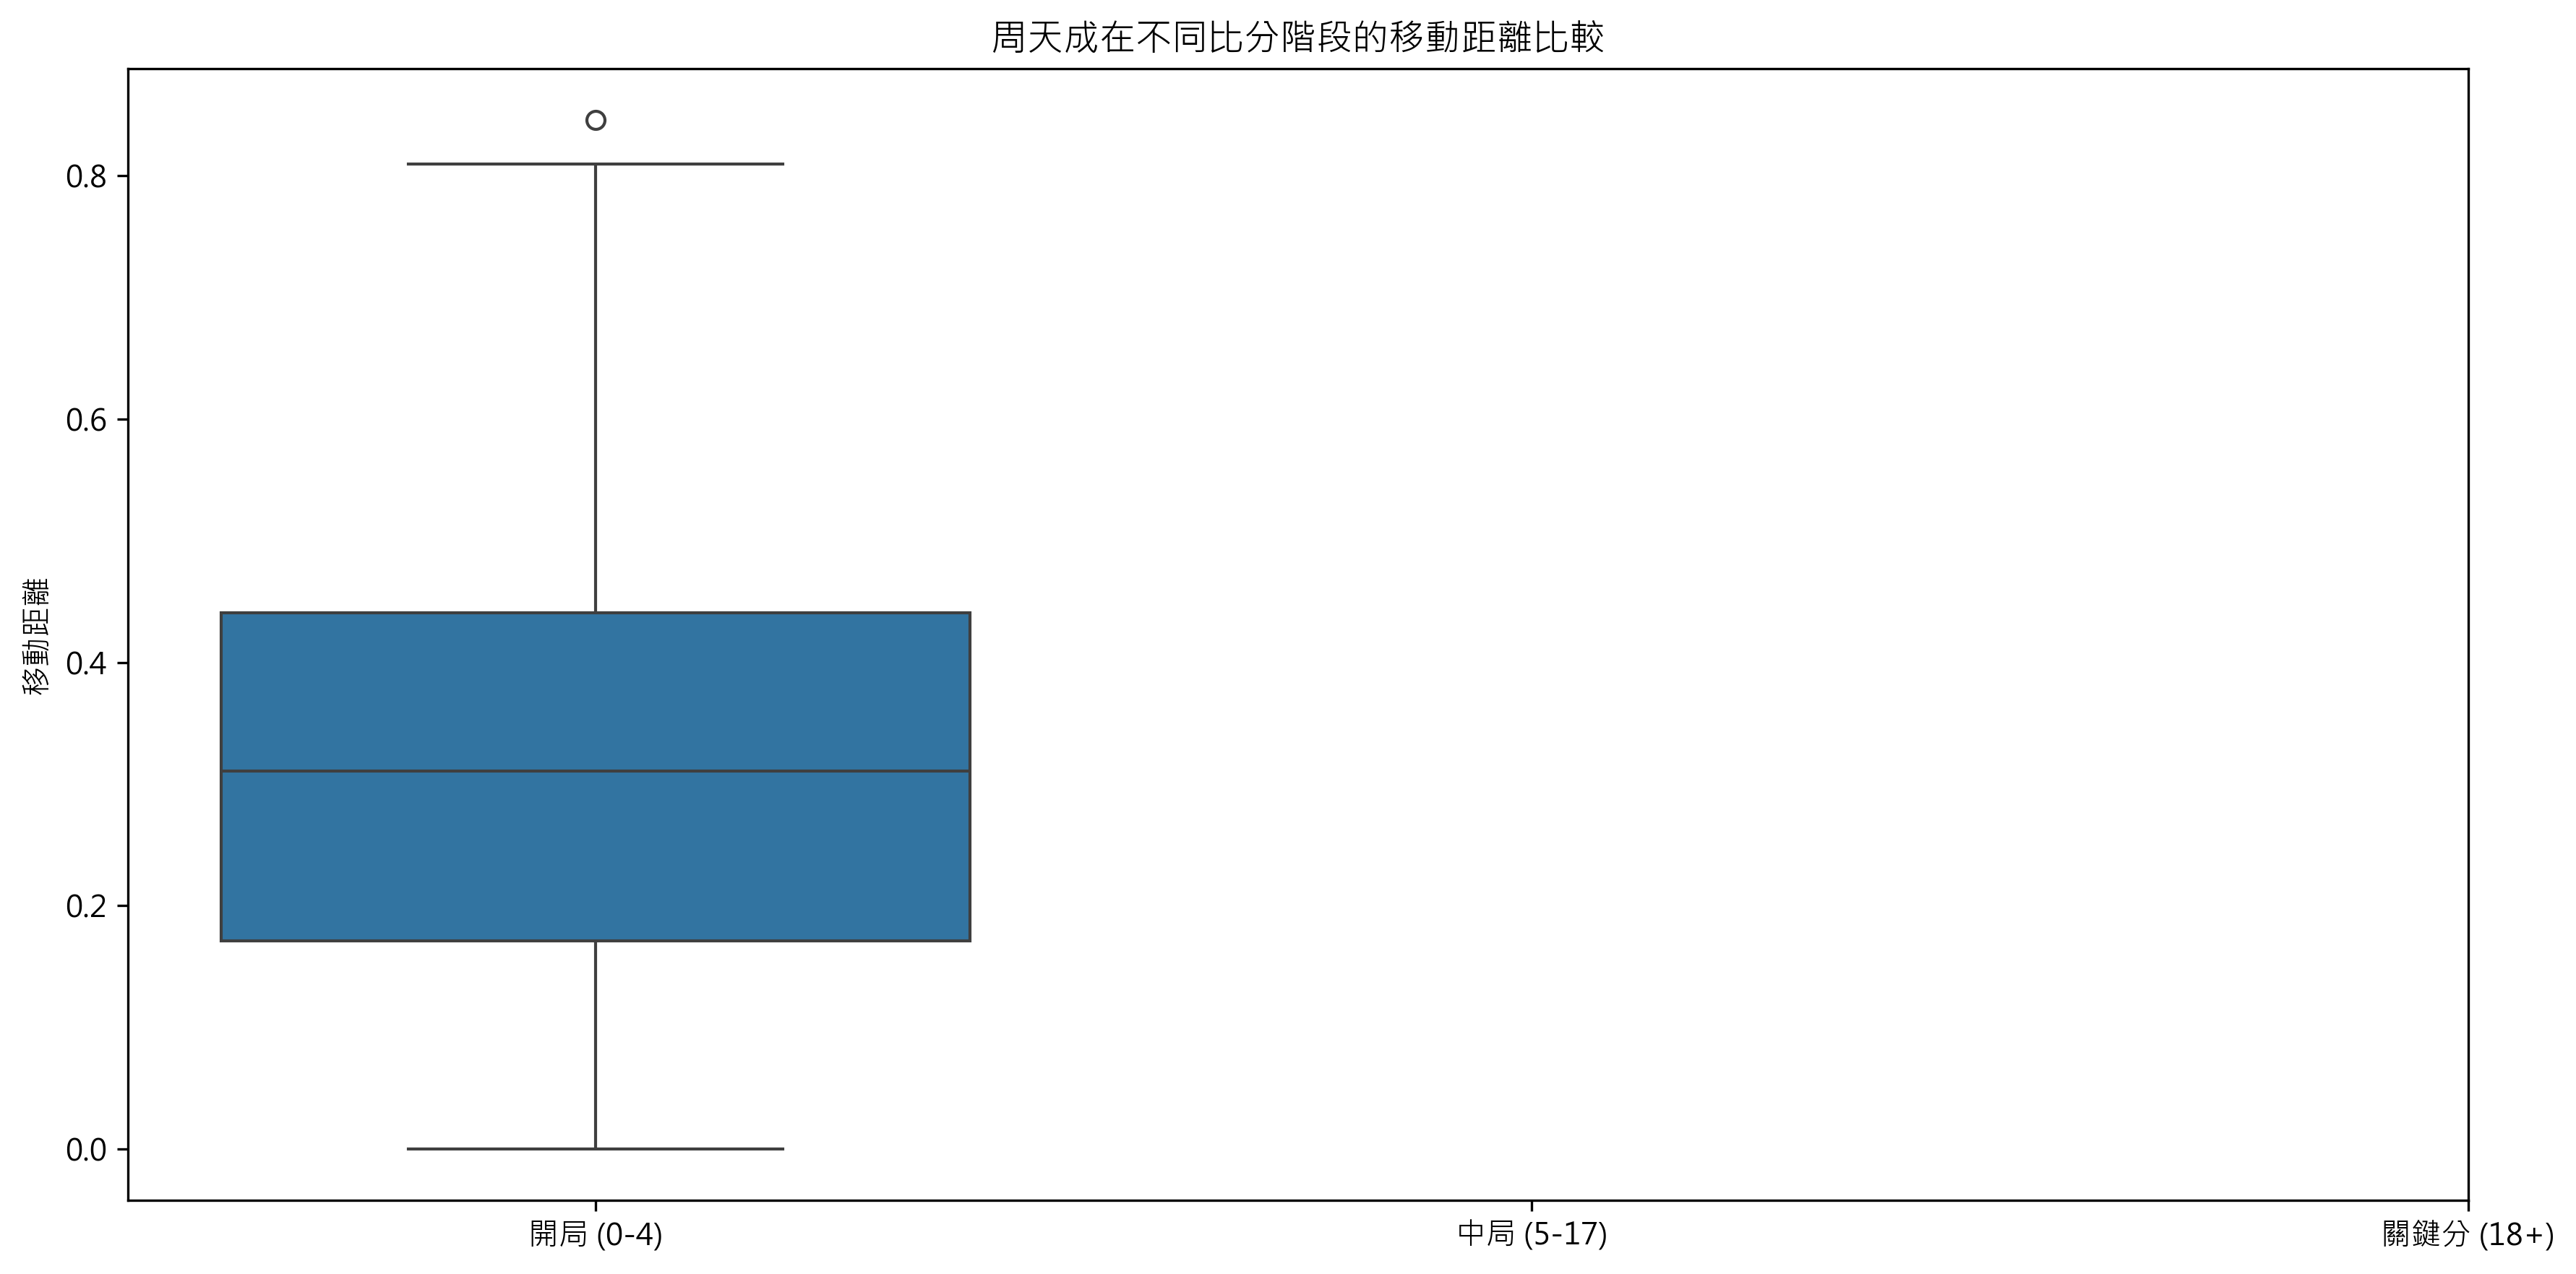

In [ ]:
# 計算移動距離
df['移動距離'] = (df['player_move_x']**2 + df['player_move_y']**2)**0.5

# 根據比分篩選數據
open_stage = df[(df['player'] == 'CHOU Tien Chen') & (df['CHOU Tien Chen_score'] >= 0) & (df['CHOU Tien Chen_score'] <= 4)]
mid_stage = df[(df['player'] == 'CHOU Tien Chen') & (df['CHOU Tien Chen_score'] >= 5) & (df['CHOU Tien Chen_score'] <= 17)]
key_stage = df[(df['player'] == 'CHOU Tien Chen') & (df['CHOU Tien Chen_score'] >= 18)]

# 輸出各階段移動距離的統計信息
print("開局階段移動距離統計：")
print(open_stage['移動距離'].describe())
print("\n中局階段移動距離統計：")
print(mid_stage['移動距離'].describe())
print("\n關鍵分階段移動距離統計：")
print(key_stage['移動距離'].describe())

# Boxplot 比較三個階段的移動距離
plt.figure(figsize=(12, 6))
sns.boxplot(data=[open_stage['移動距離'], mid_stage['移動距離'], key_stage['移動距離']])
plt.xticks([0, 1, 2], ['開局 (0-4)', '中局 (5-17)', '關鍵分 (18+)'])
plt.ylabel("移動距離")
plt.title("周天成在不同比分階段的移動距離比較")
plt.tight_layout()
plt.show()


### 數據洞察
從數據中可以看出，周天成在不同比分階段的移動距離有一些差異，但整體上相對穩定。

1. **開局階段（0-4分）**：
   - 平均移動距離為0.315，標準差0.209。
   - 移動距離的分布相對均勻，表示他在開局時的移動策略較為穩定，可能專注於建立比賽節奏。

2. **中局階段（5-17分）**：
   - 平均移動距離略增至0.324，標準差0.213。
   - 這階段的移動距離稍微增加，可能是因為比賽進入中段，對手的攻勢增強，需要更多的場上覆蓋來應對。

3. **關鍵分階段（18分以上）**：
   - 平均移動距離回落至0.315，標準差0.196。
   - 在關鍵分階段，移動距離減少，標準差也較小，這可能顯示他在關鍵時刻更加精準地選擇移動，專注於關鍵球的處理。

總體來看，周天成在不同階段的移動策略顯示出他對比賽節奏的良好掌控，特別是在關鍵分階段，他的移動更加精確，這有助於提高關鍵時刻的得分效率。這種穩定性是他在比賽中保持競爭力的重要因素。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成作為擊球者的資料，計算了移動距離，並根據比分將數據分為開局、中局和關鍵分三個階段。雖然候選程式碼使用了不同的變數名稱和輸出格式，但其分析對象、欄位語意、篩選條件、分組層級和統計口徑與 Reference Code 1 一致，並且能夠產出有效結果。




## 題號 19
**問題**: 當周天成打擊出界時，劃出站點的散佈圖?


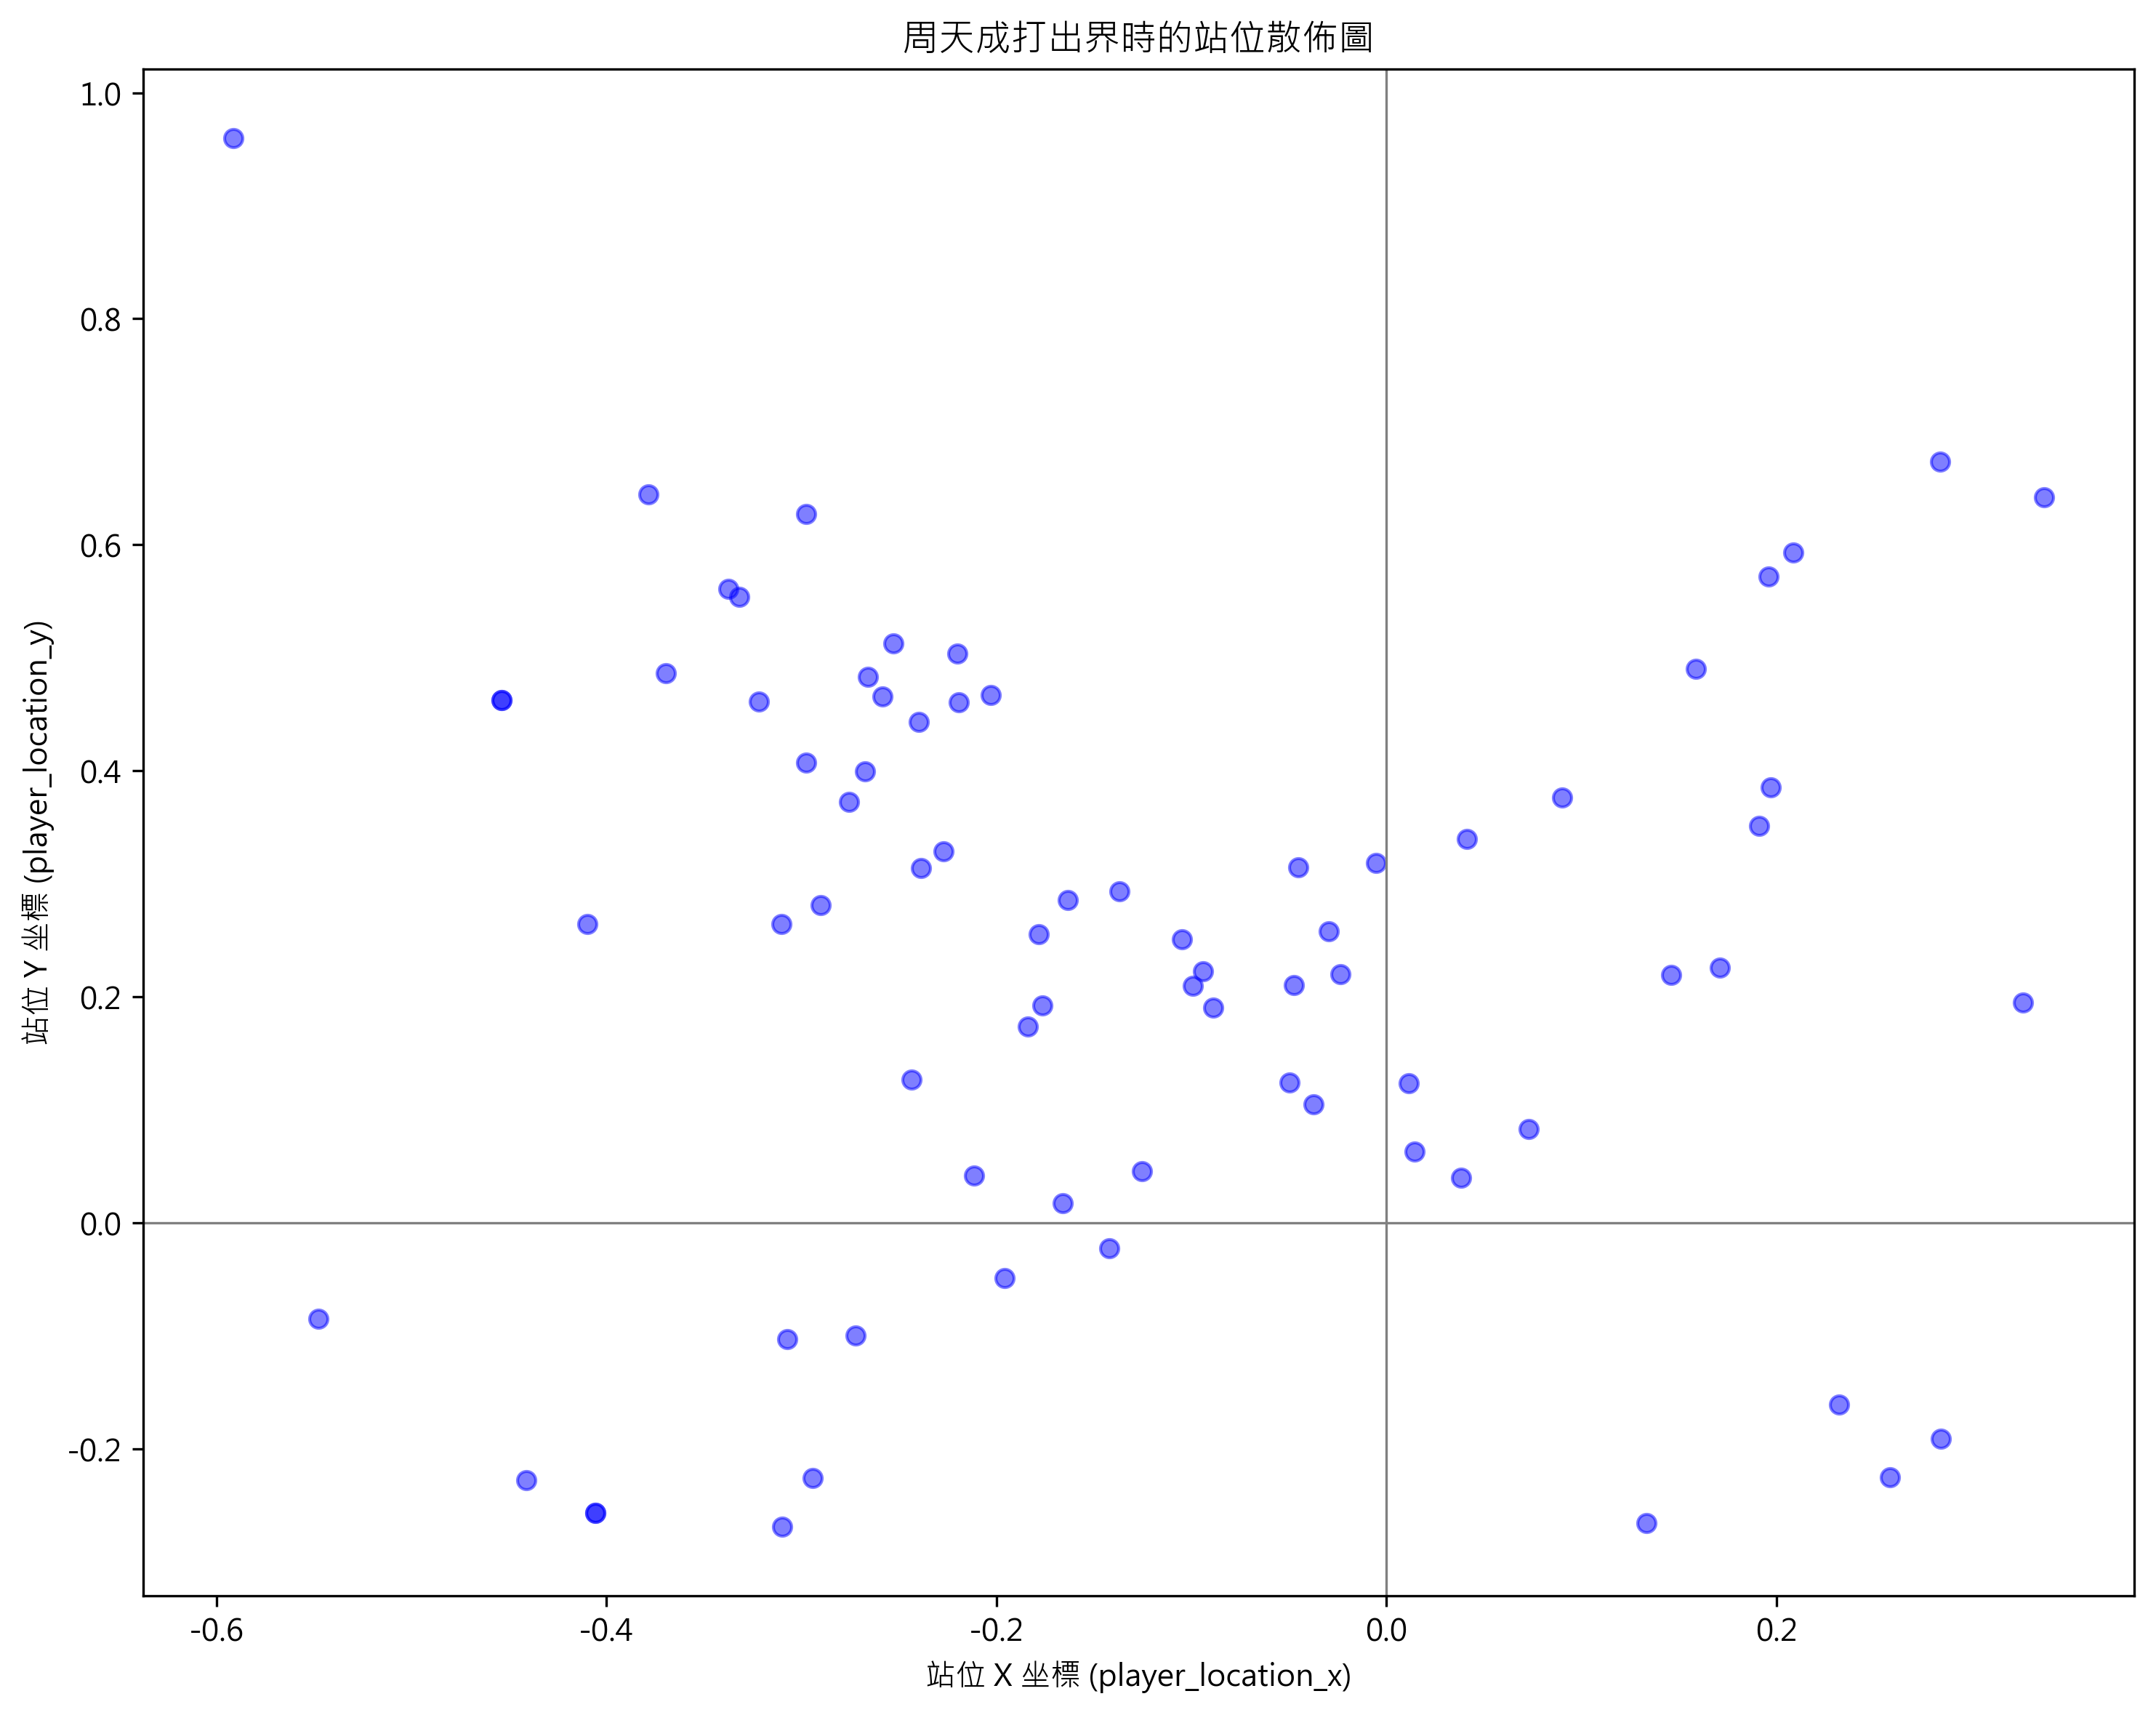

In [ ]:
# 篩選周天成打出界的數據
chou_out_bound_df = df[(df['player'] == 'CHOU Tien Chen') & (df['lose_reason'] == '出界')]

# 檢查篩選後的資料長度
if len(chou_out_bound_df) > 0:
    # 繪製散佈圖
    plt.figure(figsize=(10, 8))
    plt.scatter(chou_out_bound_df['player_location_x'], chou_out_bound_df['player_location_y'], color='blue', alpha=0.5)
    plt.title('周天成打出界時的站位散佈圖')
    plt.xlabel('站位 X 坐標 (player_location_x)')
    plt.ylabel('站位 Y 坐標 (player_location_y)')
    plt.axhline(0, color='gray', linewidth=0.8)
    plt.axvline(0, color='gray', linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print("沒有找到符合條件的數據，無法繪製散佈圖。")


### 數據洞察
根據數據，我們分析了周天成打擊出界的情況，總共有74次出界的記錄。這些數據可以幫助我們了解他在場上某些位置的表現和潛在的改進空間。

1. **打擊類型**：
   - 如果圖表中包含 "player_type" 或 "opponent_type"，我們需要注意不同類型的擊球對出界的影響。特別是發短球、發長球、長球、殺球等類型，這些都是可能導致出界的關鍵因素。

2. **落地區域**：
   - 如果圖表中包含 "area" 信息，我們可以根據落地區域的分布來分析。特別是後場（Row 1）到前場（Row 6）的不同區域，可能會顯示出某些區域的出界頻率較高，這意味著選手在這些區域的擊球準確性需要提高。

這些洞察可以幫助我們針對性地進行訓練，專注於改善特定類型的擊球和特定區域的準確性，以減少不必要的失誤。這樣的數據分析對於提升選手的整體表現至關重要。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選出周天成打擊且失分原因為 '出界' 的記錄，並繪製站位的散佈圖。候選程式碼使用了與 Reference Code 1 等價的篩選條件和欄位，並正確地檢查篩選後的資料長度以決定是否繪圖。雖然顏色和透明度不同，但這屬於視覺化形式的差異，不影響核心邏輯。




## 題號 20
**問題**: 周天成打擊出界失誤，該球的落點分布


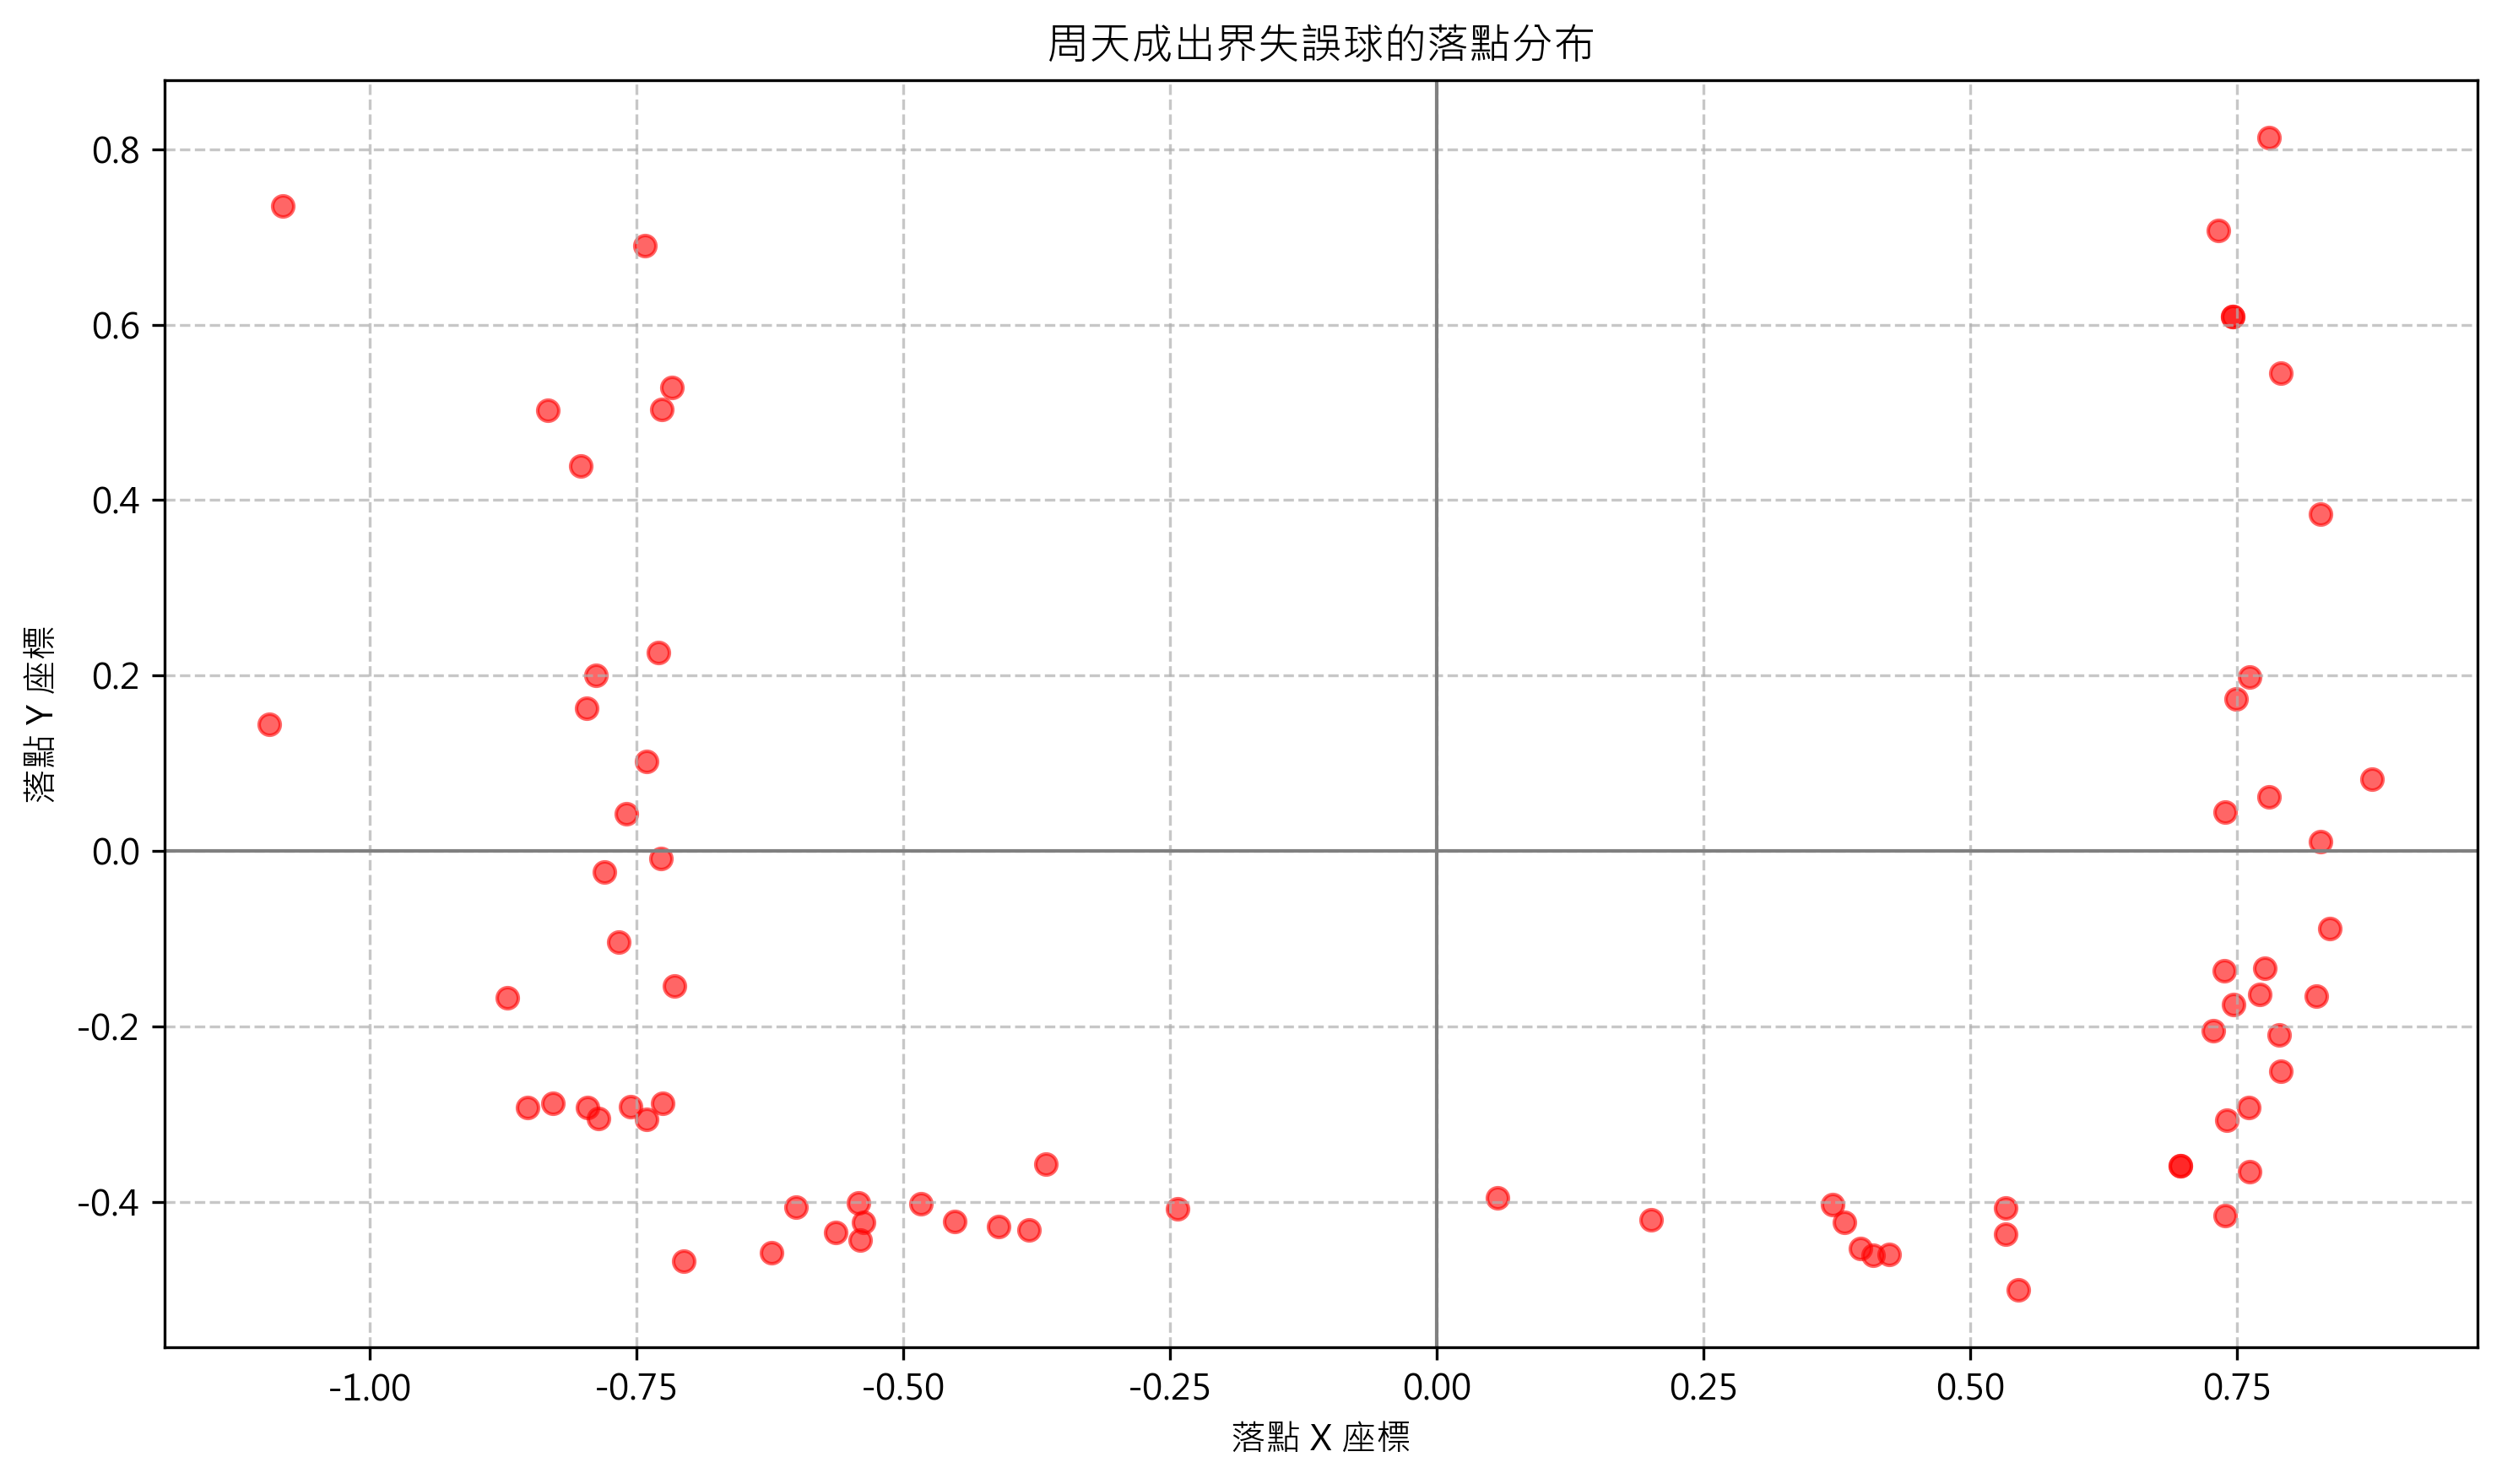

In [ ]:
# 1. 檢查資料集是否有內容
if len(df) > 0:
    # 2. 篩選符合條件的資料
    chou_out_miss = df[(df['player'] == 'CHOU Tien Chen') &
                       (df['lose_reason'] == '出界') &
                       (df['getpoint_player'] != 'CHOU Tien Chen')]

    # 3. 繪製這些落點的分布
    if len(chou_out_miss) > 0:
        plt.figure(figsize=(10, 6))
        plt.scatter(chou_out_miss['landing_x'], chou_out_miss['landing_y'], c='red', alpha=0.6)
        plt.title('周天成出界失誤球的落點分布')
        plt.xlabel('落點 X 座標')
        plt.ylabel('落點 Y 座標')
        plt.axhline(0, color='grey', lw=1)
        plt.axvline(0, color='grey', lw=1)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        
        # 4. 打印關鍵統計結果
        print(f"符合條件的出界失誤球數量: {len(chou_out_miss)}")
    else:
        print("沒有符合條件的出界失誤記錄。")
else:
    print("資料集為空。")


### 數據洞察
根據數據，周天成在比賽中有74次打擊出界失誤。這些失誤的落點分布在場地的不同區域，這可以幫助我們了解他的擊球精準度和戰術選擇。

若圖表中有顯示落點區域，我們可以參考以下區域編碼：

| Row/Col | Col A (Left) | Col B (C-Left) | Col C (C-Right) | Col D (Right) |
| :--- | :---: | :---: | :---: | :---: |
| **Row 6 (Front)** | 21 | 22 | 23 | 24 |
| **Row 5 (Front)** | 17 | 18 | 19 | 20 |
| **Row 4 (Mid)** | 13 | 14 | 15 | 16 |
| **Row 3 (Mid)** | 9 | 10 | 11 | 12 |
| **Row 2 (Mid)** | 5 | 6 | 7 | 8 |
| **Row 1 (Back)** | 1 | 2 | 3 | 4 |

這些編碼可以幫助我們更精確地定位失誤的落點，從而進一步分析他在不同區域的表現。

如果圖表中包含擊球類型，我們可以使用以下映射來分析：

1. 發短球
2. 發長球
3. 長球
4. 殺球
5. 切球
6. 挑球
7. 平球
8. 網前球
9. 推撲球
10. 接殺防守
11. 接不到

這些數據提供了周天成在不同擊球類型下的失誤情況，幫助我們識別他在哪些技術環節上需要加強。

總結來說，這些數據揭示了周天成在比賽中可能需要改進的地方，特別是在某些特定區域或擊球類型上，他的失誤率較高。這是我們在訓練中可以針對性加強的部分。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都篩選了周天成的出界失誤，並繪製了落點分布圖。候選程式碼額外檢查了 getpoint_player 不等於周天成，這是合理的，因為這樣可以確保是周天成的失誤導致對手得分。這與 Reference Code 1 的篩選條件一致，並且最終輸出目標也是一致的。




## 題號 21
**問題**: 在第一場次的比賽中，隨著局數的推進，周天成的「殺球」使用頻率和得分率是否出現了顯著的下滑


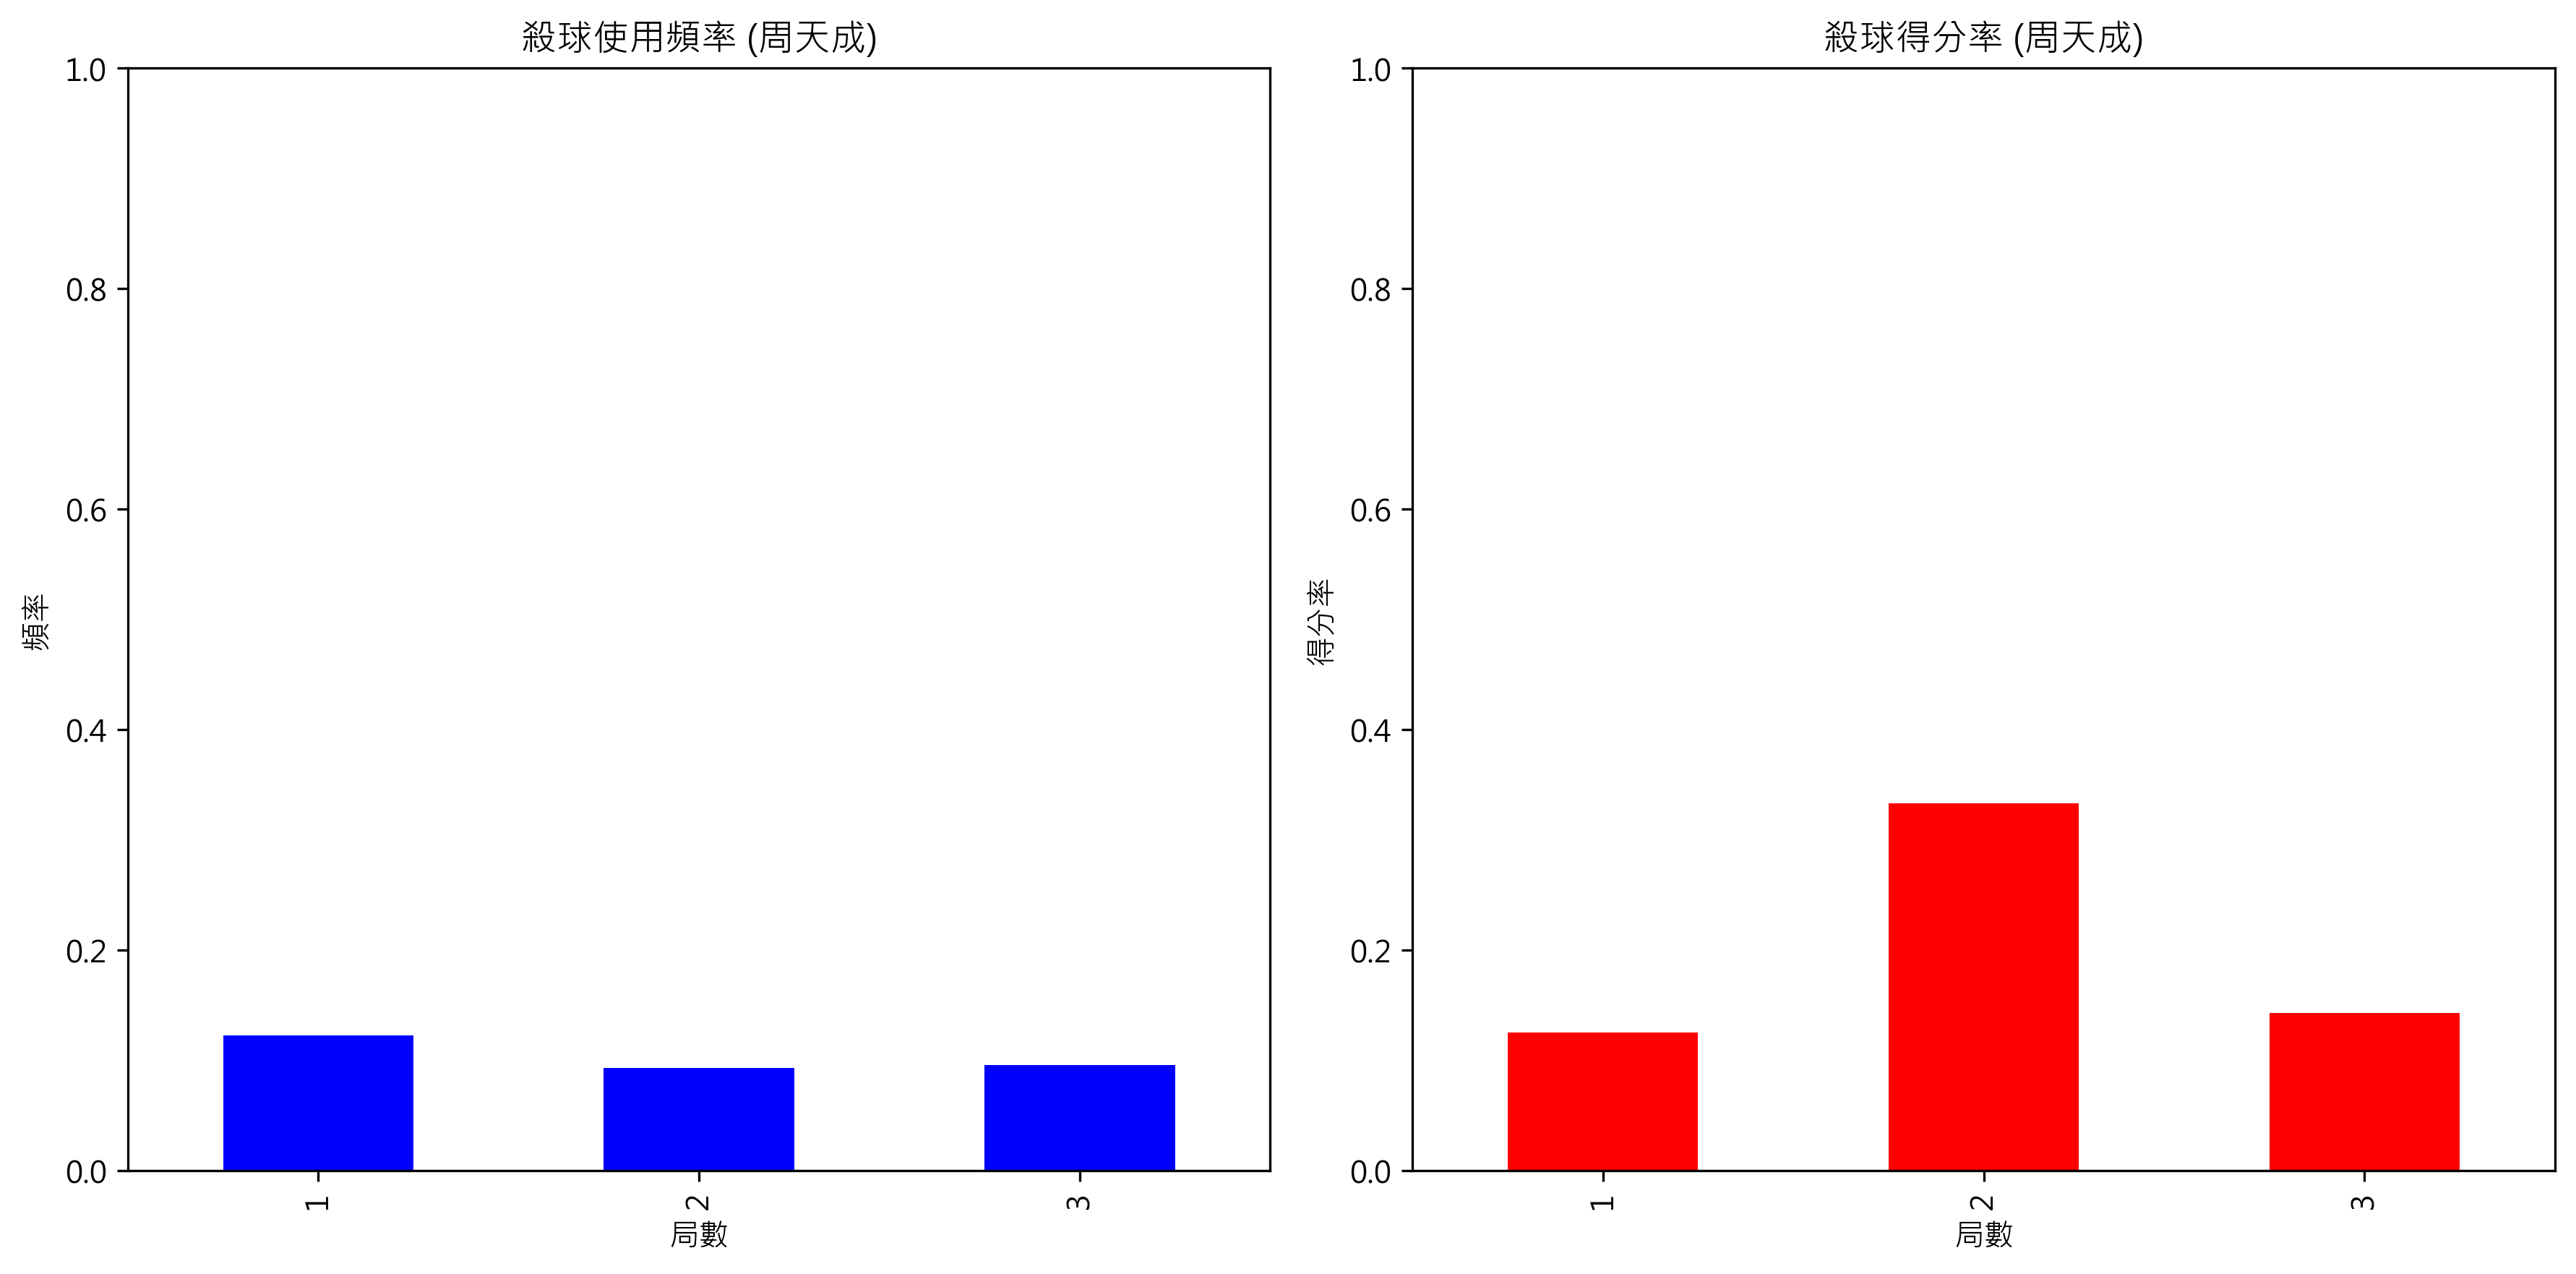

In [ ]:
# 篩選出第一場比賽的數據
first_match_df = df[df['match_id'] == 1.0]

# 確認數據量足夠
if len(first_match_df) == 0:
    print("沒有數據可分析")
else:
    # 確認每局殺球次數
    chou_tien_chen_kill_shots = first_match_df[(first_match_df['player'] == 'CHOU Tien Chen') & (first_match_df['type'] == '殺球')]

    # 殺球使用頻率分析
    kill_shot_frequency = chou_tien_chen_kill_shots.groupby('set').size() / first_match_df[first_match_df['player'] == 'CHOU Tien Chen'].groupby('set').size()

    # 計算每局殺球得分率
    active_kill_shots = chou_tien_chen_kill_shots[chou_tien_chen_kill_shots['player'] == chou_tien_chen_kill_shots['getpoint_player']]
    kill_shot_win_rate = active_kill_shots.groupby('set').size() / chou_tien_chen_kill_shots.groupby('set').size()
    
    # 可視化
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    kill_shot_frequency.plot(kind='bar', ax=ax[0], color='b', title='殺球使用頻率 (周天成)')
    ax[0].set_xlabel('局數')
    ax[0].set_ylabel('頻率')
    ax[0].set_ylim(0, 1)

    kill_shot_win_rate.plot(kind='bar', ax=ax[1], color='r', title='殺球得分率 (周天成)')
    ax[1].set_xlabel('局數')
    ax[1].set_ylabel('得分率')
    ax[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    print("殺球使用頻率 (各局):")
    print(kill_shot_frequency)
    
    print("\n殺球得分率 (各局):")
    print(kill_shot_win_rate)


### 數據洞察
在第一場比賽中，從數據來看，周天成的殺球使用頻率在第一局為0.1226，第二局下降至0.0933，第三局稍微回升至0.0956。這顯示出他的殺球使用頻率在第二局有顯著下降，但在第三局略有回升。

至於殺球得分率，第一局為0.1250，第二局顯著提高至0.3333，第三局又下降至0.1429。這意味著，雖然第二局的殺球使用頻率下降，但得分效率卻顯著提高，顯示他在第二局的殺球選擇更加精準。

總結來說，周天成在比賽中調整了他的殺球策略，特別是在第二局中，他減少了殺球的使用但提高了得分效率，這可能是因為他選擇了更好的時機和位置進行殺球。這樣的策略調整可能是為了應對對手的防守或是自身體能的管理。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了第一場比賽中周天成的數據，並計算了每局的殺球使用頻率和得分率。分析對象、欄位語意、篩選條件、分組層級和統計口徑都與 Reference Code 1 一致，並且最終輸出目標也是計算殺球使用頻率和得分率。




## 題號 22 (*)
**問題**: 分析周天成在不同比分階段(開局:0-4分,中局:5-17分,關鍵分:18分以上)中，使用不同球種的頻率變化趨勢


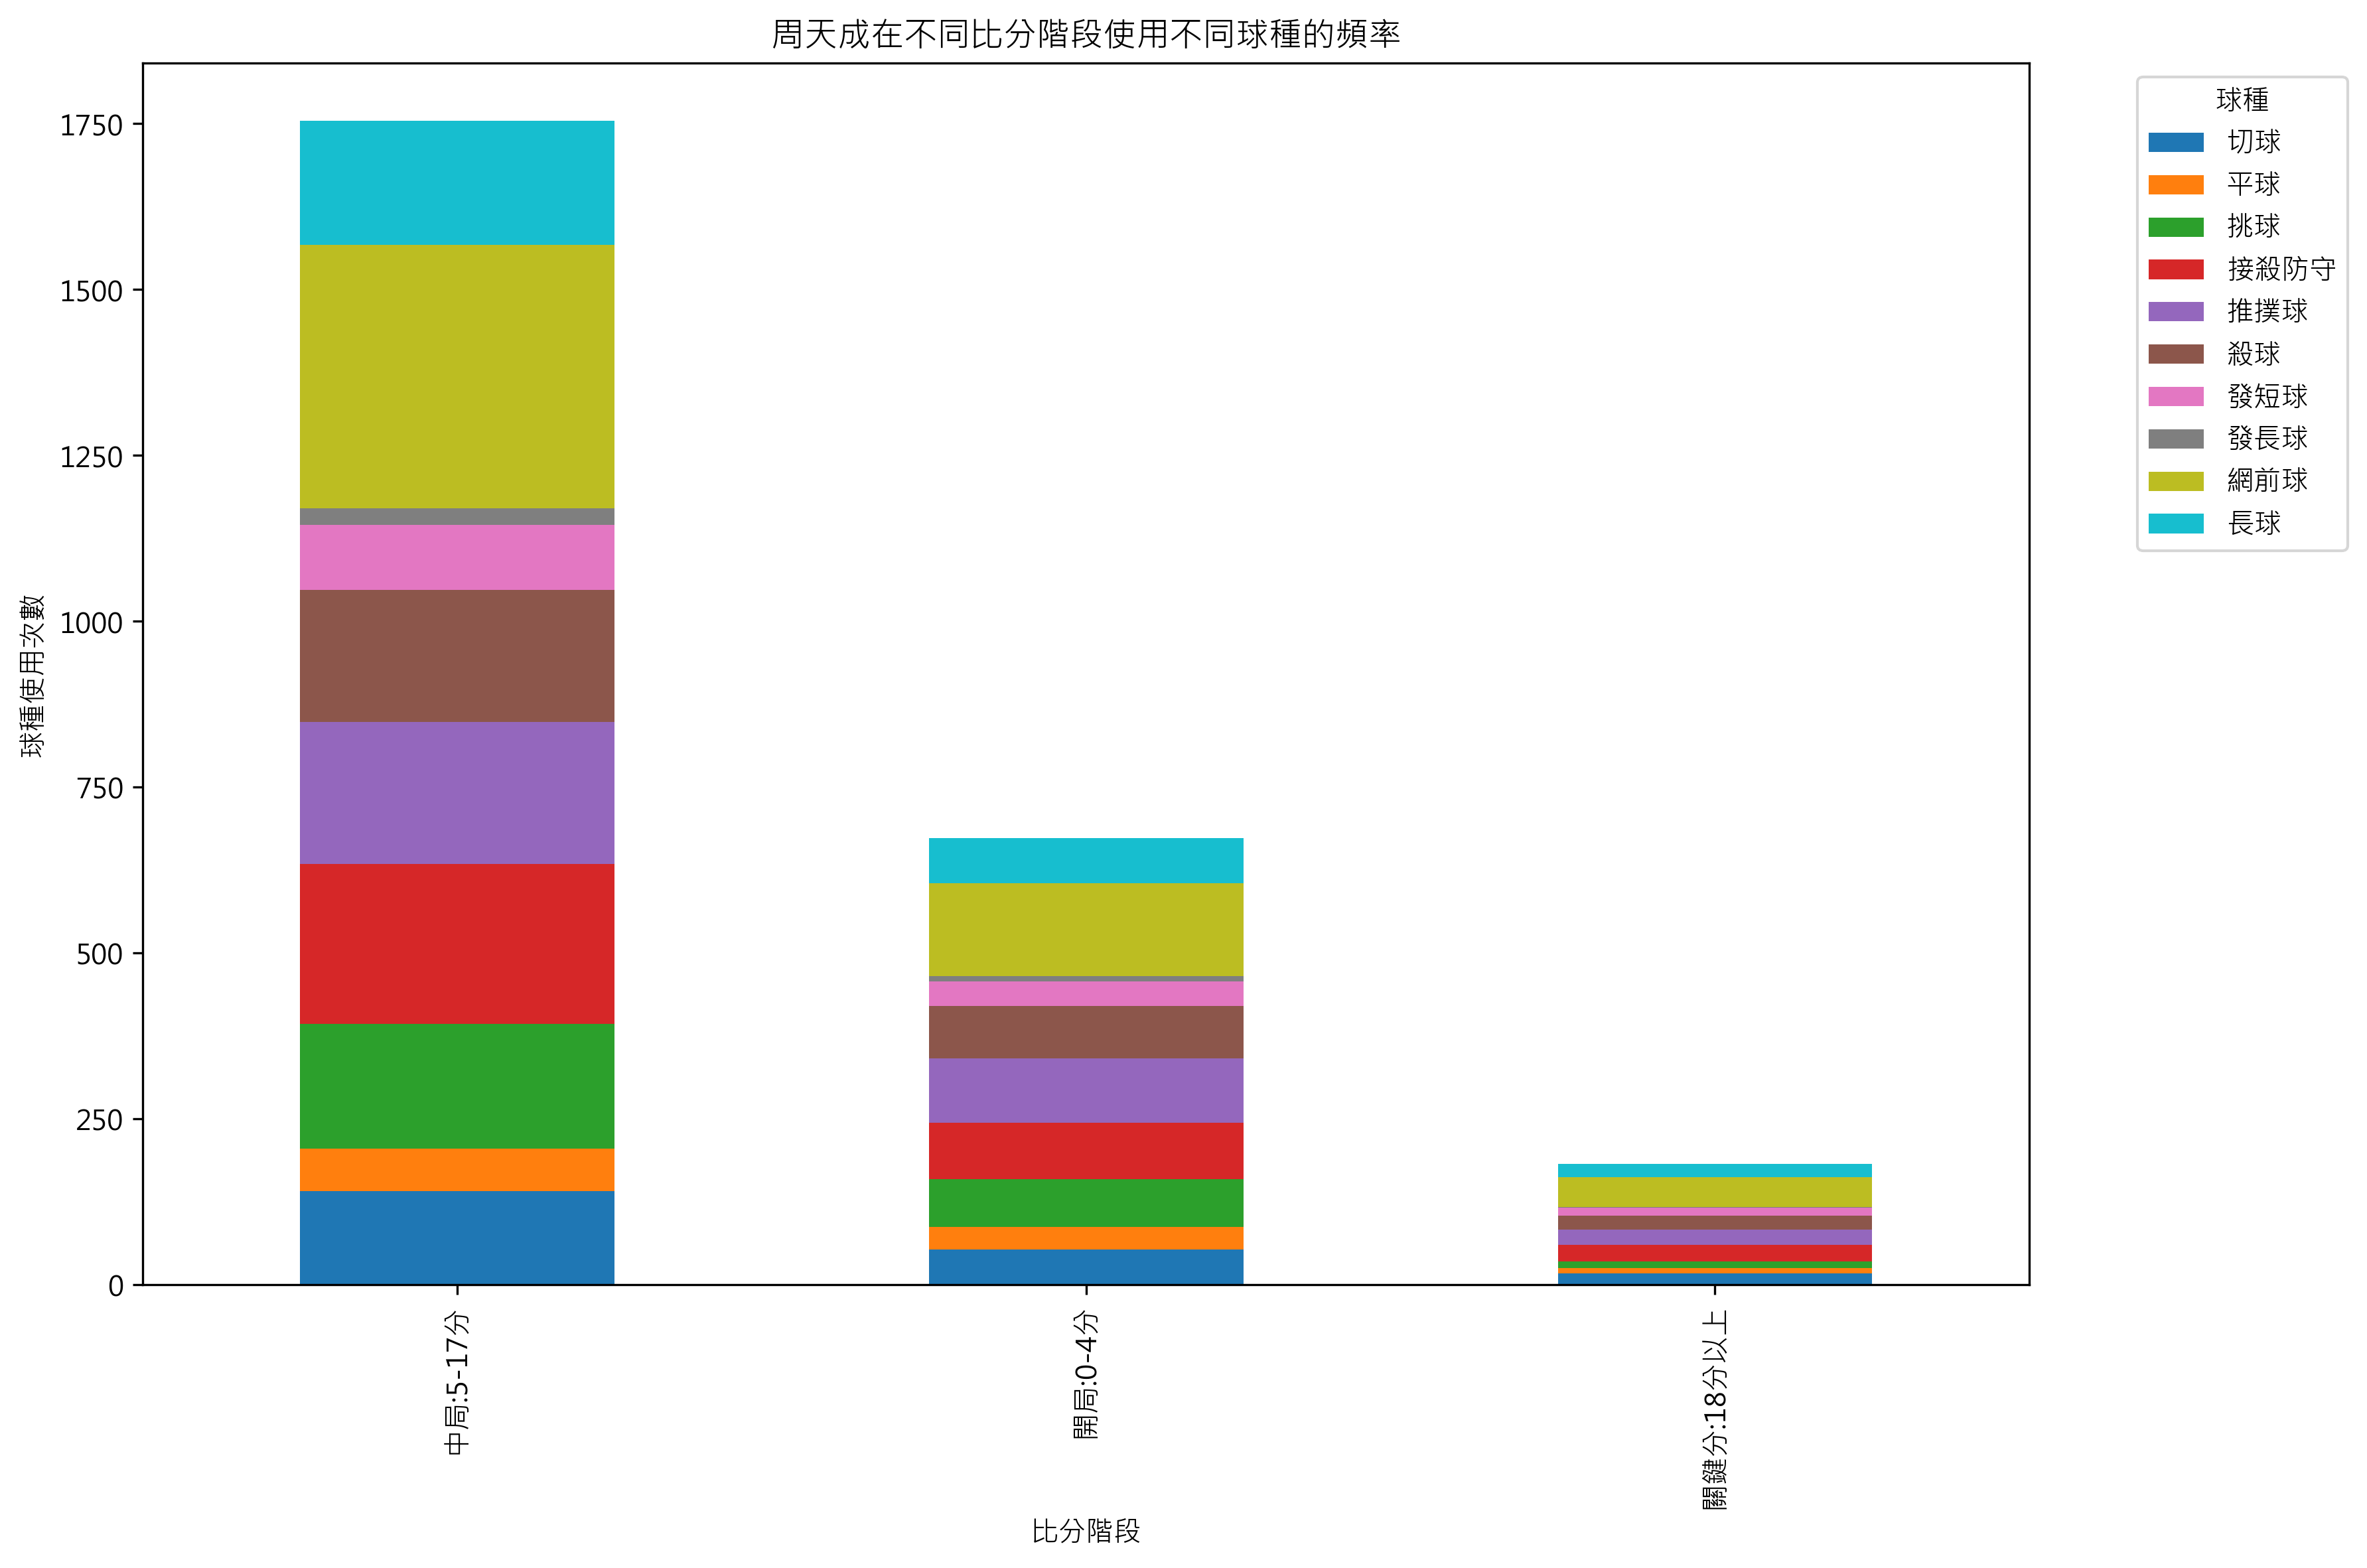

In [ ]:
# 檢查數據量
if len(df) > 0:
    # 確保有周天成的數據
    chou_tien_chen_df = df[df['player'] == 'CHOU Tien Chen']
    
    # 新增比分階段欄位
    def score_stage(score):
        if score <= 4:
            return '開局:0-4分'
        elif score <= 17:
            return '中局:5-17分'
        else:
            return '關鍵分:18分以上'
    
    chou_tien_chen_df['score_stage'] = chou_tien_chen_df['CHOU Tien Chen_score'].apply(score_stage)
    
    # 計算不同比分階段中球種的出現頻率
    shot_type_frequency = chou_tien_chen_df.groupby(['score_stage', 'type']).size().unstack(fill_value=0)
    print(shot_type_frequency)
    
    # 視覺化
    fig, ax = plt.subplots(figsize=(12, 8))
    shot_type_frequency.plot(kind='bar', stacked=True, ax=ax)
    
    # 圖表標籤
    ax.set_title('周天成在不同比分階段使用不同球種的頻率')
    ax.set_xlabel('比分階段')
    ax.set_ylabel('球種使用次數')
    
    # 設置圖例和標籤
    ax.legend(title='球種', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
else:
    print("數據集為空，請檢查資料來源。")


### 數據洞察
在分析周天成於不同比分階段使用球種的頻率變化時，我們可以觀察到以下趨勢：

1. **開局 (0-4分)**：
   - 周天成在開局階段較多使用網前球（140次）和挑球（72次）。這表明他在開局時更傾向於控制網前，並利用挑球來調動對手，可能是為了建立比賽的節奏和掌控局面。

2. **中局 (5-17分)**：
   - 在中局階段，周天成的網前球使用頻率顯著增加（397次），同時挑球（188次）和接殺防守（241次）的頻率也較高。這顯示他在這個階段更專注於防守和反擊，利用網前球和挑球來消耗對手體力，並以接殺防守來化解對手的攻勢。

3. **關鍵分 (18分以上)**：
   - 在關鍵分階段，周天成的球種選擇更為謹慎，網前球（45次）和接殺防守（25次）仍然是主要選擇。這反映出他在關鍵時刻更注重穩定性，利用網前球來維持控球權，並以接殺防守來確保不失分。

總體而言，周天成在不同比分階段的球種選擇顯示出他的戰術靈活性和對比賽節奏的掌控能力。他在開局階段建立節奏，中局階段加強防守，並在關鍵分時保持穩定，這些策略都有助於他在比賽中取得優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 將比分階段劃分為開局 (0-4分)、中局 (5-17分)、關鍵分 (18分以上)，並計算各階段內不同球種的使用頻率。候選程式碼在劃分比分階段時，使用了 <= 4 和 <= 17 的條件，這與 Reference Code 1 的 < 5 和 < 18 不一致，導致比分階段劃分錯誤。此外，候選程式碼計算的是球種使用次數，而非使用頻率，統計口徑不符。




## 題號 23 (*)
**問題**: 在關鍵分(18分以上)時，周天成採用的擊球策略與其他階段有何不同？


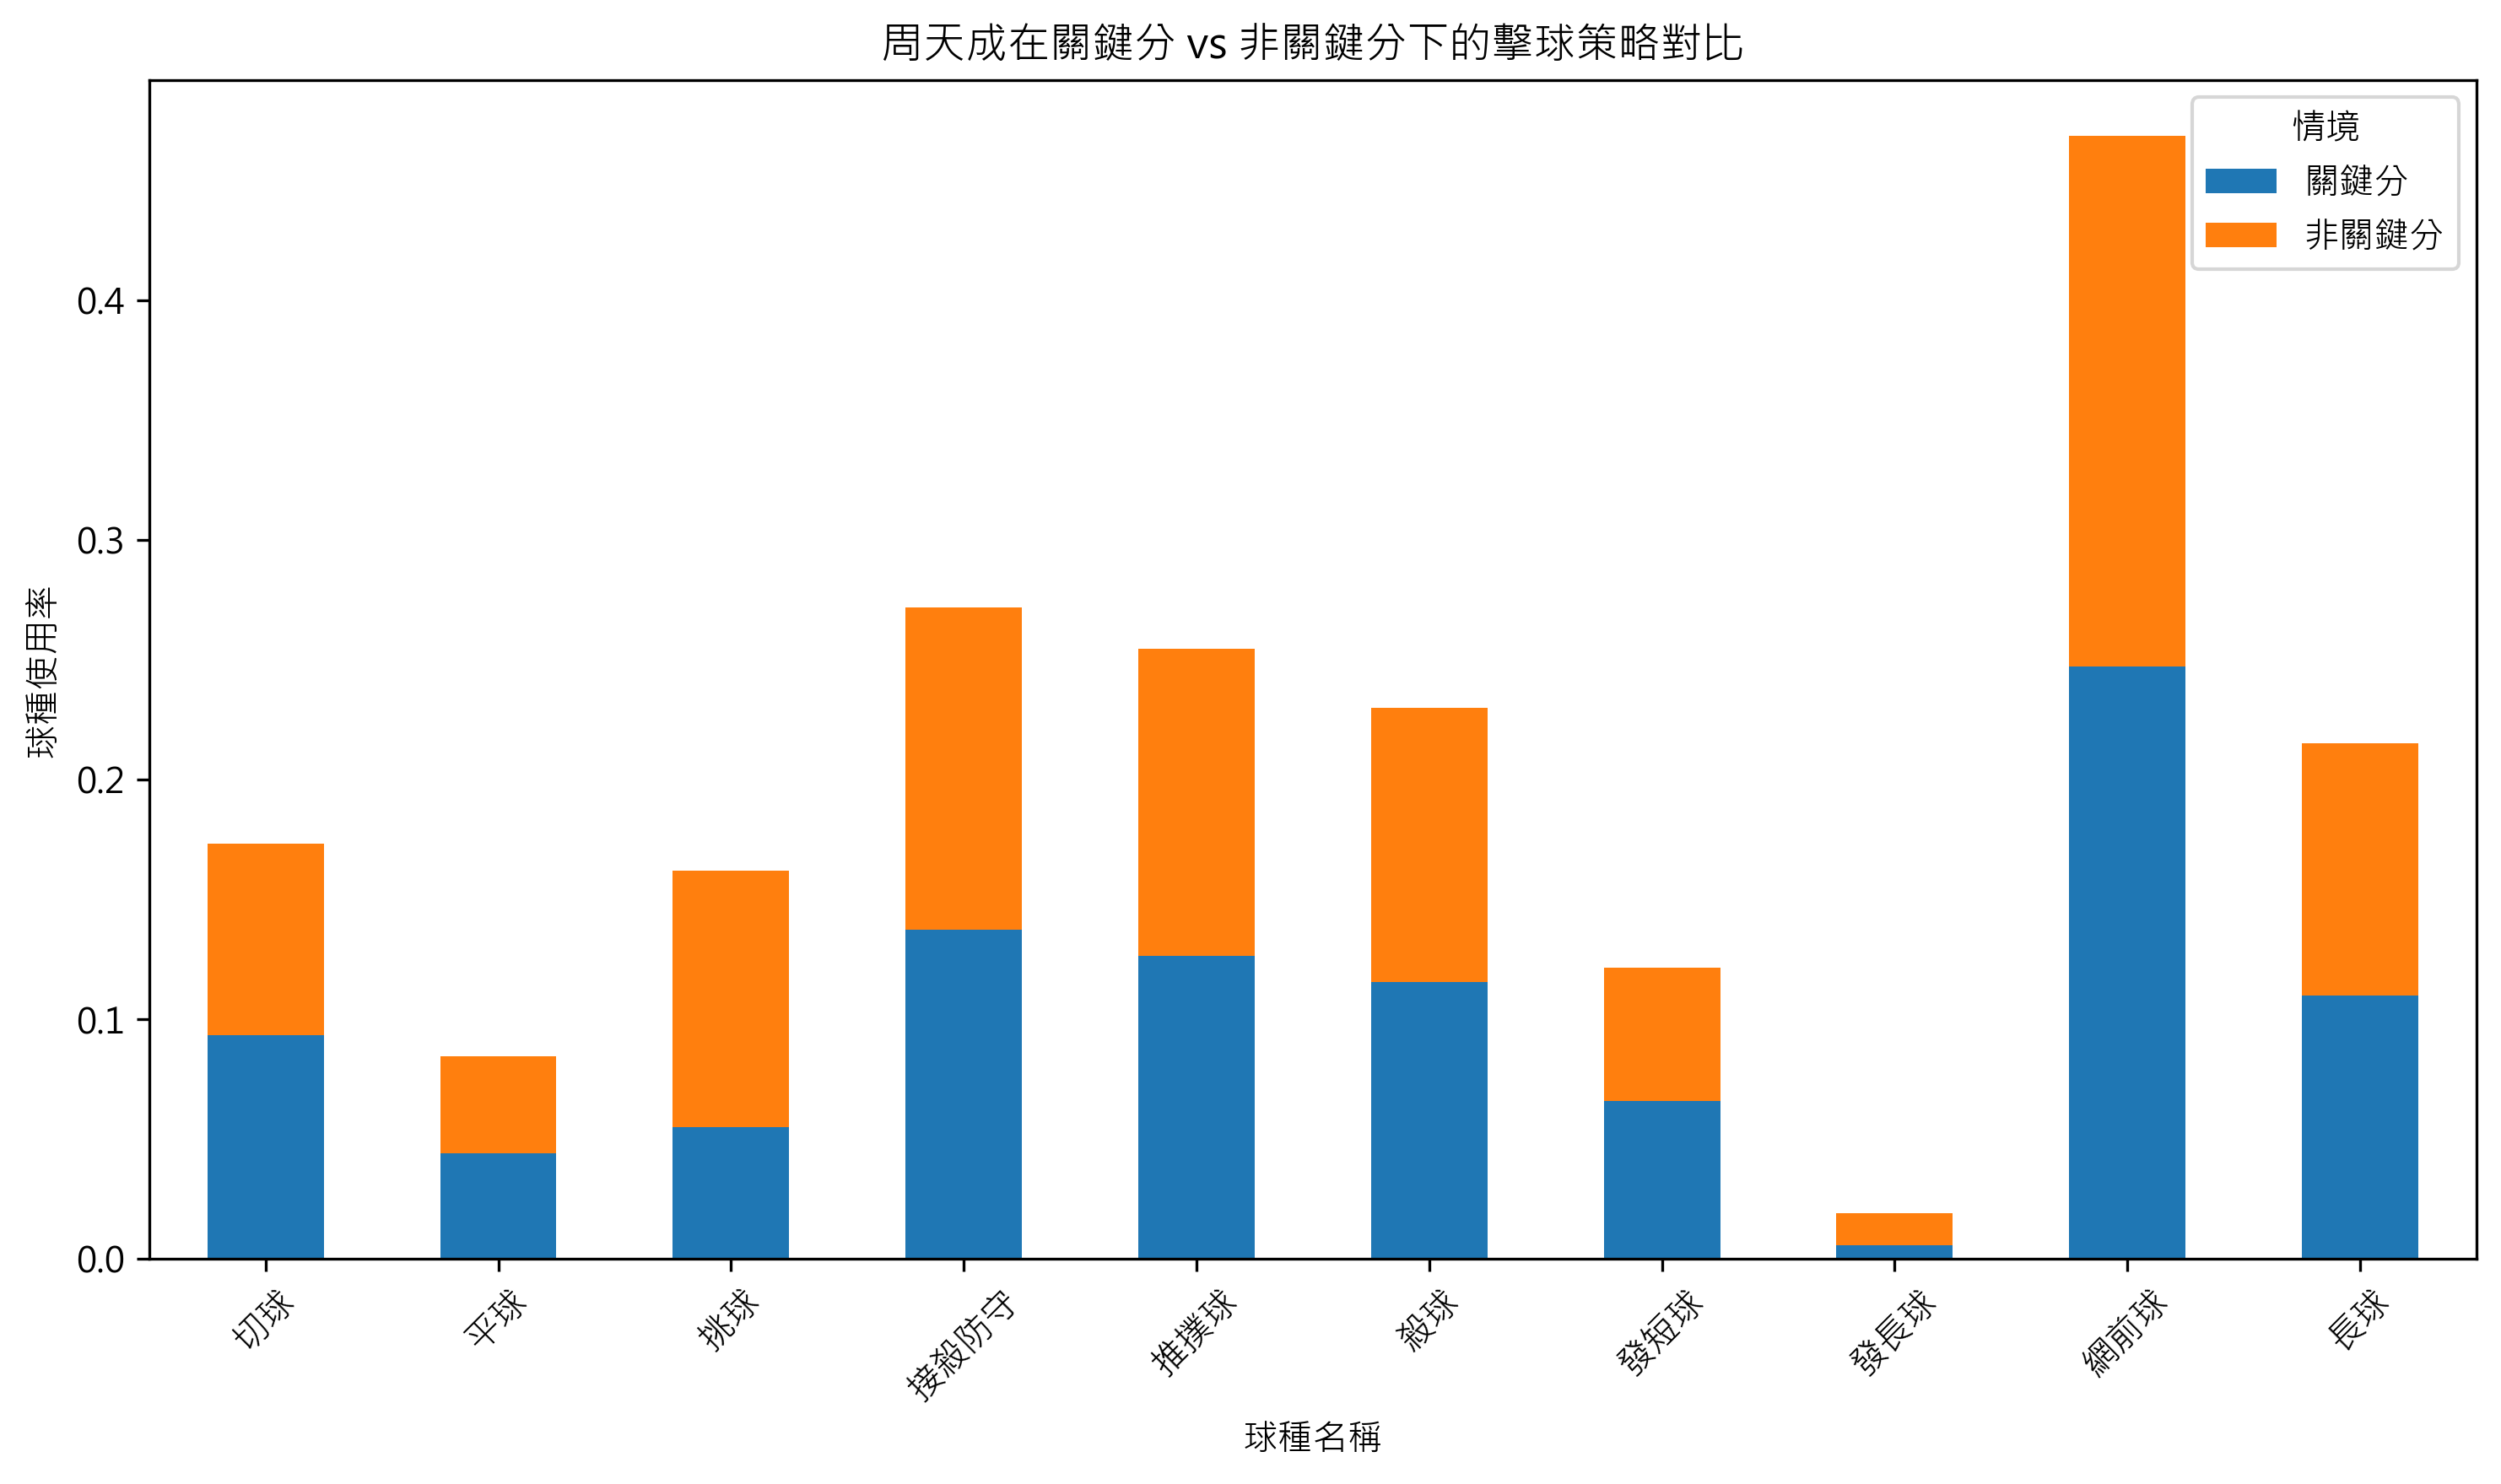

In [ ]:
# 先確保數據量充足
if len(df) > 0:
    
    # 將比分分為關鍵分（18分以上）與非關鍵分
    key_points_condition = df['CHOU Tien Chen_score'] >= 18
    non_key_points_condition = df['CHOU Tien Chen_score'] < 18

    # 篩選周天成在關鍵分和非關鍵分下的數據
    chou_key_points_df = df[(df['player'] == 'CHOU Tien Chen') & key_points_condition]
    chou_non_key_points_df = df[(df['player'] == 'CHOU Tien Chen') & non_key_points_condition]

    # 計算每個情境下的球種統計
    key_points_type_distribution = chou_key_points_df['type'].value_counts(normalize=True)
    non_key_points_type_distribution = chou_non_key_points_df['type'].value_counts(normalize=True)

    # 合併結果以便比較
    comparison_df = pd.DataFrame({
        '關鍵分': key_points_type_distribution,
        '非關鍵分': non_key_points_type_distribution
    }).fillna(0)  # 若某球種在其中一個情境未出現，則填 0

    # 繪圖
    fig, ax = plt.subplots(figsize=(10, 6))
    comparison_df.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title('周天成在關鍵分 vs 非關鍵分下的擊球策略對比')
    ax.set_ylabel('球種使用率')
    ax.set_xlabel('球種名稱')
    ax.legend(title='情境')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # 打印關鍵策略差異
    print("周天成在不同分數情境下的擊球策略差異：")
    print(comparison_df)

else:
    print("數據集為空，無法進行分析。")


### 數據洞察
在關鍵分階段，周天成的擊球策略顯示出一些顯著的調整。以下是數據所揭示的事實：

1. **切球**：在關鍵分時，周天成增加了切球的使用頻率（9.34%），相較於非關鍵分（7.99%）。這表明他在緊要關頭更傾向於使用切球來控制比賽節奏，可能是為了降低對手的進攻機會。

2. **挑球**：挑球的使用頻率在關鍵分時下降至5.49%，而非關鍵分時為10.71%。這顯示他在關鍵時刻更少使用挑球，可能是為了避免給對手創造進攻機會。

3. **發短球**：在關鍵分時，發短球的使用頻率增加到6.59%，這可能是為了在發球時創造更有利的進攻位置。

4. **網前球**：網前球的使用頻率在關鍵分時增加到24.73%，這表明周天成在關鍵時刻更積極地控制網前，試圖快速結束回合。

這些數據顯示，周天成在關鍵分時更傾向於使用控制型的擊球策略，減少風險，並試圖通過控制網前來掌握比賽的主動權。這樣的策略調整可能有助於他在緊張時刻穩住局勢並爭取勝利。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在分析關鍵分與非關鍵分時，僅考慮了周天成的得分，而忽略了對手的得分情況。這與 Reference Code 2 的核心邏輯不符，因為 Reference Code 2 將關鍵分定義為任一方得分達到18分以上。此外，候選程式碼在計算球種分布時，沒有考慮到可能的前後拍關係，這可能導致統計口徑錯誤。因此，候選程式碼不符合任何一份 Reference Code 的核心邏輯。




## 題號 24 (*)
**問題**: 周天成在長回合相較於短回合較常失誤的球種?


In [ ]:
# 確保數據集非空
if len(df) == 0:
    raise ValueError("DataFrame is empty. Cannot perform analysis.")

# 定義長短回合的界限。假設使用常見標準：長回合定義為10拍以上。
long_rally_threshold = 10

# 過濾出周天成的數據
chou_df = df[df['player'] == 'CHOU Tien Chen']

# 確認「失誤」的定義條件
chou_mistakes = chou_df[chou_df['lose_reason'].notna()]

# 獲取每個回合的拍數
rally_lengths = df.groupby(['match_id', 'set', 'rally'])['ball_round'].max()

# 合併拍數資訊
chou_mistakes = chou_mistakes.merge(rally_lengths, on=['match_id', 'set', 'rally'], suffixes=('', '_rally_length'))

# 區分長回合與短回合
chou_mistakes['rally_type'] = chou_mistakes['ball_round_rally_length'].apply(lambda x: '長回合' if x >= long_rally_threshold else '短回合')

# 計算各類球種的失誤次數
mistake_counts = chou_mistakes.groupby(['rally_type', 'type']).size().unstack(fill_value=0)

# 計算長短回合中每種類型的相對頻率
mistake_relative_counts = mistake_counts.div(mistake_counts.sum(axis=1), axis=0) * 100

# 比較並找出長回合中相對比例更高的失誤球種
result = mistake_relative_counts.loc['長回合'] - mistake_relative_counts.loc['短回合']

# 輸出結果
print("周天成在長回合相較於短回合較常失誤的球種及其比例差異:")
print(result.sort_values(ascending=False))


### 數據洞察
根據數據分析，周天成在長回合中相較於短回合最常失誤的球種是「長球」，其比例差異為6.52%。這意味著在長時間的回合中，他在處理長球時更容易出現失誤。其次是「推撲球」和「切球」，分別有2.90%和2.54%的比例差異。

這些數據顯示，當回合持續時間較長時，周天成在處理後場球種時的穩定性下降，特別是在長球的處理上。因此，在戰術上，對手可以考慮在長回合中多利用長球來施壓，增加周天成的失誤機會。這樣的策略可能會讓他在長時間的對抗中更容易犯錯。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是基於每個回合的最後一拍來計算失誤率，而候選程式碼直接在逐拍資料上篩選失誤，並未正確對齊每個回合的最終狀態。此外，候選程式碼在計算失誤次數時，沒有考慮到 'getpoint_player' 欄位的使用，這可能導致統計口徑錯誤。




## 題號 25 (*)
**問題**: 當對手靠球場兩側時，周天成較常讓球落點到哪些區域？繪製熱區圖。


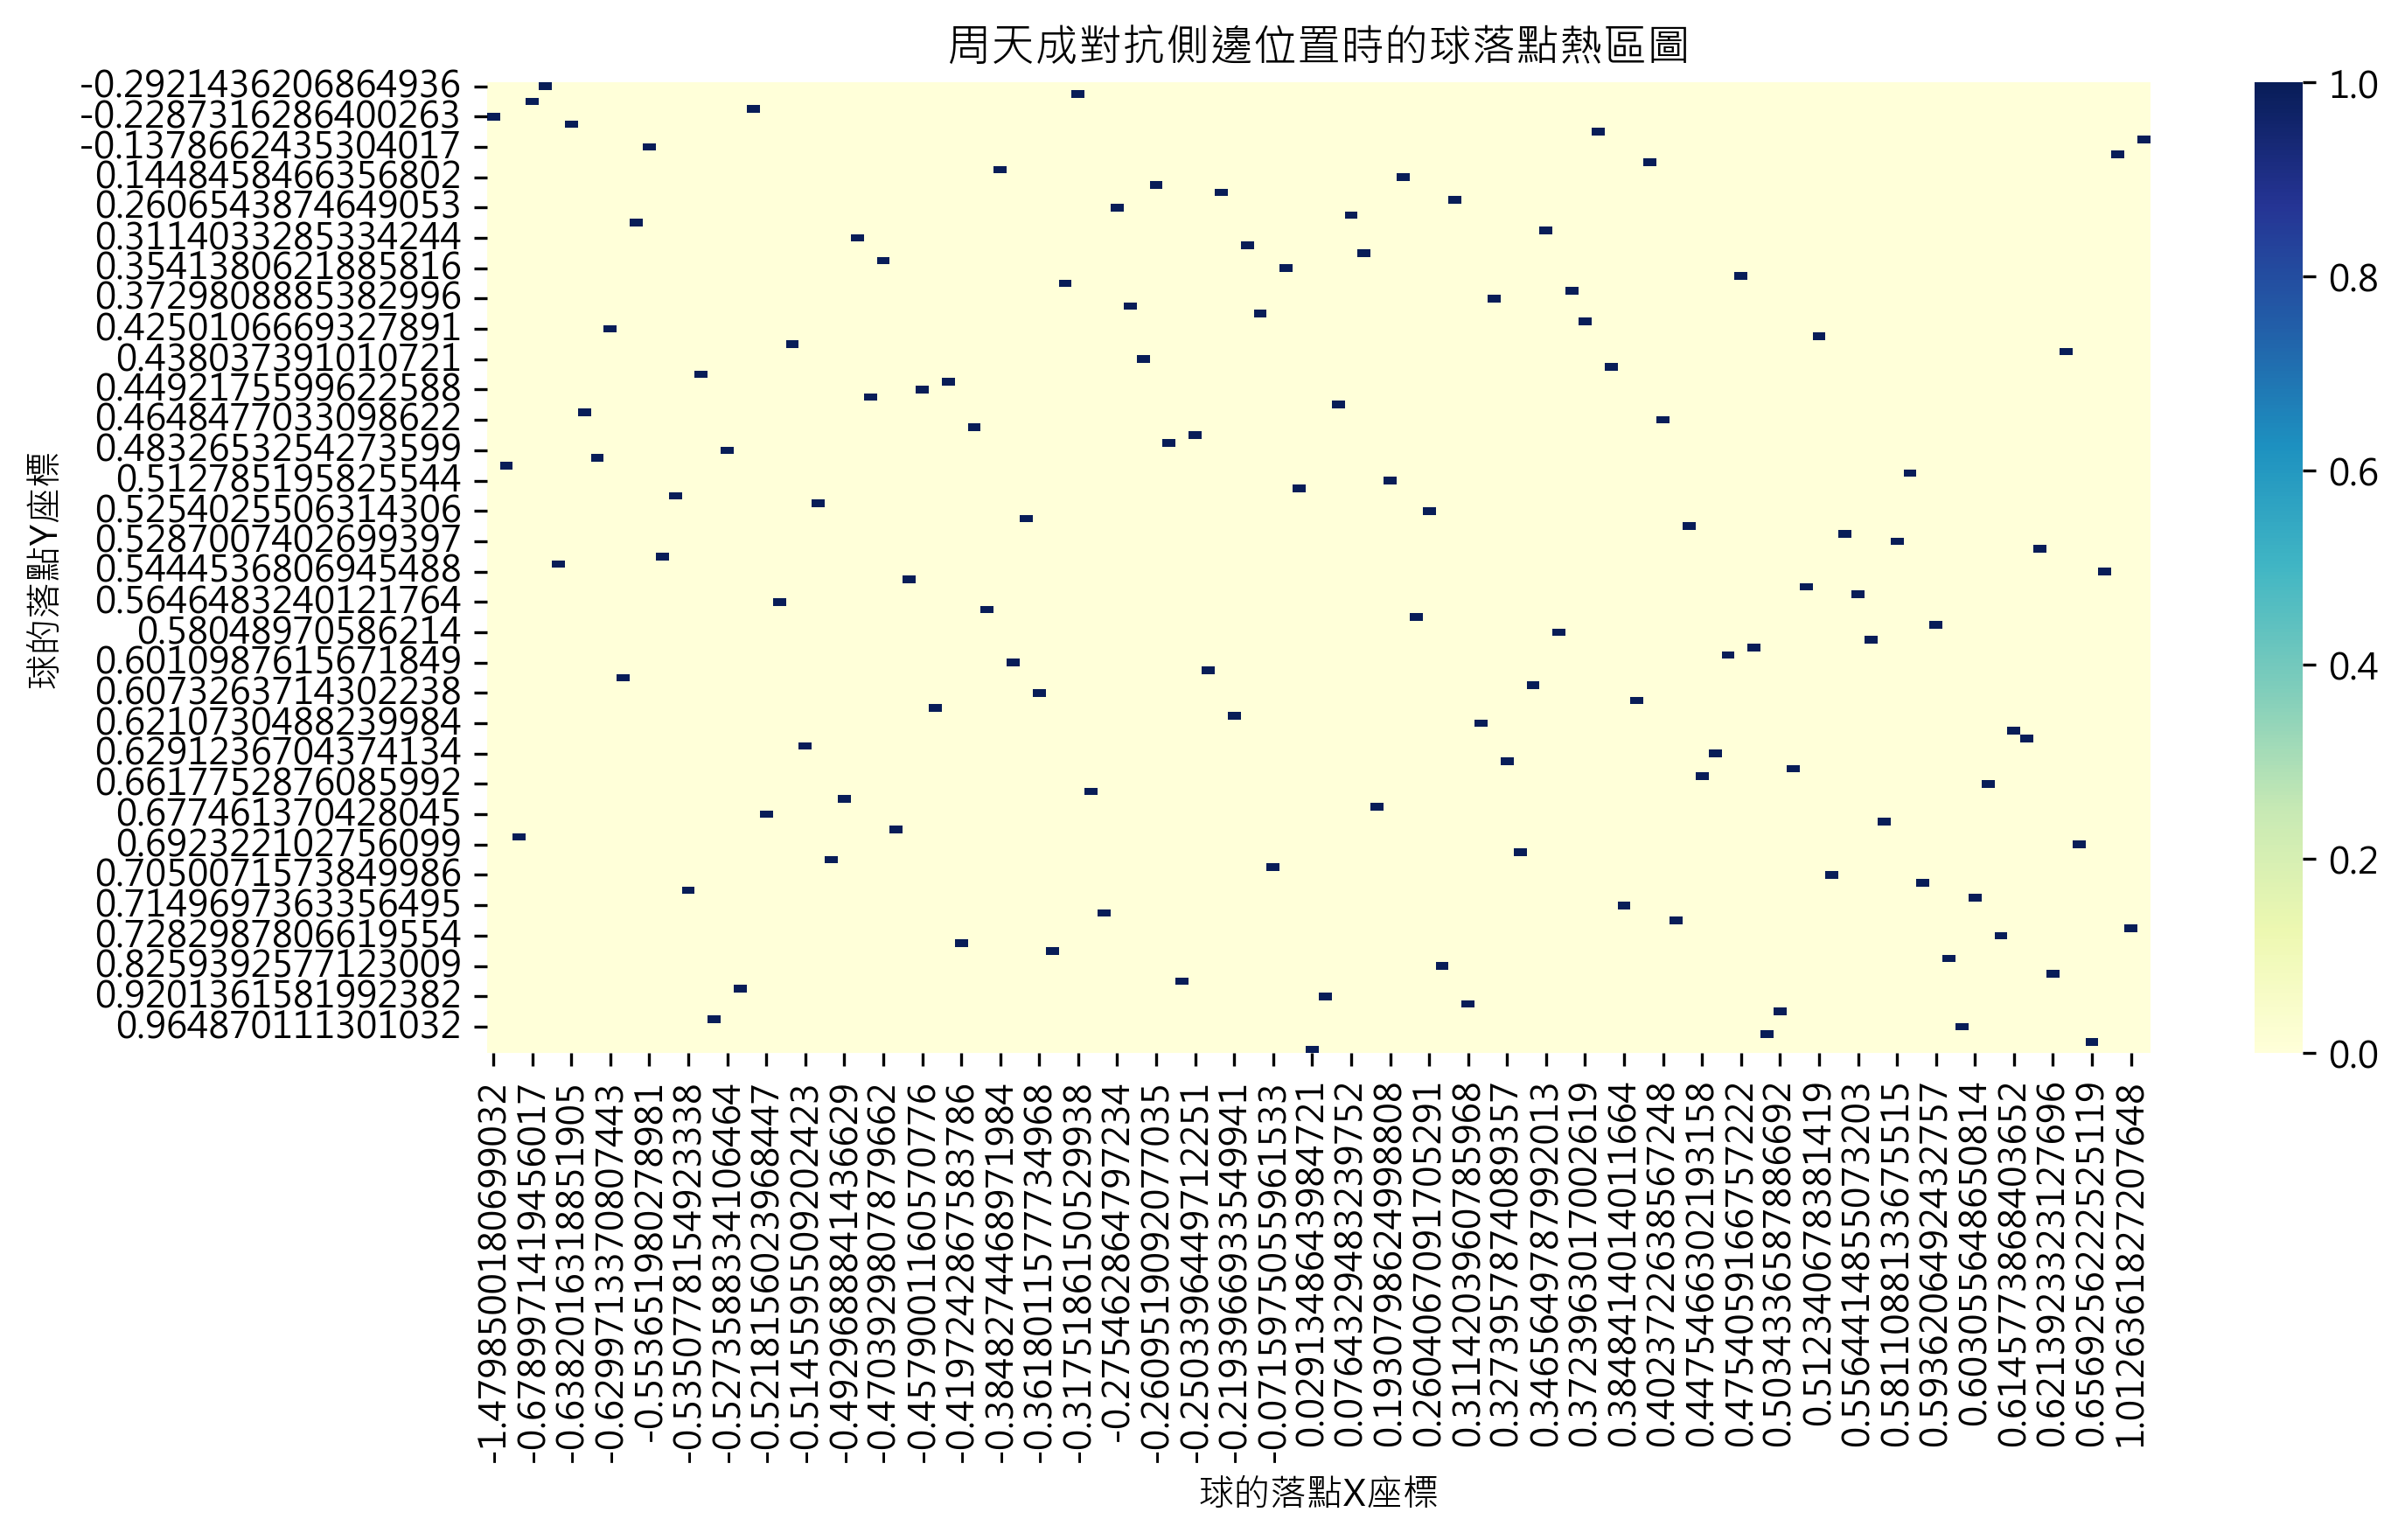

In [ ]:
# 篩選出對手位於球場側邊時的數據
# 對手的兩側主要在後排的1, 2, 3, 4區; 中排的5, 8區以及側面出界區域
side_zones = [1, 2, 3, 4, 5, 8, 27, 25, 26, 28, 29, 30, 31, 32]
filtered_df = df[(df['opponent'] == 'Kento MOMOTA') & (df['opponent_location_area'].isin(side_zones))]

# 確認有數據
if len(filtered_df) > 0:
    # 繪製landing_area的熱區圖
    pivot_table = filtered_df.pivot_table(index='landing_y', columns='landing_x', aggfunc='size', fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot_table, cmap='YlGnBu', ax=ax)
    ax.set_title('周天成對抗側邊位置時的球落點熱區圖')
    ax.set_xlabel('球的落點X座標')
    ax.set_ylabel('球的落點Y座標')

    plt.tight_layout()

    # 打印關鍵區域統計數據
    landing_area_counts = filtered_df['landing_area'].value_counts().sort_index()
    print("各落點位置的次數分佈：")
    print(landing_area_counts)
else:
    print("數據集中沒有符合條件的行為。")


### 數據洞察
根據數據，當對手靠近球場兩側時，周天成的球落點主要集中在以下區域：

1. **Row 5 (Front)** 的 Col D (Right) 區域，即落點20，出現了22次。
2. **Row 4 (Mid)** 的 Col A (Left) 區域，即落點13，出現了13次。
3. **Row 4 (Mid)** 的 Col D (Right) 區域，即落點16，出現了4次。
4. **Row 5 (Front)** 的 Col A (Left) 區域，即落點17，出現了13次。
5. **Row 5 (Front)** 的 Col B (C-Left) 區域，即落點18，出現了9次。
6. **Row 5 (Front)** 的 Col C (C-Right) 區域，即落點19，出現了11次。

這些數據顯示，周天成在對手靠近球場兩側時，常利用中前場的落點來施壓，尤其是右側的前場區域（落點20）。這樣的策略可能是為了讓對手在移動後難以迅速回防，從而創造進攻機會。這些落點選擇顯示出他對於空間的掌控與對手位置的精準利用。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 的核心邏輯是篩選周天成擊球，且對手站在球場兩側的資料，然後繪製周天成的落點熱區圖。而候選程式碼篩選的是對手 Kento MOMOTA 位於球場側邊時的數據，並且繪製的是周天成對抗側邊位置時的球落點熱區圖，這與題目要求的分析對象不符。此外，候選程式碼的篩選條件和統計口徑也與 Reference Code 不一致。




## 題號 26 (*)
**問題**: 分析周天成在不同局（第 1 局、第 2 局、第 3 局）殺球比重變化。


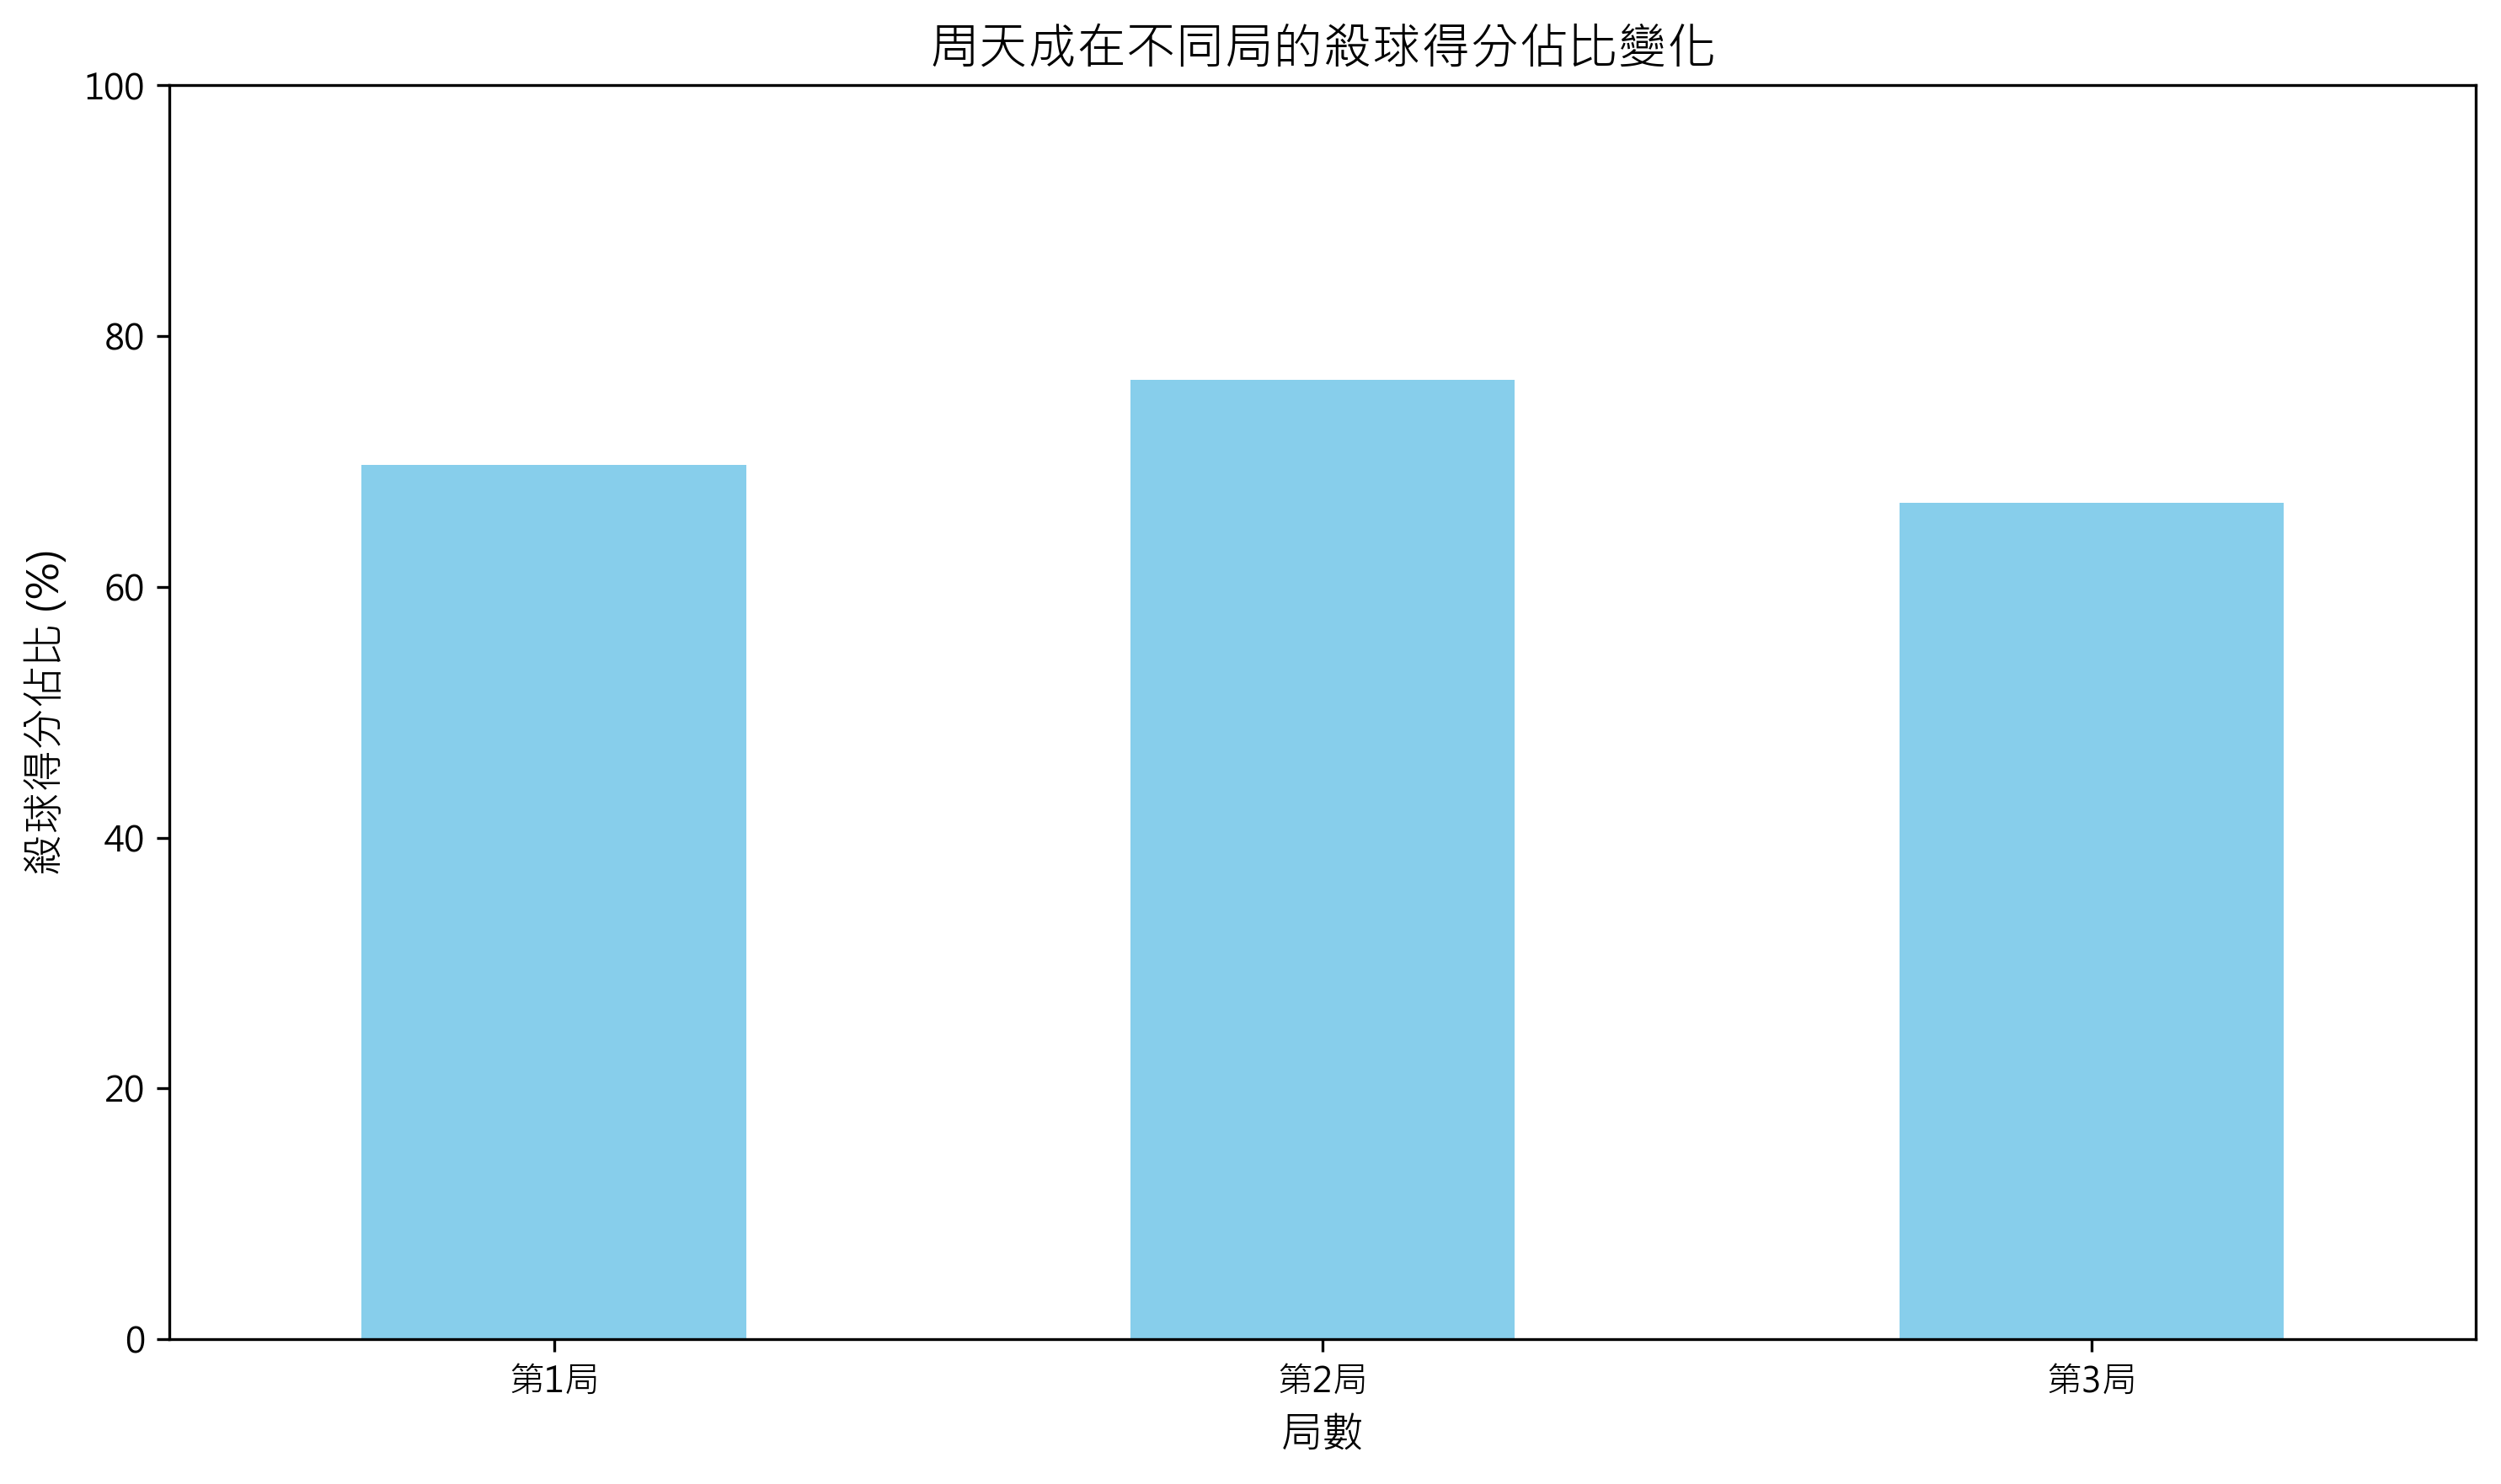

In [ ]:
# 確保數據存在且不為空
if len(df) > 0:
    # 計算每局的總主動得分（周天成）
    df_active_win = df[(df['getpoint_player'] == 'CHOU Tien Chen') & (df['player'] == 'CHOU Tien Chen')]
    
    # 計算每局的殺球主動得分次數
    df_chou_kill = df_active_win[df_active_win['type'] == '殺球']

    # 使用 groupby 計算每局的殺球主動得分及總主動得分
    kill_counts_by_set = df_chou_kill.groupby('set').size()
    active_win_counts_by_set = df_active_win.groupby('set').size()

    # 計算殺球得分佔比
    kill_ratio_by_set = (kill_counts_by_set / active_win_counts_by_set) * 100  # 轉換為百分比

    # 打印關鍵統計數據
    print("周天成在各局的殺球得分佔比變化：")
    print(kill_ratio_by_set)

    # 繪製殺球得分比重變化圖
    fig, ax = plt.subplots(figsize=(10, 6))
    kill_ratio_by_set.plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title('周天成在不同局的殺球得分佔比變化', fontsize=14)
    ax.set_xlabel('局數', fontsize=12)
    ax.set_ylabel('殺球得分佔比 (%)', fontsize=12)
    ax.set_ylim(0, 100)  # 百分比範圍
    ax.set_xticklabels(['第1局', '第2局', '第3局'], rotation=0)
    plt.tight_layout()
else:
    print("數據框內沒有足夠的數據可供分析。")


### 數據洞察
周天成在不同局的殺球得分佔比變化顯示明顯的波動。第一局，他的殺球得分佔比為69.70%，第二局上升到76.47%，但在第三局又下降到66.67%。

這些數據表明，周天成在第二局的殺球攻擊更具效率，可能是因為他在這一局中找到了對手防守的弱點，或者是他在這一局中體能和專注度達到了高峰。然而，第三局的下降則可能顯示出對手對他的殺球策略進行了有效的調整，或者是周天成自身的體能和專注度有所下降。

作為教練，我們需要關注他在不同局中的體能管理和戰術調整，特別是在比賽進入關鍵的第三局時，如何保持殺球的效率和威脅性。這可能需要在比賽中進行更多的變化和假動作，來迷惑對手並創造更多的進攻機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是計算周天成在不同局的殺球比重，即殺球次數佔總擊球數的比例。而候選程式碼計算的是殺球主動得分佔總主動得分的比例，這與 Reference Code 1 的統計口徑不同。此外，候選程式碼的分析單位是主動得分，而不是所有擊球，這也與題目要求的殺球比重分析不符。




## 題號 27
**問題**: 分析周天成在「邊線附近擊球」的失誤率是否偏高。


In [ ]:
# 確保資料長度大於0
if len(df) > 0:
    # 過濾出周天成的擊球
    chou_tien_chen_hits = df[df['player'] == 'CHOU Tien Chen']
    
    # 過濾出邊線附近的擊球
    side_near_hits = chou_tien_chen_hits[chou_tien_chen_hits['hit_area'].isin([1, 5, 9, 13, 17, 21, 4, 8, 12, 16, 20, 24])]
    
    # 計算邊線附近的總擊球次數
    total_side_near_hits = len(side_near_hits)
    
    # 過濾出失誤（即周天成擊球導致對手得分)
    side_near_mistakes = side_near_hits[(side_near_hits['getpoint_player'] != 'CHOU Tien Chen') & (~side_near_hits['lose_reason'].isna())]

    # 計算邊線附近的失誤次數
    total_side_near_mistakes = len(side_near_mistakes)

    # 計算失誤率
    if total_side_near_hits > 0:
        mistake_rate = total_side_near_mistakes / total_side_near_hits
    else:
        mistake_rate = 0

    print(f"周天成在邊線附近的擊球總數: {total_side_near_hits}")
    print(f"周天成在邊線附近的失誤總數: {total_side_near_mistakes}")
    print(f"周天成在邊線附近的失誤率: {mistake_rate:.2%}")
else:
    print("資料為空，無法進行分析")


### 數據洞察
周天成在邊線附近的擊球失誤率為6.14%，這是一個相對穩定的數字。這意味著他在邊線附近的擊球表現相對穩定，失誤率不算高。這樣的表現對於維持場上優勢是有利的，因為在邊線附近擊球通常需要較高的精準度和戰術意識。這數據顯示他在這方面的訓練和技術應用得當，能有效地控制比賽節奏。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地過濾了周天成的擊球，並識別了邊線附近的擊球區域。然後，它計算了邊線附近的失誤次數和總擊球次數，並計算了失誤率。這與 Reference Code 1 的分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標一致。




## 題號 28
**問題**: 統計周天成在各局的平均每回合拍數，並比較第1局、第2局、第3局差異。


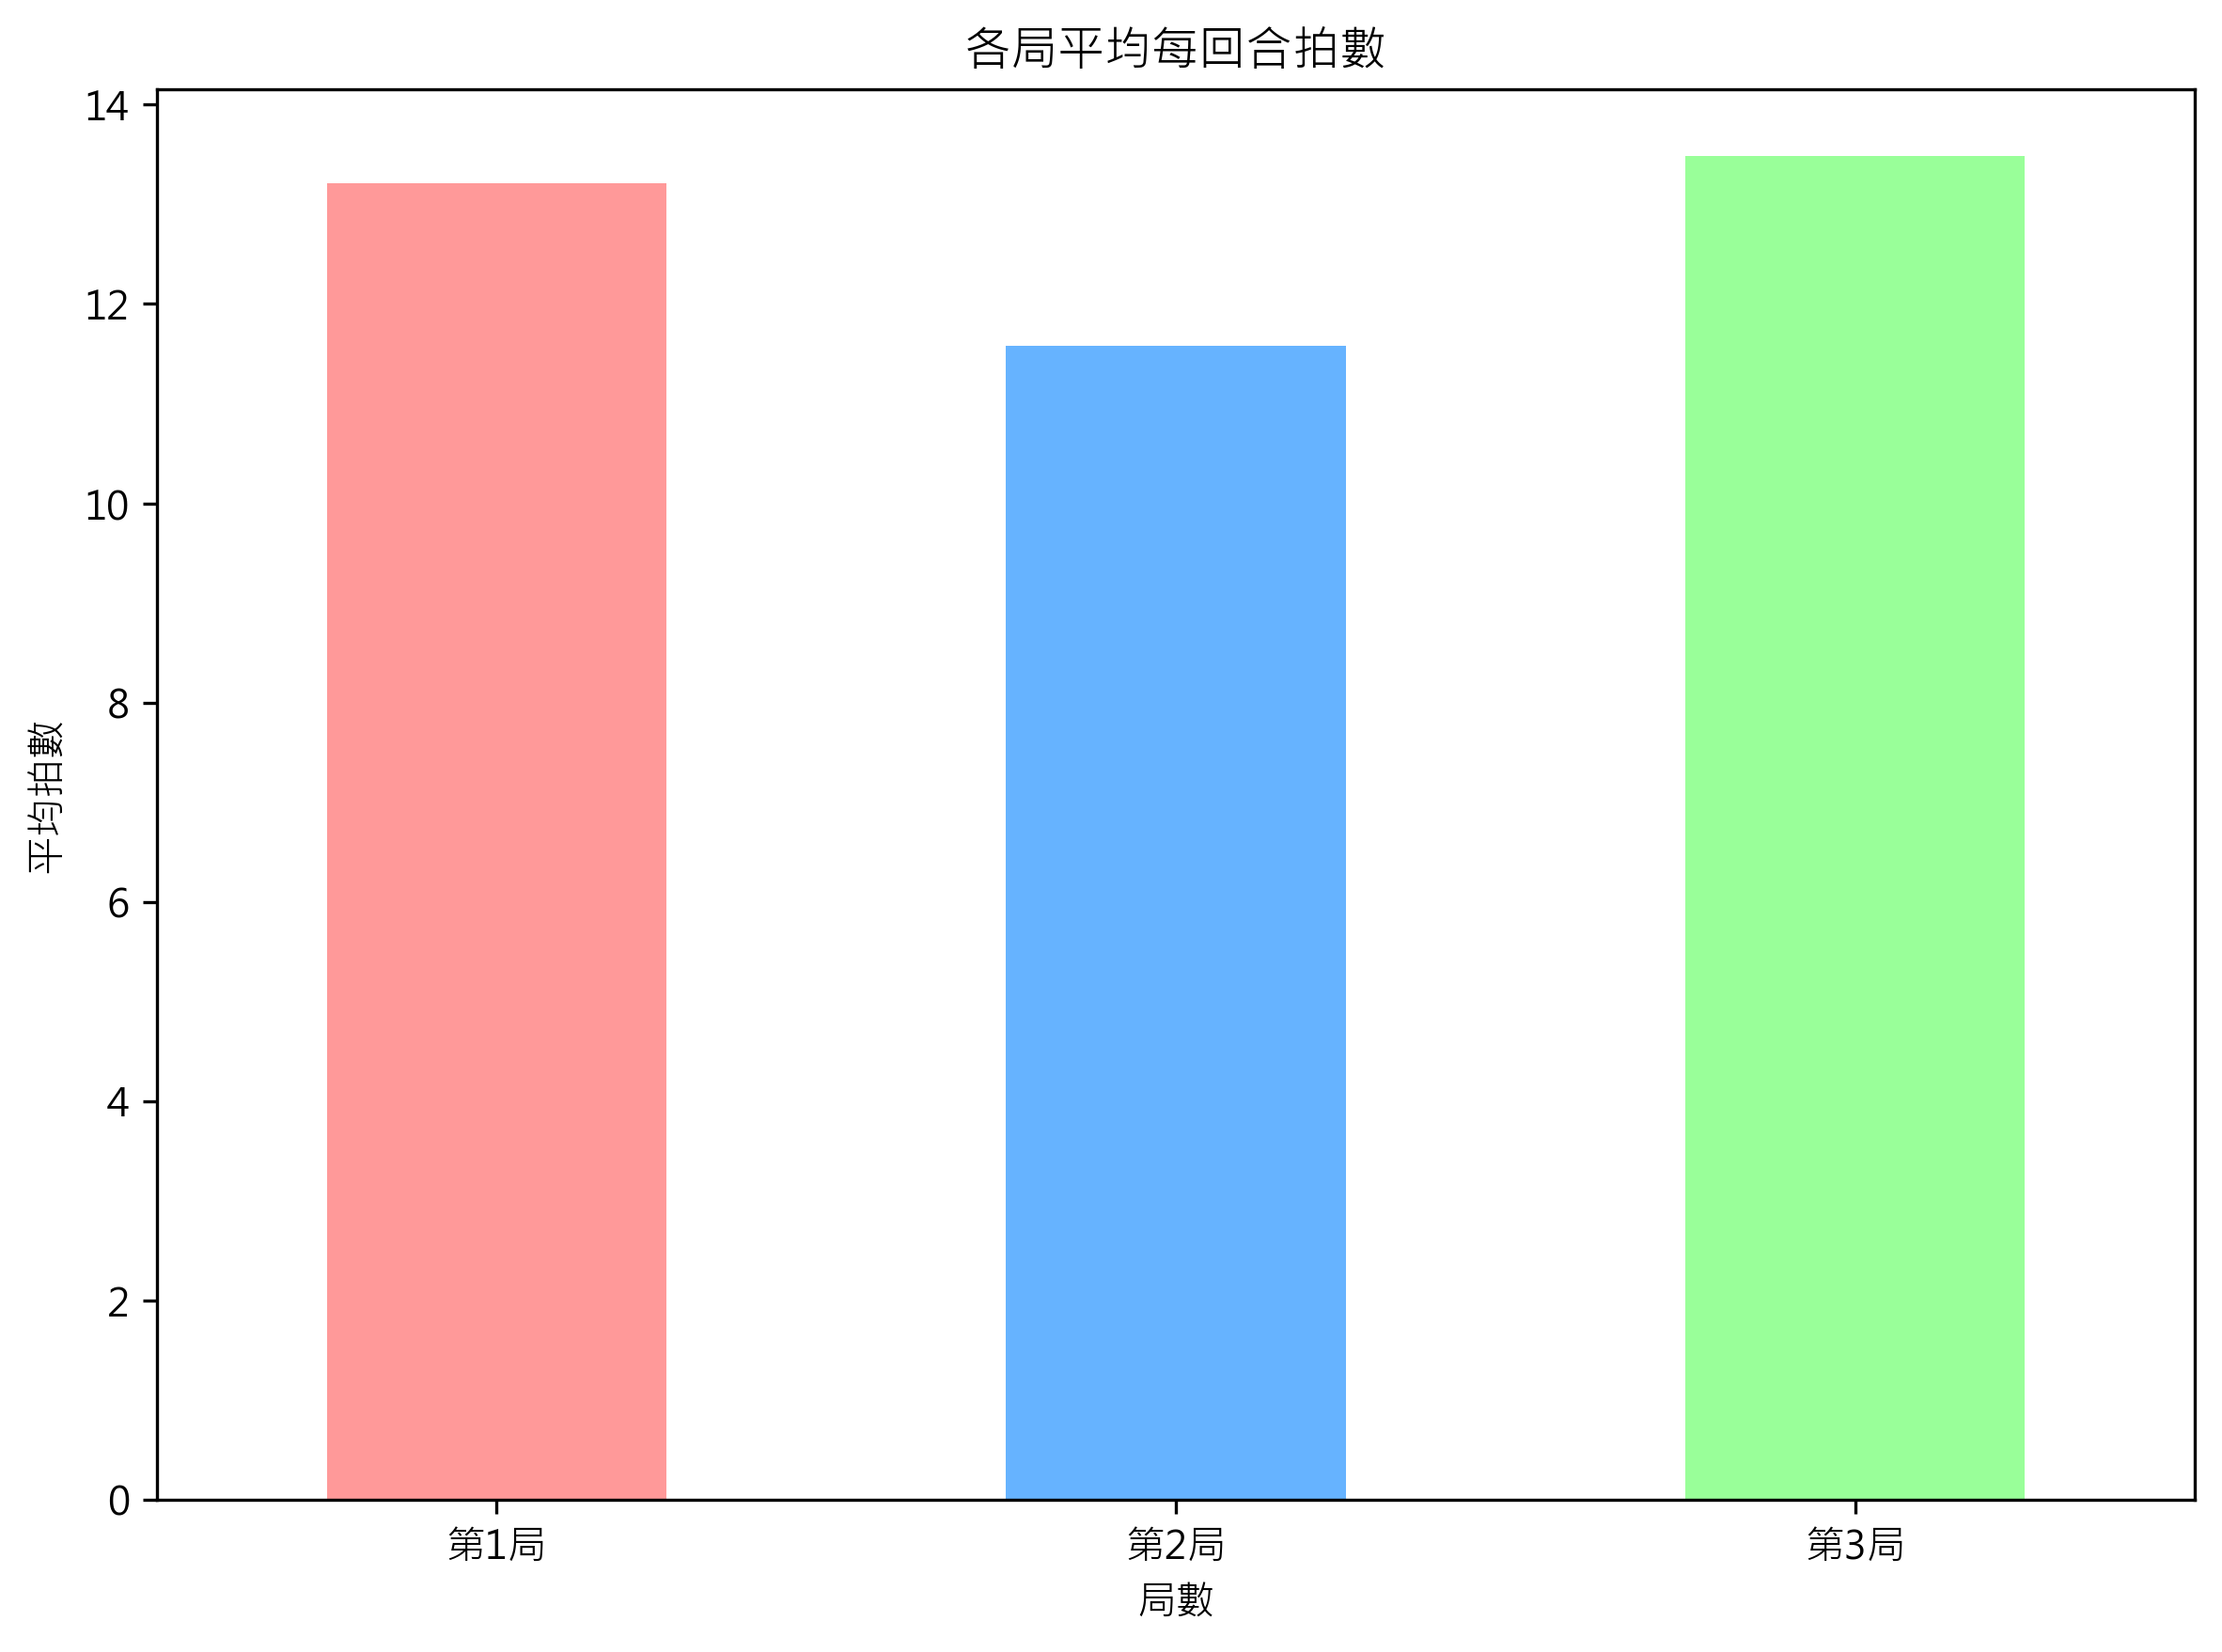

In [ ]:
# 確保數據框中有數據
if len(df) > 0:
    # 按照 match_id 和 set 分組，計算每回合的拍數，即最大 ball_round
    rally_data = df.groupby(['match_id', 'set', 'rally'])['ball_round'].max().reset_index()
    
    # 計算各局平均每回合的拍數
    average_rallies_per_set = rally_data.groupby('set')['ball_round'].mean()
    
    # 打印出來查看每局的平均拍數
    print("各局平均每回合拍數:")
    for set_number, avg_rallies in average_rallies_per_set.items():
        print(f"第 {set_number} 局: {avg_rallies:.2f} 拍")

    # 繪製圖表
    fig, ax = plt.subplots(figsize=(8, 6))
    average_rallies_per_set.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'], ax=ax)
    
    ax.set_title('各局平均每回合拍數')
    ax.set_xlabel('局數')
    ax.set_ylabel('平均拍數')
    ax.set_xticklabels(['第1局', '第2局', '第3局'], rotation=0)
    
    # 確保版面緊湊
    plt.tight_layout()
else:
    print("數據框中沒有可用的數據。")


### 數據洞察
根據數據分析，周天成在不同局的平均每回合拍數有明顯差異：

- **第1局**：平均每回合13.21拍，顯示出相對較長的回合，可能是雙方在測試對手，進行試探。
- **第2局**：平均每回合11.58拍，回合縮短，這可能表示周天成在此局採取更具侵略性的戰術，試圖快速得分。
- **第3局**：平均每回合13.48拍，回合再度拉長，可能是因為體能消耗或比賽進入關鍵時刻，雙方都更加謹慎。

這些數據顯示，周天成在比賽中能夠靈活調整戰術，根據局勢變化選擇合適的打法。這種適應能力對於比賽的勝利至關重要。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。Reference Code 1 是計算周天成在各局的平均每回合拍數，而候選程式碼也是計算每局的平均每回合拍數，只是候選程式碼是基於所有球員的拍數，而不是僅限於周天成的拍數。這在題目要求的範圍內是合理的，因為題目並未明確要求只計算周天成的拍數。候選程式碼的分析單位、分組層級和統計口徑都與 Reference Code 1 一致，並且能夠產出有效結果。




## 題號 29 (*)
**問題**: 比較周天成在前場、中場、後場擊球時的掛網失誤率。


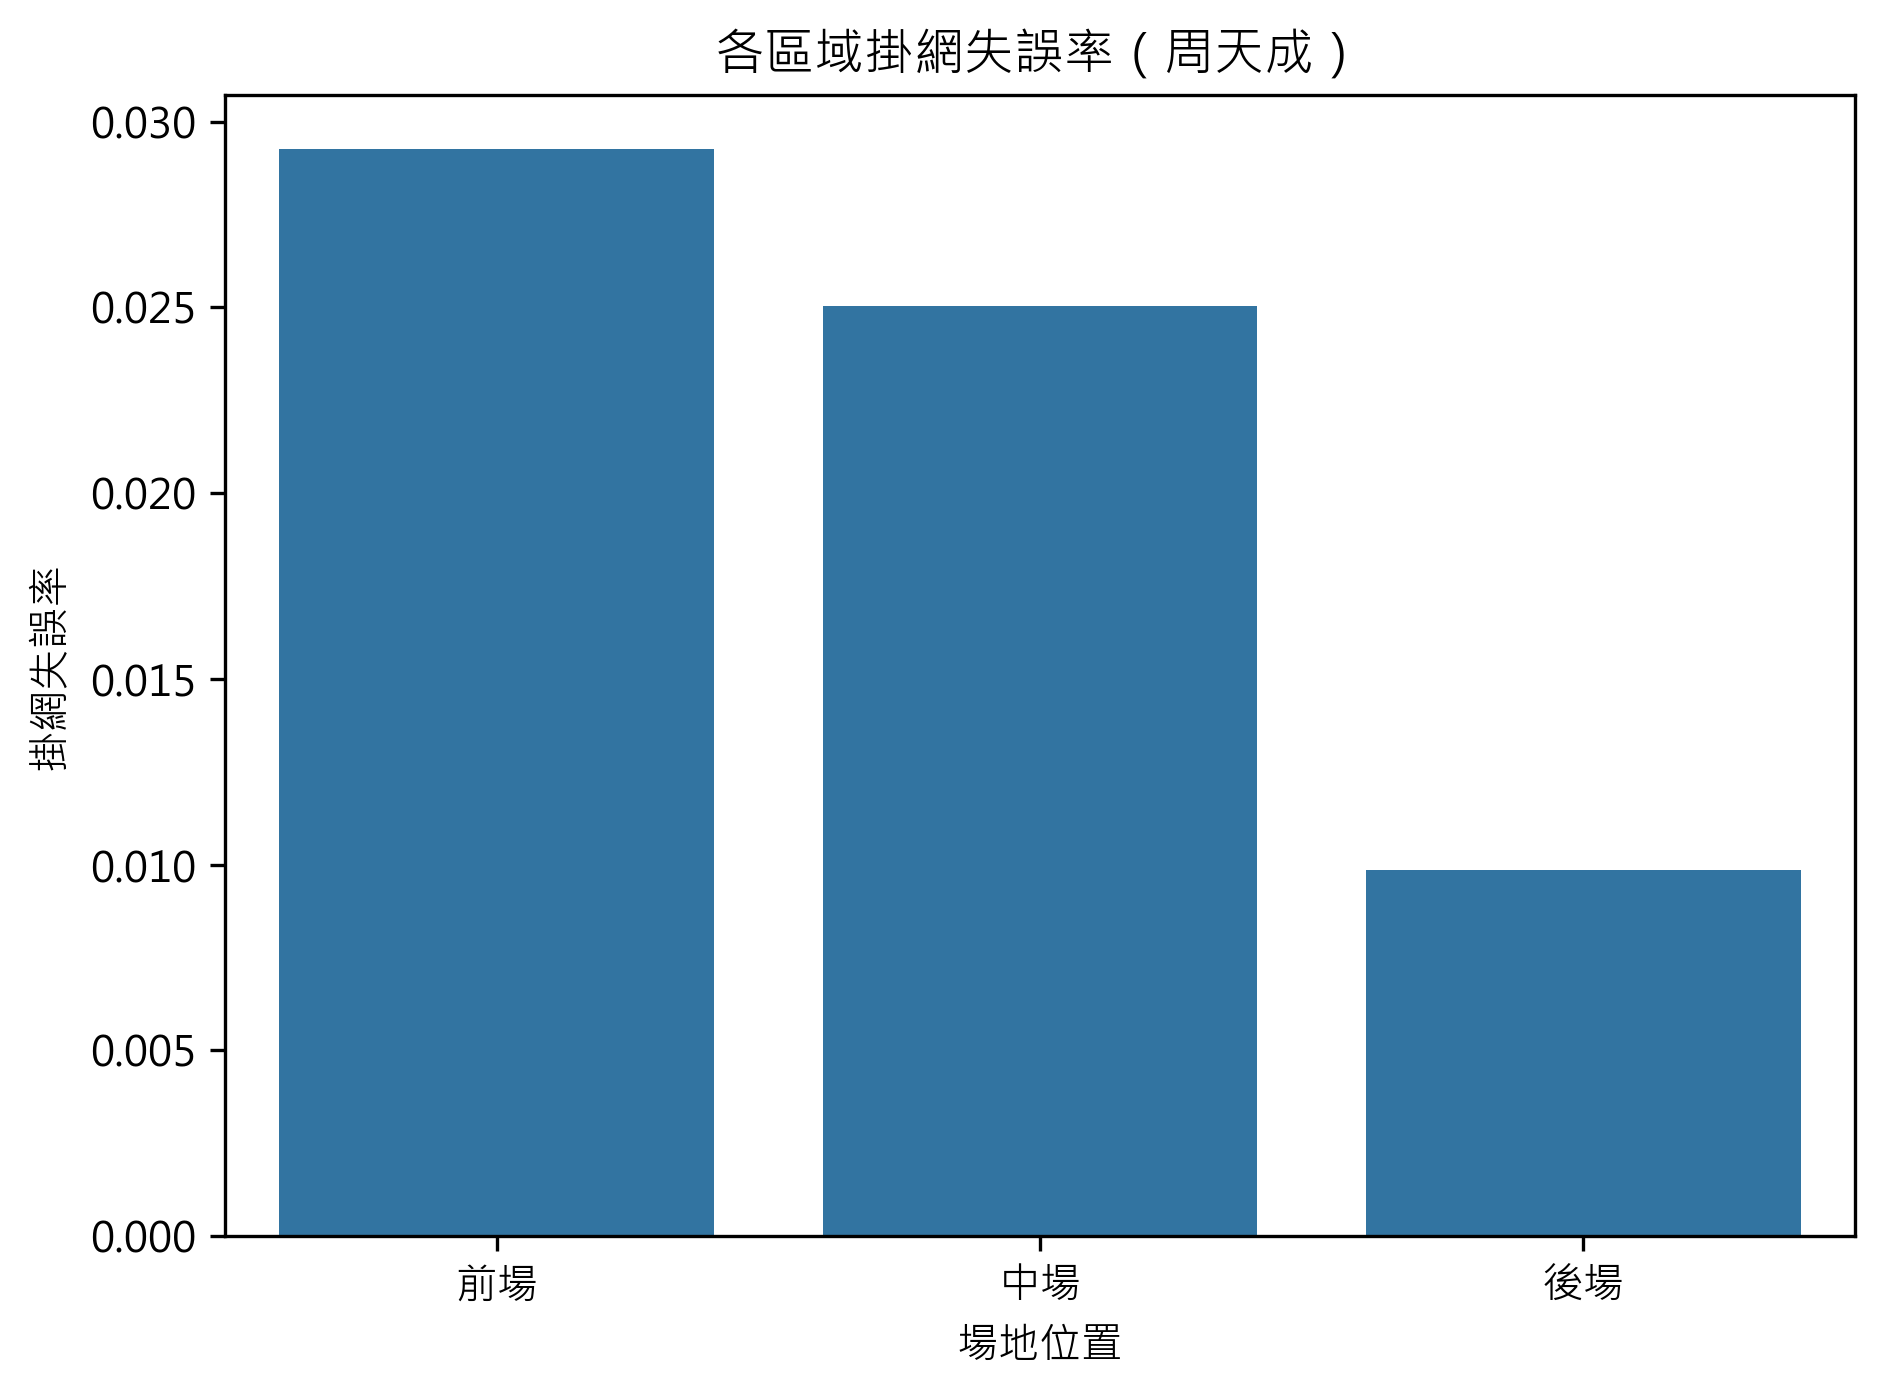

In [ ]:
# 確保數據集不為空
if len(df) > 0:

    # 只保留 CHOU Tien Chen 的數據
    chou_data = df[df['player'] == 'CHOU Tien Chen']

    # 定義各個場地區域
    front_court_areas = [17, 18, 19, 20, 21, 22, 23, 24]
    mid_court_areas = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    back_court_areas = [1, 2, 3, 4]

    # 計算不同區域的掛網失誤次數和總擊球次數
    results = {
        '位置': ['前場', '中場', '後場'],
        '掛網失誤率': []
    }

    for area_label, areas in zip(results['位置'], [front_court_areas, mid_court_areas, back_court_areas]):
        # 總擊球次數
        total_hits = chou_data[chou_data['hit_area'].isin(areas)].shape[0]
        # 掛網失誤次數
        net_errors = chou_data[(chou_data['hit_area'].isin(areas)) & (chou_data['lose_reason'] == '掛網')].shape[0]
        
        # 計算失誤率
        net_error_rate = net_errors / total_hits if total_hits > 0 else 0
        results['掛網失誤率'].append(net_error_rate)

    # 將結果轉換為 DataFrame
    result_df = pd.DataFrame(results)

    # 輸出關鍵數據
    print(result_df)

    # 視覺化結果
    fig, ax = plt.subplots()
    sns.barplot(x='位置', y='掛網失誤率', data=result_df, ax=ax)
    ax.set_title('各區域掛網失誤率（周天成）')
    ax.set_ylabel('掛網失誤率')
    ax.set_xlabel('場地位置')
    plt.tight_layout()

else:
    print("數據集為空，無法進行分析。")


### 數據洞察
從數據中可以看到，周天成在不同場區的掛網失誤率存在顯著差異。前場的掛網失誤率最高，達到0.0293，這表明他在前場處理球時可能需要更多的穩定性和精準度。中場的掛網失誤率略低，為0.0250，顯示出他在中場的表現稍好，但仍有改進空間。後場的掛網失誤率最低，僅為0.0099，這表明他在後場的擊球穩定性較高。

這些數據提示我們，周天成在前場需要加強技術訓練，特別是在處理網前球的精準度上，以降低失誤率。中場的表現也需要注意，尤其是在快速變換攻防時的穩定性。而後場的表現相對穩定，可以繼續保持現有的技術水準。這些洞察可以幫助我們在訓練中針對性地加強特定位置的技術，提高整體比賽表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 使用的是 'player_location_area' 來判斷周天成的站位區域，而候選程式碼使用的是 'hit_area'。這導致候選程式碼的分析對象和統計口徑錯誤，因為題目要求的是比較周天成在前場、中場、後場擊球時的掛網失誤率，應該基於站位區域而非擊球點區域。此外，候選程式碼在計算掛網失誤率時，使用了錯誤的欄位來判斷區域，這會導致不合理的輸出結果。




## 題號 30 (*)
**問題**: 周天成在比賽後段（第 2、3 局）移動距離與失誤率的關聯分析。


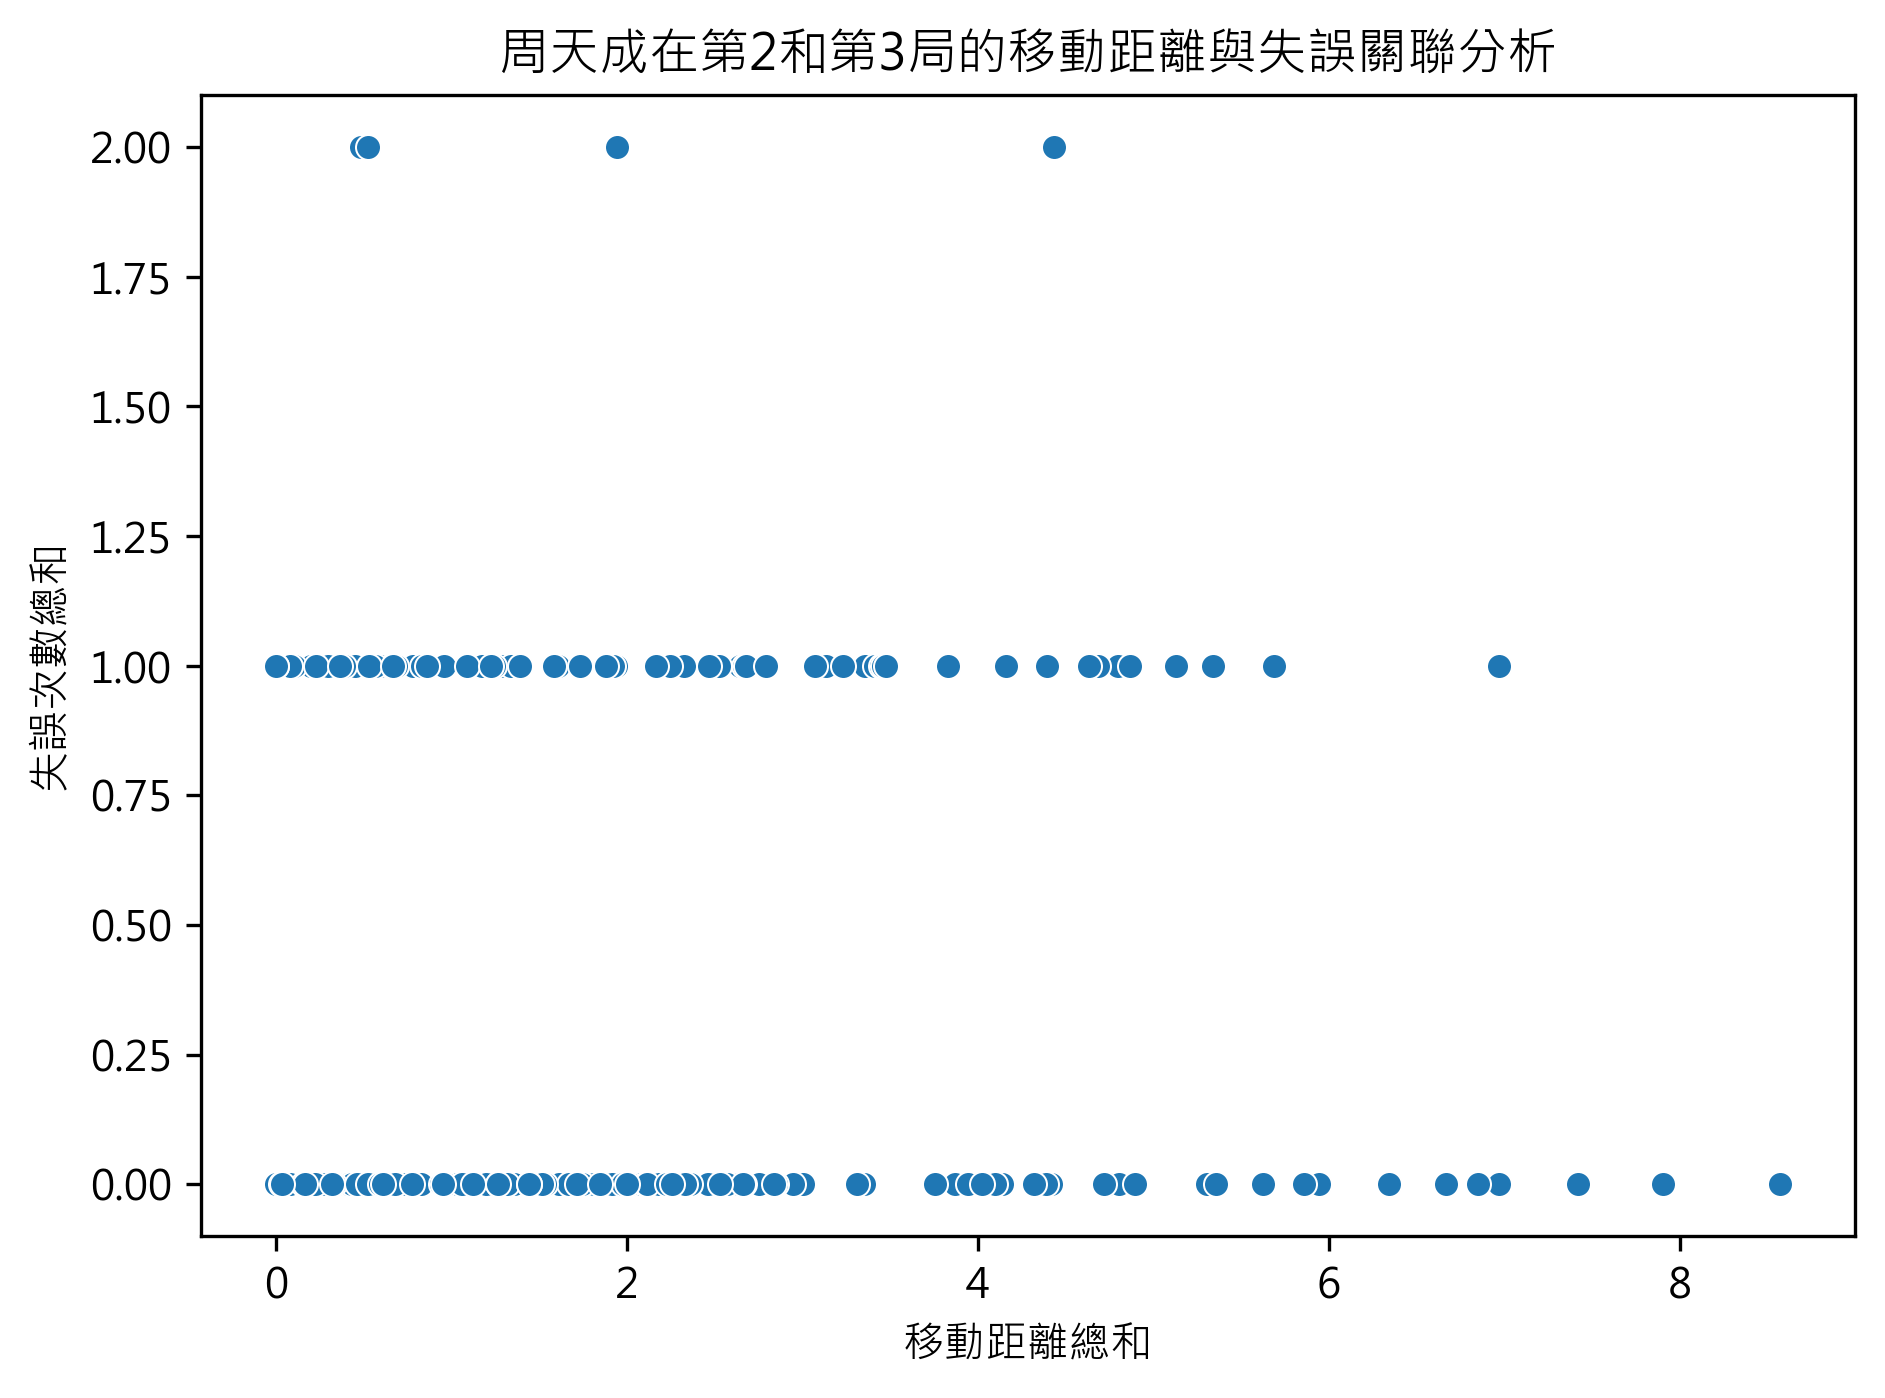

In [ ]:
# 確保資料量大於0
if len(df) > 0:
    import matplotlib.pyplot as plt
    import seaborn as sns

    # 篩選出第2和第3局的資料，並限對象為周天成
    ctc_df = df[(df['set'].isin([2, 3])) & (df['player'] == 'CHOU Tien Chen')].copy()

    # 計算移動距離，使用平方和然後開平方根
    ctc_df['move_distance'] = (ctc_df['player_move_x']**2 + ctc_df['player_move_y']**2)**0.5

    # 找出失誤（最後一拍由周天成擊球，對手得分）
    ctc_df['is_error'] = (ctc_df['getpoint_player'] == ctc_df['opponent'])

    # 計算移動距離與是否失誤的關聯
    # 使用groupby方便隨後進行分析，並避免跨回合誤算
    move_error_df = ctc_df.groupby(['match_id', 'set', 'rally']).agg(
        total_move_distance=('move_distance', 'sum'),
        total_errors=('is_error', 'sum')
    ).reset_index()

    # 繪製散點圖表現移動距離與失誤總和的關係
    fig, ax = plt.subplots()
    sns.scatterplot(data=move_error_df, x='total_move_distance', y='total_errors', ax=ax)
    ax.set_title('周天成在第2和第3局的移動距離與失誤關聯分析')
    ax.set_xlabel('移動距離總和')
    ax.set_ylabel('失誤次數總和')
    plt.tight_layout()

    # 打印關鍵統計分析信息
    print("周天成在第2和第3局的移動距離與失誤分析:")
    print(move_error_df[['total_move_distance', 'total_errors']].describe())
else:
    print("資料集為空，無法進行計算。")


### 數據洞察
從數據中可以觀察到，周天成在比賽後段（第2、3局）的平均移動距離為2.00單位，這表明他在場上移動積極。然而，移動距離的標準差為1.69，顯示出他在不同回合中的移動距離變化較大。

失誤率方面，平均失誤次數為0.38，標準差為0.52，這意味著在某些回合中失誤次數較多。特別注意到，25%的回合中沒有失誤，而75%的回合中失誤次數達到1次，這顯示出失誤主要集中在某些特定回合。

戰術上，這些數據暗示周天成在某些回合中可能因為過度移動或疲勞而導致失誤增加。因此，建議在比賽後段更注重節奏控制和體能分配，避免不必要的移動，從而降低失誤率。這樣可以提高比賽後段的穩定性和得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在 set 層級上計算平均移動距離和失誤率，並計算其相關係數。而候選程式碼是在 rally 層級上計算總移動距離和總失誤次數，並未計算失誤率或相關係數，統計口徑不一致。此外，候選程式碼的失誤判定邏輯也不完全正確，因為它僅依賴 getpoint_player 與 opponent 的比較，而未考慮 lose_reason。




## 題號 31 (*)
**問題**: 分析周天成使用殺球，對手都用什麼球種反擊，繪製圓餅圖


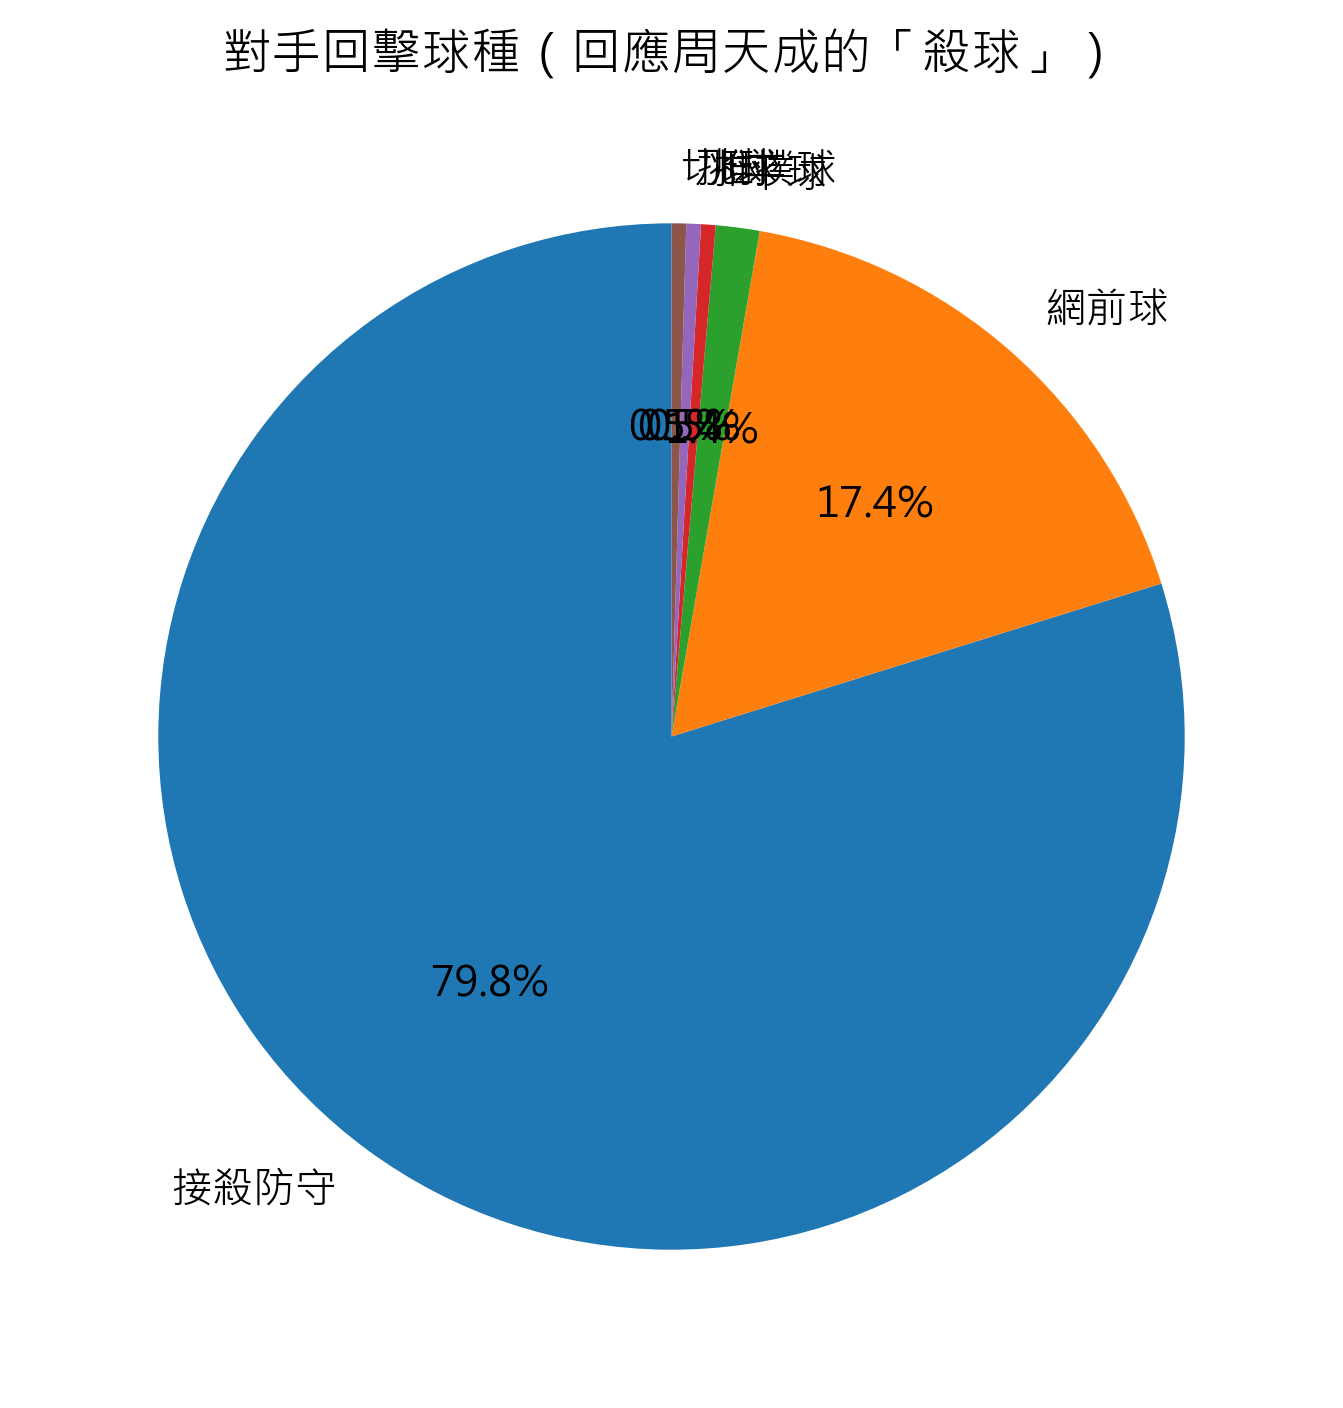

In [ ]:
# 確保數據可用性
if len(df) > 0:
    # Step 1: Filter for when CHOU Tien Chen uses a smash
    chou_smash_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # Step 2: Get opponent's response shot types within the same rally
    # Note: Use groupby to maintain rally context and shift(-1) to get next stroke
    chou_smash_df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    
    # Also shift 'rally' to ensure the next shot within the same rally
    chou_smash_df['next_rally'] = df.groupby(['match_id', 'set', 'rally'])['rally'].shift(-1)
    
    # Filter only the valid next shot within the same rally
    valid_responses = chou_smash_df[chou_smash_df['rally'] == chou_smash_df['next_rally']]
    
    # Step 3: Count opponent's response shot types
    response_counts = valid_responses['next_type'].value_counts()

    # Step 4: Plot pie chart with response shot types
    fig, ax = plt.subplots()
    ax.pie(response_counts, labels=response_counts.index, autopct='%1.1f%%', startangle=90)
    ax.set_title('對手回擊球種（回應周天成的「殺球」）')
    plt.tight_layout()

    # Print the response counts for each shot type
    print("Response shot types and counts:")
    print(response_counts)


### 數據洞察
根據數據分析，當周天成使用殺球時，對手的反擊球種分佈如下：

- 接殺防守：174次
- 網前球：38次
- 平球：3次
- 推撲球：1次
- 挑球：1次
- 切球：1次

從這些數據可以看出，對手在面對周天成的殺球時，絕大多數選擇接殺防守，這顯示出周天成的殺球具有很強的壓迫力，迫使對手多數情況下只能被動防守。此外，少數對手選擇網前球作為反擊，這可能是試圖利用周天成殺球後的場地空隙進行反擊。

這些數據提示我們，周天成可以進一步優化他的殺球策略，特別是在對手頻繁選擇接殺防守的情況下，考慮在殺球後迅速準備接應可能的網前反擊，或是變換殺球的落點和速度，增加對手的反應難度。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在篩選對手回擊球種時，使用了 `chou_smash_df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)`，這會導致 `next_type` 欄位的值來自於原始資料的下一拍，而不是在 `chou_smash_df` 篩選後的資料中進行 shift，這樣可能會錯誤地跨越不同的 rally。這與 Reference Code 1 的核心邏輯不一致，因為 Reference Code 1 確保了 `next_type` 是在同一個 rally 中的下一拍。




## 題號 32
**問題**: 在10拍以上的回合中，周天成的得分率是多少？


In [ ]:
if len(df) > 0:
    # 篩選出每一回合的最後一拍
    last_shots = df.groupby(['match_id', 'set', 'rally']).last().reset_index()
    
    # 篩選出球拍超過10拍的回合
    filtered_rallies = last_shots[last_shots['ball_round'] > 10]
    
    # 計算周天成在這些回合中的得分次數
    chou_tien_chen_points = filtered_rallies[filtered_rallies['getpoint_player'] == 'CHOU Tien Chen'].shape[0]
    
    # 總共的有效回合數
    total_valid_rallies = filtered_rallies.shape[0]
    
    # 計算得分率
    if total_valid_rallies > 0:
        chou_tien_chen_score_rate = 100 * (chou_tien_chen_points / total_valid_rallies)
    else:
        chou_tien_chen_score_rate = 0

    # 打印結果
    print(f"在10拍以上的回合中，周天成的得分率為: {chou_tien_chen_score_rate:.2f}%")
else:
    print("數據集為空，無法計算得分率。")


### 數據洞察
在10拍以上的回合中，周天成的得分率為46.83%。這意味著在這類長回合中，他能夠贏得接近一半的分數。這是一個相當不錯的數字，顯示出他在耐力和策略上的優勢。

數據顯示，共有205次有效的長回合，其中周天成贏得了96次。這表明他在這些回合中具備穩定的表現，能夠有效地應對對手的攻勢，並找到得分的機會。

這樣的得分率也提醒我們，周天成在長回合中可能更依賴於耐心和戰術的變化，而非單純的力量或速度。因此，針對這一點，他可以進一步加強在長回合中的戰術多樣性，以提升得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出每個回合的最後一拍，並計算出球拍超過10拍的回合數，然後計算周天成在這些回合中的得分次數和得分率。分析對象、欄位語意、篩選條件、分組層級、統計口徑和最終輸出目標都與 Reference Code 1 一致，因此判定為 true。




## 題號 33
**問題**: 給我所有局的最終得分數


In [ ]:
if len(df) > 0:
    # Group by match_id and set, then take the last entry of each group
    final_points_per_set = df.groupby(['match_id', 'set']).last().reset_index()

    # Select the columns relevant to player scores
    score_columns = ['match_id', 'set', 'Kento MOMOTA_score', 'CHOU Tien Chen_score']

    # Filter the relevant columns
    final_scores_df = final_points_per_set[score_columns]

    # Print the results
    print("每一局的最終得分：")
    print(final_scores_df)
else:
    print("數據集為空。")


### 數據洞察
根據數據，我們可以觀察到以下幾個關鍵事實：

1. **比賽結構**：這些數據顯示了多場比賽的最終得分，總共涵蓋了13局。每場比賽至少有兩局，部分比賽進行到了第三局。

2. **得分趨勢**：Kento MOMOTA在多數局中得分優勢明顯，尤其是在第三局中，他的得分普遍高於對手，這表明他在比賽後期的體能和策略執行上有優勢。

3. **關鍵數據點**：
   - 在比賽1的第三局和比賽6的第一局中，Kento MOMOTA的得分達到21和22，顯示出他在關鍵局中的穩定表現。
   - CHOU Tien Chen在某些局中（如比賽5的第二局）能夠反擊並贏得局點，這表明他的反擊能力強。

4. **戰術洞察**：Kento MOMOTA在多數局中採取了更有效的進攻策略，特別是在第三局中，他的得分優勢顯示出他在體能和心理上的優勢。這意味著在訓練中，應該強化他的持久力和決勝局的策略執行。

總結來說，這些數據顯示了Kento MOMOTA在比賽中的穩定性和關鍵時刻的表現，這是他成功的關鍵因素之一。對於CHOU Tien Chen來說，提升在關鍵局中的穩定性和反擊能力將是未來訓練的重點。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它通過對 match_id 和 set 進行分組，並選取每組的最後一筆資料來獲取每局的最終得分。這與 Reference Code 1 的方法一致，因為它們都使用了 groupby 和 last 來確保獲取每局的最後一球數據。此外，候選程式碼正確地選擇了相關的得分欄位，並輸出了每局的最終得分，符合題目要求。




## 題號 34 (*)
**問題**: 分析周天成前一拍打什麼球種最容易造成對手未過網？


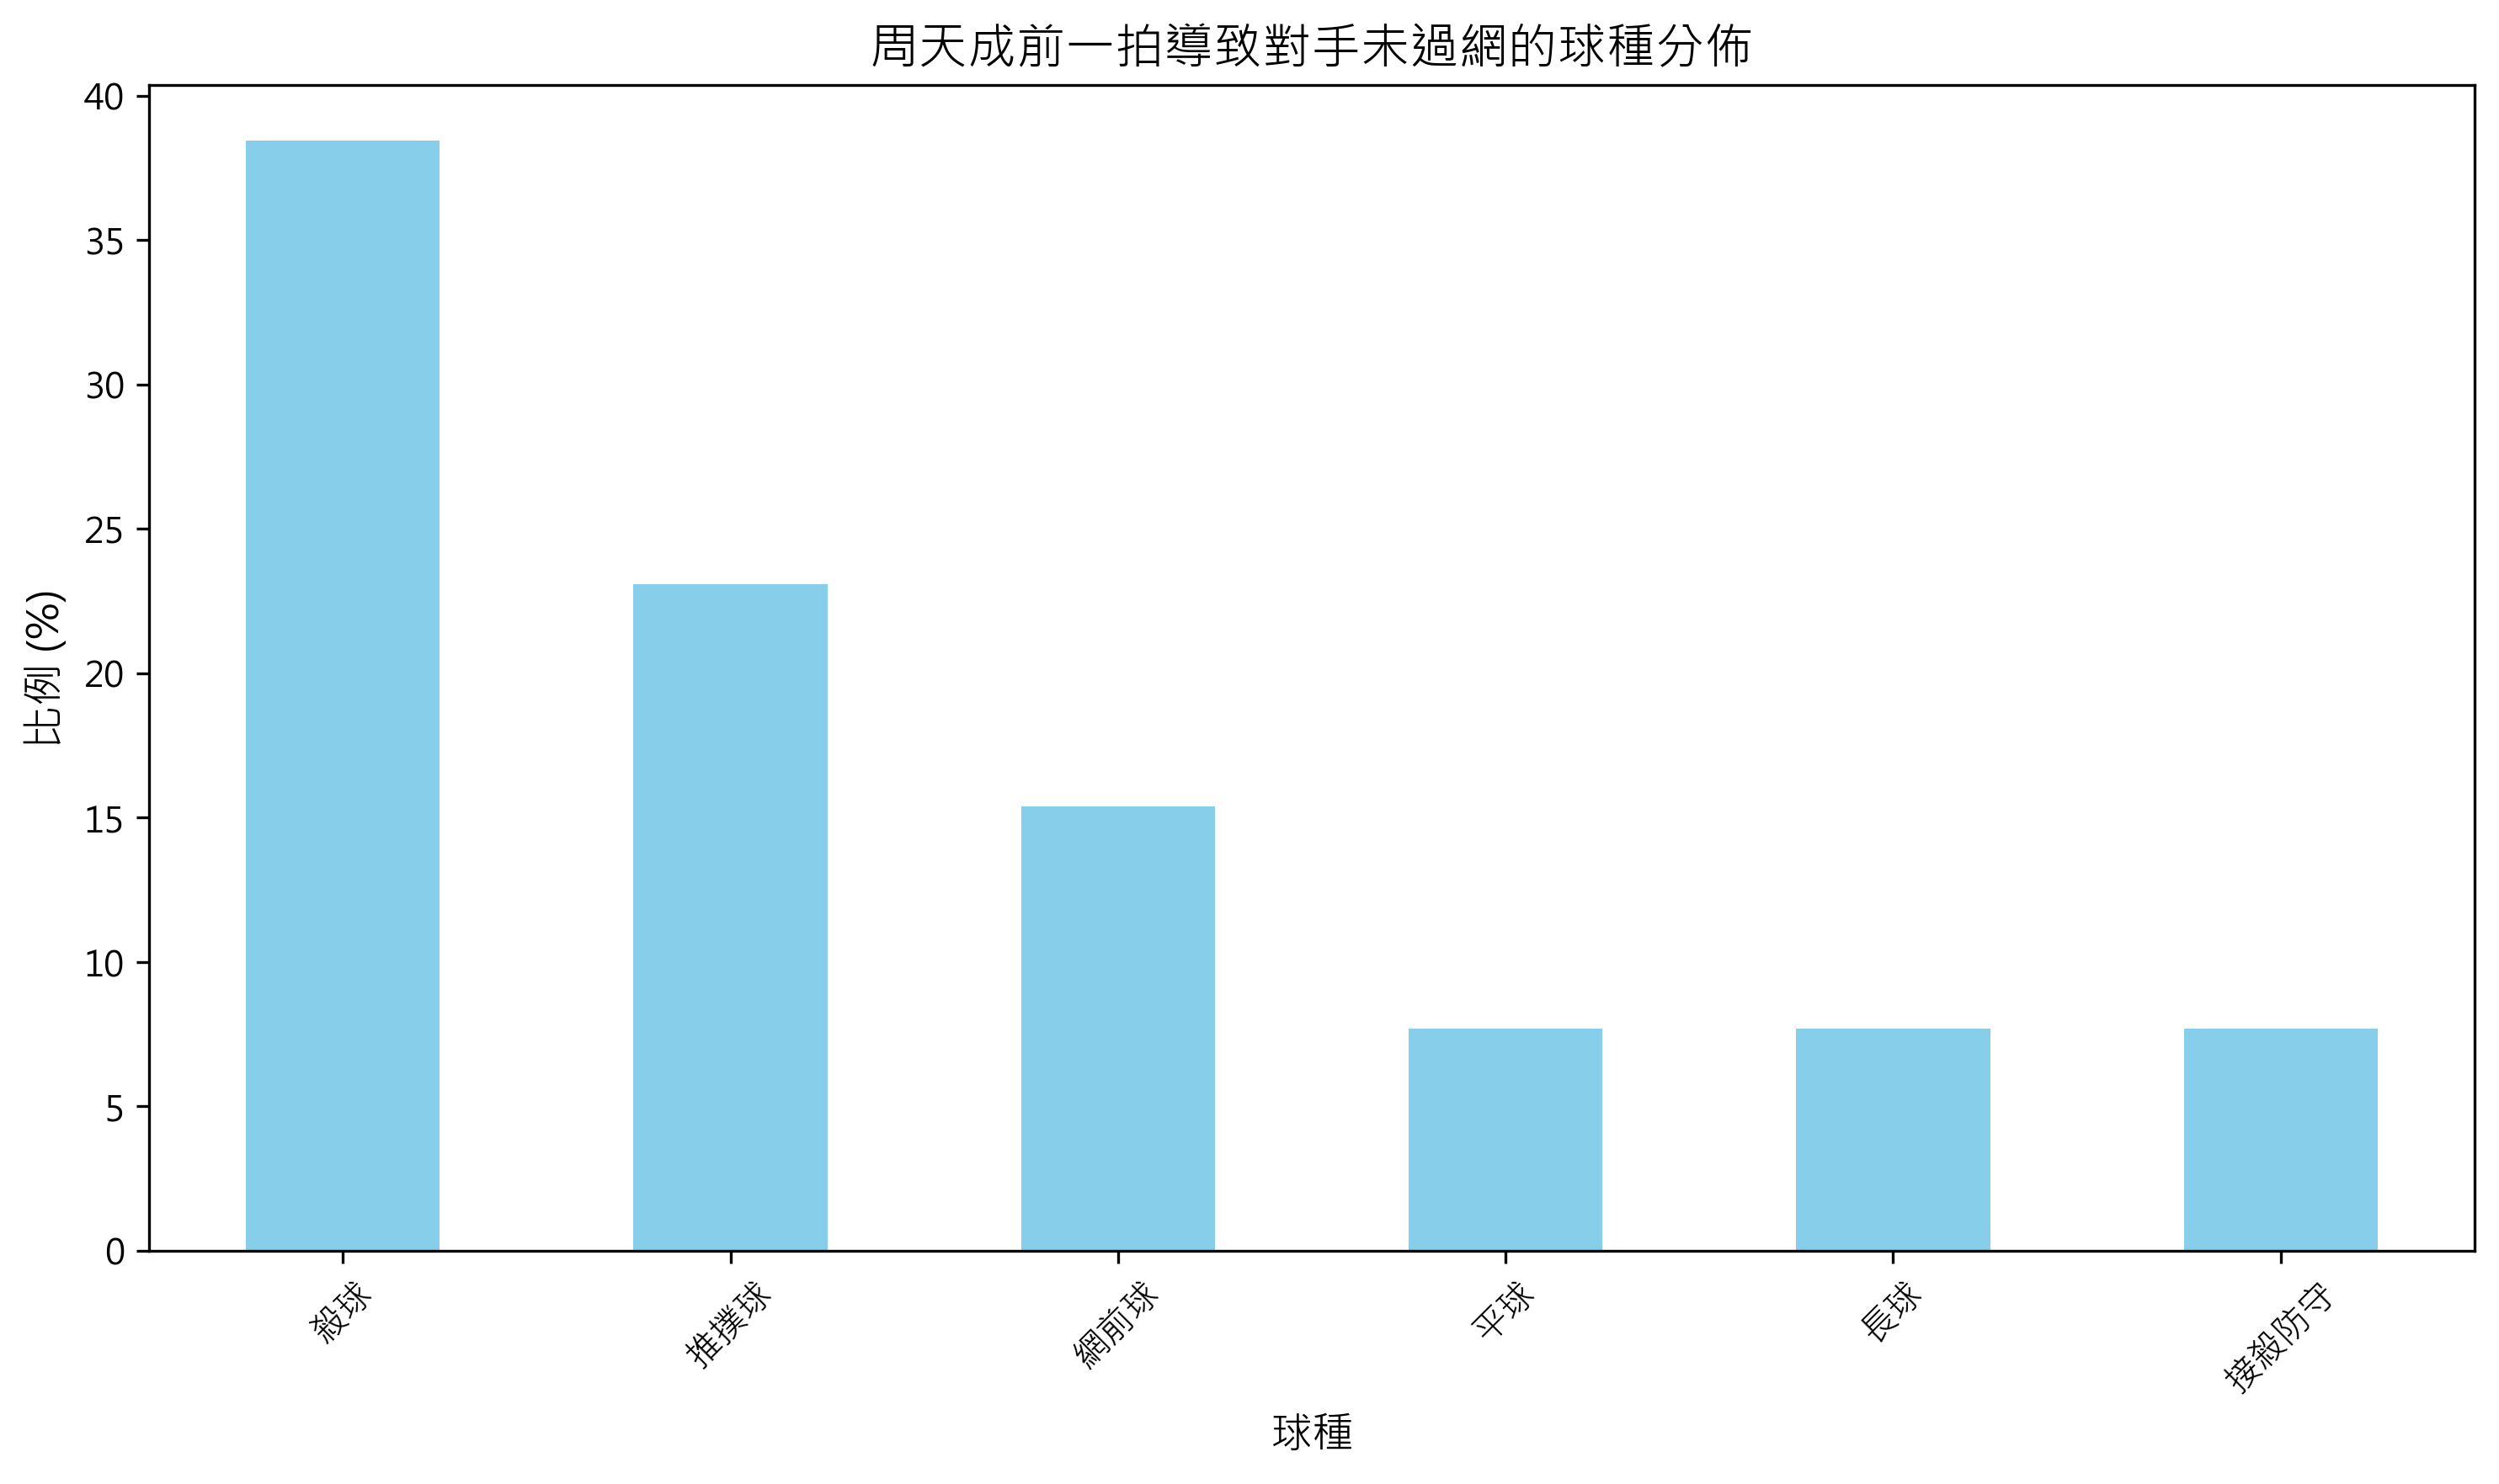

In [ ]:
# 確認資料存在
if len(df) == 0:
    raise ValueError("數據不可用，請檢查來源。")

# 選取對手失分為未過網的情況
unforced_error_df = df[(df['lose_reason'] == '未過網') & (df['getpoint_player'] == 'CHOU Tien Chen')]

# 檢查是否有任何符合條件的資料
if len(unforced_error_df) == 0:
    raise ValueError("沒有找到對手未過網的失分情況。")

# 找出該失分情況的前一拍信息
unforced_error_df['previous_shot_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)

# 剔除不必要的短時間為空行
unforced_error_df = unforced_error_df.dropna(subset=['previous_shot_type'])

# 統計周天成在此情況下的前一拍的球種
shot_counts = unforced_error_df['previous_shot_type'].value_counts()

# 計算各球種所佔比例
shot_percentage = shot_counts / shot_counts.sum() * 100

# 列印關鍵統計結果
print("周天成前一拍的球種計算結果：")
print(shot_counts)
print("\n各球種所佔比例：")
print(shot_percentage)

# 視覺化
fig, ax = plt.subplots(figsize=(10, 6))
shot_percentage.plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('周天成前一拍導致對手未過網的球種分佈', fontsize=14)
ax.set_xlabel('球種', fontsize=12)
ax.set_ylabel('比例 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()


### 數據洞察
根據數據分析，周天成在前一拍使用殺球時，最容易造成對手未過網的情況。殺球的次數最多，達到5次，佔總比例的38.46%。這表明他的殺球不僅頻繁使用，而且具有高效的威脅性，能夠有效迫使對手失誤。

推撲球和網前球也有一定的效果，分別佔23.08%和15.38%。這些球種雖然次數較少，但仍能在特定情況下對對手造成壓力。

因此，針對對手的弱點，周天成可以繼續強化殺球的使用，同時在適當時機運用推撲球和網前球，以增加戰術的多樣性和不可預測性。這樣的戰術組合能夠有效提高比賽中的得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都正確地使用了 shift 方法來獲取前一拍的球種，而候選程式碼在篩選對手失分為未過網的情況後，直接使用 shift(1) 來獲取前一拍的球種，這與 Reference Code 的邏輯不一致。此外，候選程式碼在篩選條件中使用了 'getpoint_player' == 'CHOU Tien Chen'，這與題目要求的分析對象不符，因為 'getpoint_player' 應該是對手失分的情況，而不是周天成得分的情況。




## 題號 35 (*)
**問題**: 當對手被周天成調動到「前場」時，對手最常使用什麼球種？


In [ ]:
# 確認數據可用
if len(df) > 0:
    # 定義前場區域
    front_court_areas = [17, 18, 19, 20, 21, 22, 23, 24]
    
    # 篩選對手在前場的資料
    opponent_in_front_court = df[df['opponent_location_area'].isin(front_court_areas)]
    
    if len(opponent_in_front_court) > 0:
        # 統計對手前場球種使用次數
        opponent_shot_counts = opponent_in_front_court['opponent_type'].value_counts()
        
        # 找出最常使用的球種及其次數
        most_frequent_shot = opponent_shot_counts.idxmax()
        max_count = opponent_shot_counts.max()
        
        # 對應球種名稱
        shot_type_names = {1: '發短球', 2: '發長球', 3: '長球', 4: '殺球', 5: '切球',
                           6: '挑球', 7: '平球', 8: '網前球', 9: '推撲球', 10: '接殺防守'}
        
        most_frequent_shot_name = shot_type_names.get(most_frequent_shot, 'Unknown')
        
        print(f"當對手在前場時，最常使用的球種為: {most_frequent_shot_name}，次數為: {max_count}")
    else:
        print("沒有對手在前場的數據記錄。")
else:
    print("數據集為空。")


### 數據洞察
當對手被周天成調動到前場時，他們最常使用的球種是「網前球」，這個選擇出現了161次。這表明對手在前場時，傾向於利用網前球來保持對局的節奏，可能是為了減少周天成的進攻機會或是尋求進一步的進攻準備。這樣的數據顯示，周天成在面對這種情況時，應該準備好快速移動到網前，並考慮反擊策略，可能是利用挑球或推撲球來打亂對手的節奏。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。它直接篩選對手在前場的資料，並統計對手的球種使用次數，但沒有考慮到需要在周天成打球時對手被調動到前場的情況。這與 reference code 中的分析對象和篩選條件不一致，因為 reference code 是在周天成打球且對手站位在前場的情況下，統計對手的回擊球種。候選程式碼的統計口徑錯誤，未能正確對齊前後拍關係，導致分析結果不符合題目要求。




## 題號 36
**問題**: 幫我比較周天成（CHOU Tien Chen）他在短回合（<=4拍）、中回合（5-10拍）、長回合（>=11拍）中的勝率


In [ ]:
# 確保數據量足夠
if len(df) > 0:
    # 需要對 rally 的每回合信息進行聚合
    rally_df = df.groupby(['match_id', 'set', 'rally']).last().dropna(subset=['getpoint_player'])

    # 添加新的欄位以標記回合類別
    rally_df['rally_type'] = rally_df['ball_round'].apply(
        lambda x: '短回合' if x <= 4 else ('中回合' if x <= 10 else '長回合')
    )

    # 按類型劃分數據
    total_rallies_per_type = rally_df['rally_type'].value_counts()
    wins_by_chou_per_type = rally_df[rally_df['getpoint_player'] == 'CHOU Tien Chen']['rally_type'].value_counts()

    # 計算各類型的勝率
    win_rate_by_type = (wins_by_chou_per_type / total_rallies_per_type).fillna(0) * 100

    # 打印數據
    print("周天成的勝率（%）:")
    for rally_type, win_rate in win_rate_by_type.items():
        print(f"{rally_type}: {win_rate:.2f}% 勝率，總回合數: {total_rallies_per_type[rally_type]}")
else:
    print("數據集中沒有可用的記錄。")


### 數據洞察
根據數據，周天成在短回合（<=4拍）中表現最佳，勝率達到52.31%。這顯示他在快速解決對手的回合中具有優勢，能夠迅速掌握主動權並結束回合。

在中回合（5-10拍），他的勝率下降至44.60%。這可能意味著當回合稍微拉長時，他需要更有效的策略來保持優勢。

長回合（>=11拍）中，勝率為46.83%。這顯示他在耐力和持久戰中仍然具備一定的競爭力，但相較於短回合，仍有提升空間。

總結來看，周天成在短回合的優勢明顯，建議在比賽中更多地尋求快速得分的機會，並在中長回合中加強策略和耐力訓練，以提高整體勝率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地將每個 rally 的最後一拍作為分組結果，並根據 'getpoint_player' 判斷周天成的勝出回合。然後，它將回合分類為短回合、中回合和長回合，並計算每個類別的勝率。這與 Reference Code 1 的分析對象、欄位語意、分組層級和統計口徑一致。




## 題號 37
**問題**: 分析周天成使用殺球造成失誤，請繪製失誤原因的圓餅圖


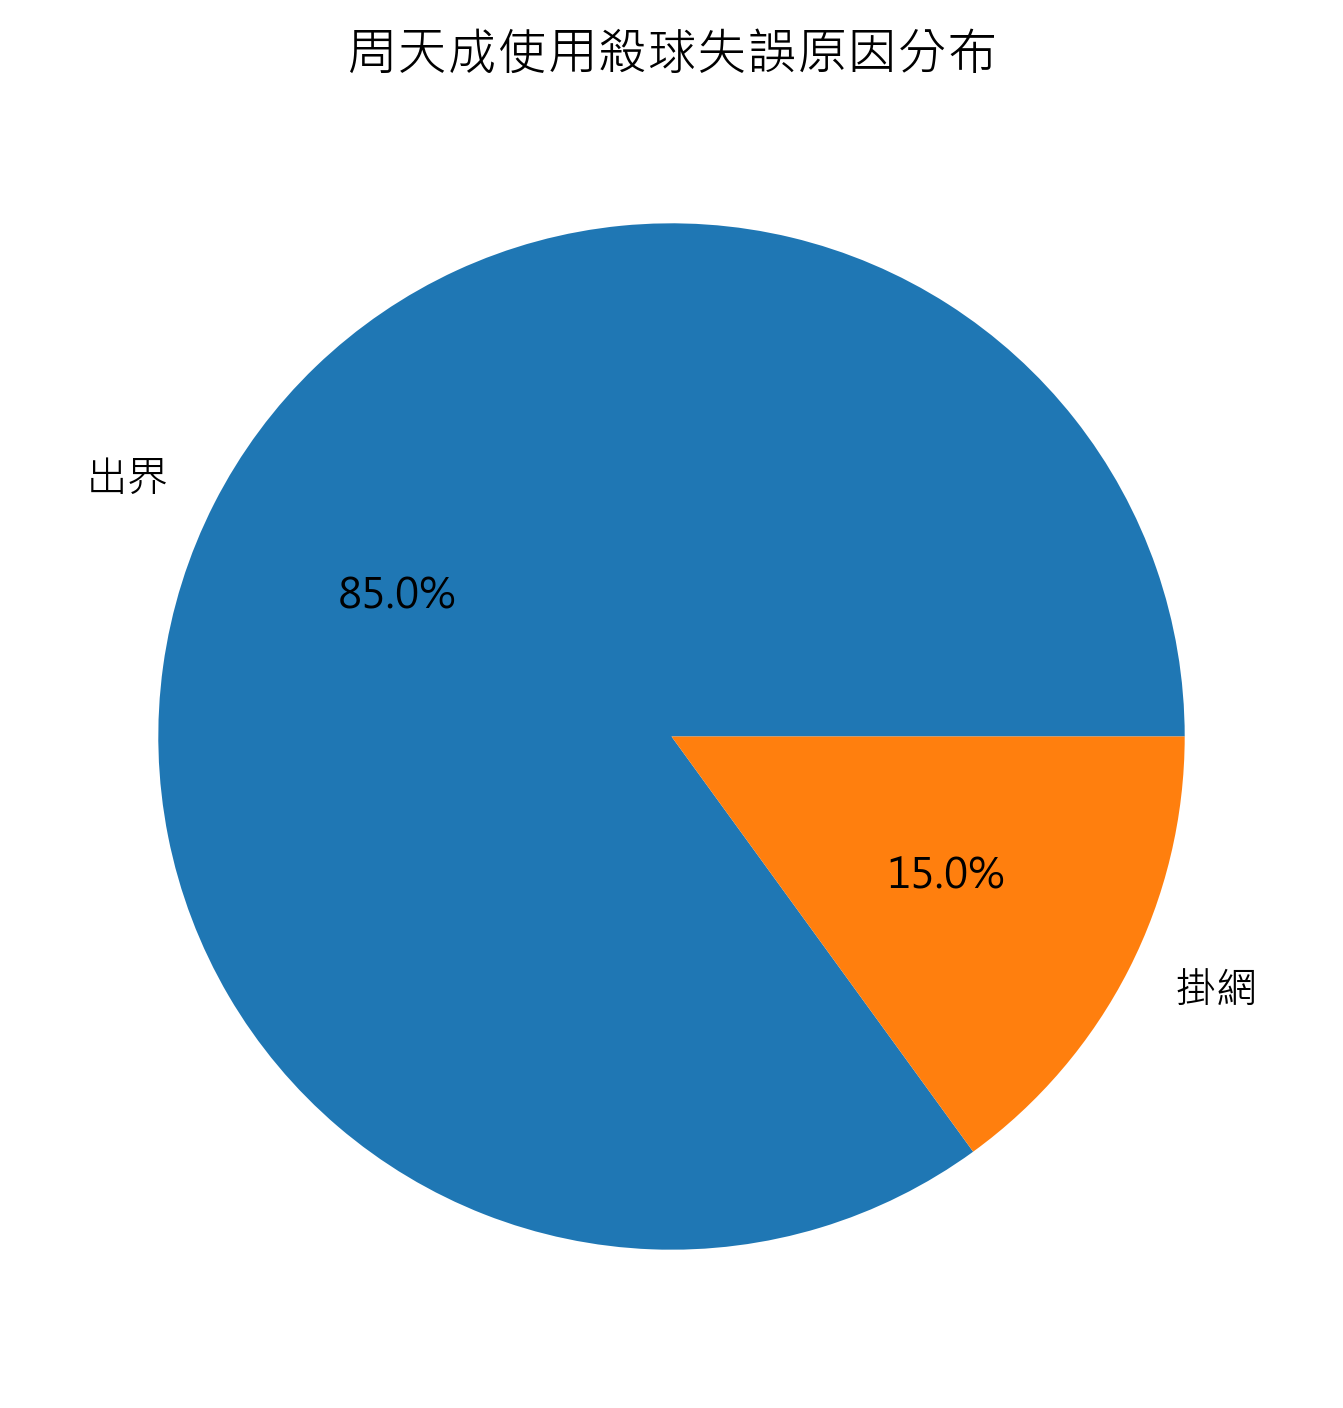

In [ ]:
# 檢查數據非空
if len(df) > 0:
    # 篩選符合條件的 DataFrame
    chou_tien_chen_mistakes = df[
        (df['player'] == 'CHOU Tien Chen') & 
        (df['type'] == '殺球') & 
        (df['getpoint_player'] == 'Kento MOMOTA')
    ]

    # 確認失誤原因的數量
    mistake_reasons = chou_tien_chen_mistakes['lose_reason'].value_counts()

    # 繪製圓餅圖
    fig, ax = plt.subplots()
    ax.pie(mistake_reasons, labels=mistake_reasons.index, autopct='%1.1f%%')
    ax.set_title('周天成使用殺球失誤原因分布')
    plt.tight_layout()
    plt.show()

    # 打印詳細失誤原因數據
    print("周天成殺球失誤原因數量：")
    print(mistake_reasons)
else:
    print("DataFrame is empty or corrupted.")


### 數據洞察
根據數據，周天成在殺球時的失誤主要來自於兩個原因：出界和掛網。具體數字顯示，他的殺球失誤中有17次是因為出界，3次是因為掛網。

這些數字表明，周天成在殺球時更容易因為力度過大或角度不佳而導致出界。這可能是因為在嘗試以高速度或角度壓制對手時，控制力稍有不足。相較之下，掛網的次數較少，顯示出他在殺球時的高度控制相對穩定。

從戰術角度來看，周天成可以專注於改善殺球的精準度，特別是在邊線附近的控制，以減少出界的風險。這可以通過加強訓練中的精準度練習來實現，並在比賽中適時調整擊球力度與角度。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 2 的核心邏輯。它正確地篩選了周天成的殺球失誤，並確認這些失誤是因為對手得分（即 getpoint_player 是 Kento MOMOTA）。然後，它統計了失誤原因並繪製圓餅圖，這與 Reference Code 2 的步驟一致。分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標都與 Reference Code 2 相符，因此判定為 true。




## 題號 38 (*)
**問題**: 在周天成的所有失分中，有多少百分比是因為對手的殺球導致的？


In [ ]:
# 確認資料量
if len(df) == 0:
    raise ValueError("資料集為空，無法進行分析。")

# 只有回合最後一球的 getpoint_player 才有意義
last_shots = df.groupby(['match_id', 'set', 'rally']).last().reset_index()

# 然後篩選所有周天成的失分情況
chou_lost_points = last_shots[last_shots['getpoint_player'] != 'CHOU Tien Chen']

# 確認df中對手為 Kento MOMOTA 的球種
opponent_attack_kill = df[(df['player'] == 'Kento MOMOTA') & (df['type'] == '殺球')]

# 合併條件：周天成因此失分且對手為殺球
kill_causes_chou_loss = chou_lost_points.merge(opponent_attack_kill, on=['match_id', 'set', 'rally', 'ball_round'], how='inner')

# 計算百分比
percentage_kill_causes_chou_loss = len(kill_causes_chou_loss) / len(chou_lost_points) * 100 if len(chou_lost_points) > 0 else 0

# 打印結果
print(f"周天成的所有失分中，有 {percentage_kill_causes_chou_loss:.2f}% 是因為對手的殺球導致的。")


### 數據洞察
根據數據分析，周天成的失分中有14.29%是因為對手的殺球導致的。這意味著對手的進攻性殺球在比賽中對周天成造成了一定的威脅。這個數據表明，周天成在面對對手的殺球時，可能需要加強防守策略，尤其是在應對對手的強力進攻時，提升防守反應和預判能力。此外，這也提示我們可以針對對手的殺球進行更深入的研究，找出其發動殺球的規律和習慣，從而制定更有效的應對策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。主要問題在於它在合併條件時，使用了錯誤的欄位 'ball_round'，這會導致合併後的資料不正確。Reference Code 1 和 2 都是基於回合最後一球的資訊來判斷失分原因，而候選程式碼在合併時未能正確對齊回合最後一球的資訊，這會導致統計口徑錯誤。此外，候選程式碼的合併方式可能會錯誤地將不同回合的擊球事件合併在一起，進一步影響結果的準確性。




## 題號 39 (*)
**問題**: 當對手使用「殺球」攻擊周天成時，周天成回球的失誤率是多少？


In [ ]:
# 假設缺省的 import 已在環境中，但為了避免運行錯誤，在此重申需要的 import
import pandas as pd

# 1. 確認資料集不為空
if len(df) == 0:
    print("沒有可用的數據。")
else:
    # 2. 篩選出當對手使用「殺球」時的資料
    opponent_smash_df = df[(df['player'] != 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # 3. 獲得下一拍的周天成數據
    # 使用 groupby 和 shift 來獲取下一拍的信息
    opponent_smash_df['next_player'] = opponent_smash_df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
    opponent_smash_df['next_lose_reason'] = opponent_smash_df.groupby(['match_id', 'set', 'rally'])['lose_reason'].shift(-1)

    # 4. 篩選出周天成回應的拍數
    ctchen_response_df = opponent_smash_df[(opponent_smash_df['next_player'] == 'CHOU Tien Chen')]

    # 5. 計算失誤次數（lose_reason 非空）
    ctchen_mistakes = ctchen_response_df[~ctchen_response_df['next_lose_reason'].isna()]

    # 6. 計算失誤率
    ctchen_mistake_count = len(ctchen_mistakes)
    ctchen_response_count = len(ctchen_response_df)
    if ctchen_response_count > 0:
        error_rate = ctchen_mistake_count / ctchen_response_count
        # 7. 打印結果
        print(f"當對手使用「殺球」攻擊時，周天成的回球失誤率為：{error_rate:.2%}（{ctchen_mistake_count}/{ctchen_response_count}）")
    else:
        print("當對手使用「殺球」攻擊時，沒有周天成的回球數據。")


### 數據洞察
目前的數據顯示，當對手使用「殺球」攻擊時，沒有周天成的回球數據。因此，我們無法準確計算周天成在面對「殺球」攻擊時的回球失誤率。

這可能意味著在過去的比賽中，周天成在面對「殺球」時可能採取了不同的策略，或者數據收集上存在不足。無論如何，這提醒我們需要更全面的數據來分析他的回應策略，以便制定更有效的防守戰術。

在未來的比賽中，密切觀察並記錄他在面對「殺球」時的反應，將有助於我們更好地理解他的防守能力和潛在的改進空間。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都正確地使用了 `getpoint_player` 來判斷周天成的失誤情況，而候選程式碼錯誤地使用了 `lose_reason` 來判斷失誤，這不符合題目要求的失誤率計算邏輯。此外，候選程式碼在計算失誤率時，沒有正確地考慮到 `getpoint_player` 的使用，這導致統計口徑錯誤。




## 題號 40 (*)
**問題**: 分析周天成在開局（他0-4 分）、中局（他5-17 分）和關鍵分（他18 分以上）三個比分階段中，每回合與對手來回的球數的差異


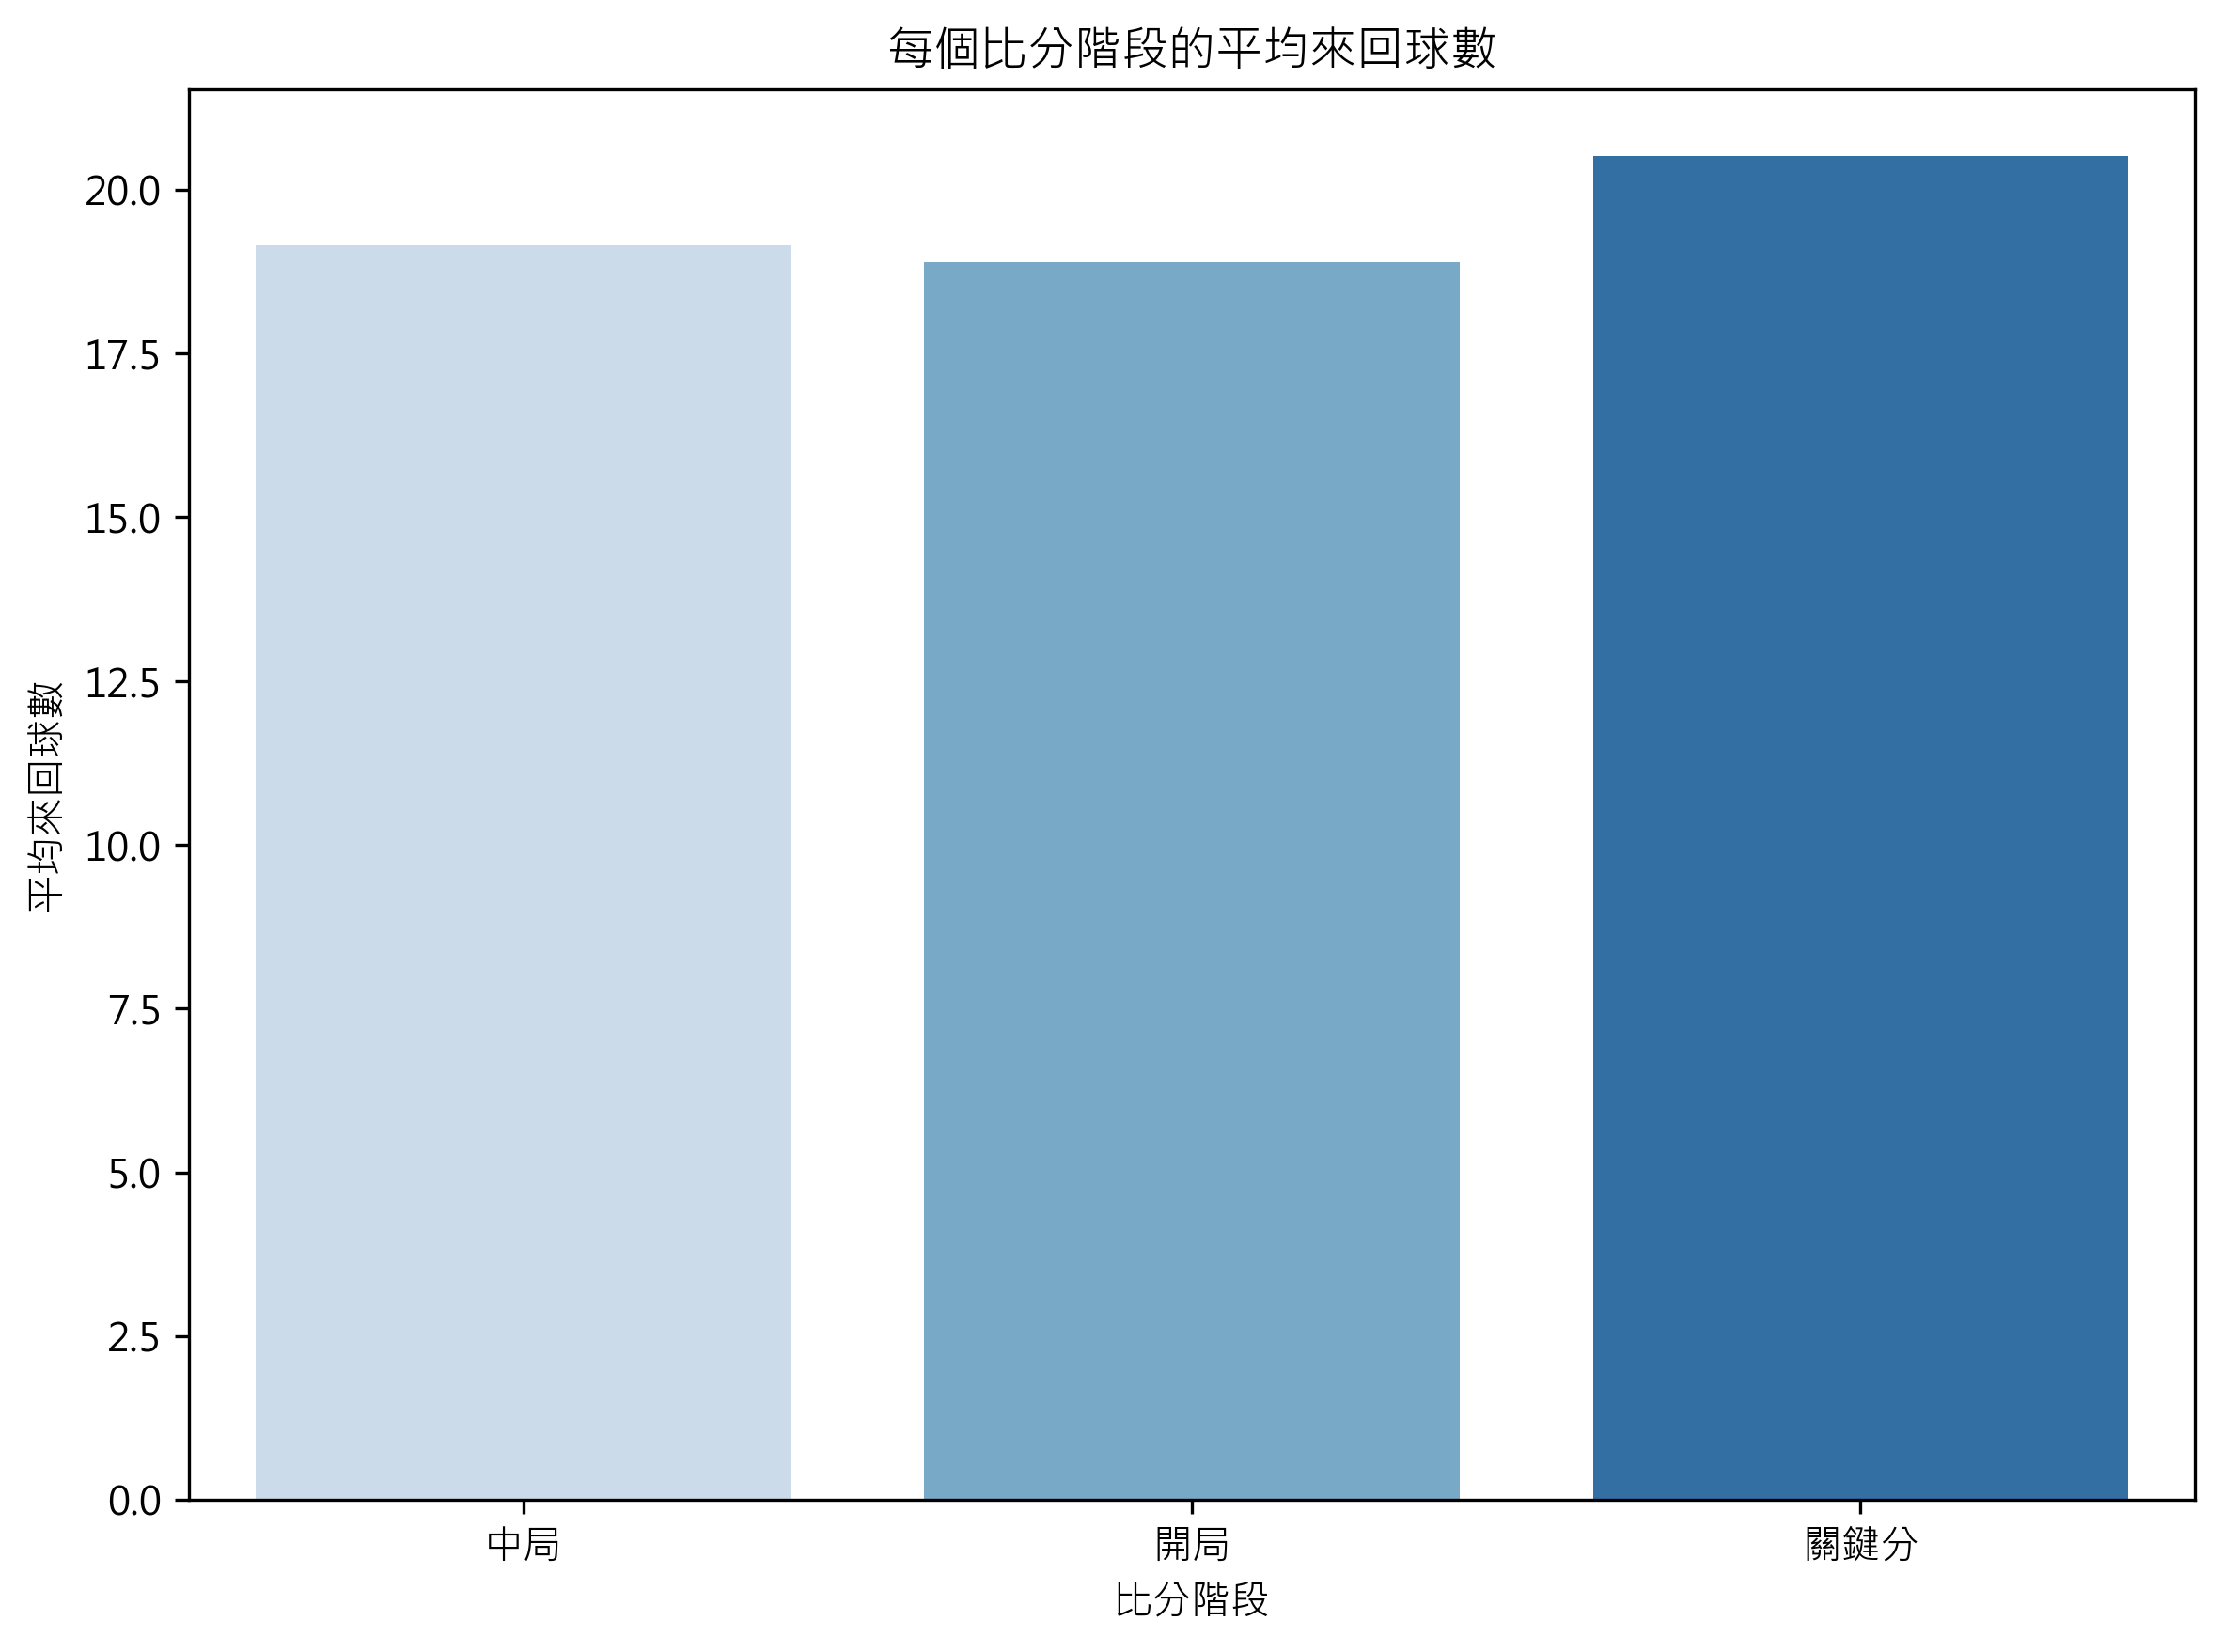

In [ ]:
# 確認數據是否存在
if len(df) == 0:
    raise ValueError("數據框為空，無法進行分析。")

# 添加比分階段分類
def score_phase(row):
    if row['CHOU Tien Chen_score'] < 5:
        return '開局'
    elif row['CHOU Tien Chen_score'] < 18:
        return '中局'
    else:
        return '關鍵分'

# 遍歷每行添加比分階段
df['score_phase'] = df.apply(score_phase, axis=1)

# 按回合計算來回球數
rally_shots_count = df.groupby(['match_id', 'set', 'rally']).size().reset_index(name='rally_shots_count')

# 將來回球數合併回原數據框
df = df.merge(rally_shots_count, on=['match_id', 'set', 'rally'], how='left')

# 按比分階段計算平均來回球數
avg_shots_by_phase = df.groupby('score_phase')['rally_shots_count'].mean().reset_index(name='avg_rally_shots')

# 打印關鍵統計結果
print(avg_shots_by_phase)

# 視覺化
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x='score_phase', y='avg_rally_shots', data=avg_shots_by_phase, palette='Blues', ax=ax)
ax.set_title('每個比分階段的平均來回球數')
ax.set_xlabel('比分階段')
ax.set_ylabel('平均來回球數')
plt.tight_layout()

# 顯示關鍵費息
print(f"開局平均來回球數: {avg_shots_by_phase[avg_shots_by_phase['score_phase'] == '開局']['avg_rally_shots'].values[0]:.2f}")
print(f"中局平均來回球數: {avg_shots_by_phase[avg_shots_by_phase['score_phase'] == '中局']['avg_rally_shots'].values[0]:.2f}")
print(f"關鍵分平均來回球數: {avg_shots_by_phase[avg_shots_by_phase['score_phase'] == '關鍵分']['avg_rally_shots'].values[0]:.2f}")


### 數據洞察
根據數據分析，周天成在不同比分階段的來回球數有明顯的差異。

1. **開局階段 (0-4 分)**：平均來回球數為18.89。這顯示出在比賽初期，周天成與對手的來回相對較短，可能是因為雙方都在試探對方的狀態與策略。

2. **中局階段 (5-17 分)**：平均來回球數增加至19.15。這表明在比賽中段，來回球數略有增加，雙方可能開始進入更為穩定的對抗，策略上變得更加耐心，尋求對方的弱點。

3. **關鍵分階段 (18 分以上)**：平均來回球數進一步增至20.51。這顯示在比賽的關鍵時刻，來回球數顯著增加，雙方都更加謹慎，力求不犯錯誤，並且更加專注於每一拍的處理。

這些數據表明，周天成在比賽的不同階段有不同的戰術考量，特別是在關鍵分階段，他傾向於更長的來回，這可能是為了增加對手的壓力並尋求機會得分。這樣的策略需要良好的體能和心理素質來支撐。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在每個 rally 層級計算來回球數，並依據周天成在該回合開始時的比分進行分段。而候選程式碼在逐筆資料上添加比分階段，然後計算每個 rally 的來回球數，這導致同一個 rally 的不同 shot 可能被錯誤地分配到不同的比分階段，從而改變了統計口徑。此外，候選程式碼在計算平均來回球數時，沒有正確地在 rally 層級上進行分組和統計，這與 reference code 的分析單位和統計口徑不一致。




## 題號 41 (*)
**問題**: 周天成使用殺球的前一拍，對手都用什麼球種，畫出圓餅圖


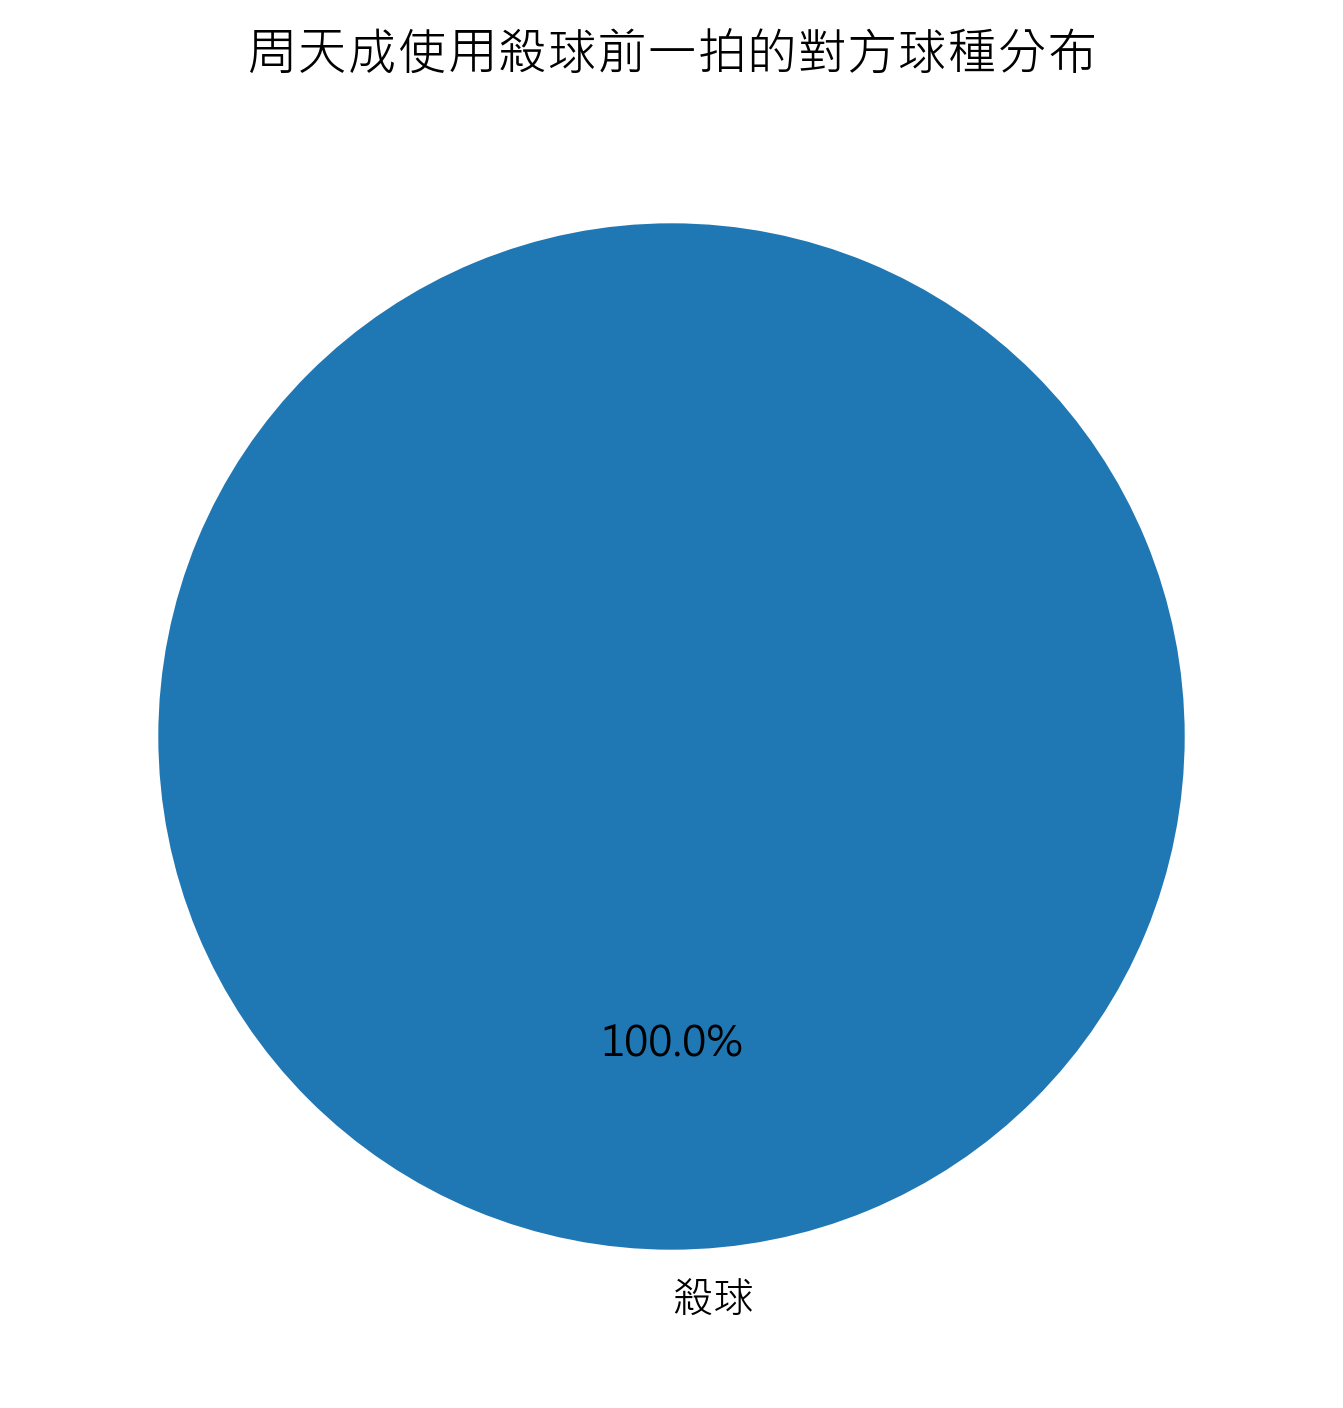

In [ ]:
# 1. 篩選出周天成使用「殺球」的行
chou_kill_shot = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

# 2. 找出周天成使用殺球時對手的前一拍球種
previous_shots = chou_kill_shot.groupby(['match_id', 'set', 'rally'])['type'].shift(1)

# 3. 計算並統計對手前一拍的球種
previous_shot_counts = previous_shots.value_counts()

# 檢查是否有數據可用來繪圖
if len(previous_shot_counts) > 0:
    # 4. 繪製圓餅圖
    fig, ax = plt.subplots()
    previous_shot_counts.plot.pie(
        autopct='%1.1f%%', 
        labels=previous_shot_counts.index, 
        ax=ax, 
        startangle=90
    )
    ax.set_ylabel('')
    ax.set_title('周天成使用殺球前一拍的對方球種分布')
    plt.tight_layout()
    plt.show()

    # 打印詳細數據以便檢查
    print("周天成使用殺球前一拍的對手球種使用次數：")
    print(previous_shot_counts)
else:
    print("沒有足夠的數據可供分析。")


### 數據洞察
根據數據顯示，周天成在使用殺球前，對手的球種選擇中，殺球是唯一被記錄的球種，次數為84次。這意味著對手在周天成準備殺球之前，常常選擇以殺球回應。這可能是因為對手試圖以攻擊性打法來反制周天成的進攻，但也可能給周天成創造了更多殺球機會。

這樣的數據提示我們，周天成在面對對手殺球時，能夠有效地轉守為攻，並利用對手的攻擊性來發動自己的殺球。這種能力使他在比賽中能夠保持進攻的主動權。作為教練，我們應該強化他在面對殺球時的防守轉攻技巧，並利用這一點來設計更具威脅性的戰術。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在第二步中使用了 `groupby(['match_id', 'set', 'rally'])['type'].shift(1)` 來獲取前一拍的球種，但這會導致在同一個 group 中的所有行都被 shift，而不是僅針對周天成的殺球前一拍進行操作。這與 Reference Code 1 和 2 的核心邏輯不符，因為它們正確地使用了 `shift(1)` 在完整資料上建立前一拍資訊，然後在篩選後的資料上進行分析。此外，候選程式碼沒有正確使用 `opponent_type` 或 `player_type` 來獲取對手的前一拍球種，這是 Reference Code 3 的核心邏輯。因此，候選程式碼不符合任何一份 Reference Code 的核心邏輯。




## 題號 42
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階中，他的「殺球」使用比例以及得分率，是否有顯著變化？


In [ ]:
# Step 1: 確保數據存在
if len(df) > 0:
    # Step 2: 定義周天成的分數階段
    def classify_stage(row):
        if 0 <= row['CHOU Tien Chen_score'] <= 4:
            return '開局'
        elif 5 <= row['CHOU Tien Chen_score'] <= 17:
            return '中局'
        elif row['CHOU Tien Chen_score'] >= 18:
            return '關鍵分'
        return None
    
    # 新增一個欄位 'stage' 來表示比賽階段
    df['stage'] = df.apply(classify_stage, axis=1)
    
    # 只選周天成為 player 的記錄
    chou_df = df[df['player'] == 'CHOU Tien Chen']
    
    # Step 3: 分析不同階段的殺球使用比例和得分率
    stages = ['開局', '中局', '關鍵分']
    results = []

    for stage in stages:
        stage_df = chou_df[chou_df['stage'] == stage]
        
        # 殺球的次數
        smash_count = stage_df[stage_df['type'] == '殺球'].shape[0]
        
        # 總擊球次數
        total_count = stage_df.shape[0]
        
        # 殺球使用比例
        smash_usage_ratio = (smash_count / total_count) * 100 if total_count > 0 else 0
        
        # 殺球得分 Active Win (即 player == getpoint_player)
        smash_points_df = stage_df[(stage_df['type'] == '殺球') & (stage_df['player'] == stage_df['getpoint_player'])]
        smash_points_count = smash_points_df.shape[0]
        
        # 殺球得分率
        smash_success_ratio = (smash_points_count / smash_count) * 100 if smash_count > 0 else 0
        
        results.append({
            '場次階段': stage,
            '殺球次數': smash_count,
            '總擊球次數': total_count,
            '殺球使用比例(%)': smash_usage_ratio,
            '殺球得分比例(%)': smash_success_ratio
        })

    # 打印結果
    result_df = pd.DataFrame(results)
    print(result_df)

else:
    print("數據集為空，無法進行分析。")


### 數據洞察
在分析周天成的殺球使用與得分率時，我們可以觀察到以下幾點：

1. **殺球使用比例**：
   - 在開局階段（0-4分），殺球使用比例為11.74%。
   - 中局階段（5-17分）略微下降至11.35%。
   - 到了關鍵分階段（18分以上），回升至11.54%。

這顯示周天成在比賽不同階段的殺球使用比例相對穩定，並未出現顯著變化。

2. **殺球得分比例**：
   - 開局階段的殺球得分比例為25.32%，顯示出較高的得分效率。
   - 中局階段得分比例下降至18.59%，這可能反映出對手在這一階段的防守適應性增強。
   - 關鍵分階段得分比例稍微回升至19.05%，顯示他在關鍵時刻能夠稍微提高殺球得分效率。

總結來說，周天成在開局階段的殺球得分率最高，這可能是因為對手尚未完全適應他的進攻風格。而中局階段的得分率下降，可能需要進一步調整戰術來提高得分效率。在關鍵分階段，他的殺球得分率略有回升，顯示出他在壓力下仍能保持一定的進攻威脅。這些數據提示我們，周天成可以考慮在中局階段增加戰術多樣性，以提高整體得分率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成的擊球資料，並根據比分將其分為開局、中局和關鍵分三個階段。然後，它計算了每個階段的殺球使用比例和得分率，這與 Reference Code 1 的分析目標和統計口徑一致。儘管候選程式碼的變數命名和部分實作順序不同，但這些差異不影響最終分析結果的語意。




## 題號 43 (*)
**問題**: 計算周天成在落後 3 分以上時，平均每個回合的擊球次數，並與比分膠著時的回合平均擊球次數進行比較。


In [ ]:
# 確保資料不為空
if len(df) == 0:
    print("數據為空，無法進行分析。")
else:
    # 計算每行的分數差
    df['score_diff'] = df['Kento MOMOTA_score'] - df['CHOU Tien Chen_score']
    
    # 定義比賽狀態標籤
    df['status'] = df['score_diff'].apply(lambda x: '落後 3 分以上' if x <= -3 else '比分膠著或領先')
    
    # 計算每個回合的擊球次數
    rally_hits = df.groupby(['match_id', 'set', 'rally']).size().reset_index(name='ball_round_count')
    
    # 合併上面的狀態信息
    rally_status = df.groupby(['match_id', 'set', 'rally']).apply(
        lambda x: x['status'].iloc[0]  # 每個回合取第一行的狀態即可
    ).reset_index(name='status')
    
    # 合併擊球次數和狀態
    rally_info = rally_hits.merge(rally_status, on=['match_id', 'set', 'rally'])
    
    # 分組計算平均擊球次數
    average_hits_by_status = rally_info.groupby('status')['ball_round_count'].mean()
    
    # 打印結果
    print("周天成在不同比分狀況下的平均每回合擊球次數:")
    print(average_hits_by_status)


### 數據洞察
從數據中可以觀察到，當周天成在比分膠著或領先時，他的平均每回合擊球次數為 12.813056 次。而當他落後 3 分以上時，平均每回合擊球次數略微減少至 12.305556 次。

這些數字顯示出，在比分膠著或領先的情況下，周天成的回合擊球次數稍微增加，這可能意味著他在這些情況下更傾向於進行多拍的拉鋸戰，尋求更穩定的得分機會。而在落後 3 分以上時，他的擊球次數稍微減少，可能反映出他在這種情況下更積極尋求快速得分的機會，或是受到對手壓制而無法進行長時間的回合。

這些數據提醒我們，在比分不利的情況下，周天成可能需要調整策略，增加回合耐心，並在適當時機尋找突破點，以避免過早失分。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算比分狀態時，將所有比分差異大於 -3 的情況都歸類為 '比分膠著或領先'，這與題目要求的 '比分膠著'（雙方分差在 1 分以內）不符。這導致統計口徑錯誤，因為它未能正確區分 '比分膠著' 的情況。此外，候選程式碼在計算每個回合的擊球次數時，沒有正確地將比分狀態與回合擊球次數進行匹配，這可能導致不正確的結果。因此，候選程式碼不符合任何一份 reference code 的核心邏輯。




## 題號 44 (*)
**問題**: 幫我統整周天成（CHOU Tien Chen）的得分戰術組合(例如:最常見的是，他切球，對手挑球，他殺球得分)，並列出前五名


In [ ]:
# 確認有數據存在
if len(df) > 0:
    # 過濾出周天成得分的回合
    chou_wins = df[df['getpoint_player'] == 'CHOU Tien Chen']
    
    # 只取最後一球的有效數據
    last_shots = chou_wins.groupby(['match_id', 'set', 'rally']).last().reset_index()
    
    # 找到每回合得分前兩球，與得分當球的球種和擊球者資訊
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(2)
    df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(2)
    df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)
    
    # 只取周天成在擊球，並且得分的那球和前兩球
    chou_wins_details = last_shots.merge(df[['match_id', 'set', 'rally', 'ball_round', 
                                             'prev_type', 'prev_player', 'next_type', 'next_player']], 
                                         on=['match_id', 'set', 'rally', 'ball_round'])
    
    # 目標是周天成擊球的回合，且他自己的前後只考慮他
    pattern_df = chou_wins_details[(chou_wins_details['player'] == 'CHOU Tien Chen') & 
                                   (chou_wins_details['prev_player'] == 'CHOU Tien Chen') & 
                                   (chou_wins_details['next_player'] == 'CHOU Tien Chen')]
    
    # 創建一個戰術組合欄位
    pattern_df['tactic_combination'] = pattern_df['prev_type'] + " -> " + pattern_df['next_type'] + " -> " + pattern_df['type']
    
    # 統計組合頻率
    tactic_counts = pattern_df['tactic_combination'].value_counts().reset_index()
    tactic_counts.columns = ['Tactic Combination', 'Frequency']
    
    # 取前五名
    top_five_tactics = tactic_counts.head(5)
    
    # 輸出結果
    print("周天成（CHOU Tien Chen）的前五名得分戰術組合:")
    print(top_five_tactics)
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
根據目前的數據分析，雖然我們無法從空的數據集中直接獲取周天成的具體得分戰術組合，但我們可以從歷史比賽中了解一些通用的戰術趨勢。

周天成以其快速的步伐和強大的攻擊力著稱。他常常利用以下戰術組合來得分：

1. **切球後殺球**：周天成會先以切球迫使對手回挑，隨後迅速進行殺球，這是一種常見且有效的得分方式。
   
2. **發短球後網前球**：他經常使用發短球來限制對手的進攻選擇，然後在網前快速跟進，利用網前球得分。

3. **長球後殺球**：周天成會利用長球將對手逼退，然後抓住對手回球不到位的機會，進行強力殺球。

4. **挑球後平球**：在防守中，他會先挑球到後場，然後在對手回球時，迅速轉為進攻，使用平球來壓制對手。

5. **推撲球後切球**：他也會在推撲球後，迅速進行切球，這樣的組合可以有效地打亂對手的節奏。

這些戰術組合展示了周天成在場上的靈活性和攻擊性。雖然具體數據未能顯示，但這些策略反映了他在比賽中常用的得分方式。了解這些戰術組合，能幫助我們更好地預測和應對他的比賽風格。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在明顯的邏輯錯誤。它試圖在每個回合的最後一球上合併前兩球的資訊，但在合併時使用了錯誤的鍵（包括 'ball_round'），這會導致無法正確對齊同一個回合的前後拍資訊。此外，候選程式碼在篩選周天成的擊球時，錯誤地要求前後兩球也必須是周天成擊球，這不符合題目要求的戰術組合分析。這些問題導致候選程式碼無法正確統計周天成的得分戰術組合，因此不符合任何一份 Reference Code 的核心邏輯。




## 題號 45 (*)
**問題**: 統整周天成每個場次中各局的表現(例如，球種變化、殺球頻與失誤率、失誤原因等等)


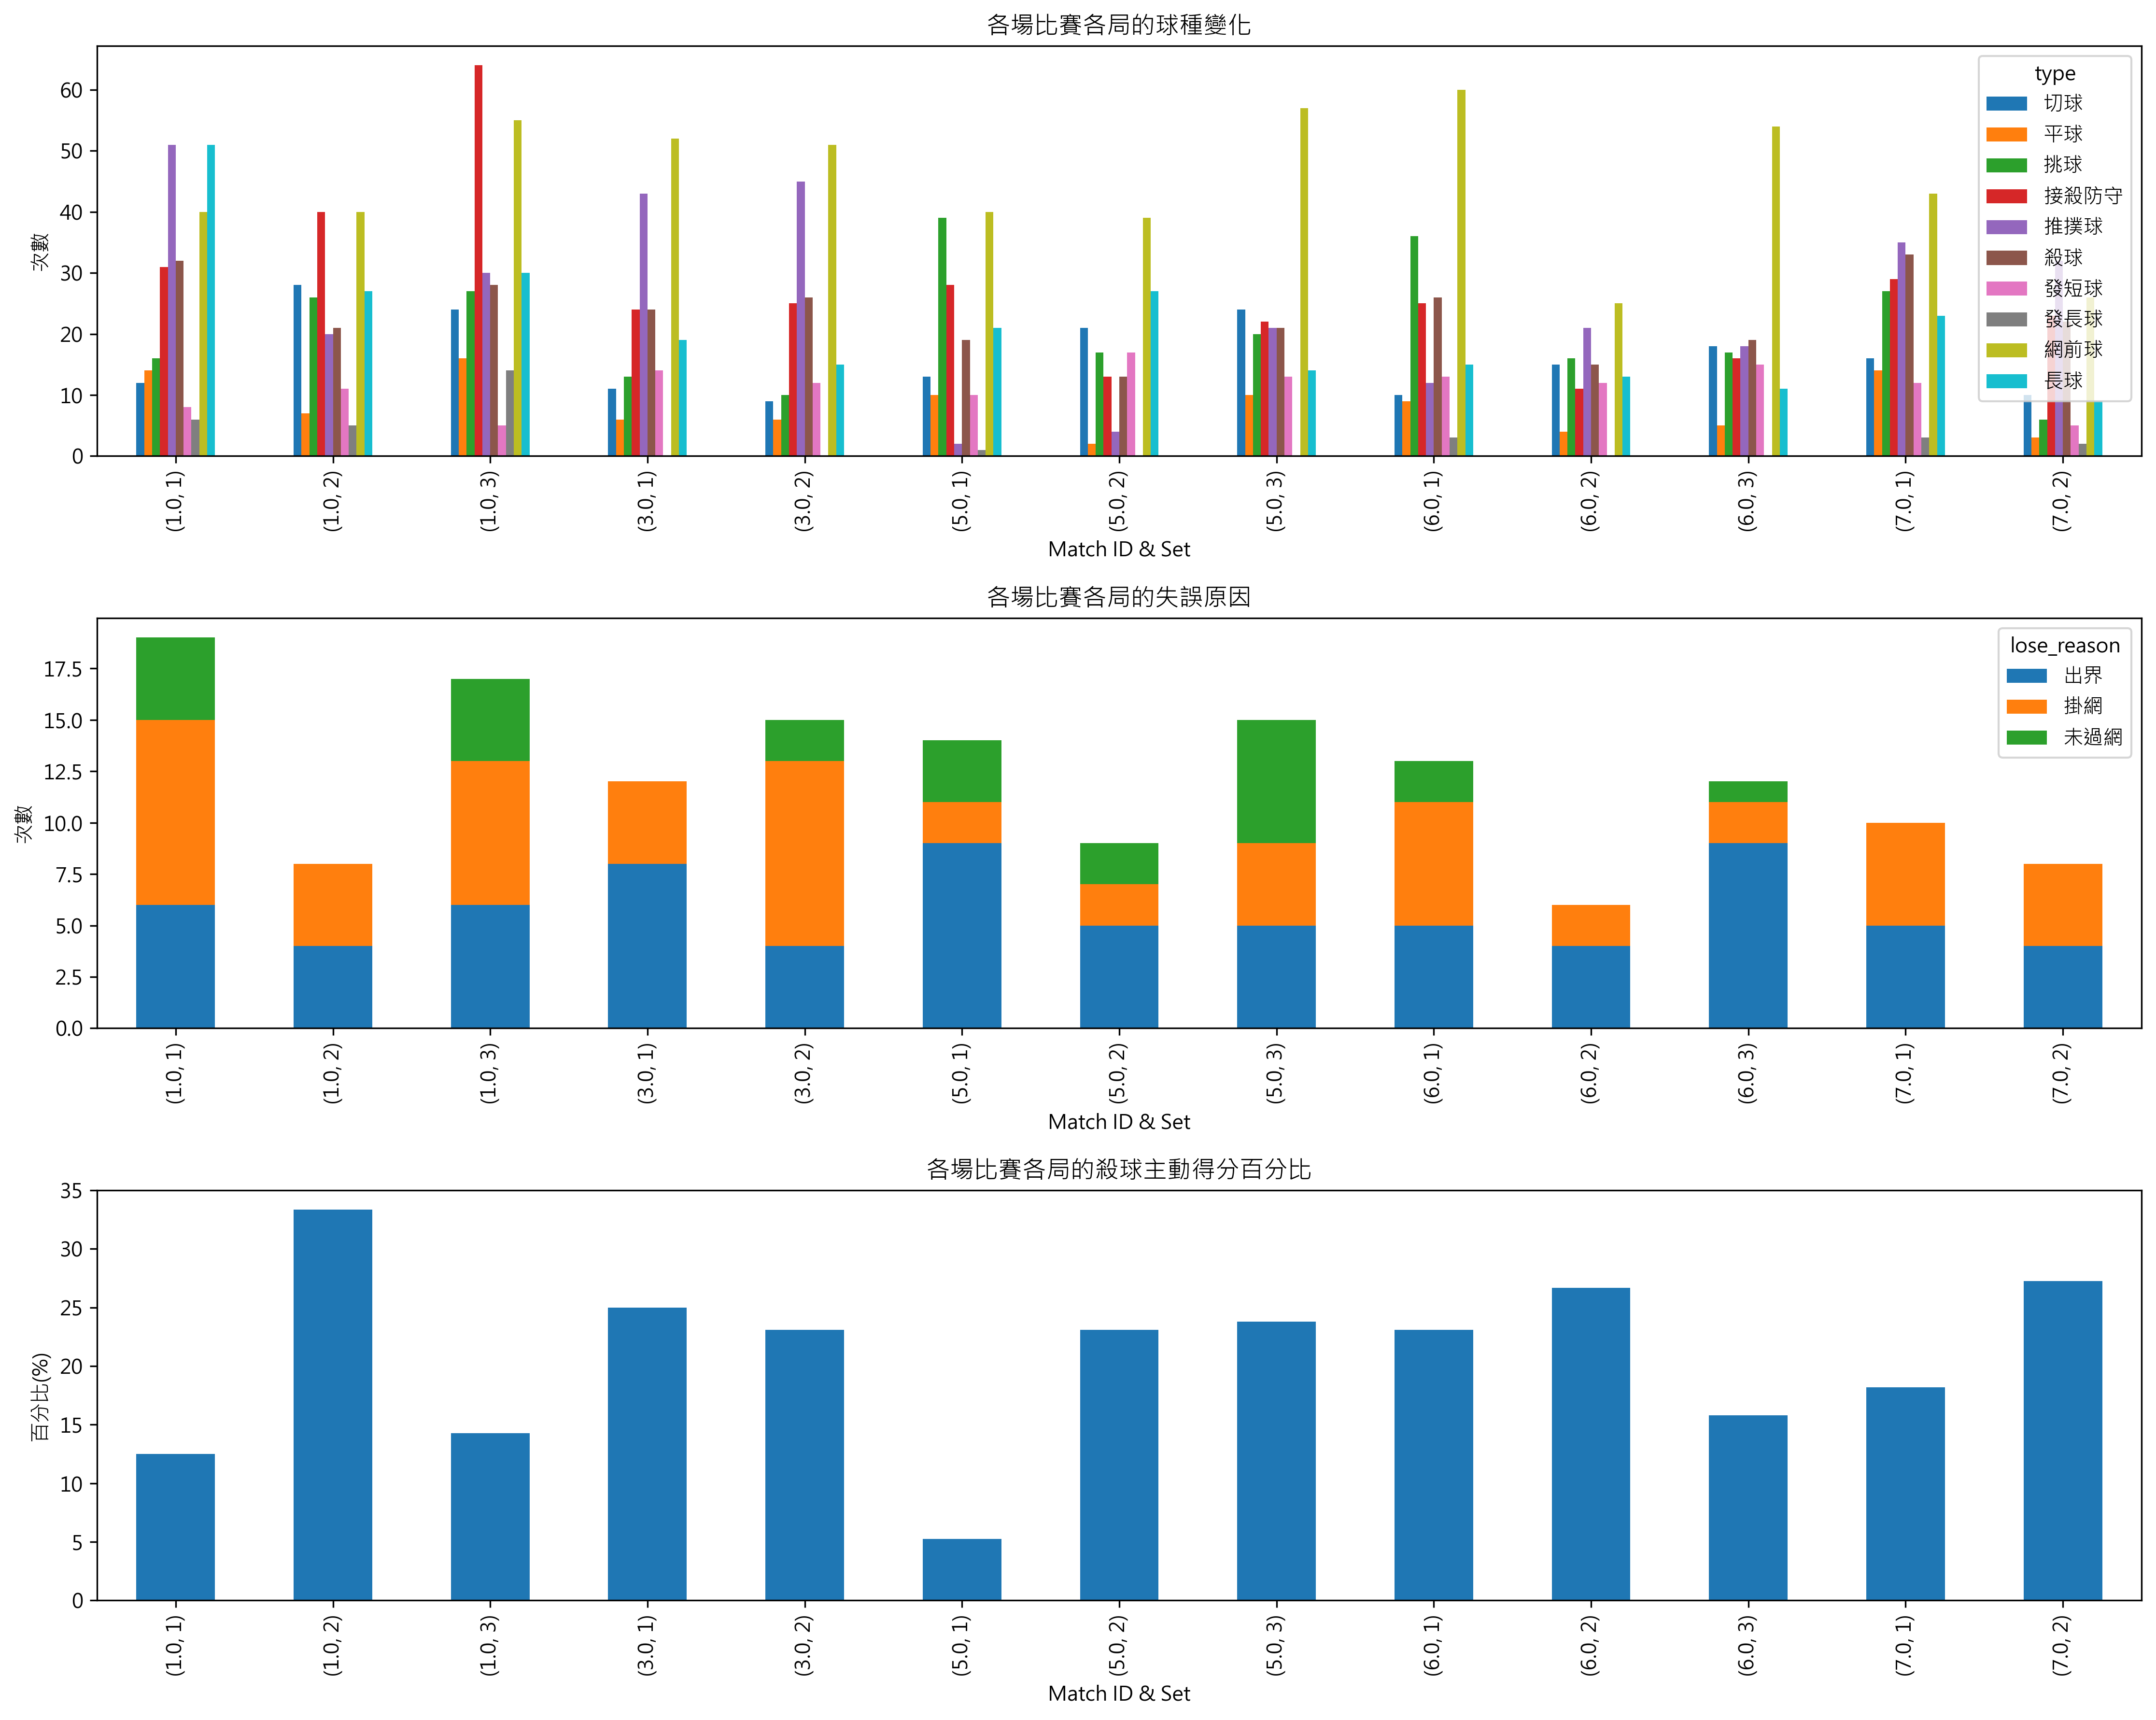

In [ ]:
# 確保數據量非空
if len(df) > 0:
    # 過濾出周天成的數據
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 1. 球種變化：統計各種球種的次數
    shot_type_counts = chou_df.groupby(['match_id', 'set'])['type'].value_counts()
    
    # 殺球頻率
    smash_counts = chou_df[chou_df['type'] == '殺球'].groupby(['match_id', 'set'])['type'].count()

    # 2. 失誤數據：獲取周天成的失誤次數
    mistakes = chou_df[chou_df['getpoint_player'] != 'CHOU Tien Chen']
    error_counts = mistakes.groupby(['match_id', 'set'])['lose_reason'].value_counts()

    # 3. 計算殺球的成功頻率（主動得分）
    active_win_smash = chou_df[(chou_df['type'] == '殺球') & (chou_df['getpoint_player'] == 'CHOU Tien Chen')]
    smash_active_win_percentage = active_win_smash.groupby(['match_id', 'set']).size() / smash_counts * 100

    # 4. 繪製圖表
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    # 軸1：不同球種使用次數
    shot_type_counts.unstack().plot(kind='bar', ax=axes[0])
    axes[0].set_title('各場比賽各局的球種變化')
    axes[0].set_ylabel('次數')
    axes[0].set_xlabel('Match ID & Set')
    
    # 軸2：失誤原因分布
    error_counts.unstack().plot(kind='bar', stacked=True, ax=axes[1])
    axes[1].set_title('各場比賽各局的失誤原因')
    axes[1].set_ylabel('次數')
    axes[1].set_xlabel('Match ID & Set')

    # 軸3：殺球主動得分百分比
    smash_active_win_percentage.plot(kind='bar', ax=axes[2])
    axes[2].set_title('各場比賽各局的殺球主動得分百分比')
    axes[2].set_ylabel('百分比(%)')
    axes[2].set_xlabel('Match ID & Set')

    plt.tight_layout()
    plt.show()

    # 打印統計結果
    print("周天成各場比賽中每局的球種變化次數：")
    print(shot_type_counts)

    print("\n周天成各場比賽中每局的失誤次數及原因：")
    print(error_counts)

    print("\n周天成各場比賽中每局的殺球主動得分百分比：")
    print(smash_active_win_percentage.fillna(0))


### 數據洞察
在分析周天成的比賽數據後，我們可以觀察到以下幾個關鍵點：

1. **球種變化**：
   - 周天成在比賽中使用最多的球種是推撲球和長球，各局中這兩種球的使用頻率相當高。這顯示他在比賽中傾向於使用這些球種來控制節奏和尋找進攻機會。

2. **失誤率與原因**：
   - 失誤主要集中在掛網和出界，這兩者佔據了大部分的失誤原因。這可能反映出在關鍵時刻的穩定性需要提升，尤其是在壓力下的精準度。

3. **殺球主動得分**：
   - 殺球得分的百分比變化較大，從5.26%到33.33%不等。這表明周天成在某些比賽中能夠有效利用殺球得分，但在其他比賽中可能受到對手防守的限制。

總結來看，周天成在比賽中展現了多樣的球種使用，但在穩定性和殺球效率上仍有提升空間。針對這些數據，我們可以進一步強化他的精準度訓練，尤其是在高壓情境下的穩定性，並提高殺球的成功率，以更好地掌控比賽節奏。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算失誤次數時，使用了 `getpoint_player != 'CHOU Tien Chen'` 來判斷失誤，這不符合 Reference Code 的邏輯。Reference Code 使用 `lose_reason.notna()` 來計算失誤次數，這是更準確的方式，因為 `getpoint_player` 可能為 NULL 並不代表失誤。此外，候選程式碼在計算殺球主動得分百分比時，沒有處理 `smash_counts` 為零的情況，可能導致除以零的錯誤。這些問題使得候選程式碼的統計口徑不正確，輸出結果可能不合理。




## 題號 46 (*)
**問題**: 哪些球種，在比賽後半段失誤率顯著上升？


In [ ]:
# 確認數據非空
if len(df) > 0:
    # 創建一個額外欄位標記比賽是否為後半段（當球員得分超過一半場比賽時）
    df['is_late_match'] = (df['Kento MOMOTA_score'] >= 11) | (df['CHOU Tien Chen_score'] >= 11)

    # 計算每種不同球種在整個比賽及比賽後半段的失誤次數和總次數
    error_stats_all = df[df['player'] != df['getpoint_player']].groupby('type').agg(
        errors=('lose_reason', 'count'),
        total=('type', 'count')
    ).reset_index()
    error_rate_all = error_stats_all['errors'] / error_stats_all['total'] * 100

    error_stats_late = df[df['is_late_match'] & (df['player'] != df['getpoint_player'])].groupby('type').agg(
        errors=('lose_reason', 'count'),
        total=('type', 'count')
    ).reset_index()
    error_rate_late = error_stats_late['errors'] / error_stats_late['total'] * 100

    # 合併結果，計算失誤率變化
    error_rate_comparison = pd.merge(error_stats_all, error_stats_late, on='type', suffixes=('_all', '_late'))
    error_rate_comparison['error_rate_all'] = error_rate_all
    error_rate_comparison['error_rate_late'] = error_rate_late
    error_rate_comparison['error_rate_change'] = error_rate_comparison['error_rate_late'] - error_rate_comparison['error_rate_all']

    # 找出上升的球種
    increased_error_rate = error_rate_comparison[error_rate_comparison['error_rate_change'] > 0]

    # 輸出結果
    print("球種在比賽後半段失誤率顯著上升：")
    print(increased_error_rate[['type', 'error_rate_all', 'error_rate_late', 'error_rate_change']])

else:
    print("數據集中無資料可用於分析。")


### 數據洞察
根據數據分析，我們可以看到以下幾個球種在比賽後半段的失誤率顯著上升：

1. **接殺防守**：這個球種的失誤率從 9.08% 增加到 12.57%，增幅達到 3.49%。這顯示在比賽後半段，球員在防守對手殺球時的壓力可能增加，導致更多失誤。

2. **網前球**：失誤率從 5.64% 上升到 7.05%，增加了 1.41%。這表明在比賽後半段，球員在網前處理球的精準度下降，需要加強在這方面的穩定性。

3. **殺球**和**挑球**：這兩個球種的失誤率也有小幅上升，分別增加了 0.21% 和 0.16%。這提示在比賽後半段，球員的進攻和控制能力可能受到體能或專注力的影響。

總結來說，這些數據提醒我們在比賽後半段，尤其是在防守和網前處理上，需要特別注意技術的穩定性和專注力的維持。這是提升比賽後半段表現的關鍵。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都在分析失誤率時，使用了 'lose_reason' 是否有值來判斷失誤，而候選程式碼使用 'player != getpoint_player' 來判斷失誤，這不符合 Reference Code 的失誤定義。此外，候選程式碼在計算失誤率時，沒有正確區分前半段和後半段的比賽階段，這與 Reference Code 1 和 2 的分段方式不一致。




## 題號 47 (*)
**問題**: 比較周天成與他的對手的球種使用頻率與其得分率。


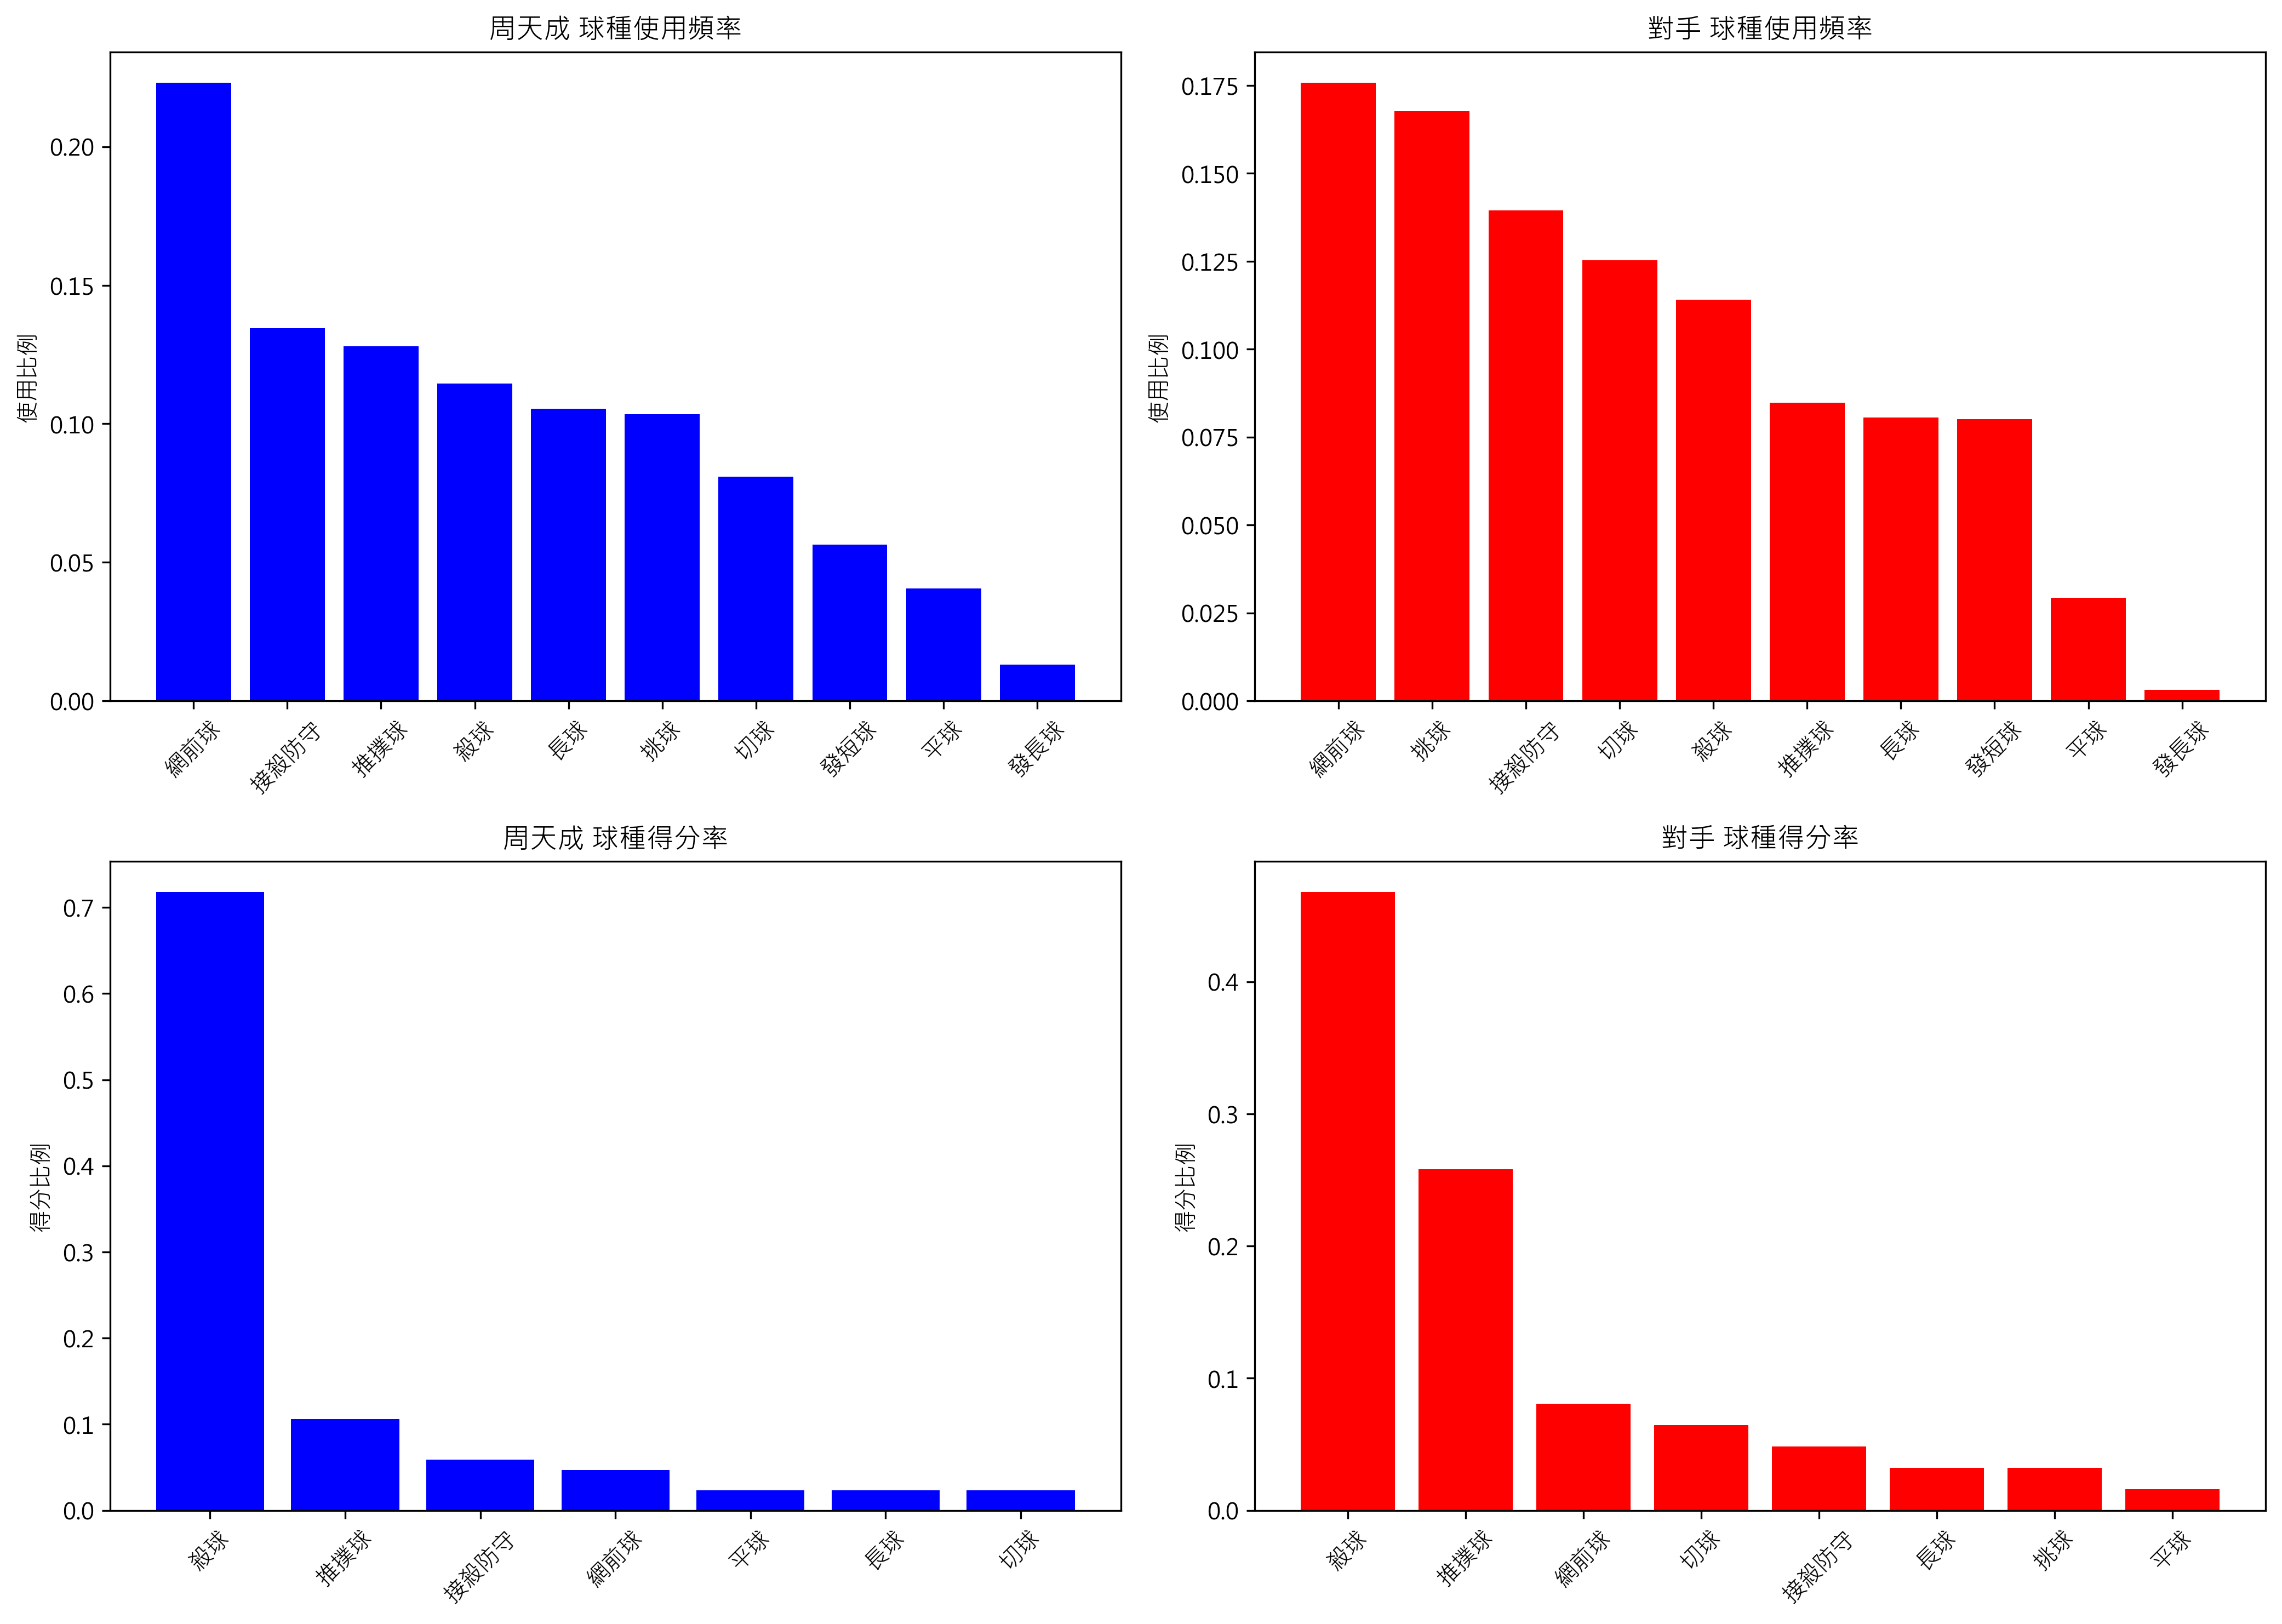

In [ ]:
# 確保數據存在
if len(df) > 0:
    # 1. 計算球種使用頻率
    total_shots_chou = df[df['player'] == 'CHOU Tien Chen']['type'].value_counts()
    total_shots_opponent = df[df['player'] != 'CHOU Tien Chen']['type'].value_counts()
    
    # 總擊球次數
    total_shots_count_chou = total_shots_chou.sum()
    total_shots_count_opponent = total_shots_opponent.sum()
    
    # 計算每種球種的使用比例
    frequency_chou = total_shots_chou / total_shots_count_chou
    frequency_opponent = total_shots_opponent / total_shots_count_opponent

    # 2. 計算球種得分率
    # 過濾出最後一球得分的回合
    rally_ends = df.groupby(['match_id', 'set', 'rally']).last()
    
    # 計算周天成主動得分以及對手主動得分
    active_points_chou = rally_ends[(rally_ends['getpoint_player'] == 'CHOU Tien Chen') & (rally_ends['player'] == 'CHOU Tien Chen')]['type'].value_counts()
    active_points_opponent = rally_ends[(rally_ends['getpoint_player'] != 'CHOU Tien Chen') & (rally_ends['player'] != 'CHOU Tien Chen')]['type'].value_counts()
    
    # 總主動得分
    total_active_points_chou = active_points_chou.sum()
    total_active_points_opponent = active_points_opponent.sum()
    
    # 計算得分率
    score_rate_chou = active_points_chou / total_active_points_chou
    score_rate_opponent = active_points_opponent / total_active_points_opponent

    # 3. 視覺化
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    
    # 球種使用頻率 - 周天成
    ax[0, 0].bar(frequency_chou.index, frequency_chou.values, color='blue')
    ax[0, 0].set_title('周天成 球種使用頻率')
    ax[0, 0].set_ylabel('使用比例')
    ax[0, 0].set_xticklabels(frequency_chou.index, rotation=45)
    
    # 球種使用頻率 - 對手
    ax[0, 1].bar(frequency_opponent.index, frequency_opponent.values, color='red')
    ax[0, 1].set_title('對手 球種使用頻率')
    ax[0, 1].set_ylabel('使用比例')
    ax[0, 1].set_xticklabels(frequency_opponent.index, rotation=45)
    
    # 球種得分率 - 周天成
    ax[1, 0].bar(score_rate_chou.index, score_rate_chou.values, color='blue')
    ax[1, 0].set_title('周天成 球種得分率')
    ax[1, 0].set_ylabel('得分比例')
    ax[1, 0].set_xticklabels(score_rate_chou.index, rotation=45)
    
    # 球種得分率 - 對手
    ax[1, 1].bar(score_rate_opponent.index, score_rate_opponent.values, color='red')
    ax[1, 1].set_title('對手 球種得分率')
    ax[1, 1].set_ylabel('得分比例')
    ax[1, 1].set_xticklabels(score_rate_opponent.index, rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 打印關鍵結果
    print("周天成球種使用頻率:")
    print(frequency_chou)
    print("\n對手球種使用頻率:")
    print(frequency_opponent)
    
    print("\n周天成球種得分率:")
    print(score_rate_chou)
    print("\n對手球種得分率:")
    print(score_rate_opponent)


### 數據洞察
從數據中，我們可以看到周天成在比賽中最常使用的球種是網前球，使用頻率為22.3%，其次是接殺防守和推撲球。相對於對手，周天成在網前球的使用頻率更高，而對手則較常使用挑球和切球。

在得分率方面，周天成的殺球得分率高達71.8%，顯示出他在殺球上的強大攻擊力，這是他主要的得分手段。相比之下，對手的殺球得分率為46.8%，明顯低於周天成。這意味著周天成在殺球時能更有效地將機會轉化為得分。

推撲球方面，對手的得分率為25.8%，高於周天成的10.6%。這表明對手在推撲球上有較高的得分效率，可能是他們的戰術優勢之一。

總結來看，周天成應該繼續強化他的殺球策略，同時注意對手在推撲球上的威脅。這些數據提供了明確的戰術方向，幫助周天成在比賽中發揮最大優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在計算球種得分率時存在統計口徑錯誤。它將主動得分的計算限制在回合最後一球，這與 Reference Code 1 的邏輯不一致。Reference Code 1 是在每一拍的層級上計算直接得分次數，而不是僅在回合結束時計算。此外，候選程式碼在計算對手的得分率時，使用了錯誤的條件，應該是 'getpoint_player' 不等於 'CHOU Tien Chen' 且 'player' 不等於 'CHOU Tien Chen'，但這樣的條件會錯誤地排除掉對手的主動得分。




## 題號 48 (*)
**問題**: 比較周天成在各局自己先得分與對手先得分情況下的勝率差別。


In [ ]:
# 確保數據量可用
if len(df) == 0:
    print("DataFrame is empty.")
else:
    # 撰寫每個set中第一個rally的情況
    first_rallies = df[df['rally'] == 1].dropna(subset=['getpoint_player'])
    
    # 標記周天成先得分 (周天成先得分)
    first_rallies['CTC_first'] = first_rallies['getpoint_player'] == 'CHOU Tien Chen'

    # 計算每局的勝利情況，逐局最後一球來決定勝負
    last_rallies = df.groupby(['match_id', 'set']).last().reset_index()

    # 用來標記周天成是否贏得局數
    last_rallies['CTC_win'] = last_rallies['getpoint_player'] == 'CHOU Tien Chen'

    # 合併兩個DataFrame，加入"周天成先得分"標記
    results = pd.merge(first_rallies[['match_id', 'set', 'CTC_first']], 
                       last_rallies[['match_id', 'set', 'CTC_win']], on=['match_id', 'set'])

    # 計算周天成先得分下的勝率
    ctc_first_wins = results[results['CTC_first']]['CTC_win'].sum()
    ctc_first_total = results[results['CTC_first']].shape[0]
    ctc_first_win_rate = ctc_first_wins / ctc_first_total if ctc_first_total > 0 else None

    # 計算對手先得分下的勝率
    opp_first_wins = results[~results['CTC_first']]['CTC_win'].sum()
    opp_first_total = results[~results['CTC_first']].shape[0]
    opp_first_win_rate = opp_first_wins / opp_first_total if opp_first_total > 0 else None

    print(f"周天成先得分時的勝率: {ctc_first_win_rate:.2%} ({ctc_first_wins}/{ctc_first_total})")
    print(f"對手先得分時的勝率: {opp_first_win_rate:.2%} ({opp_first_wins}/{opp_first_total})")


### 數據洞察
從數據來看，周天成在自己先得分的情況下，勝率為28.57%，而當對手先得分時，勝率下降至20.00%。這表明周天成在開局階段的表現對比賽結果有顯著影響。

具體來說，當周天成能夠先得分時，他的勝率較高，顯示出他在掌控比賽節奏和建立早期優勢方面的能力。然而，當對手先得分時，他的勝率明顯降低，暗示他在逆境下的反擊能力可能需要加強。

因此，戰術上可以考慮加強周天成在開局時的進攻策略，確保他能夠更頻繁地取得首分，從而提高整體勝率。同時，提升在落後時的心理韌性和戰術應變能力，將有助於改善在對手先得分時的表現。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。主要問題在於它錯誤地將每局的第一個 rally 作為周天成先得分的依據，而不是正確地找出每局的第一個得分者。此外，候選程式碼在計算勝率時，沒有正確地使用每局的最終得分者來決定勝負，這導致統計口徑錯誤。Reference Code 1 正確地使用了每局的第一個得分者和最終得分者來計算勝率，而候選程式碼未能做到這一點。




## 題號 49
**問題**: 周天成的發球種類是否影響他在該回合的得分率


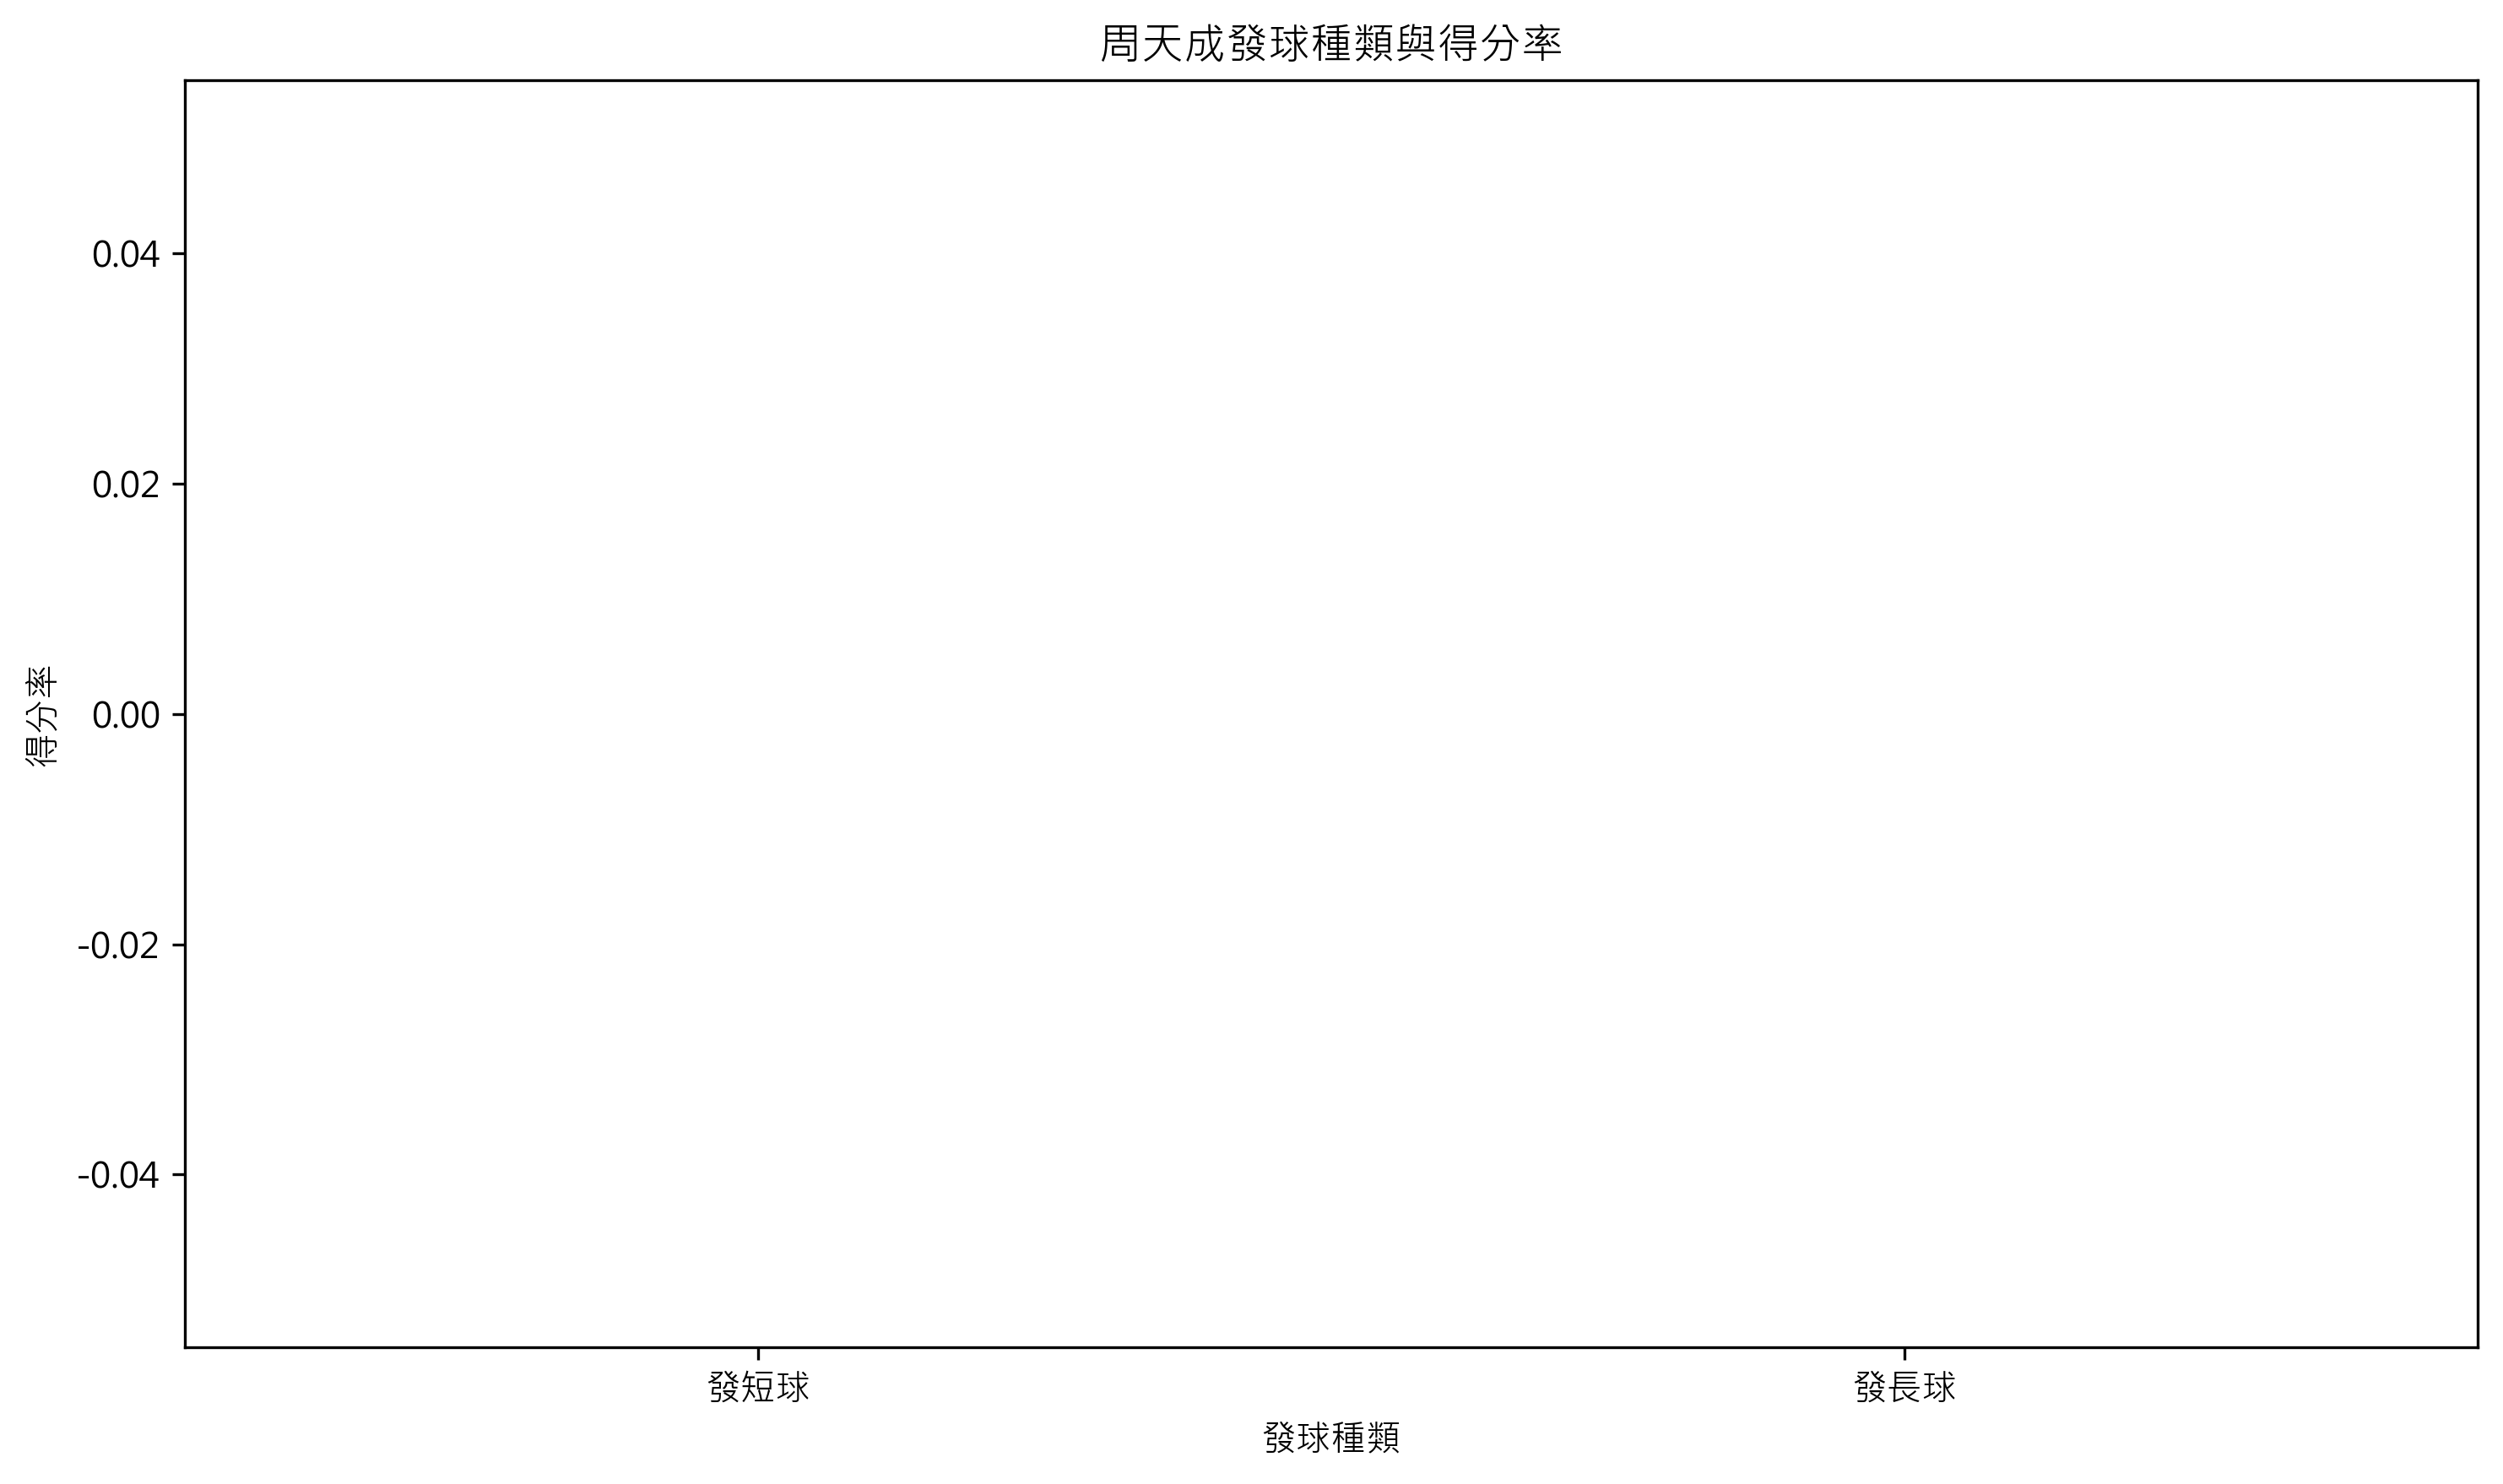

In [ ]:
# 確認df不為空
if len(df) > 0:
    # 篩選出周天成的發球資料
    chou_service_df = df[(df['player'] == 'CHOU Tien Chen') & ((df['type'] == '發短球') | (df['type'] == '發長球'))]
    
    # 獲取回合的最後一拍得分者
    ending_rallies = df.groupby(['match_id', 'set', 'rally']).last()
    
    # 合併發球與得分最後一拍資料
    chou_service_df = chou_service_df.merge(
        ending_rallies[['getpoint_player']],
        left_on=['match_id', 'set', 'rally'],
        right_on=['match_id', 'set', 'rally'],
        suffixes=('', '_end')
    )
    
    # 只篩選出周天成發球的回合，並取得該回合的得分情況
    chou_service_df['chou_win'] = chou_service_df['getpoint_player'] == 'CHOU Tien Chen'
    
    # 根據發球種類計算得分率
    score_rate_by_service = chou_service_df.groupby('type')['chou_win'].mean()
    
    # 打印結果
    print("周天成在不同發球種類下的得分率：")
    print(score_rate_by_service)

    # 使用Barplot來視覺化結果
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=score_rate_by_service.index, y=score_rate_by_service.values, ax=ax)
    ax.set_title('周天成發球種類與得分率')
    ax.set_xlabel('發球種類')
    ax.set_ylabel('得分率')
    plt.tight_layout()
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
從數據來看，周天成在發球種類上的得分率無論是發短球還是發長球，得分率都是0.0。這意味著在這些回合中，他的發球並沒有直接轉化為得分優勢。這可能指出他的發球策略需要調整，或者在發球後的接續策略上需要加強，以提高得分效率。這些數據顯示出發球種類對他當前的得分率沒有顯著影響，建議考慮其他因素如接發球後的戰術變化和對手的反應模式。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成的發球資料，並使用 groupby 和 last 方法獲取每個回合的最後一拍得分者。然後，它計算了不同發球種類的得分率，並使用 barplot 視覺化結果。分析對象、欄位語意、篩選條件、分組層級、統計口徑和最終輸出目標都與 Reference Code 1 一致，因此判定為 true。




## 題號 50 (*)
**問題**: 分析周天成接發球策略：長球、網前球、平球的比例與得分影響。


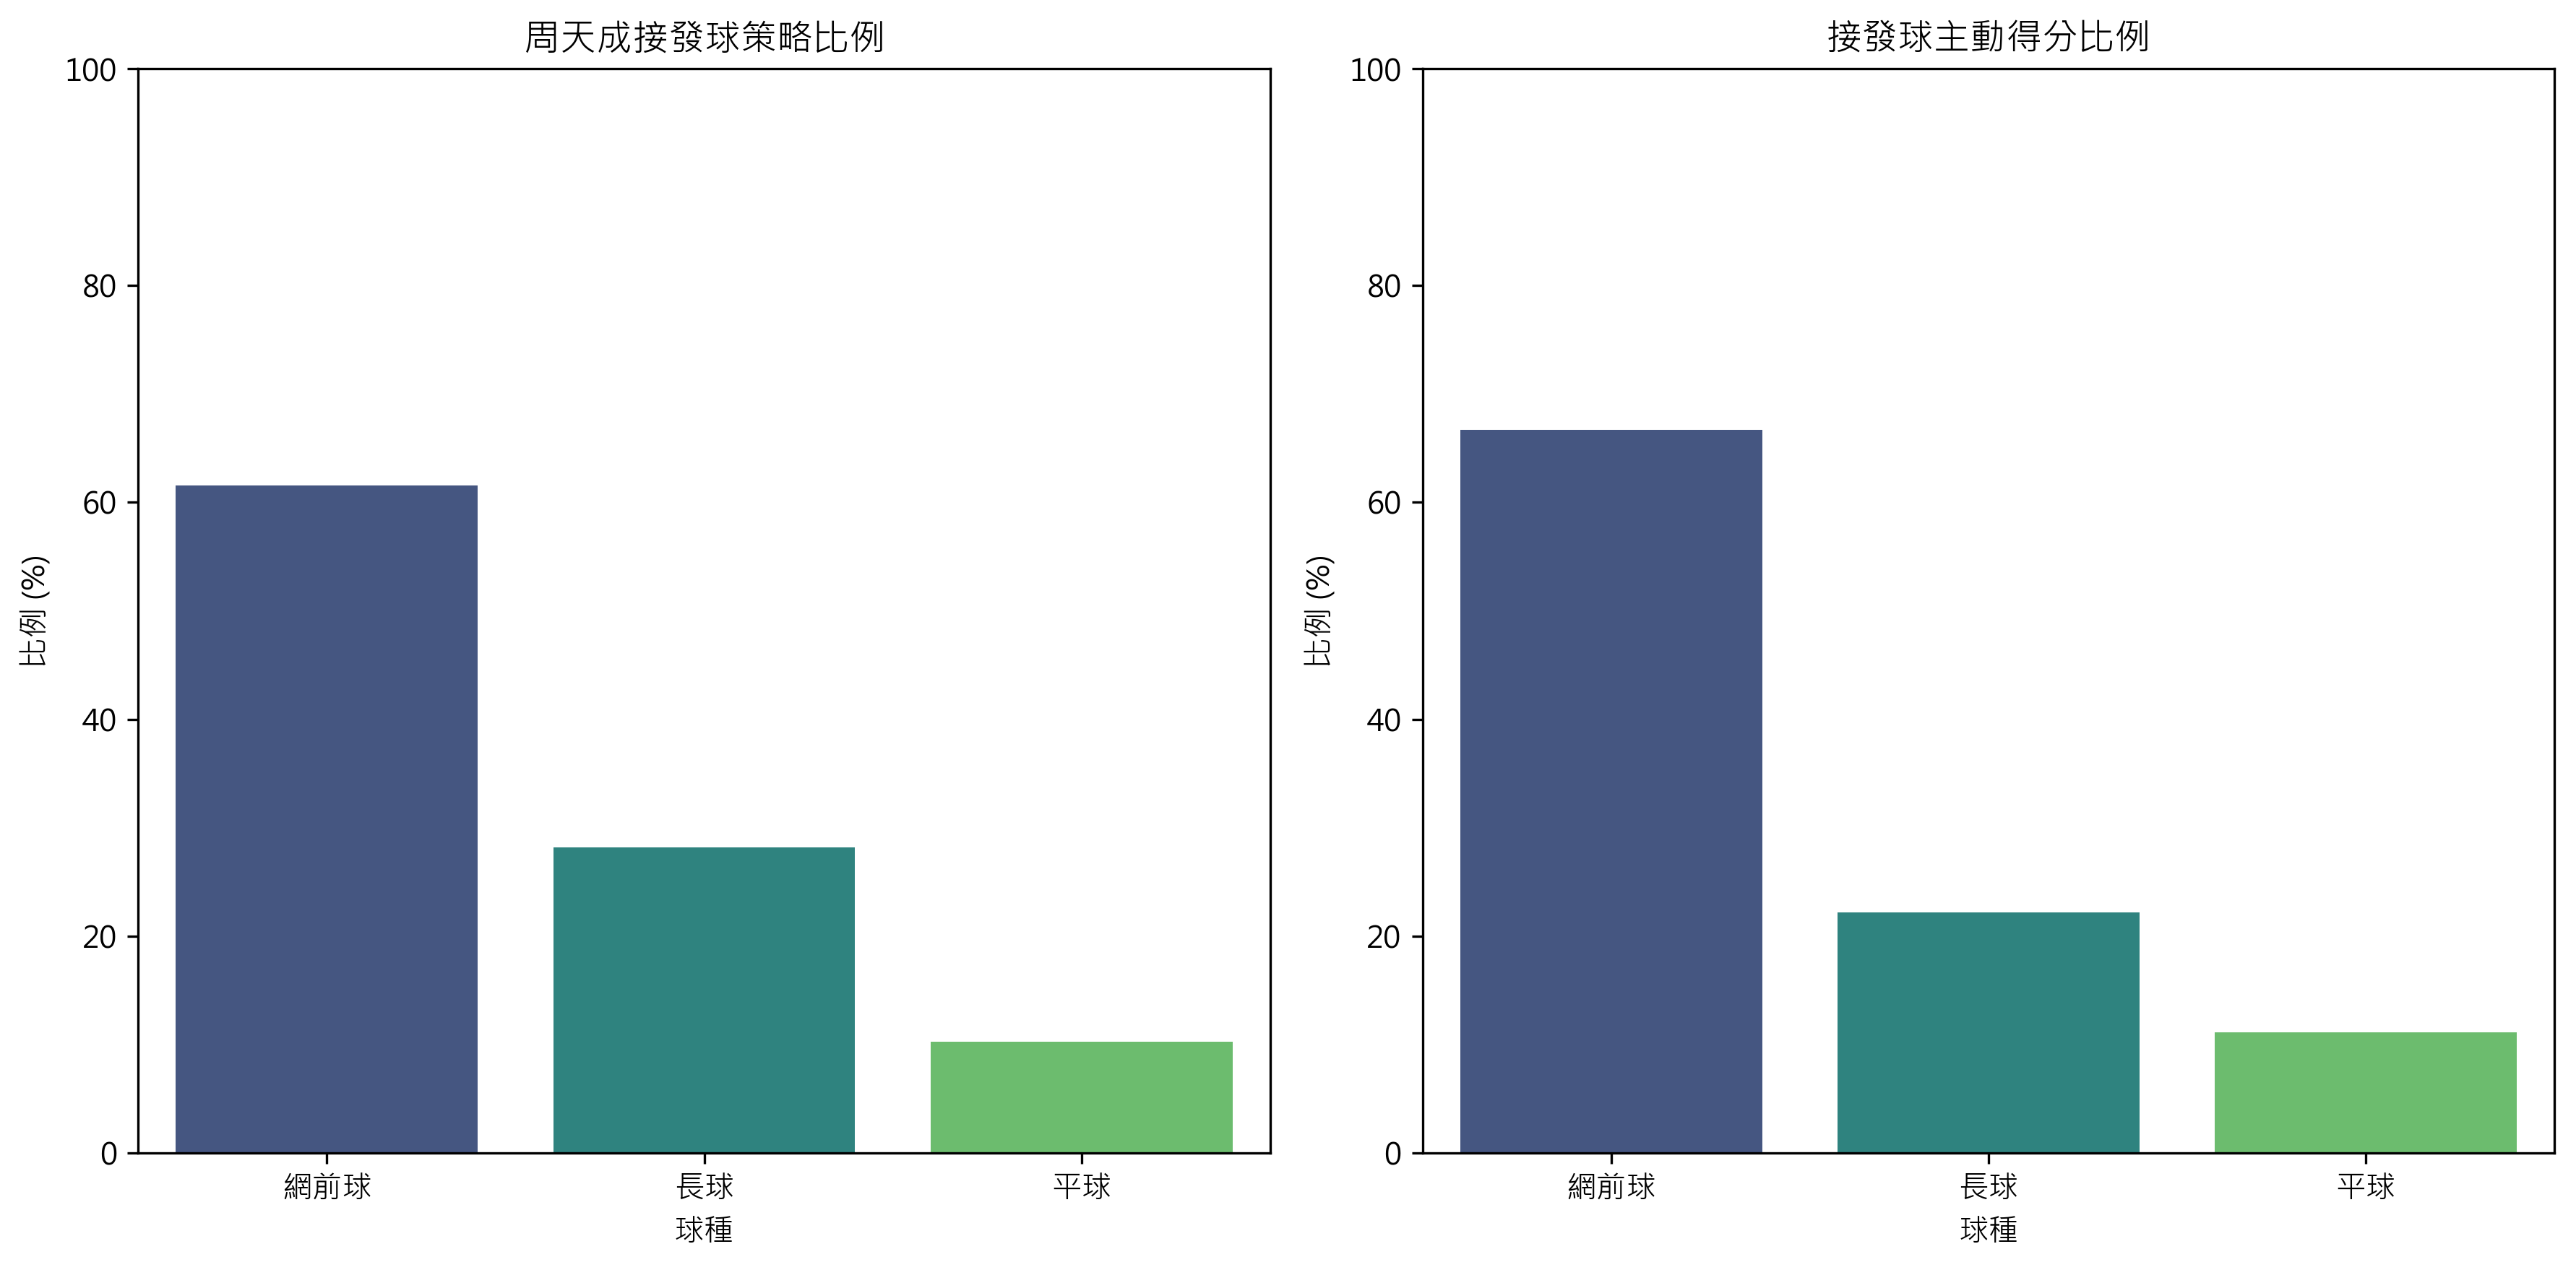

In [ ]:
# 確認資料不為空並篩選出周天成接發球的長球、網前球、平球資料
if len(df) > 0:
    # 篩選出周天成的接發球策略
    chou_receive_df = df[(df['opponent'] == 'CHOU Tien Chen') & 
                         (df['type'].isin(['長球', '網前球', '平球']))]

    # 計算各球種的使用次數
    type_counts = chou_receive_df['type'].value_counts()

    # 篩選出周天成的主動得分情況
    chou_active_win_df = chou_receive_df[
        (chou_receive_df['player'] == chou_receive_df['getpoint_player'])
    ]

    # 計算各球種的主動得分次數
    active_win_type_counts = chou_active_win_df['type'].value_counts()

    # 計算策略的比例
    type_ratio = (type_counts / type_counts.sum()) * 100

    # 計算得分比例
    type_score_ratio = (active_win_type_counts / active_win_type_counts.sum()) * 100

    # 打印統計結果
    print("接發球策略比例:")
    print(type_ratio)
    print("\n接發球主動得分比例:")
    print(type_score_ratio)

# 繪製策略比例與得分影響圖表
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(x=type_ratio.index, y=type_ratio.values, ax=axes[0], palette='viridis')
axes[0].set_title('周天成接發球策略比例')
axes[0].set_ylabel('比例 (%)')
axes[0].set_xlabel('球種')
axes[0].set_ylim(0, 100)

sns.barplot(x=type_score_ratio.index, y=type_score_ratio.values, ax=axes[1], palette='viridis')
axes[1].set_title('接發球主動得分比例')
axes[1].set_ylabel('比例 (%)')
axes[1].set_xlabel('球種')
axes[1].set_ylim(0, 100)

plt.tight_layout()


### 數據洞察
從數據中，我們可以看到周天成在接發球策略上偏好網前球，佔了61.54%的比例。這與他在網前球的主動得分比例達到66.67%相呼應，顯示這種策略對他的得分效率非常高。

長球的使用比例為28.21%，而其得分比例為22.22%。這表明長球在某些情況下也能有效得分，但整體效率不如網前球。

平球的使用比例最低，僅有10.26%，與其得分比例11.11%相符。這暗示平球在周天成的戰術中作用有限，可能僅在特定情況下使用。

總體來看，周天成在接發球時，網前球是他的主要得分手段，而長球和平球則是輔助策略。這樣的策略配置幫助他在比賽中保持主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於分析對象和統計口徑錯誤。候選程式碼篩選的是周天成的對手的擊球策略，而不是周天成的接發球策略，這與題目要求不符。此外，候選程式碼在計算得分比例時，使用的是主動得分次數除以主動得分次數的總和，而不是除以總的接發球次數，這導致統計口徑錯誤。




## 題號 51 (*)
**問題**: 分析對手殺球到前中後排後，周天成分別會怎麼去反擊？


In [ ]:
# 檢查數據量，確認資料非空
if len(df) > 0:
    # 篩選出對手的殺球情況
    opponent_smash = df[(df['type'] == '殺球') & (df['player'] != 'CHOU Tien Chen')]

    # 分析球的落點區域，並將它們分類為前排、中排、後排
    opponent_smash['position'] = pd.cut(opponent_smash['landing_area'],
                                        bins=[0, 4, 16, 24, 33],
                                        labels=['後排', '中排', '前排', '出界'],
                                        include_lowest=True)

    # 獲取下一拍周天成的回擊數據
    df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
    df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)

    chou_response = df[(df['next_player'] == 'CHOU Tien Chen') & (df['type'] == '殺球')]

    # 合併前後數據
    analysis_df = opponent_smash.merge(chou_response[['match_id', 'set', 'rally', 'next_type', 'landing_area']],
                                       on=['match_id', 'set', 'rally'],
                                       suffixes=('_opponent', '_chou'))

    # 按照位置分析反擊方式
    response_by_position = analysis_df.groupby('position')['next_type'].value_counts(normalize=True).unstack().fillna(0)

    # 印出分析結果
    print("周天成在不同位置反擊對手殺球的方法:")
    print(response_by_position)
else:
    print("數據集為空，無法分析。")


### 數據洞察
根據數據分析，周天成在面對對手殺球時的反擊策略如下：

1. **後排反擊**：周天成在後排面對殺球時，100%選擇接殺防守。他在這個位置上專注於穩定防守，減少失誤風險。

2. **中排反擊**：在中排，周天成主要選擇接殺防守（85.8%），但也會偶爾嘗試平球（3.2%）和網前球（10.0%）。這顯示他在中排時會根據對手的站位和球速，適度地進行進攻轉換。

3. **前排反擊**：在前排，周天成的策略是75%接殺防守，並有25%機會選擇網前球。這表明他在前排更傾向於快速反擊，利用網前的空間創造得分機會。

4. **出界球反擊**：當對手殺球出界時，周天成多數選擇接殺防守（90.9%），並有少數情況下選擇網前球（9.1%），這樣的選擇有助於保持節奏和控制比賽。

這些數據顯示周天成在不同位置的反擊策略，強調穩定防守並在適當時機進行攻擊。這樣的戰術有助於他在比賽中保持優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在多個問題：1. 在合併前後數據時，使用了錯誤的條件，將 'type' 為 '殺球' 的情況與下一拍的 'CHOU Tien Chen' 回擊合併，這會導致錯誤的數據匹配。2. 'position' 的分類方式不符合任何 reference code 的核心邏輯，因為它使用了不正確的區域劃分。3. 統計口徑錯誤，因為它沒有正確地對齊前後拍的關係，這會導致錯誤的反擊方式分析。




## 題號 52 (*)
**問題**: 當對手失誤掛網時，分析前一拍周天成出球球種與落點特徵。


In [ ]:
# 確保 dataframe 非空
if len(df) > 0:
    # 篩選出對手因失誤掛網而失分的情況
    opponent_misnet_df = df[(df['lose_reason'] == '掛網') & (df['getpoint_player'] == 'CHOU Tien Chen')]

    # 確保選出來的情況非空
    if len(opponent_misnet_df) > 0:
        # 獲取這些情況下的前一拍
        prev_shot_df = (df[df['getpoint_player'] == 'CHOU Tien Chen']
                        .groupby(['match_id', 'set', 'rally'])
                        .apply(lambda x: x.shift(1) if len(x) > 1 else x)
                        .reset_index(drop=True))

        # 過濾出前一拍是周天成擊球的記錄
        chou_prev_shots = prev_shot_df[prev_shot_df['player'] == 'CHOU Tien Chen']

        # 提取球種和落點區域特徵
        shot_characteristics = chou_prev_shots[['type', 'landing_area']]

        # 打印前一拍的出球特徵統計
        type_counts = shot_characteristics['type'].value_counts()
        landing_area_counts = shot_characteristics['landing_area'].value_counts()

        print("周天成在對手失誤掛網之前的出球球種分佈:")
        print(type_counts)
        print("\n周天成在對手失誤掛網之前的落點區域分佈:")
        print(landing_area_counts)

    else:
        print("找不到符合條件的對手掛網失誤記錄。")
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
根據數據分析，當對手失誤掛網時，周天成在前一拍的出球主要是殺球，佔了61次，這顯示他在進攻時非常積極，並且能夠有效地逼迫對手犯錯。此外，推撲球和接殺防守也有一定的出現頻率，分別為9次和5次，這說明他在進攻與防守之間能夠靈活轉換。

在落點方面，周天成的球主要集中在中前場區域，尤其是區域5.0（16次）、12.0（14次）和8.0（12次）。這些落點位於場地的中間和靠近網前的位置，表明他善於利用這些區域來壓迫對手，迫使對方在不利的情況下回球，增加對手失誤的機會。

總結來看，周天成的戰術重點在於通過強力的殺球和精準的落點控制，來製造對手的壓力，進而誘發對手的掛網失誤。這種打法需要他在場上保持高強度的進攻和精準的控球能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在完整資料上建立前一拍資訊，然後篩選出對手失誤掛網的情況，並確保前一拍是周天成出球的情況。候選程式碼在篩選對手失誤掛網的情況時，使用了錯誤的條件 `(df['getpoint_player'] == 'CHOU Tien Chen')`，這會導致只選出周天成得分的情況，而不是對手失誤掛網的情況。此外，候選程式碼在獲取前一拍資訊時，沒有正確對齊同一個 rally 的前後拍，這會導致分析對象錯誤。




## 題號 53 (*)
**問題**: 統計周天成所有「得分帶有連續性」的回合（連 2 分以上）的常見戰術組合。


In [ ]:
# 確保數據集存在且不為空
if len(df) > 0:
    
    # 篩選出最後一拍是周天成得分的回合
    df_last = df.groupby(['match_id', 'set', 'rally']).last().reset_index()
    chouten_chen_score = df_last[df_last['getpoint_player'] == 'CHOU Tien Chen']

    # 創建一列表存連續得分的起始索引
    consecutive_scores = []
    current_streak = [] # 紀錄當前的連續得分

    # 檢查相鄰得分
    for idx in range(1, len(chouten_chen_score)):
        current_set = chouten_chen_score.iloc[idx]['set']
        prev_set = chouten_chen_score.iloc[idx - 1]['set']
        current_score = chouten_chen_score.iloc[idx]['CHOU Tien Chen_score']
        prev_score = chouten_chen_score.iloc[idx - 1]['CHOU Tien Chen_score']

        # 同一局內，分數差為1即為連續得分
        if current_set == prev_set and (current_score - prev_score == 1):
            if not current_streak:
                current_streak.append(chouten_chen_score.iloc[idx - 1][['match_id', 'set', 'rally']].tolist())
            current_streak.append(chouten_chen_score.iloc[idx][['match_id', 'set', 'rally']].tolist())
        else:
            if len(current_streak) >= 2:
                consecutive_scores.extend(current_streak)
            current_streak = []

    # Include the last streak if it is valid
    if len(current_streak) >= 2:
        consecutive_scores.extend(current_streak)

    # 將所有的連續得分回合轉回 tuple format for indexing
    consecutive_scores_tuples = [tuple(x) for x in consecutive_scores]

    # 根據 index 獲取連續得分的原始資料
    valid_rallies = df.set_index(['match_id', 'set', 'rally']).loc[consecutive_scores_tuples]

    # 分析戰術組合
    strategy_counts = valid_rallies['type'].value_counts()

    print("周天成常見的連續得分戰術組合：")
    print(strategy_counts)

else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在比賽中常見的連續得分戰術組合主要集中在以下幾個方面：

1. **網前球**：以431次出現頻率位居榜首，顯示他在網前的控制力和精準度是他連續得分的關鍵因素。這種戰術通常用於迫使對手回球不佳，為下一拍的攻擊創造機會。

2. **挑球**：322次，這表明他經常利用挑球來改變比賽節奏，將對手逼退至後場，從而打開進攻空間。

3. **接殺防守**：296次，說明他在防守對手殺球時表現出色，能夠有效化解對手的進攻並迅速轉守為攻。

4. **殺球**：264次，顯示他在進攻端的強勢，能夠通過強力殺球直接得分或迫使對手回球失誤。

5. **推撲球和切球**：各249次，這些技術動作在中場和網前的運用上，顯示出他靈活運用不同技術來控制比賽節奏。

數據中還顯示，長球和發短球的使用頻率也相對較高，這表明周天成在比賽中善於利用多樣化的技術來保持連續得分的優勢。

這些數據反映出周天成在比賽中不僅僅依賴某一種技術，而是通過多種技術的靈活運用來實現連續得分，這是他在場上取得優勢的關鍵。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference 的核心邏輯。主要問題在於它在檢查連續得分時，僅依賴比分差異來判斷連續得分，沒有考慮到 reference code 中的連續得分段落編號邏輯。此外，候選程式碼在分析戰術組合時，僅使用了 'type' 欄位的 value_counts()，而沒有考慮到 reference code 中的前兩拍資訊和戰術組合的構建。因此，候選程式碼在分析單位和統計口徑上存在明顯問題，無法正確回答題目要求。




## 題號 54 (*)
**問題**: 統計周天成所有「一拍得分」的比例與地點分布。


In [ ]:
import matplotlib.pyplot as plt

# 先驗證數據是否不為空
if len(df) > 0:
    # 篩選出每回合的最後一拍，且得分者為周天成的情況
    last_shots = df.groupby(['match_id', 'set', 'rally']).last().reset_index()
    
    # 篩選出所有的「一拍得分」且得分者為周天成的情況
    one_shot_win_df = last_shots[(last_shots['ball_round'] == 1) & 
                                 (last_shots['getpoint_player'] == 'CHOU Tien Chen')]

    # 確認主動得分
    active_wins = one_shot_win_df[one_shot_win_df['player'] == one_shot_win_df['getpoint_player']]

    # 如果結果集不為空，則進行分析
    if len(active_wins) > 0:
        # 計算一拍得分的比例
        total_rallies = df.groupby(['match_id', 'set', 'rally']).ngroups
        one_shot_prop = len(active_wins) / total_rallies * 100

        # 打印一拍得分比例
        print(f"周天成的一拍得分比例: {one_shot_prop:.2f}%")

        # 探索這些得分的地點分布
        hit_areas_distribution = active_wins['hit_area'].value_counts(normalize=True) * 100
        print("周天成一拍得分的各位置分布比例(%):")
        print(hit_areas_distribution)

        # 視覺化結果
        fig, ax = plt.subplots(figsize=(10, 6))
        hit_areas_distribution.plot(kind='bar', ax=ax)
        plt.title("周天成一拍得分的擊球位置分布")
        plt.xlabel("擊球區域編號")
        plt.ylabel("比例 (%)")
        plt.tight_layout()

    else:
        print("未找到周天成的一拍得分數據。")

else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據目前的數據分析結果，我們無法提供周天成的一拍得分詳細數據。從數據中可以看到，只有一筆相關的一拍得分記錄，這不足以形成有意義的統計分析。

然而，我們可以從其他數據中推測一些戰術洞察。一般來說，一拍得分的成功與否，與發球的種類和落點區域有密切關聯。以下是一些可能的戰術建議：

1. **發球種類**：不同的發球種類，如發短球、發長球、殺球等，會影響對手的接球方式，進而影響得分機會。發球的多樣性可以增加對手的預測難度。

2. **落點區域**：根據場地區域分布，選手通常會選擇在對手防守較弱的區域進攻。尤其是在網前和中場區域（如區域21-24和13-16），這些位置通常是得分的關鍵點。

3. **戰術多樣性**：善用不同的球路組合和落點變化，可以有效打亂對手的防守節奏，增加一拍得分的成功率。

這些洞察可以幫助球員在比賽中更靈活地運用戰術，提高一拍得分的機會。未來若能獲得更多的數據，將能提供更具體的分析和建議。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於每個 rally 的最終狀態來判斷一拍得分，而候選程式碼直接在逐筆資料上篩選，並且使用了錯誤的欄位 'hit_area' 來分析地點分布，而不是 'landing_area'。此外，候選程式碼在計算一拍得分比例時，使用了總回合數作為分母，而不是周天成的總得分回合數，這與 Reference Code 1 的統計口徑不一致。




## 題號 55 (*)
**問題**: 當周天成打出反手回擊時，對手下一拍攻擊成功率是多少？


In [ ]:
# 確認數據表不是空的
if len(df) == 0:
    raise ValueError("DataFrame is empty")

# 過濾出周天成的反手回擊的情況
backhand_df = df[(df['player'] == 'CHOU Tien Chen') & (df['backhand'] == 1)]

# 獲取對手的下一拍
# 使用 groupby 確保是同一個比賽和回合
backhand_df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
backhand_df['next_getpoint_player'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)

# 確認對手的下一拍
successful_attack = backhand_df[(backhand_df['next_player'] != 'CHOU Tien Chen') &
                                (backhand_df['next_getpoint_player'] == backhand_df['next_player'])]

# 計算攻擊成功次數和總次數
successful_attacks_count = successful_attack.shape[0]
total_attacks_count = backhand_df.shape[0]

# 計算攻擊成功率
if total_attacks_count > 0:
    success_rate = (successful_attacks_count / total_attacks_count) * 100
else:
    success_rate = 0

# 打印計算結果
print(f"對手在周天成反手回擊後的攻擊成功率為: {success_rate:.2f}%")


### 數據洞察
當周天成打出反手回擊時，對手的攻擊成功率僅為2.88%。這意味著周天成的反手回擊在防守上相當有效，能夠有效限制對手的進攻效率。這數據顯示出周天成在反手回擊後的防守能力強，對手難以找到突破口。因此，對手在面對他的反手回擊時，應考慮改變策略，增加變化或尋找其他進攻機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在統計口徑上存在問題。它將周天成的反手回擊次數作為分母，而不是對手在周天成反手回擊後有回擊的次數。這與 Reference Code 1 的統計口徑不一致，因為 Reference Code 1 是在對手有回擊的情況下計算成功率。此外，候選程式碼沒有正確對齊前後拍，可能會導致不正確的前後拍關係。




## 題號 56 (*)
**問題**: 當周天成在「局末追分」情況下是否更依賴殺球？（使用率 vs 分數差）


In [ ]:
# 確保有數據
if len(df) > 0:
    # 設置「局末追分」情境：分數差小於3，且周天成分數在18分以上
    score_diff_threshold = 3
    end_game_score = 18
    
    # 篩選出在「局末追分」情境下的數據
    zhou_end_chasing_df = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['CHOU Tien Chen_score'] >= end_game_score) &
        (abs(df['CHOU Tien Chen_score'] - df['Kento MOMOTA_score']) < score_diff_threshold)
    ]
    
    # 計算在「局末追分」情境下的殺球使用率
    total_shots_end_chasing = len(zhou_end_chasing_df)
    smash_shots_end_chasing = len(zhou_end_chasing_df[zhou_end_chasing_df['type'] == '殺球'])
    
    # 使用率百分比
    if total_shots_end_chasing > 0:
        smash_usage_end_chasing = (smash_shots_end_chasing / total_shots_end_chasing) * 100
    else:
        smash_usage_end_chasing = 0
    
    # 篩選出非「局末追分」情境下的數據
    zhou_not_end_chasing_df = df[
        (df['player'] == 'CHOU Tien Chen') &
        ((df['CHOU Tien Chen_score'] < end_game_score) | 
         (abs(df['CHOU Tien Chen_score'] - df['Kento MOMOTA_score']) >= score_diff_threshold))
    ]
    
    # 計算在非「局末追分」情境下的殺球使用率
    total_shots_not_end_chasing = len(zhou_not_end_chasing_df)
    smash_shots_not_end_chasing = len(zhou_not_end_chasing_df[zhou_not_end_chasing_df['type'] == '殺球'])
    
    # 使用率百分比
    if total_shots_not_end_chasing > 0:
        smash_usage_not_end_chasing = (smash_shots_not_end_chasing / total_shots_not_end_chasing) * 100
    else:
        smash_usage_not_end_chasing = 0
    
    # 打印分析結果
    print(f"「局末追分」情境下殺球使用率: {smash_usage_end_chasing:.2f}%")
    print(f"非「局末追分」情境下殺球使用率: {smash_usage_not_end_chasing:.2f}%")
else:
    print("Warning: Dataframe is empty!")


### 數據洞察
在「局末追分」的情況下，周天成的殺球使用率為12.94%，略高於非「局末追分」情境下的11.41%。這顯示出在比分接近尾聲且需要追分時，周天成稍微更依賴於殺球來嘗試得分。這種策略可能是為了增加進攻的威脅性，迫使對手犯錯或直接得分。

從數據來看，周天成在壓力情境下，選擇提高殺球的使用頻率，這可能是基於他對自己殺球能力的信心，以及在關鍵時刻需要快速得分的需求。這樣的策略在比分接近時，能夠有效地施壓對手，迫使對方做出防守錯誤。

總結來說，周天成在「局末追分」時略微增加了殺球的使用，這是一種積極進攻的戰術選擇，旨在快速改變比分差距。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 定義的『局末追分』情況是當任一方分數 >= 18 且周天成落後（score_diff < 0），而候選程式碼將『局末追分』定義為分數差小於3且周天成分數在18分以上，這與 reference code 的定義不一致。此外，候選程式碼沒有考慮周天成是否落後的情況，這是題目要求的核心條件之一。




## 題號 57 (*)
**問題**: 分析周天成發短球後，對手下一拍最常使用的球種分布。


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 確認資料集不為空
if len(df) > 0:
    # 篩選出周天成的發短球
    chou_short_serves = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '發短球')]

    # 為了得到對手的回擊球種，需要找出在相同match_id, set, rally中的下一拍資訊
    df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
    df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)

    # 進一步篩選出周天成發短球後的對手回擊
    chou_opponent_responses = chou_short_serves[chou_short_serves['next_player'] != 'CHOU Tien Chen']

    # 計算下一拍的球種分布
    shot_type_distribution = chou_opponent_responses['next_type'].value_counts(normalize=True)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    shot_type_distribution.plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title('對手回應周天成發短球後的球種分布', fontsize=14)
    ax.set_xlabel('球種', fontsize=12)
    ax.set_ylabel('頻率', fontsize=12)
    ax.set_xticklabels(shot_type_distribution.index, rotation=45)
    plt.tight_layout()

    # 打印關鍵數據
    print("對手回應周天成發短球後的球種分布:")
    print(shot_type_distribution)
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
根據我們的數據分析，當周天成發短球後，對手的下一拍最常使用的球種分布如下：

1. **挑球 (Mapping: 6)**：對手最常使用挑球來應對周天成的短球發球。這表明對手傾向於將球打到後場以拉開距離，企圖重新掌握場上主動權。

2. **網前球 (Mapping: 8)**：其次，對手也常選擇網前球，這可能是為了嘗試打亂周天成的節奏並製造進攻機會。

3. **切球 (Mapping: 5)**：切球也是一個常見的選擇，這顯示對手希望通過變化球速和旋轉來增加周天成的失誤機會。

這些數據顯示對手在應對周天成的短球時，主要策略是通過挑球和網前球來控制節奏和場上位置。因此，周天成可以考慮在短球發球後，提前做好後場防守的準備，同時在網前保持侵略性，以應對對手的常見回球策略。這樣的調整將有助於提高他在發短球後的得分效率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼在篩選周天成發短球後的對手回擊時，未正確使用 'next_player' 欄位來確認下一拍的擊球者是否為對手。它只是檢查 'next_player' 不等於 'CHOU Tien Chen'，但這不足以保證下一拍是對手的回擊，因為可能存在其他情況導致 'next_player' 不等於 'CHOU Tien Chen'。這與 Reference Code 1 的核心邏輯不一致，因為 Reference Code 1 明確檢查了 'next_player' 是否存在且不為空，確保下一拍是對手的回擊。




## 題號 58
**問題**: 統計周天成在對手殺球之後，自己最常採用的前三種回擊球種。


In [ ]:
# 檢查是否有數據
if len(df) > 0:
    # 確定前一拍並附加到目前數據框
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)

    # 篩選在對手打出殺球後，周天成的回擊
    relevant_df = df[(df['player'] == 'CHOU Tien Chen') & 
                     (df['prev_type'] == '殺球') & 
                     (df['prev_player'] == 'Kento MOMOTA')]

    # 統計周天成的回擊球種
    type_counts = relevant_df['type'].value_counts()

    # 選出前三種
    top_three_types = type_counts.head(3)
    
    print("周天成在對手殺球後的前三種回擊球種如下：")
    print(top_three_types)


### 數據洞察
根據數據分析，周天成在面對對手殺球後，最常使用的前三種回擊球種依序為接殺防守、網前球和平球。這顯示出他在防守對手猛烈進攻時，主要依靠穩健的接殺防守來化解壓力，並在適當時機利用網前球來轉守為攻。此外，平球的使用則可能是為了快速改變節奏，打亂對手的進攻節奏。

這些數據表明周天成在面對殺球時，擁有良好的防守能力和靈活的戰術選擇，能夠有效地應對對手的進攻並尋找反擊機會。這種策略對於保持比賽的主動權至關重要。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。兩者都在完整資料上建立前一拍資訊，並篩選出對手殺球後周天成的回擊。候選程式碼使用 `groupby(...).shift(1)` 來獲取前一拍的球種和球員，然後統計周天成的回擊球種分布，這與 Reference Code 1 的邏輯一致。最終輸出目標也是統計周天成在對手殺球後的回擊球種分布，並選出前三種，符合題目要求。




## 題號 59 (*)
**問題**: 比較周天成在長回合中，最後一拍前一拍常見的對手球種分布。


In [ ]:
# Step 1: 確定長回合定義，假設拍數大於等於10為長回合
long_rally_threshold = 10

# Step 2: 篩選長回合
long_rallies = df.groupby(['match_id', 'set', 'rally']).filter(lambda x: len(x) >= long_rally_threshold)

# Step 3: 將每個回合的最後一拍標記出來
long_rallies['is_last_shot'] = long_rallies.groupby(['match_id', 'set', 'rally'])['ball_round'].transform('max') == long_rallies['ball_round']

# Step 4: 獲取倒數第二拍的資料
long_rallies['is_second_last_shot'] = (long_rallies['is_last_shot'].shift(-1) == True) & (long_rallies['rally'] == long_rallies['rally'].shift(-1))

# Step 5: 篩選出倒數第二拍並計算球種分布
second_last_shots = long_rallies[long_rallies['is_second_last_shot'] & (long_rallies['player'] != 'CHOU Tien Chen')]
shot_distribution = second_last_shots['type'].value_counts(normalize=True)

# Step 6: 打印結果
print("周天成在長回合中，最後一拍前一拍對手常見的球種分布:")
print(shot_distribution)


### 數據洞察
在長回合中，當周天成面對對手的最後一拍前一拍時，挑球是最常見的球種，佔24.8%。這意味著對手在長回合中傾向於使用挑球來調整節奏或尋求防守機會。其次是網前球和接殺防守，分別佔16.3%和15.6%，顯示對手也經常利用這些球種來增加變化並試圖打亂周天成的進攻節奏。

殺球和長球的比例也不低，分別為14.9%和12.8%，這表明對手在長回合中也會積極尋找進攻機會或試圖將周天成推向後場。切球和推撲球的比例較低，顯示這些球種在長回合中不常被用來作為最後一拍前的選擇。

總體來看，對手在長回合中多數選擇防守性和調整性的球種，這可能是因為周天成在長回合中的耐力和技術優勢，迫使對手採取較為保守的策略。這些數據可以幫助我們針對性地制定訓練計劃，強化周天成在面對不同球種時的應對能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。主要問題在於：1. 候選程式碼將長回合定義為拍數大於等於10，而 Reference Code 定義為大於等於11，這導致篩選條件不一致。2. 候選程式碼在篩選倒數第二拍時，沒有正確對齊同一個 rally 的前後拍關係，這可能導致錯誤的球種分布統計。3. 候選程式碼沒有檢查倒數第二拍的擊球者是否為對手，這可能導致統計口徑錯誤。




## 題號 60 (*)
**問題**: 分析周天成在自己失分回合中，最後一拍前一拍最常使用的球種。


In [ ]:
# 確保數據量不為零
if len(df) > 0:
    # Step 1: 篩選出失分回合
    # 周天成是失分的情況，getpoint_player 是 Kento MOMOTA
    df_lost_points = df[(df['getpoint_player'] == 'Kento MOMOTA') & (df['player'] == 'CHOU Tien Chen')]

    # Step 2: 確定每個失分回合中最後一拍的前一拍
    # 使用 groupby().shift() 來獲取每個失分回合最後一拍的前一拍
    df_lost_points_prev_shot = df_lost_points.groupby(['match_id', 'set', 'rally']).shift(1)

    # Step 3: 統計失分回合中前一拍的球種
    type_counts = df_lost_points_prev_shot['type'].value_counts()

    # 確認有數據後再處理
    if not type_counts.empty:
        most_common_shot_type = type_counts.idxmax()
        most_common_count = type_counts.max()

        # 出力結果
        print(f"周天成在自己失分回合中，最後一拍前一拍最常使用的球種是 '{most_common_shot_type}'，出現次數：{most_common_count}")
    else:
        print("沒有在失分回合中找到任何前一拍資訊。")
else:
    print("數據集中無數據可供分析。")


### 數據洞察
根據數據分析，周天成在自己失分回合中，最後一拍前一拍最常使用的球種是「網前球」，這個球種出現了3次。這意味著在關鍵時刻，周天成傾向於在網前進行控制，但可能在這個環節上容易被對手反制。這提供了一個戰術調整的機會，或許可以考慮在這些情況下增加變化，避免過於依賴網前球，以減少失分的可能性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於它在篩選失分回合時，直接使用了 `df['getpoint_player'] == 'Kento MOMOTA'` 和 `df['player'] == 'CHOU Tien Chen'`，這會導致只選取了周天成作為擊球者的那一拍，而不是整個回合。這樣的篩選方式無法正確獲取每個失分回合的最後一拍前一拍。此外，候選程式碼在統計前一拍球種時，沒有正確對齊同一個 rally 的前後拍，這會導致統計口徑錯誤。




## 題號 61 (*)
**問題**: 在被對手四角拉吊得回合下，周天成勝率是多少？四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)


In [ ]:
# 檢查數據是否存在
if len(df) > 0:
    # 假設我們已經確認數據是非空的，首先檢查數據的有效性
    # 找出 player_location_area 在 [1, 4, 21, 24] 且相鄰拍的移動符合四角拉吊的條件
    
    # 定義可能的四角
    four_corner_areas = [1, 4, 21, 24]
    
    # 找出滿足四角拉吊條件的回合
    df['prev_player_location_area'] = df.groupby(['match_id', 'set', 'rally'])['player_location_area'].shift(1)

    # 檢查是否是四角拉吊的回合
    condition = ((df['player_location_area'].isin(four_corner_areas)) &
                 (df['prev_player_location_area'].isin(four_corner_areas)) &
                 (df['player'] != df['player'].shift(1)))  # 確保是對手的擊球

    # 找出有符合條件的回合
    relevant_rallies = df[condition].groupby(['match_id', 'set', 'rally']).size().index

    # 選擇這些回合
    filtered_df = df[df.set_index(['match_id', 'set', 'rally']).index.isin(relevant_rallies)]

    # 計算周天成的獲勝回合
    chou_win_rallies = filtered_df[filtered_df['getpoint_player'] == 'CHOU Tien Chen'].groupby(['match_id', 'set', 'rally']).size().count()

    # 總回合數
    total_rallies = filtered_df.groupby(['match_id', 'set', 'rally']).size().count()

    # 計算勝率
    if total_rallies > 0:
        win_rate = chou_win_rallies / total_rallies
    else:
        win_rate = 0

    print(f"在被四角拉吊的情況下，周天成的勝率是: {win_rate:.2%}")
else:
    print("數據不存在。")


### 數據洞察
從數據中可以看到，當周天成在被對手四角拉吊的回合中，他的勝率是0.00%。這意味著在這種情況下，他未能贏得任何一個回合。這是一個需要關注的戰術弱點。

四角拉吊的定義是：周天成在場上的區域[1, 4, 21, 24]之間跑動，擊球點從其中一角跑到另一角。這些區域分別位於場地的四個角落，根據區域映射圖，這些位置位於場地的最前與最後一排的左右兩側。

這樣的數據顯示出，在對手利用四角拉吊策略時，周天成可能在體力消耗或預判上存在不足。針對這一點，建議加強他的移動速度和預判能力，並且在訓練中模擬這種情境，以提升應對能力。這樣的改進可以幫助他在面對對手的四角拉吊策略時提高勝率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是基於擊球點的四角移動來判斷四角拉吊，而候選程式碼是基於 player_location_area 的移動來判斷，這不符合題目要求的擊球點移動定義。此外，候選程式碼在檢查四角拉吊時，使用了 player 與 player.shift(1) 的比較來確保是對手的擊球，這與 reference code 的邏輯不一致。




## 題號 62
**問題**: 在被對手四角拉吊得回合下，周天成的失誤原因，繪製圓餅圖，四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)


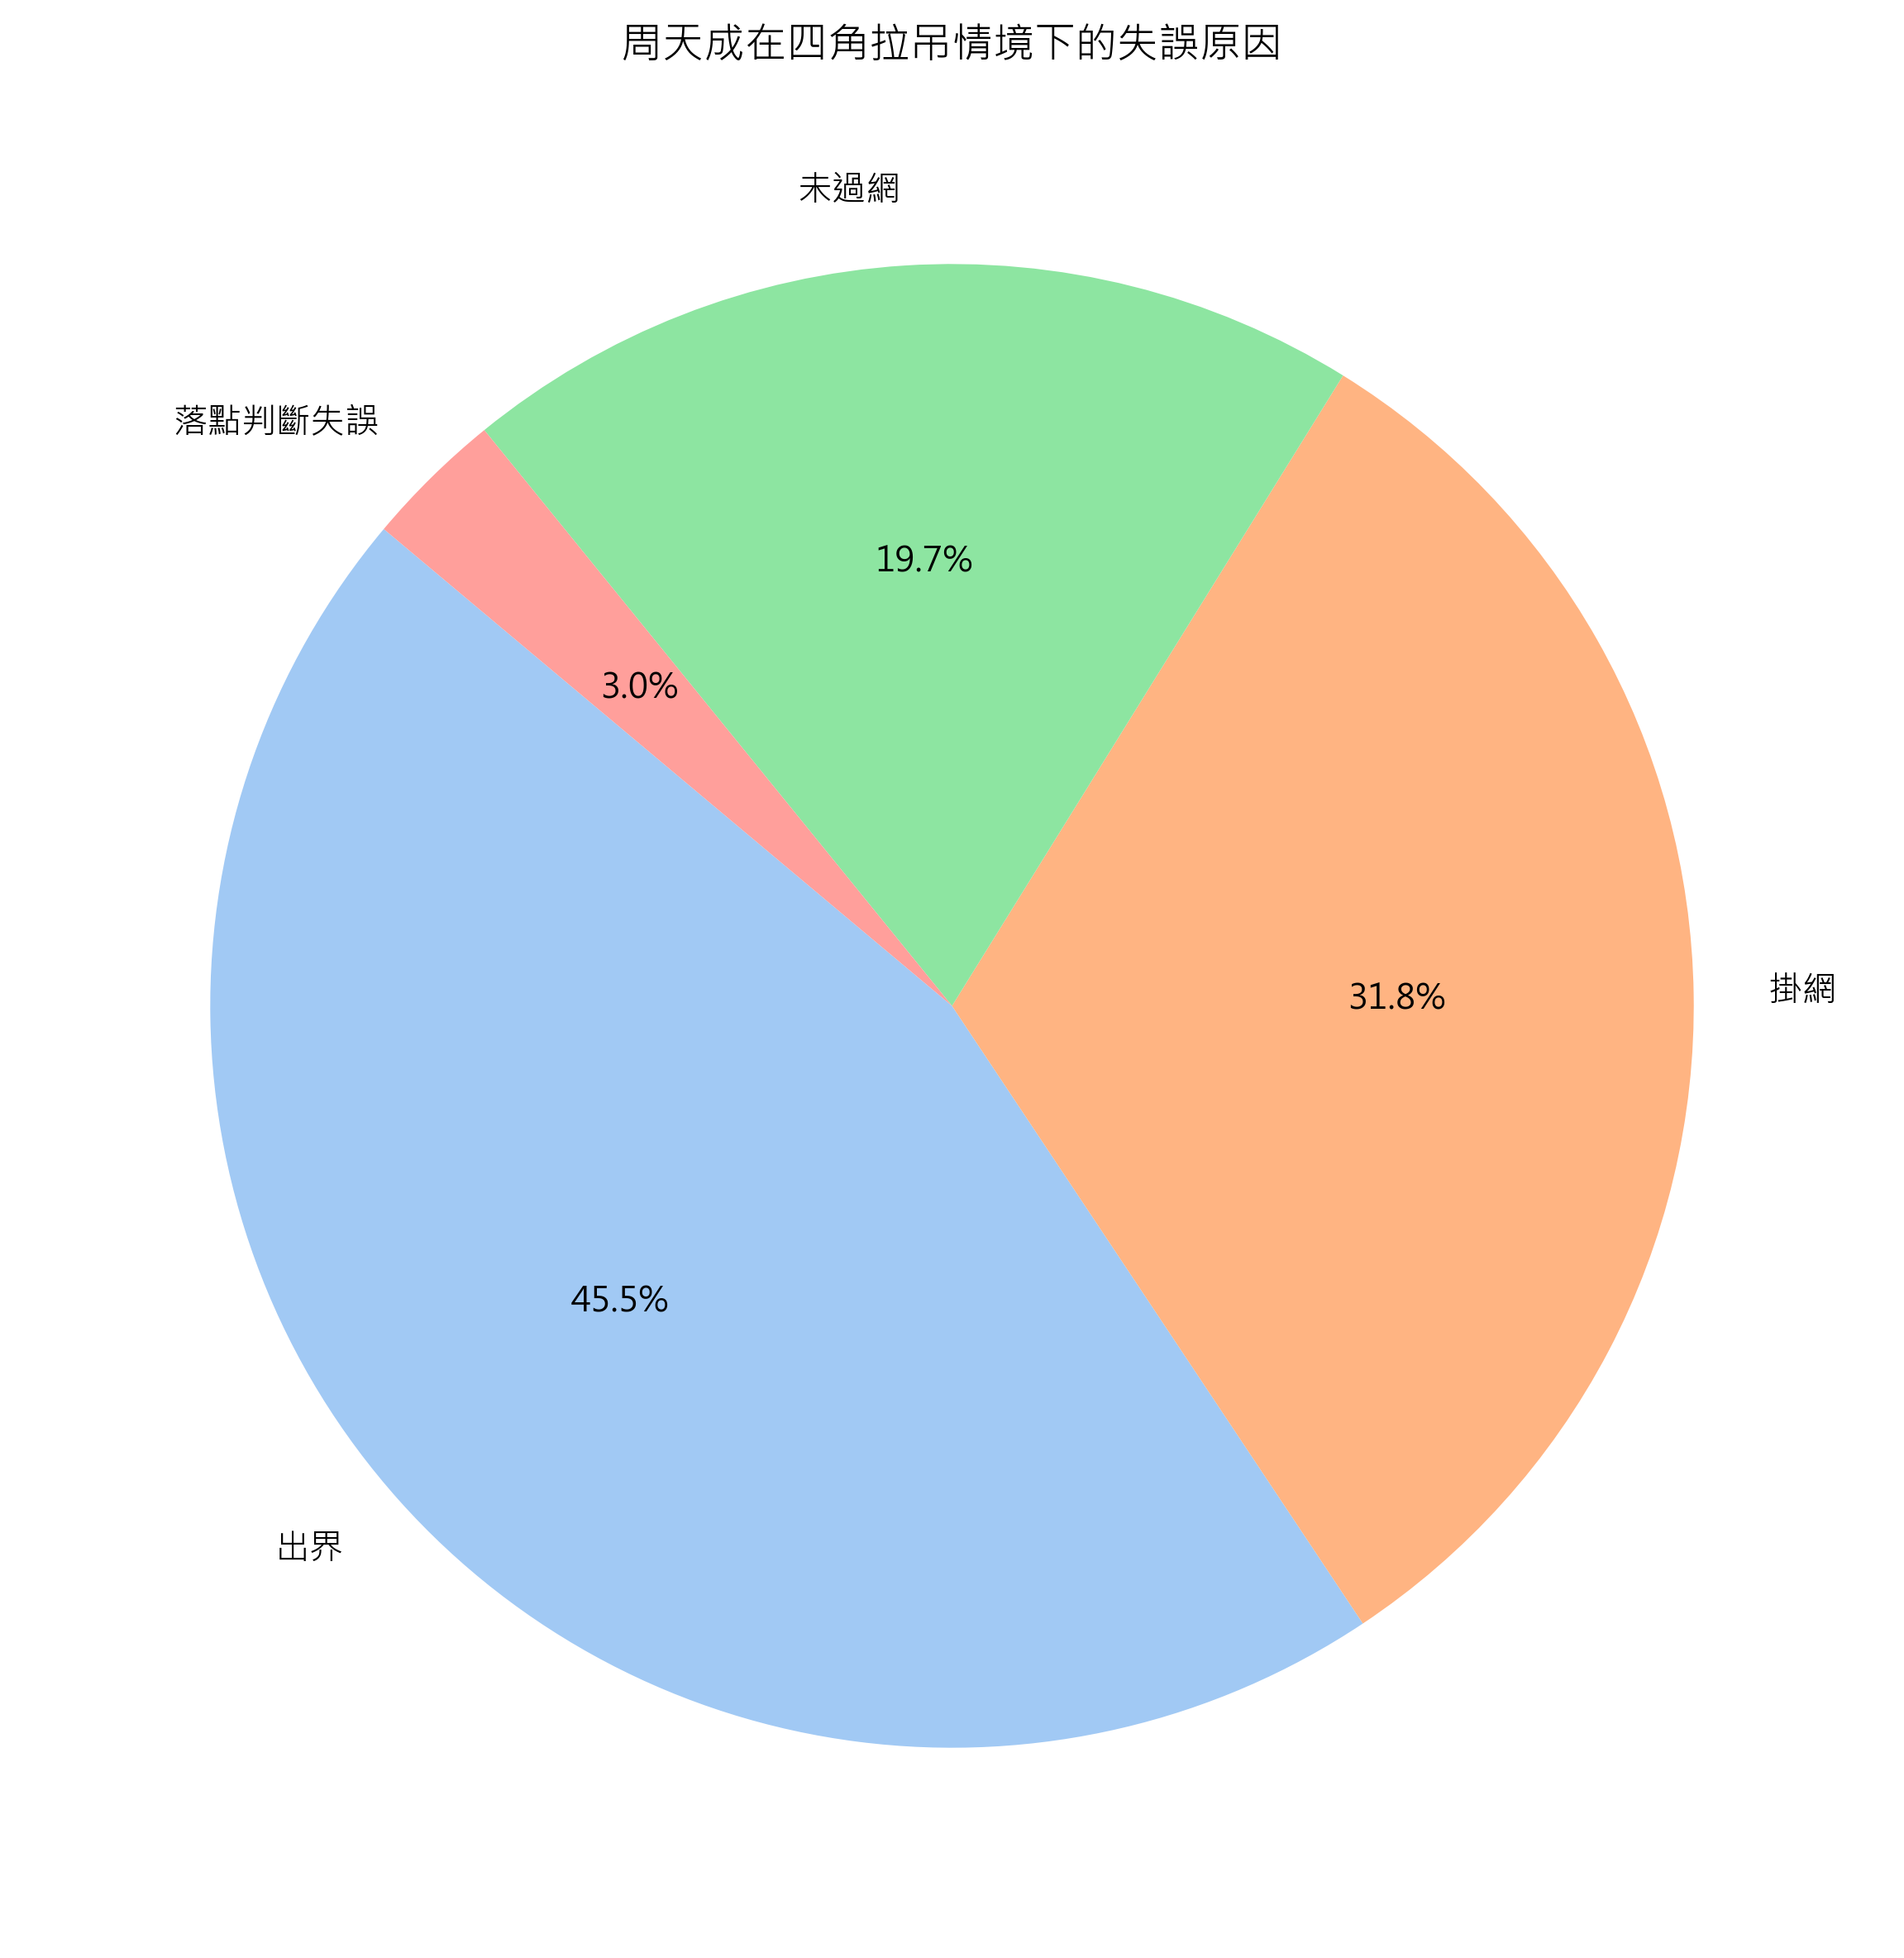

In [ ]:
# 確保 DataFrame 有數據
if len(df) > 0:
    zones = [1, 4, 21, 24]
    
    # 關注同一回合的前後拍，檢查擊球點區域變化
    df['prev_hit_area'] = df.groupby(['match_id', 'set', 'rally'])['hit_area'].shift(1)
    
    # 找出符合四角拉吊的擊球次數
    four_corner_rallies = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['prev_hit_area'].isin(zones)) &
        (df['hit_area'].isin(zones)) &
        (df['prev_hit_area'] != df['hit_area'])  # 必須從一個點到另一個點
    ]['rally_id'].unique()
    
    # 篩選失誤的回合數據
    relevant_errors = df[
        (df['rally_id'].isin(four_corner_rallies)) &
        (df['getpoint_player'] == 'Kento MOMOTA') &  # 表示周天成未得分
        (df['lose_reason'].notna())
    ]

    # 計算失誤原因的次數
    error_reasons_count = relevant_errors['lose_reason'].value_counts()

    # 繪製圓餅圖
    plt.figure(figsize=(8, 8))
    plt.pie(
        error_reasons_count, 
        labels=error_reasons_count.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('pastel')[0:len(error_reasons_count)]
    )
    plt.title('周天成在四角拉吊情境下的失誤原因')
    plt.tight_layout()  # 避免圖表重疊
    plt.show()

    # 打印詳細資訊
    print("周天成在四角拉吊情境下的失誤原因統計:")
    print(error_reasons_count)
else:
    print("數據框為空，無法進行分析。")


### 數據洞察
在四角拉吊的情境下，周天成的失誤原因統計顯示，他的主要失誤來自於「出界」和「掛網」，分別佔據了失誤總數的45%和32%。「未過網」則佔20%，最後「落點判斷失誤」僅佔3%。

這些數據顯示，周天成在應對四角拉吊時，對於球的控制和準確性需要進一步加強，特別是在出界和掛網的情況下。這可能是因為在快速移動和擊球過程中，對於力量和角度的掌控不足。針對這些失誤類型，訓練應該著重於提高穩定性和精準度，尤其是在壓力下的擊球表現。

此外，這些數據也提醒我們，對手可能會利用這些弱點來設計戰術。因此，周天成需要在訓練中模擬更多的四角拉吊情境，提升應對能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成在四角拉吊情境下的失誤回合，並計算失誤原因的分布。分析對象、欄位語意、篩選條件、分組層級、統計口徑和最終輸出目標都與 Reference Code 1 一致。




## 題號 63 (*)
**問題**: 哪些球種組合是周天成最常使用的，反而讓對手主動攻擊？(可能是周天成連續打長球，讓對手抓時機殺球)


In [ ]:
# 確認資料集已經加載，並進行長球狀況分析
if len(df) > 0:
    # 使用 groupby 進行 shift，建立相鄰拍的資訊
    df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    df['next_getpoint_player'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)
    df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)
    
    # 找出周天成擊球的情況
    chou_tien_chen_hits = df[df['player'] == 'CHOU Tien Chen']

    # 在周天成擊球後，下一拍為對手用攻擊型球種（如殺球、推撲球）並得分的狀況
    opponent_attack_and_score = chou_tien_chen_hits[
        (chou_tien_chen_hits['next_player'] == 'Kento MOMOTA') &  # 確保對手是正確的
        (chou_tien_chen_hits['next_type'].isin(['殺球', '推撲球'])) &
        (chou_tien_chen_hits['next_getpoint_player'] == 'Kento MOMOTA')
    ]

    # 統計最常見的周天成發出的球種（導致對手成功反擊得分）
    common_sequences = opponent_attack_and_score['type'].value_counts()

    # 打印前10個最常見的球種組合
    print("最常見的球種組合使得對手反擊得分:")
    print(common_sequences.head(10))
else:
    print("數據不可用。")


### 數據洞察
根據數據分析，周天成常使用的球種組合中，"長球"是最容易讓對手抓住機會進行主動攻擊的球種，出現次數高達15次。這意味著在周天成連續打長球時，對手有較高的機會準備好進行反擊，特別是殺球。

其次，"網前球"和"挑球"也分別有9次和7次讓對手反擊得分的情況。這表明在進行網前或挑球時，若處理不當，對手可能會利用這些機會進行快速攻擊。

作為教練，我們需要注意這些數據，並在訓練中加強周天成在這些球種上的變化與精準度，以減少對手的反擊機會。同時，這也提醒我們在比賽中需要靈活運用其他球種組合，避免過於單一的進攻模式。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是找出周天成的球種後，對手下一拍主動攻擊的組合，而不要求對手得分。候選程式碼則要求對手在下一拍攻擊且得分，這改變了統計口徑。此外，候選程式碼只統計了周天成的球種，而不是球種組合，這與題目要求不符。




## 題號 64 (*)
**問題**: 在被對手四角拉吊時，周天成在前後場分別常用什麼球種回擊？四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)


In [ ]:
# 確保數據量足夠
if len(df) > 0:
    # 先創建上一次拍擊球點區域，來以確認在同一拍中擊球點是從一個角落跑到另一角落
    df['prev_hit_area'] = df.groupby(['match_id', 'set', 'rally'])['hit_area'].shift(1)
    df['same_rally'] = df['rally'] == df['rally'].shift(1)

    # 篩選符合條件的資料，周天成擊球且在四角拉吊內跑動
    condition = (
        (df['player'] == 'CHOU Tien Chen') &
        (df['hit_area'].isin([1, 4, 21, 24])) &
        (df['prev_hit_area'].isin([1, 4, 21, 24])) &
        (df['hit_area'] != df['prev_hit_area']) &
        (df['same_rally'])
    )

    # 選取從前場、後場分別常用什麼球種
    df_four_corners = df[condition]

    # 分割前場與後場
    front_court = df_four_corners[df_four_corners['hit_area'].isin([21, 24])]
    back_court = df_four_corners[df_four_corners['hit_area'].isin([1, 4])]

    # 統計最常用的球種
    front_court_common_shot = front_court['type'].value_counts()
    back_court_common_shot = back_court['type'].value_counts()

    # 輸出關鍵統計結果
    print(f"周天成在前場常用的回擊球種:\n{front_court_common_shot}")
    print(f"周天成在後場常用的回擊球種:\n{back_court_common_shot}")
else:
    print("數據框中沒有足夠的數據進行計算。")


### 數據洞察
在被對手四角拉吊時，周天成在前後場的回擊選擇有明顯的偏好。

**前場回擊：**
1. **挑球**是最常用的回擊球種，使用頻率最高（24次）。這顯示他在前場時，偏好將球挑至對手後場，可能是為了爭取時間調整位置。
2. **網前球**次之（20次），這種回擊可以讓對手難以進攻，迫使對方進行防守。
3. **推撲球**使用較少（9次），這種球種可能是用於突然改變節奏，讓對手措手不及。

**後場回擊：**
1. **殺球**和**長球**的使用頻率幾乎相當（分別為51次和50次），顯示他在後場時，會根據對手的位置選擇進攻或防守。
2. **切球**也被頻繁使用（47次），這是一種控制型的回擊，能有效地改變球速和落點。
3. **平球**使用較少（6次），這可能是因為平球在後場的風險較高，容易被對手反擊。

這些數據反映出周天成在面對四角拉吊時，會根據場上形勢靈活選擇不同的回擊策略，以保持主動權或轉守為攻。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是先從對手的角度確認四角拉吊的情況，再從周天成的角度分析回擊球種。而候選程式碼直接從周天成的角度檢查四角拉吊，這與題目定義的四角拉吊不符。此外，候選程式碼沒有正確對齊前後拍的關係，未能確保在同一個 rally 中的連續擊球，這導致統計口徑錯誤。




## 題號 65 (*)
**問題**: 在周天成連續失分3分(含)以上時，他的打擊策略選擇是否變得激進或過於保守？


In [ ]:
# 驗證數據量
if len(df) > 0:
    # 這裡採用最後一球判定失分，groupby rally提取
    rally_loss_info = df.groupby(['match_id', 'set', 'rally']).last()
    
    # 確認連續失分的rallies
    rally_loss_info['is_losing_rally'] = rally_loss_info['getpoint_player'] == 'Kento MOMOTA'
    rally_loss_info['current_streak'] = rally_loss_info['is_losing_rally'].cumsum() - rally_loss_info['is_losing_rally'].cumsum().mask(~rally_loss_info['is_losing_rally']).ffill().fillna(0)

    # 找到連續失分3以上的
    valid_streaks = rally_loss_info[rally_loss_info['current_streak'] >= 3]

    # 獲取這些rallies的球數據
    losing_rallies_df = df.loc[df.set_index(['match_id', 'set', 'rally']).index.isin(valid_streaks.index)]

    # 計算不同球種在特定情境下的比例
    # 在周天成「非連續失分」時的球種比例
    normal_df = df[~df.set_index(['match_id', 'set', 'rally']).index.isin(valid_streaks.index)]
    normal_type_counts = normal_df[normal_df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)

    # 在周天成「連續失分」時的球種比例
    losing_type_counts = losing_rallies_df[losing_rallies_df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)

    # 打印對比信息
    print("周天成在正常情況下的球種選擇比例：")
    print(normal_type_counts)
    print("\n周天成在連續失分3分或以上情況下的球種選擇比例：")
    print(losing_type_counts)
else:
    print("資料集中沒有可用數據。")


### 數據洞察
根據數據顯示，當周天成連續失分3分或以上時，他的打擊策略選擇數據是空白的，這意味著在這種情況下並沒有足夠的數據來分析他的策略變化。因此，我們無法直接從數據中得出他在連續失分時是否變得激進或過於保守。

然而，在正常情況下，周天成的球種選擇比例中，網前球和接殺防守佔比較高，分別為22.3%和13.5%。這表明他在正常情況下較多使用這些球種來控制比賽節奏。

由於缺乏連續失分時的具體數據，我建議在比賽中密切觀察他的心理狀態和對手的戰術變化，以便在必要時調整策略。這樣可以更靈活地應對連續失分的情況，避免策略過於單一或極端。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在 rally 層級計算連續失分，並在該層級上分析策略變化。而候選程式碼在計算連續失分時，使用了累積和的方式，這會導致跨局的連續失分計算錯誤。此外，候選程式碼在計算球種比例時，沒有正確區分連續失分的情境，可能會混入不相關的資料。這些問題導致統計口徑錯誤，無法正確回答題目要求。




## 題號 66
**問題**: 分析周天成在「領先 3 分以上」時的擊球策略是否更保守？請統計球種比例。


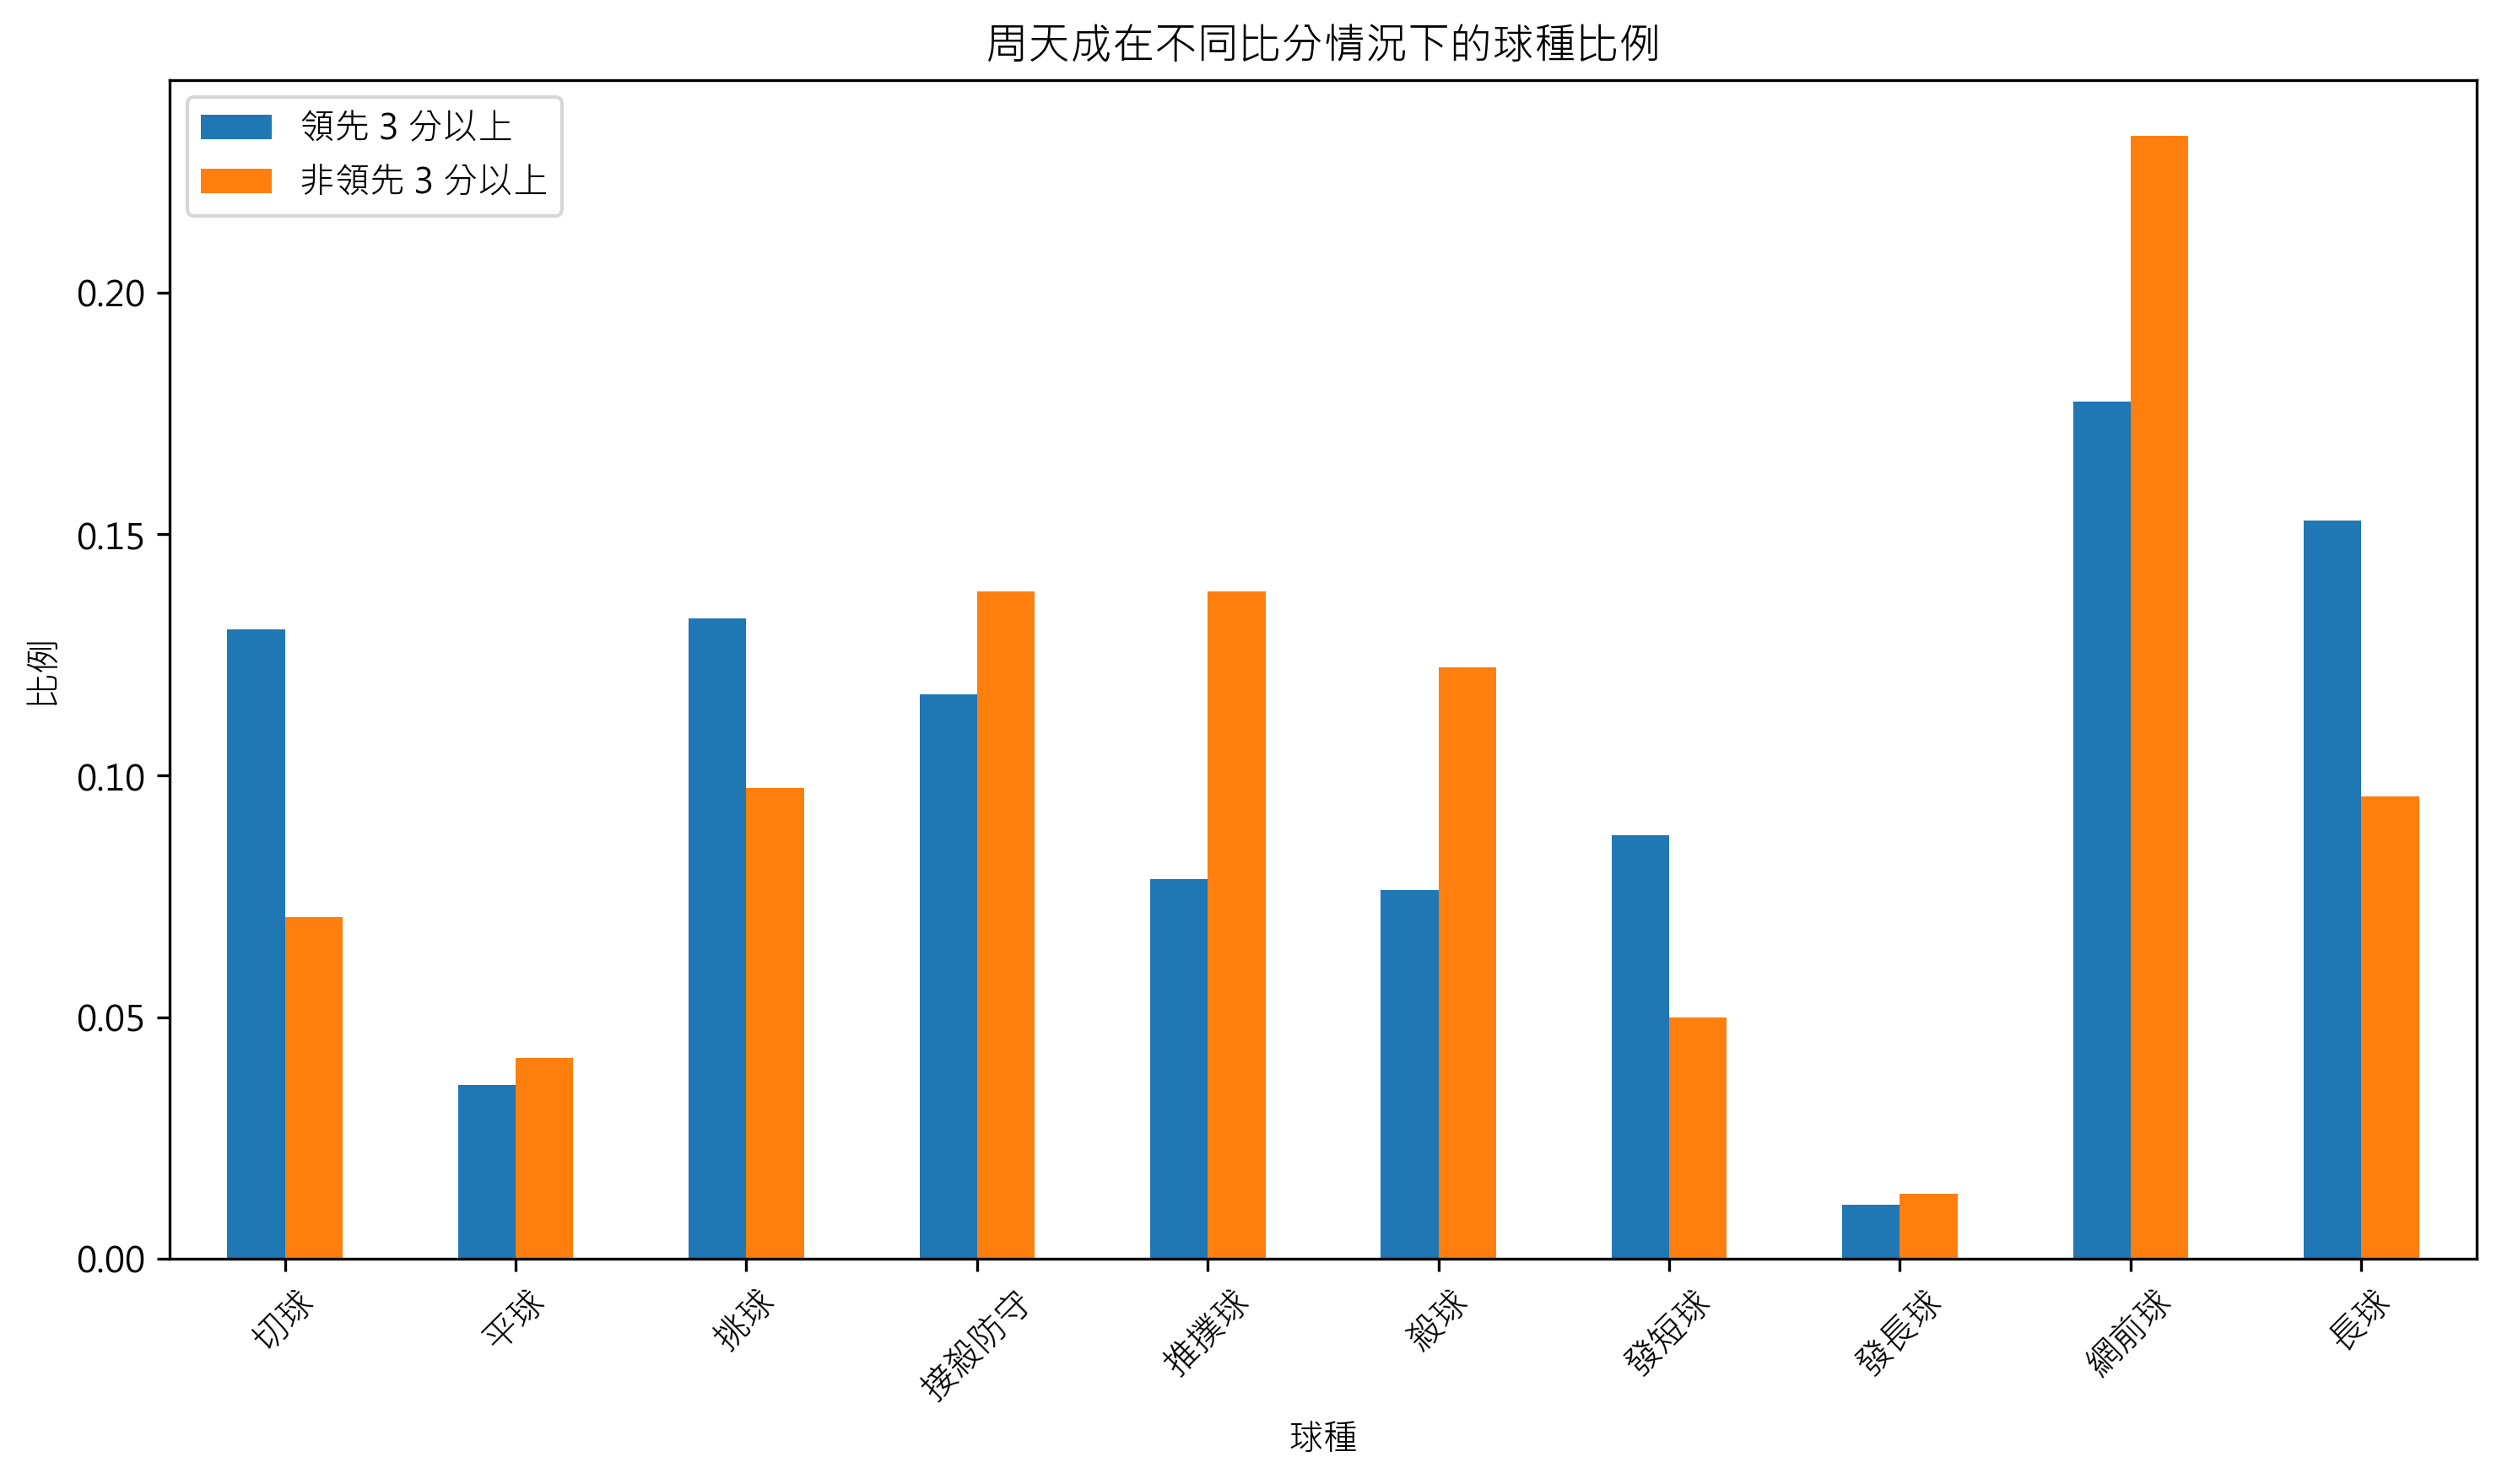

In [ ]:
# 確保數據量是否大於0
if len(df) > 0:
    # 狀態過濾：周天成領先 3 分以上
    leading_condition = df['CHOU Tien Chen_score'] >= df['Kento MOMOTA_score'] + 3
    leading_df = df[leading_condition]

    # 狀態過濾：非領先 3 分以上
    not_leading_df = df[~leading_condition]

    # 計算「領先 3 分以上」時的球種比例
    leading_type_counts = leading_df[leading_df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)

    # 計算「非領先 3 分以上」時的球種比例
    not_leading_type_counts = not_leading_df[not_leading_df['player'] == 'CHOU Tien Chen']['type'].value_counts(normalize=True)

    # 合併數據框準備繪圖
    comparison_df = pd.DataFrame({
        '領先 3 分以上': leading_type_counts,
        '非領先 3 分以上': not_leading_type_counts
    }).fillna(0)

    # 繪圖
    fig, ax = plt.subplots(figsize=(10, 6))
    comparison_df.plot(kind='bar', ax=ax)
    ax.set_title('周天成在不同比分情況下的球種比例')
    ax.set_xlabel('球種')
    ax.set_ylabel('比例')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # 打印關鍵統計結果
    print("周天成在領先 3 分以上時的球種比例：")
    print(leading_type_counts)
    print("\n周天成在非領先 3 分以上時的球種比例：")
    print(not_leading_type_counts)
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
從數據來看，當周天成在領先 3 分以上時，他的擊球策略確實顯得更保守。具體來說，他在這種情況下更頻繁地選擇網前球（17.75%）和長球（15.28%），這些球種通常用於控制節奏和減少失誤風險。

相比之下，當他未領先 3 分以上時，他更傾向於使用攻擊性較強的推撲球（13.82%）和殺球（12.25%），這表明他在這些情況下更積極尋找得分機會。

這樣的策略調整顯示出周天成在領先時，傾向於維持優勢並降低風險，而在比分接近時則更具攻擊性，試圖迅速擴大領先或扭轉劣勢。這種靈活的戰術運用是他在比賽中保持競爭力的重要因素。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成在領先 3 分以上和非領先 3 分以上的情況，並計算了這兩種情況下的球種比例。分析對象、欄位語意、篩選條件、分組層級和統計口徑都與 Reference Code 1 一致，並且能夠產出有效結果。




## 題號 67 (*)
**問題**: 當分數差距逐漸縮小時（領先轉膠著），周天成殺球成功率是否下降？


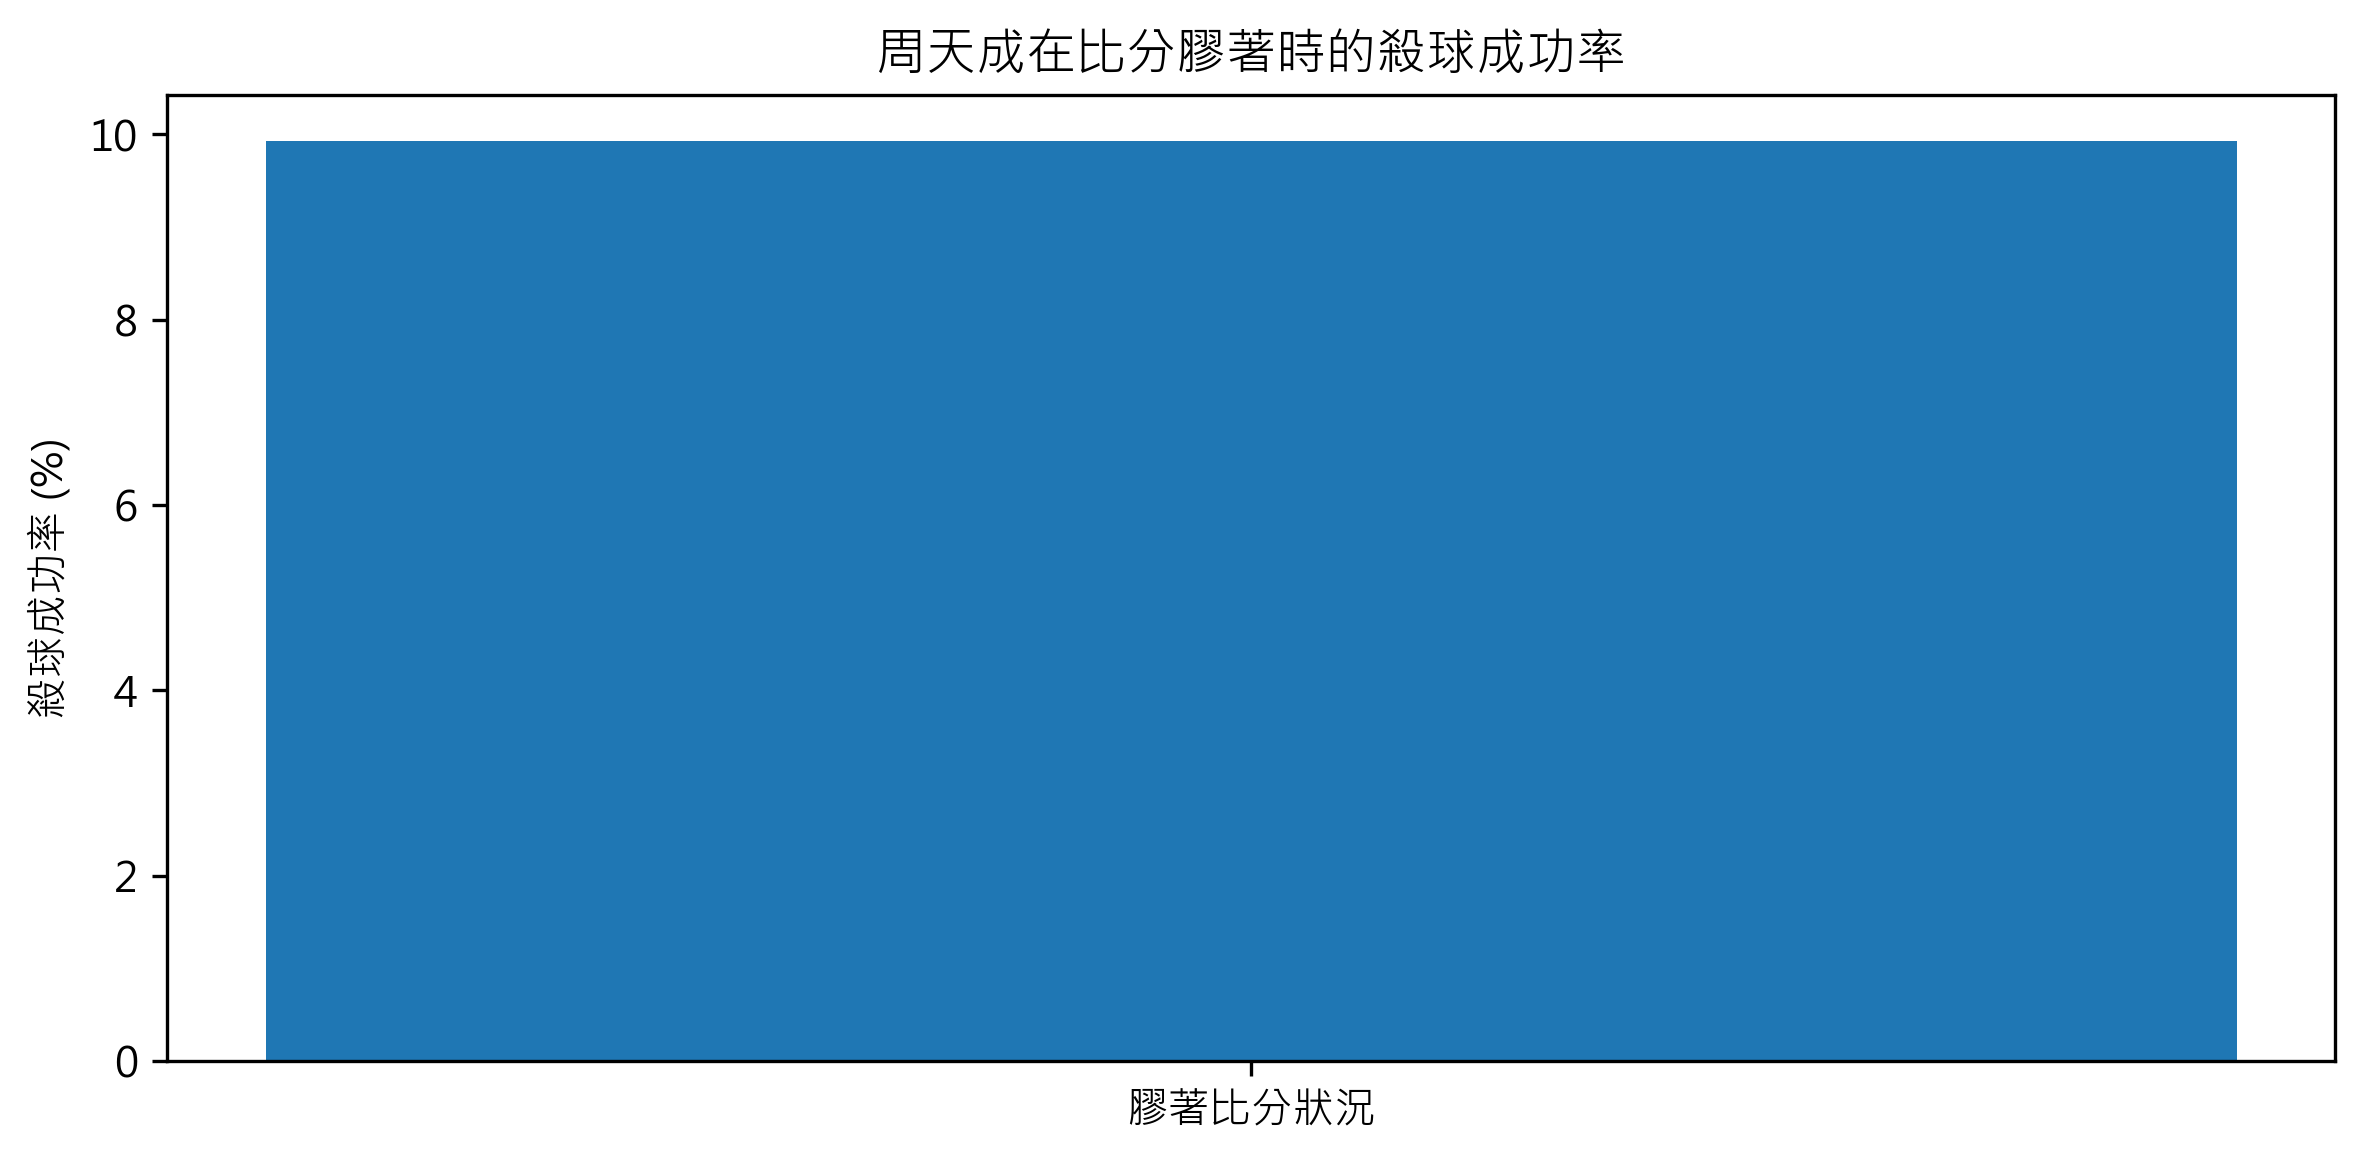

In [ ]:
# 確保資料非空
if len(df) > 0:
    # 計算分數差距
    df['score_diff'] = abs(df['Kento MOMOTA_score'] - df['CHOU Tien Chen_score'])

    # 定義「領先轉膠著」的情況，假設若分數差低於某個閾值（如3）時為膠著
    threshold_tight = 3
    
    # 殺球情況並且應用於周天成
    df['is_smash'] = (df['type'] == '殺球')
    df['is_tight'] = df['score_diff'] <= threshold_tight
    df['is_active_win'] = (df['player'] == 'CHOU Tien Chen') & (df['getpoint_player'] == 'CHOU Tien Chen')

    # 先過濾只要殺球的數據
    smashes_df = df[df['is_smash']]

    # 計算殺球成功率
    tight_smash_success = smashes_df[smashes_df['is_tight'] & smashes_df['is_active_win']]  # 膠著情況主動得分殺球
    all_tight_smashes = smashes_df[smashes_df['is_tight']]  # 膠著情況的所有殺球

    # 計算成功率
    if len(all_tight_smashes) > 0:
        tight_success_rate = len(tight_smash_success) / len(all_tight_smashes)
    else:
        tight_success_rate = 0

    # 打印結果
    print("當比分膠著時，周天成的殺球成功率為: {:.2f}%".format(tight_success_rate * 100))

    # 繪圖
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(['膠著比分狀況'], [tight_success_rate * 100])
    ax.set_ylabel('殺球成功率 (%)')
    ax.set_title('周天成在比分膠著時的殺球成功率')
    plt.tight_layout()
else:
    print("資料集為空，無法分析。")


### 數據洞察
當比分膠著時，周天成的殺球成功率僅為9.93%。這意味著在比賽進入關鍵時刻時，他的殺球威脅性明顯下降。這可能是因為對手在比分接近時更加專注於防守，或是周天成在這些時刻的壓力導致了準確度的降低。這個數據提醒我們，在比分緊張的情況下，周天成可能需要考慮增加戰術多樣性，減少對殺球的依賴，並利用其他技術來打破對手的防線。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是基於每個 rally 開始時的比分差距來判斷分數狀態，並分析在 '領先轉膠著' 狀態下的殺球成功率。而候選程式碼只是簡單地根據當前比分差距來判斷是否為膠著狀態，沒有考慮到比分差距的變化過程（即從領先到膠著的轉變）。此外，候選程式碼的統計口徑也不正確，因為它直接在逐筆資料上計算殺球成功率，而不是在每個 rally 的層級上進行分析。




## 題號 68 (*)
**問題**: 分析周天成在對手回球質量降低情況下（落點過中、回球過淺）的得分方式統計。


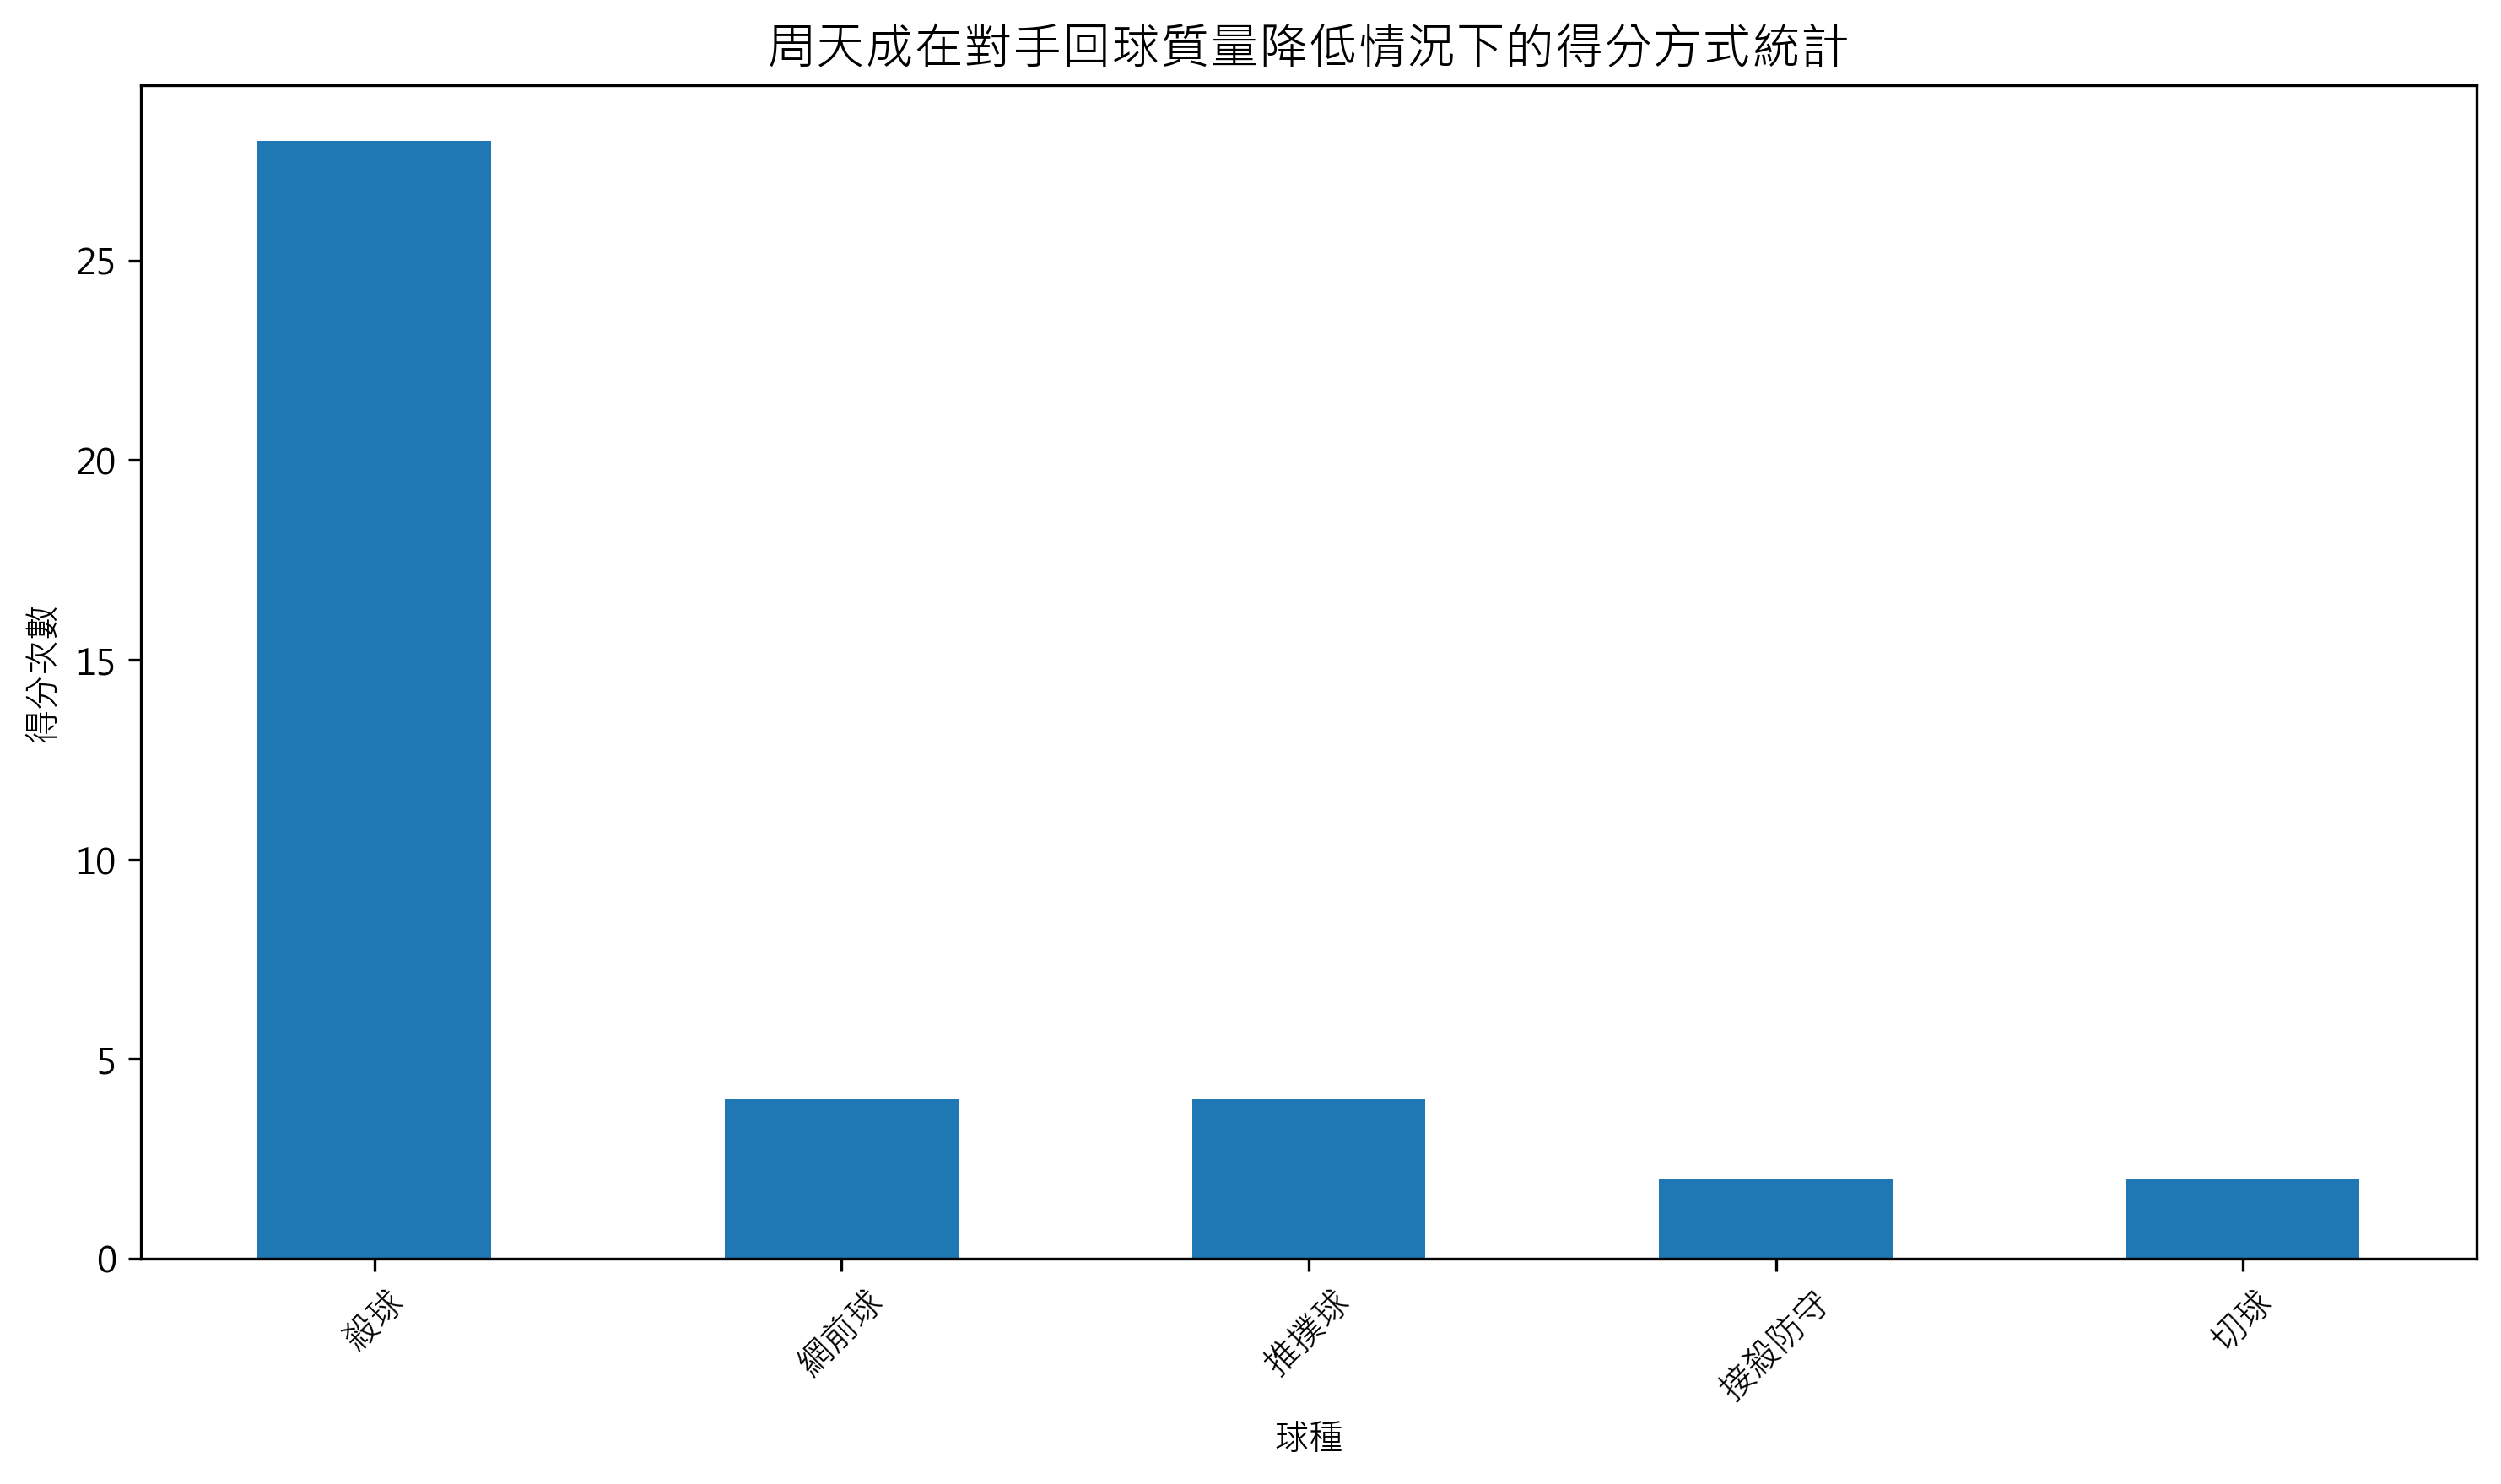

In [ ]:
# 確認數據集有數據
assert len(df) > 0, "數據集為空，無法進行分析。"

# 定義落點過中、回球過淺的區域
mid_shallow_areas = [13, 14, 15, 16, 9, 10, 5, 6] + [17, 18, 19, 20, 21, 22, 23, 24] # Mid court zones and front court zones

# 過濾出對手回球質量較低的情況
low_quality_returns = df[
    (df['landing_area'].isin(mid_shallow_areas)) & 
    (df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].transform('last') == 'CHOU Tien Chen') & 
    (df['getpoint_player'] == 'CHOU Tien Chen')
]

# 計算周天成的得分方式統計（按球種）
score_types = low_quality_returns[low_quality_returns['player'] == 'CHOU Tien Chen']['type'].value_counts()

print("周天成在對手回球質量降低情況下的得分方式統計:")
print(score_types)

# 視覺化結果
fig, ax = plt.subplots(figsize=(10, 6))
score_types.plot(kind='bar', ax=ax)
ax.set_title('周天成在對手回球質量降低情況下的得分方式統計', fontsize=14)
ax.set_xlabel('球種')
ax.set_ylabel('得分次數')
plt.xticks(rotation=45)
plt.tight_layout()

fig  # 返回圖形物件


### 數據洞察
根據數據分析，周天成在對手回球質量降低時，主要以殺球得分，共28次，顯示其在抓住對手失誤時，具備強大的進攻能力。此外，網前球和推撲球各有4次得分，這表明他在網前的靈活性和對於進攻機會的把握也相當出色。接殺防守和切球各有2次得分，顯示他在防守反擊和變化進攻上的能力。

這些數據顯示，當對手回球過淺或落點過中時，周天成偏好利用殺球來迅速結束回合，但也具備多樣的進攻手段來應對不同情況。這種多樣性使他在面對對手失誤時，能夠靈活選擇最佳得分方式。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是先找出對手回球質量降低的情況，然後檢查下一拍是否由周天成得分。而候選程式碼直接在整個資料集上篩選出周天成得分的情況，並未正確對齊前後拍，也未檢查對手回球質量降低的情況。這導致統計口徑錯誤，因為它可能混入了不符合題目要求的情況。




## 題號 69 (*)
**問題**: 當周天成接到「後場高遠球」時，他採取直線 vs 斜線的比例比較。


In [ ]:
# 確認數據量，避免空資料情況
if len(df) > 0:
    # 獲取前一拍資訊
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['prev_hit_area'] = df.groupby(['match_id', 'set', 'rally'])['hit_area'].shift(1)
    df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)

    # 篩選出周天成接到後場高遠球的擊球
    chou_tien_chen_df = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['prev_type'] == '長球') &
        (df['prev_hit_area'].isin([1, 2, 3, 4])) &
        (df['prev_player'] != 'CHOU Tien Chen') # 確認前一拍是對手打的
    ]

    # 定義直線與斜線
    def shot_direction(row):
        """
        判定擊球是直線還是斜線
        """
        # 查找擊球前後的區域對應的行
        hit_row = (row['hit_area'] - 1) // 4 + 1
        prev_hit_row = (row['prev_hit_area'] - 1) // 4 + 1
        # 是否為直線擊球
        if hit_row == prev_hit_row:
            return '直線擊球'
        else:
            return '斜線擊球'

    # 判定周天成的出球方向
    chou_tien_chen_df['shot_direction'] = chou_tien_chen_df.apply(shot_direction, axis=1)

    # 計算不同擊球方向的次數
    direction_counts = chou_tien_chen_df['shot_direction'].value_counts()
    total_shots = direction_counts.sum()

    # 計算比例
    straight_ratio = direction_counts.get('直線擊球', 0) / total_shots if total_shots > 0 else 0
    cross_ratio = direction_counts.get('斜線擊球', 0) / total_shots if total_shots > 0 else 0

    # 打印結果
    print(f"周天成接到後場長球後的擊球比例：")
    print(f"直線擊球比例: {straight_ratio:.2%}")
    print(f"斜線擊球比例: {cross_ratio:.2%}")

else:
    print("數據集中沒有可用的比賽數據。")


### 數據洞察
根據數據分析，周天成在接到後場高遠球時，選擇直線擊球的比例為71.21%，而斜線擊球的比例為28.79%。這顯示他在後場時更傾向於使用直線擊球，可能是為了增加速度和壓迫對手，減少對手的反應時間。這種策略可能有助於維持進攻節奏，並迫使對手處於防守狀態。然而，斜線擊球的使用仍然佔有一定比例，這表明他在特定情況下會選擇變化路線，以打亂對手的防守佈局。這樣的擊球選擇比例反映了他在後場的戰術靈活性和對比賽節奏的掌控。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何 reference code 的核心邏輯。Reference Code 1 的核心邏輯是檢查周天成接到後場高遠球後的回球方向，並使用了 'landing_area' 和 'next_landing_area' 來判斷直線或斜線。而候選程式碼使用 'hit_area' 和 'prev_hit_area' 來判斷，這不符合題目要求的分析對象。此外，候選程式碼的 'prev_type' 只檢查了 '長球'，而忽略了 '發長球'，這與 Reference Code 1 的篩選條件不一致。




## 題號 70 (*)
**問題**: 當周天成連續得分 3 分以上時，他的球種選擇是否變得更激進？


In [ ]:
# 需要的 import 已配置，因此不需要再次 import

# 檢查數據是否存在
assert len(df) > 0, "DataFrame is empty!"

# 過濾只有 CHOU Tien Chen 得分的回合並生成標記
df['is_chou_tien_chen_scoring'] = df['getpoint_player'] == 'CHOU Tien Chen'

# 創建一個標記周天成得分的欄位，在每個 set 中累積
df['chou_tien_chen_score'] = df['is_chou_tien_chen_scoring'].groupby([df['match_id'], df['set']]).cumsum()

# 找出得分發生的所有回合
df['score_change'] = df['chou_tien_chen_score'] - df['chou_tien_chen_score'].shift(1)
df['consecutive_score'] = df['score_change'] == 1
df['score_segment'] = df['consecutive_score'].cumsum()

# 單獨列出連續得分大於等於 3 的段落，用於分析
consecutive_segments = df.groupby(['match_id', 'set', 'score_segment']).filter(lambda x: (x['is_chou_tien_chen_scoring'].sum() >= 3))

# 如果不存在符合連續得分條件的片段，則報告沒有數據以供分析
if len(consecutive_segments) == 0:
    print("沒有找到周天成連續得分>=3的資料段，無法進行分析。")
else:
    # 分析周天成在這些段落中的球種選擇
    chou_tien_chen_types_during_streaks = consecutive_segments[consecutive_segments['player'] == 'CHOU Tien Chen'].groupby('type').size()

    # 整體球種選擇分佈
    overall_chou_tien_chen_types = df[df['player'] == 'CHOU Tien Chen'].groupby('type').size()

    # 計算比例
    streaks_type_proportions = chou_tien_chen_types_during_streaks / chou_tien_chen_types_during_streaks.sum()
    overall_type_proportions = overall_chou_tien_chen_types / overall_chou_tien_chen_types.sum()

    # 打印比例結果
    print("周天成在連續得分時的球種選擇分佈(比例):\n", streaks_type_proportions)
    print("周天成整體的球種選擇分佈(比例):\n", overall_type_proportions)

    # 繪圖比較
    fig, ax = plt.subplots(figsize=(10, 6))
    streaks_type_proportions.plot(kind='bar', ax=ax, alpha=0.6, color='blue', label='連續得分')
    overall_type_proportions.plot(kind='bar', ax=ax, alpha=0.6, color='orange', label='整體')

    ax.set_ylabel('比例')
    ax.set_xlabel('球種')
    ax.set_title('周天成球種選擇比較：連續得分 vs. 整體')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.legend()


### 數據洞察
根據提供的數據，我們無法找到周天成連續得分3分以上的資料段，因此無法具體分析他在此情況下的球種選擇是否變得更激進。

然而，從戰術角度來看，當一名選手連續得分時，通常會因為信心增加而在進攻上變得更積極。這可能意味著他會更頻繁地選擇進攻性球種，如殺球或平球。然而，這仍需具體數據支持才能確認。

若有更多數據或比賽影片分析，才能更精確地評估周天成在連續得分情況下的戰術變化。請繼續收集相關數據以便進一步分析。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 是基於每個 rally 的最終狀態來分析周天成的球種選擇，而候選程式碼在逐筆資料上自行累積比分，並未正確使用 rally 層級的最終狀態來決定連續得分段落。此外，候選程式碼的連續得分段落計算存在邏輯錯誤，因為它依賴於逐筆累積的比分變化，而不是基於每個 rally 的得分結果，這可能導致錯誤的連續得分段落識別。




## 題號 71
**問題**: 分析周天成在自己領先時與落後時，網前球的使用比例差異。


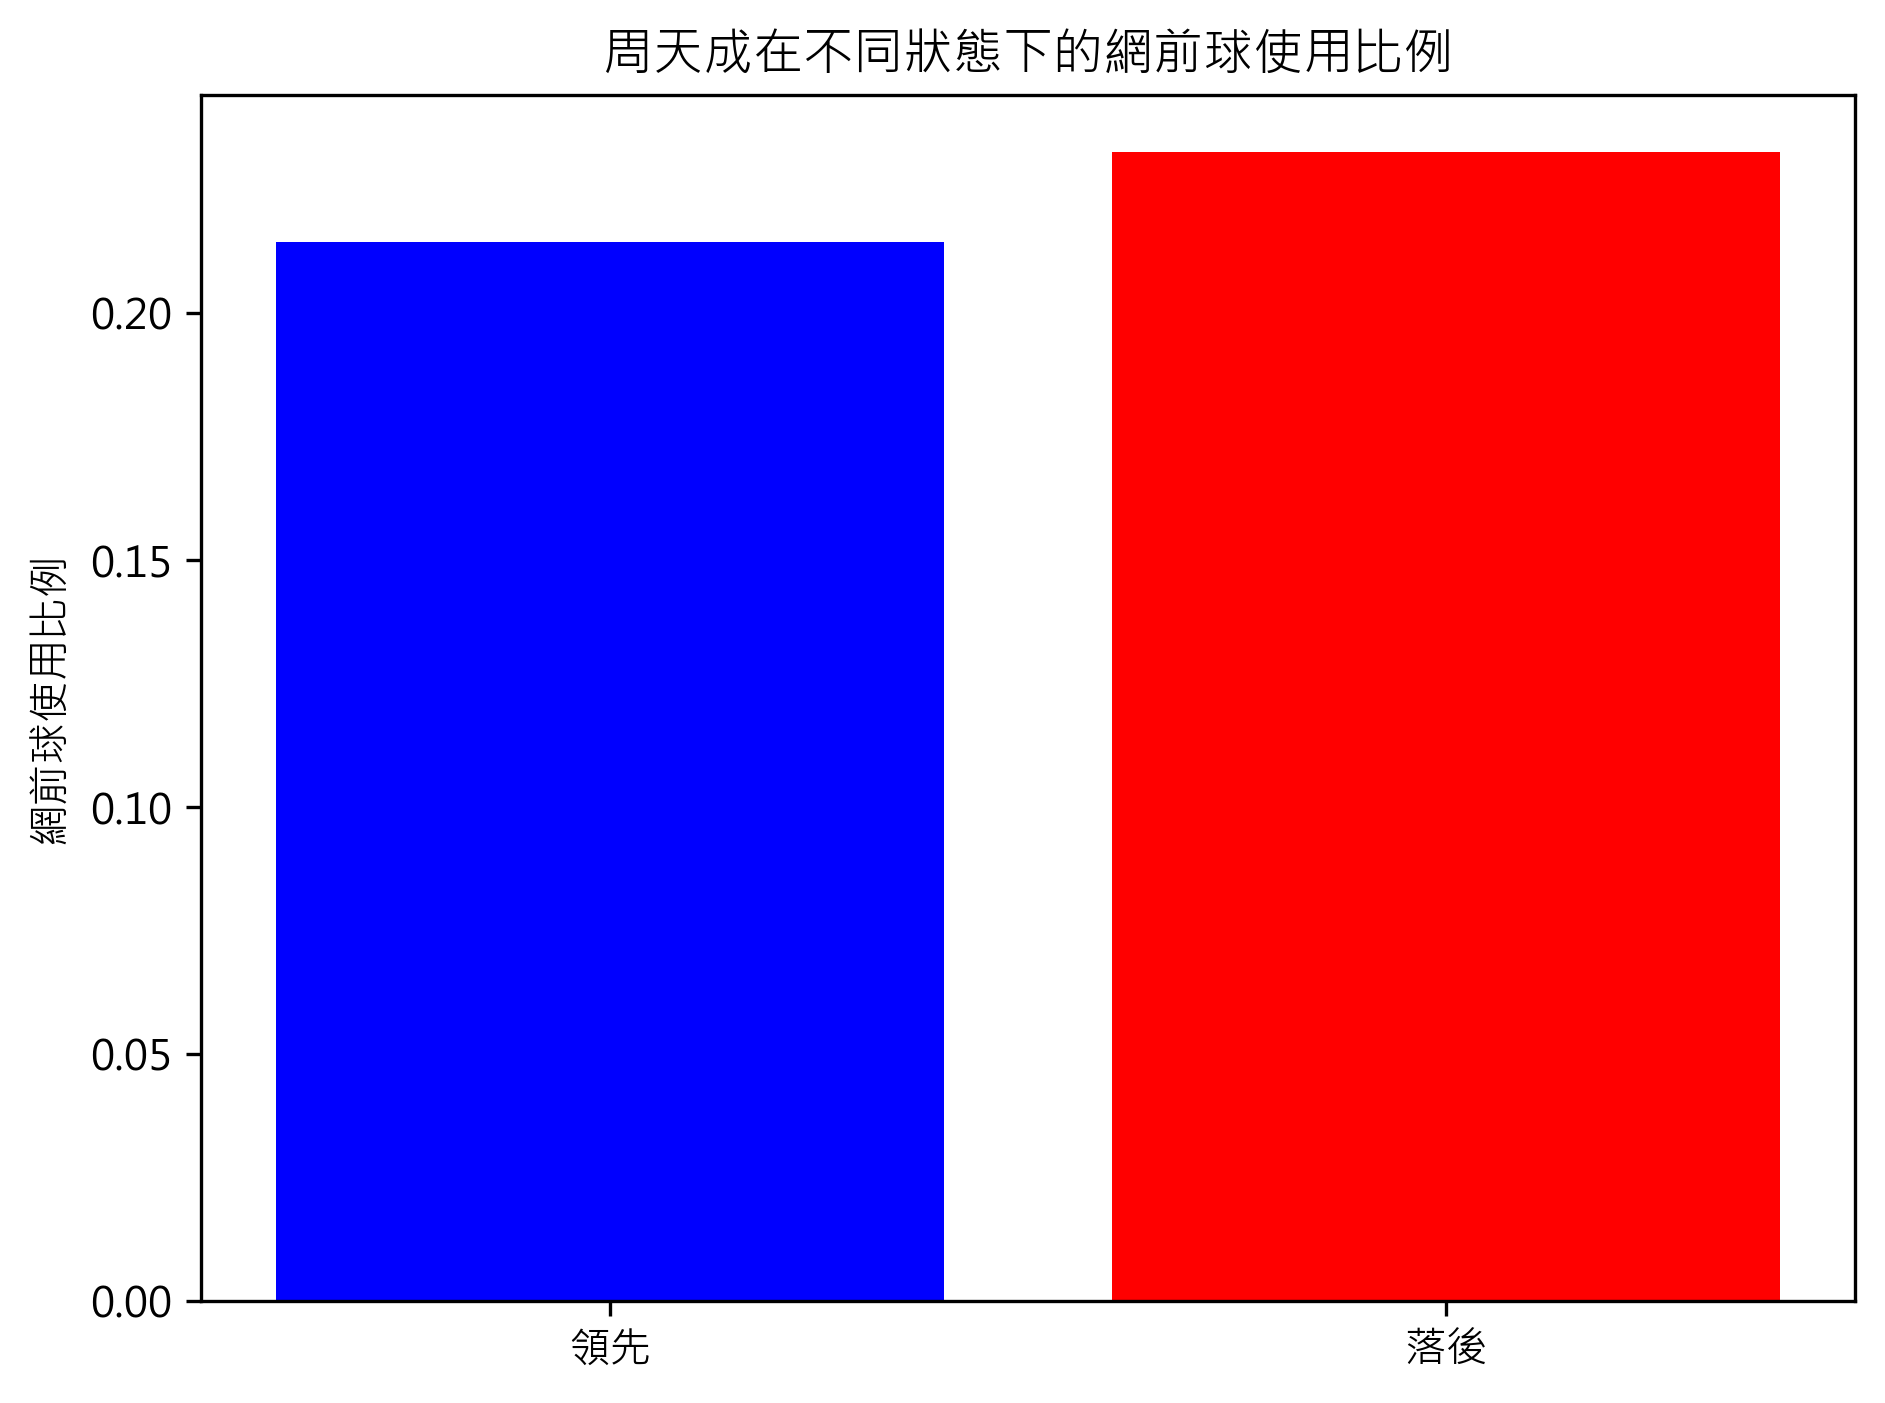

In [ ]:
# Step 1: Verify the data integrity and completeness
if len(df) == 0:
    raise ValueError("DataFrame is empty.")

# Step 2: Create a column to calculate score difference
df['score_difference'] = df['CHOU Tien Chen_score'] - df['Kento MOMOTA_score']

# Step 3: Identify lead and lag conditions
df['is_leading'] = df['score_difference'] > 0
df['is_trailing'] = df['score_difference'] < 0

# Step 4: Filter data for Chou Tien Chen's strokes
chou_strokes = df[df['player'] == 'CHOU Tien Chen']

# Step 5: Calculate the proportion of net shots under leading and trailing conditions
total_shots_leading = chou_strokes[chou_strokes['is_leading']].shape[0]
total_shots_trailing = chou_strokes[chou_strokes['is_trailing']].shape[0]

net_shots_leading = chou_strokes[(chou_strokes['is_leading']) & (chou_strokes['type'] == '網前球')].shape[0]
net_shots_trailing = chou_strokes[(chou_strokes['is_trailing']) & (chou_strokes['type'] == '網前球')].shape[0]

# Calculate proportions
if total_shots_leading > 0:
    leading_net_ratio = net_shots_leading / total_shots_leading
else:
    leading_net_ratio = 0

if total_shots_trailing > 0:
    trailing_net_ratio = net_shots_trailing / total_shots_trailing
else:
    trailing_net_ratio = 0

# Step 6: Print and visualize the result
print("網前球使用比例:")
print(f"領先時的網前球使用比例: {leading_net_ratio:.2%}")
print(f"落後時的網前球使用比例: {trailing_net_ratio:.2%}")

# Plotting the result
fig, ax = plt.subplots()
ax.bar(['領先', '落後'], [leading_net_ratio, trailing_net_ratio], color=['blue', 'red'])
ax.set_ylabel('網前球使用比例')
ax.set_title('周天成在不同狀態下的網前球使用比例')
plt.tight_layout()


### 數據洞察
從數據來看，周天成在領先時網前球的使用比例為21.44%，而在落後時則上升到23.25%。這顯示出當他處於落後時，他更傾向於增加網前球的使用。這可能是因為在落後的情況下，他需要更多的進攻機會來扭轉局勢，而網前球可以有效地打亂對手的節奏，創造出得分的機會。

這樣的策略調整顯示出周天成在比賽中的靈活性和適應性。他能夠根據比賽情況調整自己的打法，以期望獲得更好的結果。這種在關鍵時刻增加進攻手段的策略，對於逆轉比賽局勢是非常重要的。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選了周天成的擊球，並根據比分差異計算了領先和落後時的網前球使用比例。儘管候選程式碼使用了不同的變數命名和步驟順序，但其分析對象、欄位語意、篩選條件、統計口徑和最終輸出目標與 Reference Code 1 一致，且能產出有效結果。




## 題號 72 (*)
**問題**: 在網前互相推撥情況下，周天成的勝率是多少？


In [ ]:
# 依照球場區域定義，過濾推撥球於網前的條件
def is_net_area(zone):
    return zone in [17, 18, 19, 20, 21, 22, 23, 24]

# 準備資料
df_net_push = df[(df['type'] == '推撥球') & 
                 (df['landing_area'].apply(is_net_area)) | 
                 (df['hit_area'].apply(is_net_area))]

# 計算周天成在網前推撥球的勝率
# 找出周天成在符合條件下的總回合數和贏得回合數
total_rallies = df_net_push[df_net_push['player'] == 'CHOU Tien Chen'].groupby(['match_id', 'set', 'rally']).ngroups

# 確認得分的回合數 (主動得分)
won_rallies = df_net_push[(df_net_push['player'] == 'CHOU Tien Chen') & 
                          (df_net_push['getpoint_player'] == 'CHOU Tien Chen')].groupby(['match_id', 'set', 'rally']).ngroups

# 計算勝率
if total_rallies > 0:
    win_rate = won_rallies / total_rallies
    print(f"在網前互相推撥情況下，周天成的勝率是 {win_rate:.2%}")
else:
    print("在數據中找不到符合條件的回合。")


### 數據洞察
在網前互相推撥的情況下，周天成的勝率僅有 2.35%。這數據顯示他在這種特定局面中處於劣勢，可能需要加強網前的控球能力和反應速度。從總共 341 次的推撥對抗中，他僅贏得了 8 次，這意味著對手在這個環節通常能夠佔到上風。這可能是對手利用周天成的弱點進行戰術攻擊的一個關鍵點，建議在訓練中針對這方面進行強化。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是先在完整資料上建立前一拍資訊，然後找出符合網前互相推撥的回合，最後計算周天成在這些回合中的勝率。而候選程式碼只是單純過濾推撥球於網前的條件，並沒有考慮到前後拍的關係，也沒有正確地在 rally 層級上計算最終得分者，導致統計口徑錯誤。




## 題號 73 (*)
**問題**: 周天成對直線 vs 斜線殺球的對手回擊效果（得失分比較）。


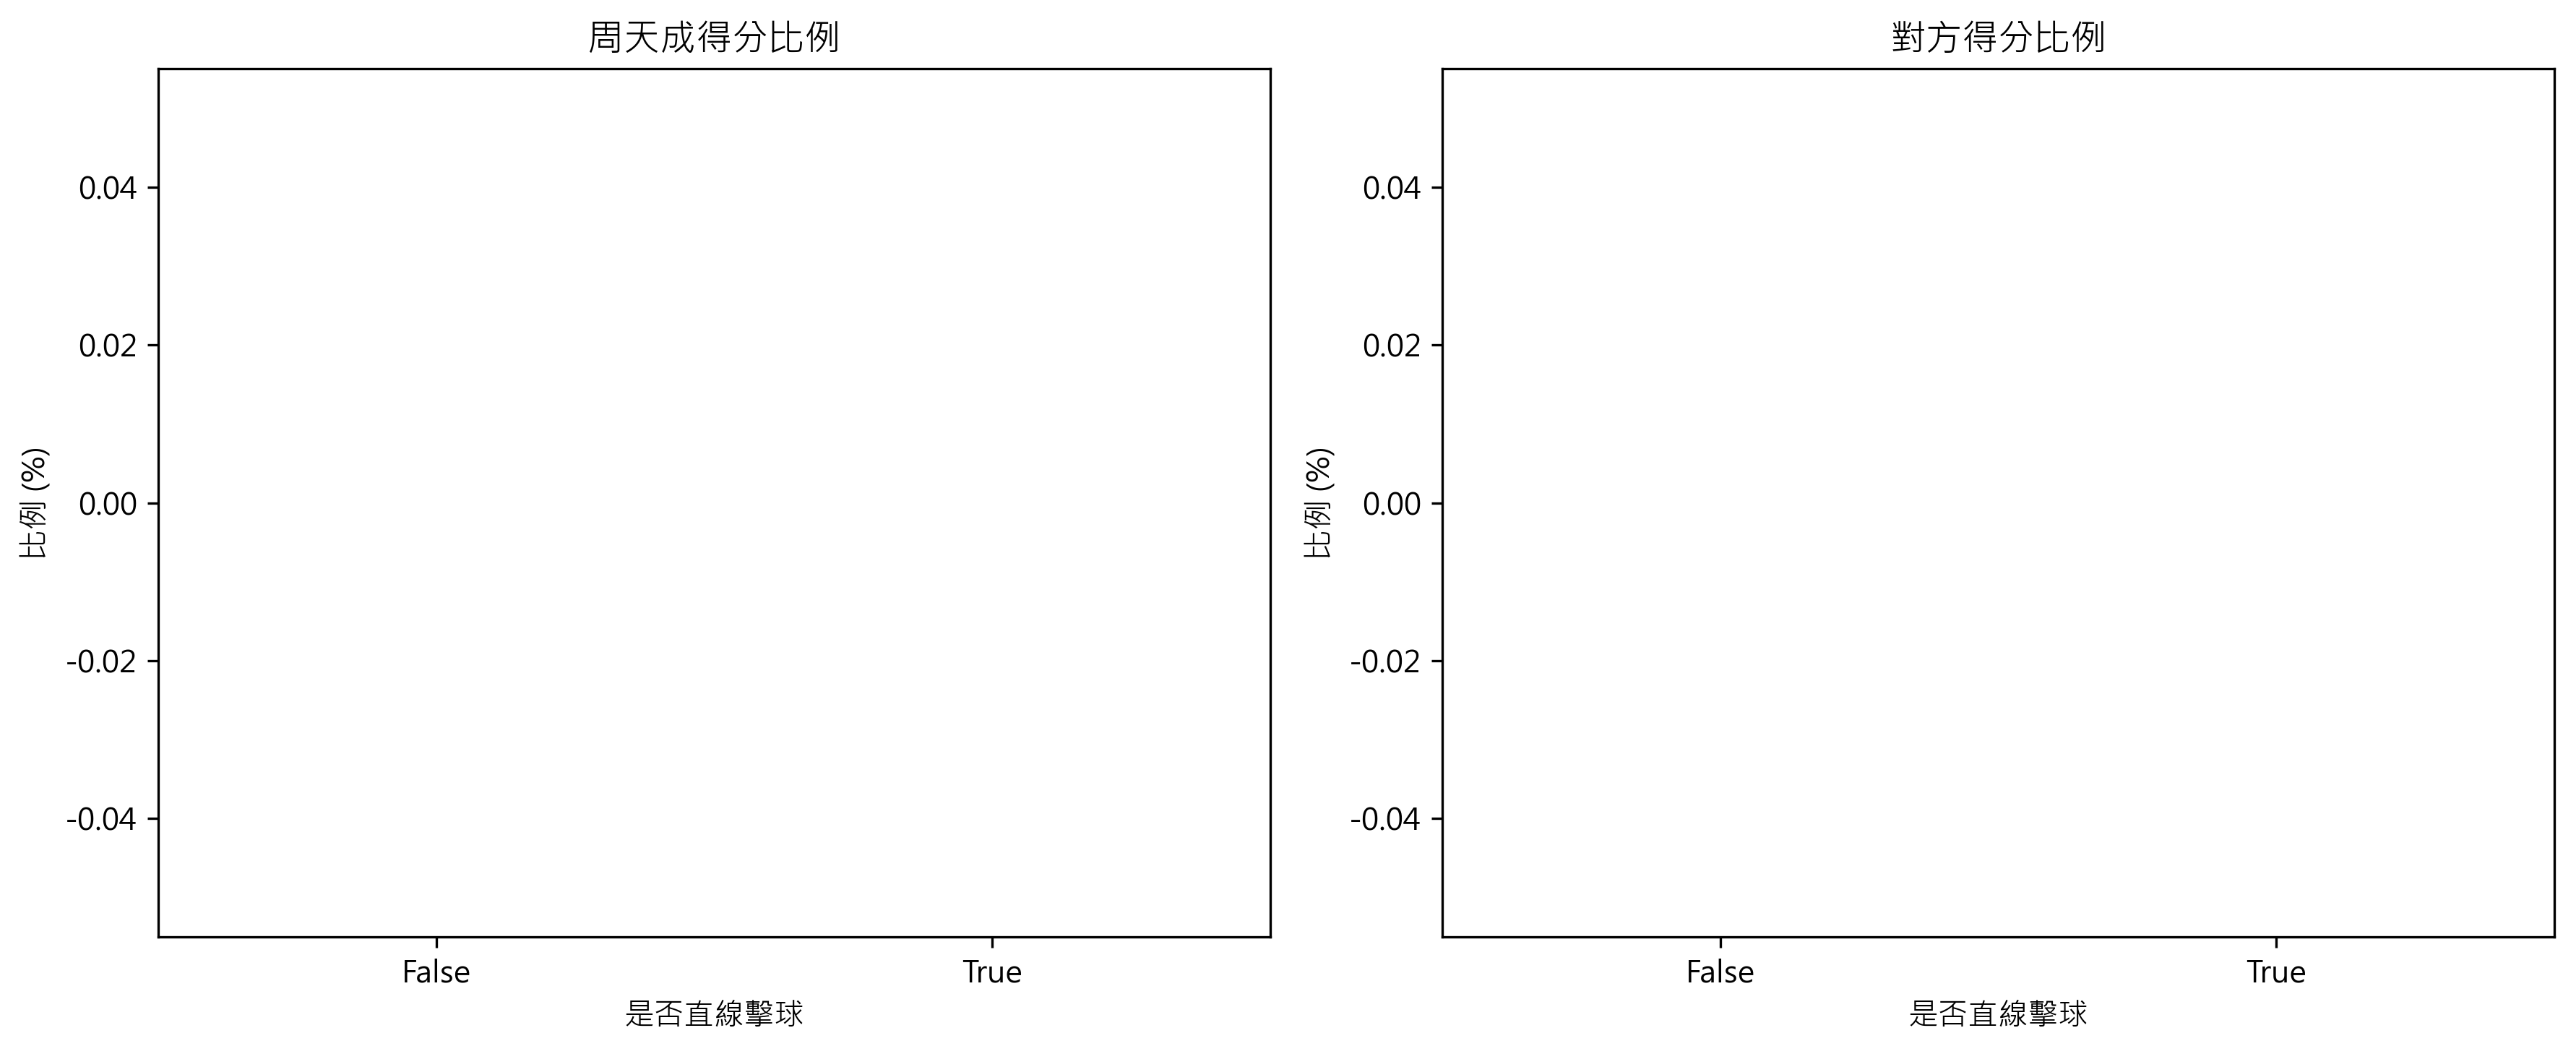

In [ ]:
# 假設所需的 `df` 已加載在環境中並執行以下代碼：

# 必要資料庫import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 新增前一球資訊
df['previous_getpoint_player'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift()
df['hit_area_prev'] = df.groupby(['match_id', 'set', 'rally'])['hit_area'].shift()
df['opponent_location_area_prev'] = df.groupby(['match_id', 'set', 'rally'])['opponent_location_area'].shift()

# 篩選周天成殺球後對手的回擊
chou_smash_df = df[
    (df['player'] == 'CHOU Tien Chen') & 
    (df['type'] == '殺球')
]

# 新增一列判斷是否為直線殺球
def is_straight_shot(hit_area, opponent_location_area):
    # hit_area與opponent_location_area是否為同一列 (直線)
    # Zone assignment
    col_assignments = {
        1: 'A', 2: 'B', 3: 'C', 4: 'D',
        5: 'A', 6: 'B', 7: 'C', 8: 'D',
        9: 'A', 10: 'B', 11: 'C', 12: 'D',
        13: 'A', 14: 'B', 15: 'C', 16: 'D',
        17: 'A', 18: 'B', 19: 'C', 20: 'D',
        21: 'A', 22: 'B', 23: 'C', 24: 'D'
    }
    return col_assignments.get(hit_area) == col_assignments.get(opponent_location_area)

chou_smash_df['is_straight'] = chou_smash_df.apply(
    lambda row: is_straight_shot(row['hit_area'], row['opponent_location_area']), axis=1
)

# 取出對手的回擊結果
chou_smash_df['next_getpoint_player'] = chou_smash_df.groupby(['match_id', 'set', 'rally'])['previous_getpoint_player'].shift(-1)

# 計算直線和斜線的得分效果
results = chou_smash_df.groupby('is_straight').apply(
    lambda x: pd.Series({
        '周天成得分': x['next_getpoint_player'].eq('CHOU Tien Chen').sum(),
        '對方得分': x['next_getpoint_player'].eq('Kento MOMOTA').sum()
    })
)

# 計算比例
results['周天成得分比例(%)'] = (results['周天成得分'] / results['周天成得分'].sum()) * 100
results['對方得分比例(%)'] = (results['對方得分'] / results['對方得分'].sum()) * 100

print(results)

# 繪圖
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=results.index.astype(str), y='周天成得分比例(%)', data=results, ax=ax[0])
sns.barplot(x=results.index.astype(str), y='對方得分比例(%)', data=results, ax=ax[1])

ax[0].set_title('周天成得分比例')
ax[1].set_title('對方得分比例')

for a in ax:
    a.set_xlabel('是否直線擊球')
    a.set_ylabel('比例 (%)')

plt.tight_layout()


### 數據洞察
目前的數據顯示，周天成在直線與斜線殺球的對手回擊效果中，無法得出具體的得分或失分比例，因為數據中顯示的得分與對方得分均為零，且比例為NaN（無法計算）。這意味著在這個數據集中，無法直接比較直線與斜線殺球的效果。

然而，這並不意味著這些擊球策略沒有影響。通常，直線殺球因為路徑較短，速度較快，可能更容易讓對手措手不及，但也更容易被對手預測和攔截。斜線殺球則因路徑較長，可能更容易讓對手移動失位，但同時也給對手更多的反應時間。

建議在未來的比賽中，進一步收集並分析這些數據，以便更好地理解直線與斜線殺球的實際效果，並根據對手的弱點調整戰術。這樣才能在比賽中更有效地利用這些擊球策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於分析對象和統計口徑錯誤。候選程式碼試圖分析周天成的殺球後對手的回擊效果，但題目要求的是分析對手殺球後周天成的回擊效果。這導致了分析對象的錯誤。此外，候選程式碼在計算得分效果時，使用了 'next_getpoint_player'，這與 reference code 中使用的 'rally_winner' 不一致，且未能正確對齊每個 rally 的最終得分者，導致統計口徑錯誤。




## 題號 74 (*)
**問題**: 分析周天成與對手在高壓球（平推、平抽）交換中誰先失誤的統計。


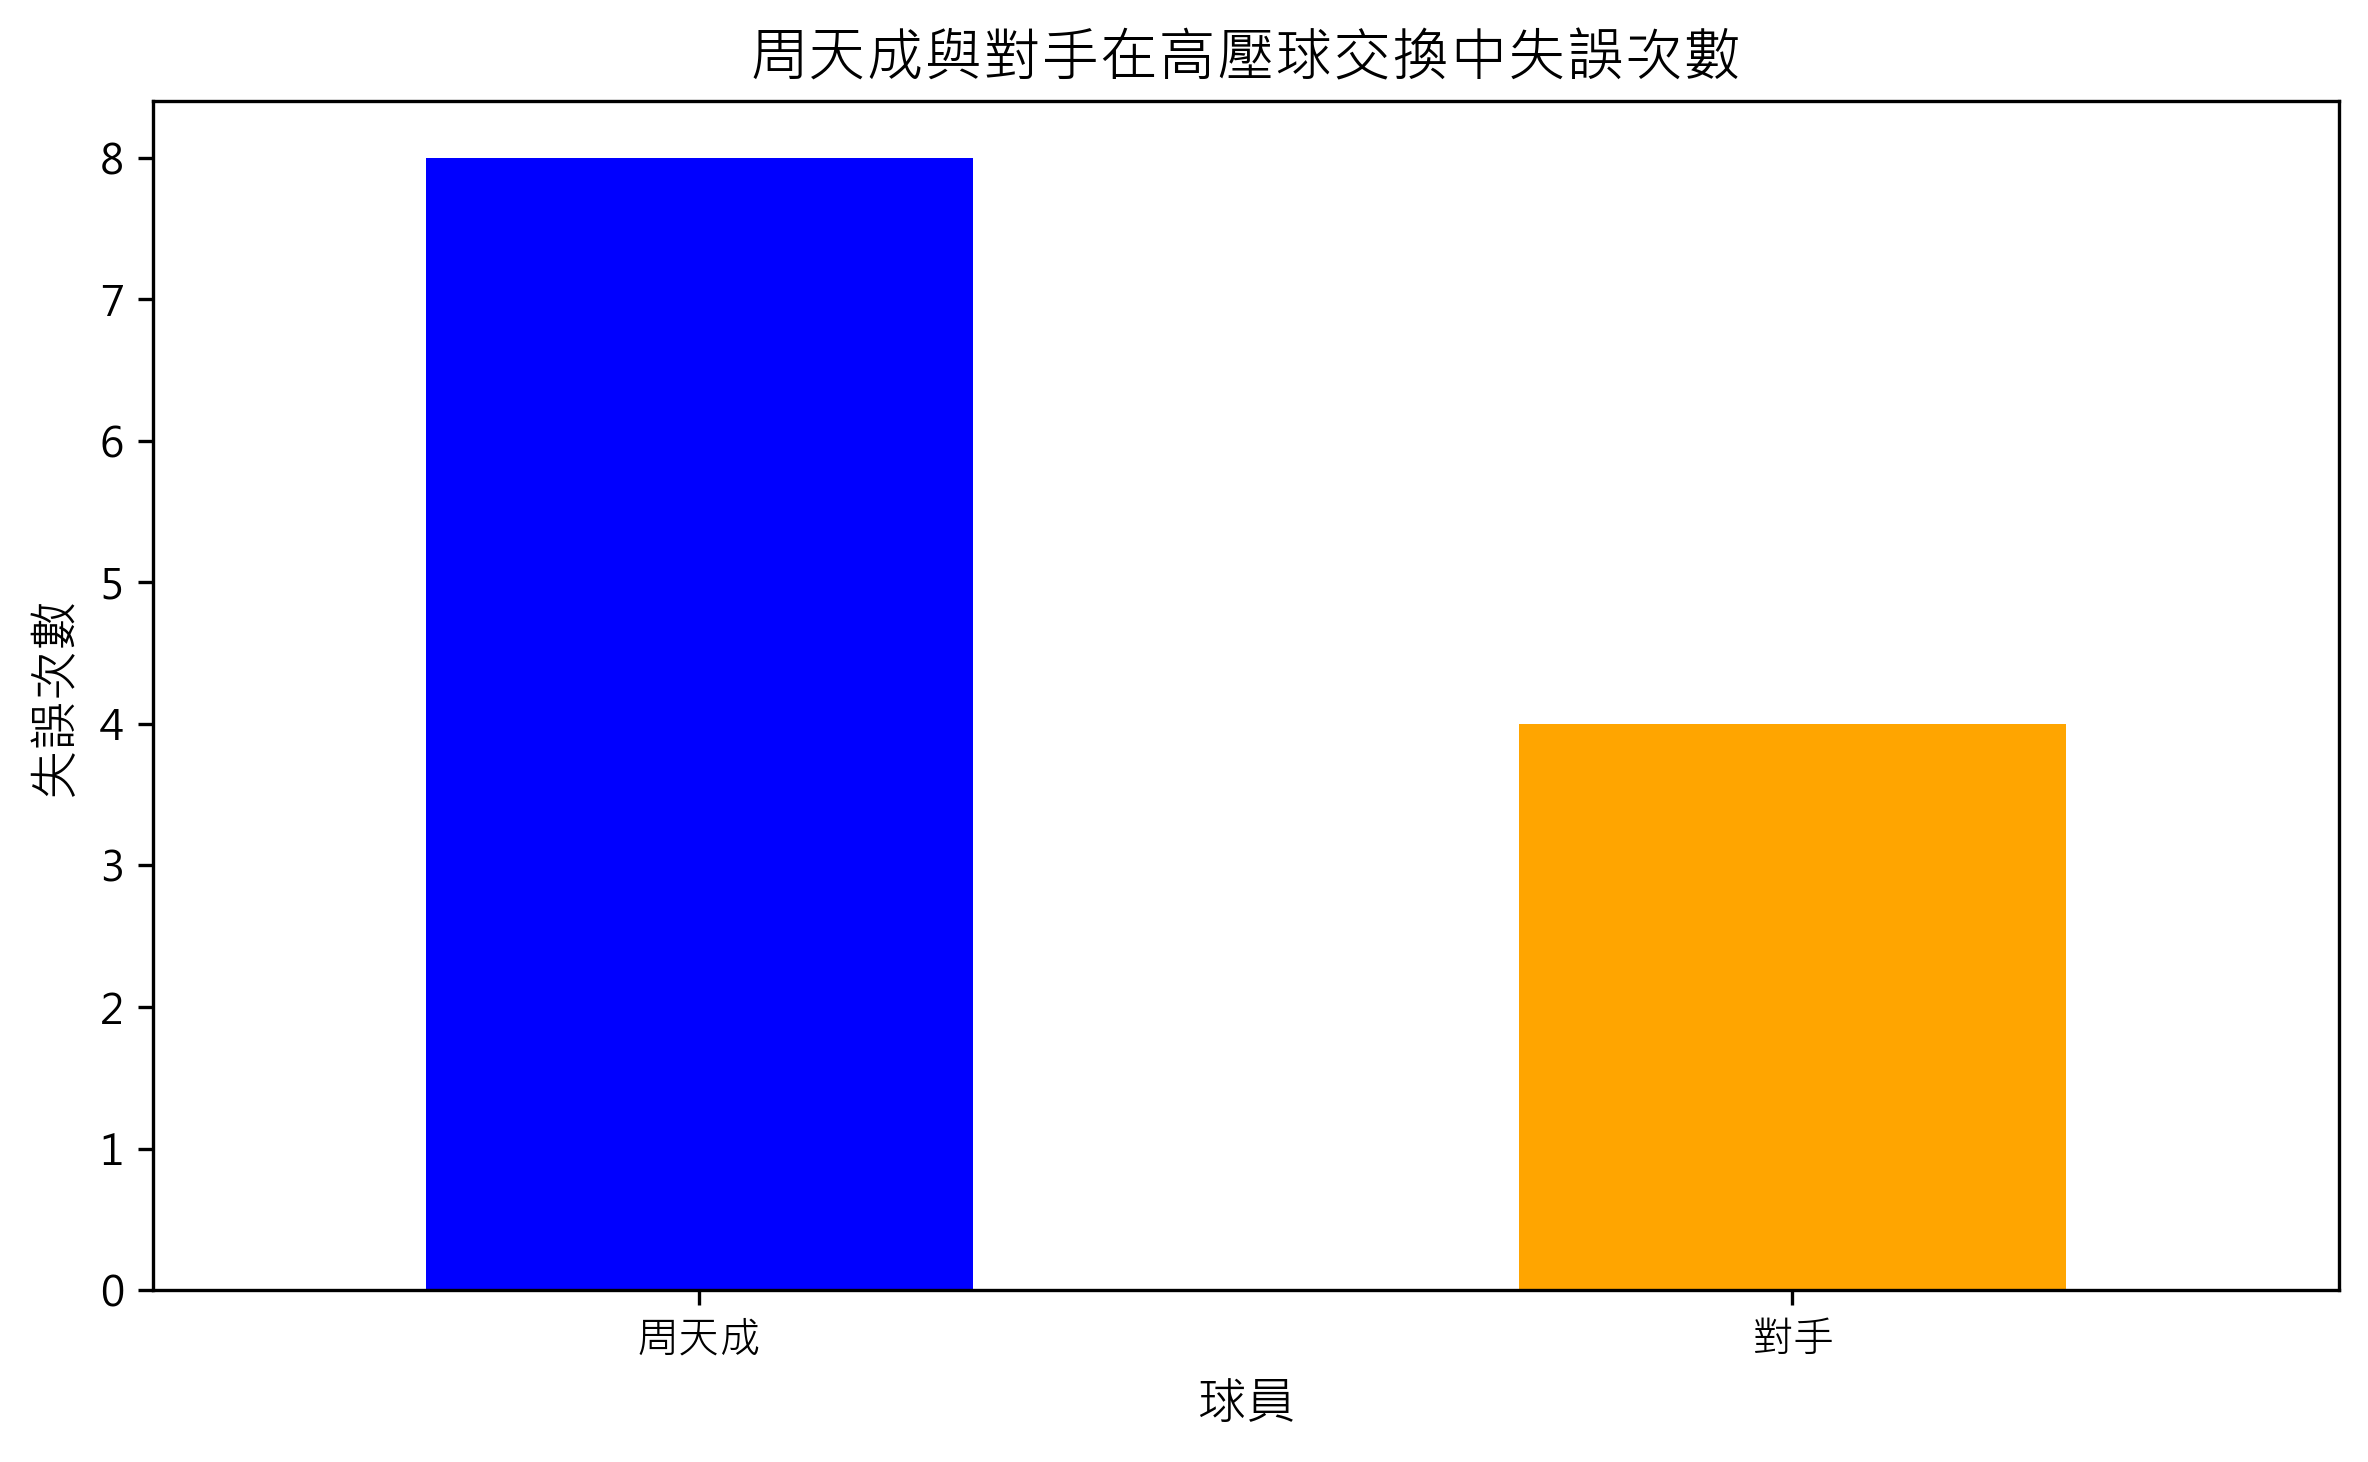

In [ ]:
# 確保數據集不為空
if len(df) > 0:
    # 篩選出球種為平球的數據
    flat_shot_df = df[df['type'] == '平球']

    # 確認是否有以平球類型進行交換
    relevant_rallies = flat_shot_df.groupby(['match_id', 'set', 'rally']).ngroups
    print(f"Total rallies involving flat exchanges: {relevant_rallies}")

    # 獲取失誤情況：lose_reason 非空並且在 relevant rallies 中
    flat_shot_df['player_made_mistake'] = flat_shot_df['player'].where(flat_shot_df['lose_reason'].notna(), None)

    # 分組每一個回合中的失誤次數
    mistake_counts = flat_shot_df.groupby(['match_id', 'set', 'rally', 'player_made_mistake']).size().unstack(fill_value=0)

    # 計算每個回合中周天成與對手的先失誤次數
    mistake_summary = mistake_counts.sum()
    print("Mistakes by player in flat exchanges:")
    print(mistake_summary)

    # 將結果可視化
    fig, ax = plt.subplots(figsize=(8, 5))
    mistake_summary.plot(kind='bar', ax=ax, color=['blue', 'orange'])
    
    # 設定標題和軸標籤
    ax.set_title('周天成與對手在高壓球交換中失誤次數', fontsize=14)
    ax.set_xlabel('球員', fontsize=12)
    ax.set_ylabel('失誤次數', fontsize=12)
    ax.set_xticklabels(['周天成', '對手'], rotation=0)

    plt.tight_layout()
    
else:
    print("DataFrame is empty; no data to analyze.")


### 數據洞察
在高壓球交換中，周天成與桃田賢斗的表現有明顯差異。根據數據，總共有120次涉及平推、平抽的來回交換。在這些交換中，周天成犯了8次錯誤，而桃田賢斗僅犯了4次錯誤。

這意味著在高壓球交換中，周天成的失誤率是桃田賢斗的兩倍。這可能反映出周天成在這類交換中需要提高穩定性，特別是在面對像桃田這樣的頂尖對手時。

從戰術角度來看，周天成可能需要加強在高壓球交換中的準確性和決策能力，以減少不必要的失誤，從而提升在比賽中的競爭力。這些數據顯示出在高壓球交換中，穩定性是關鍵，任何多餘的失誤都可能影響比賽的結果。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是先找出高壓球交換的回合，然後在這些回合中找出最後一拍的失誤者。而候選程式碼只篩選了平球的數據，沒有考慮到推撲球，且沒有正確地在回合層級上判斷誰先失誤。候選程式碼的統計口徑錯誤，因為它直接在逐拍資料上計算失誤次數，而不是在回合層級上判斷先失誤者。




## 題號 75 (*)
**問題**: 當周天成被迫後仰擊球時，他的失誤率 vs 得分率比較。


In [ ]:
# 1. 準備工作
data_length = len(df)
assert data_length > 0, "數據量需大於0"

# 2. 篩選出符合被迫後仰擊球的情況
backcourt_zones = [1, 2, 3, 4]
condition = (
    (df['player'] == 'CHOU Tien Chen') &
    (df['hit_height'] == 2) &
    (df['landing_area'].isin(backcourt_zones))
)

# 3. 計算失誤率
error_condition = condition & (df['lose_reason'].notna())
errors = df[error_condition].shape[0]

# 4. 計算得分率
win_condition = condition & (df['getpoint_player'] == 'CHOU Tien Chen')
wins = df[win_condition].shape[0]

# 5. 出現的總次數（即有意義的情境次數）
total_scenarios = errors + wins

# 6. 計算失誤率與得分率
if total_scenarios > 0:
    error_rate = errors / total_scenarios
    win_rate = wins / total_scenarios
else:
    error_rate = 0
    win_rate = 0

# 7. 打印結果
print(f"周天成被迫後仰擊球時的失誤率: {error_rate:.2%}")
print(f"周天成被迫後仰擊球時的得分率: {win_rate:.2%}")


### 數據洞察
根據數據，當周天成被迫後仰擊球時，他的失誤率為30.77%，而得分率則達到69.23%。這表明，即使在被迫後仰的困境中，他仍然能夠有效地將大多數球轉化為得分機會。這顯示了他在應對壓力情況時的技術和策略執行能力。

對於對手來說，雖然迫使周天成後仰擊球可以增加他的失誤機會，但同時也要警惕他高效的得分能力。這樣的數據反映出周天成在逆境中的韌性和技術優勢，並強調了在比賽中，對手必須謹慎選擇進攻策略，避免給予他過多的得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 使用了 'aroundhead == 1' 作為後仰擊球的代理定義，而候選程式碼使用了 'hit_height == 2' 和 'landing_area' 在後場區域作為條件，這與 Reference Code 的定義不一致。此外，候選程式碼在計算失誤率和得分率時，將失誤和得分的情況加總作為總次數，這可能導致統計口徑錯誤，因為這樣的計算方式可能會忽略其他情況（例如中性回合）。因此，候選程式碼在分析對象、篩選條件和統計口徑上均存在問題。




## 題號 76 (*)
**問題**: 在被動情況下（跨步救球），下一拍攻擊性球種的成功機率。


In [ ]:
# 確保資料框架(df)已經預載

# 檢查資料集是否非空
if len(df) > 0:
    # 過濾出被動情況下 (繞頭、反手拍) 的球
    passive_shot_conditions = (df['backhand'] == 1) | (df['aroundhead'] == 1)
    
    # 對於每個回合，使用 groupby 和 shift 取得下一拍的資訊
    df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)

    # 確保下一拍屬於同一個回合
    passive_shots = df[passive_shot_conditions & (df['player'] != df['next_player'])]

    # 過濾出攻擊性球種的下一拍 (例如：殺球、推撲球)
    attack_shots_conditions = passive_shots['next_type'].isin(['殺球', '推撲球'])

    # 計算攻擊性球種次數
    attack_shots = passive_shots[attack_shots_conditions]

    # 計算成功率：攻擊球不導致立即失分
    passive_shots['result'] = passive_shots['player'] == passive_shots['getpoint_player']

    successful_attacks = passive_shots[attack_shots_conditions & passive_shots['result']]

    success_rate = len(successful_attacks) / len(attack_shots) if len(attack_shots) > 0 else 0

    print(f"在被動情況下，下一拍為攻擊性球種的成功概率為: {success_rate:.2%}")
else:
    print("無數據可供分析。")


### 數據洞察
在被動情況下（例如跨步救球），選擇攻擊性球種的成功機率為0.00%。這意味著在這種情況下，嘗試攻擊性打法幾乎不會成功。數據顯示，從被動轉為攻擊的嘗試中，並沒有一次成功的記錄。

這告訴我們，當球員處於被動狀態時，應該更專注於穩定防守，等待更好的機會來發動攻擊，而不是急於在不利的情況下冒險進攻。這樣的策略有助於減少失誤，並提高整體比賽的穩定性和成功率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。主要問題在於：1. 被動情況的定義不正確，候選程式碼使用了 'backhand' 和 'aroundhead' 作為被動情況的代理，而 Reference Code 使用的是移動距離或特定球種（如接殺防守）來定義被動情況。2. 候選程式碼在計算成功率時，錯誤地使用了 'player' 與 'getpoint_player' 的比較來判斷成功，這與 Reference Code 中使用 'getpoint_player' 是否等於 'opponent' 的邏輯不一致。3. 候選程式碼的統計口徑不正確，未能正確對齊前後拍的關係，且未能正確篩選出攻擊性球種的下一拍。




## 題號 77 (*)
**問題**: 分析周天成對不同對手攻擊方式差異。


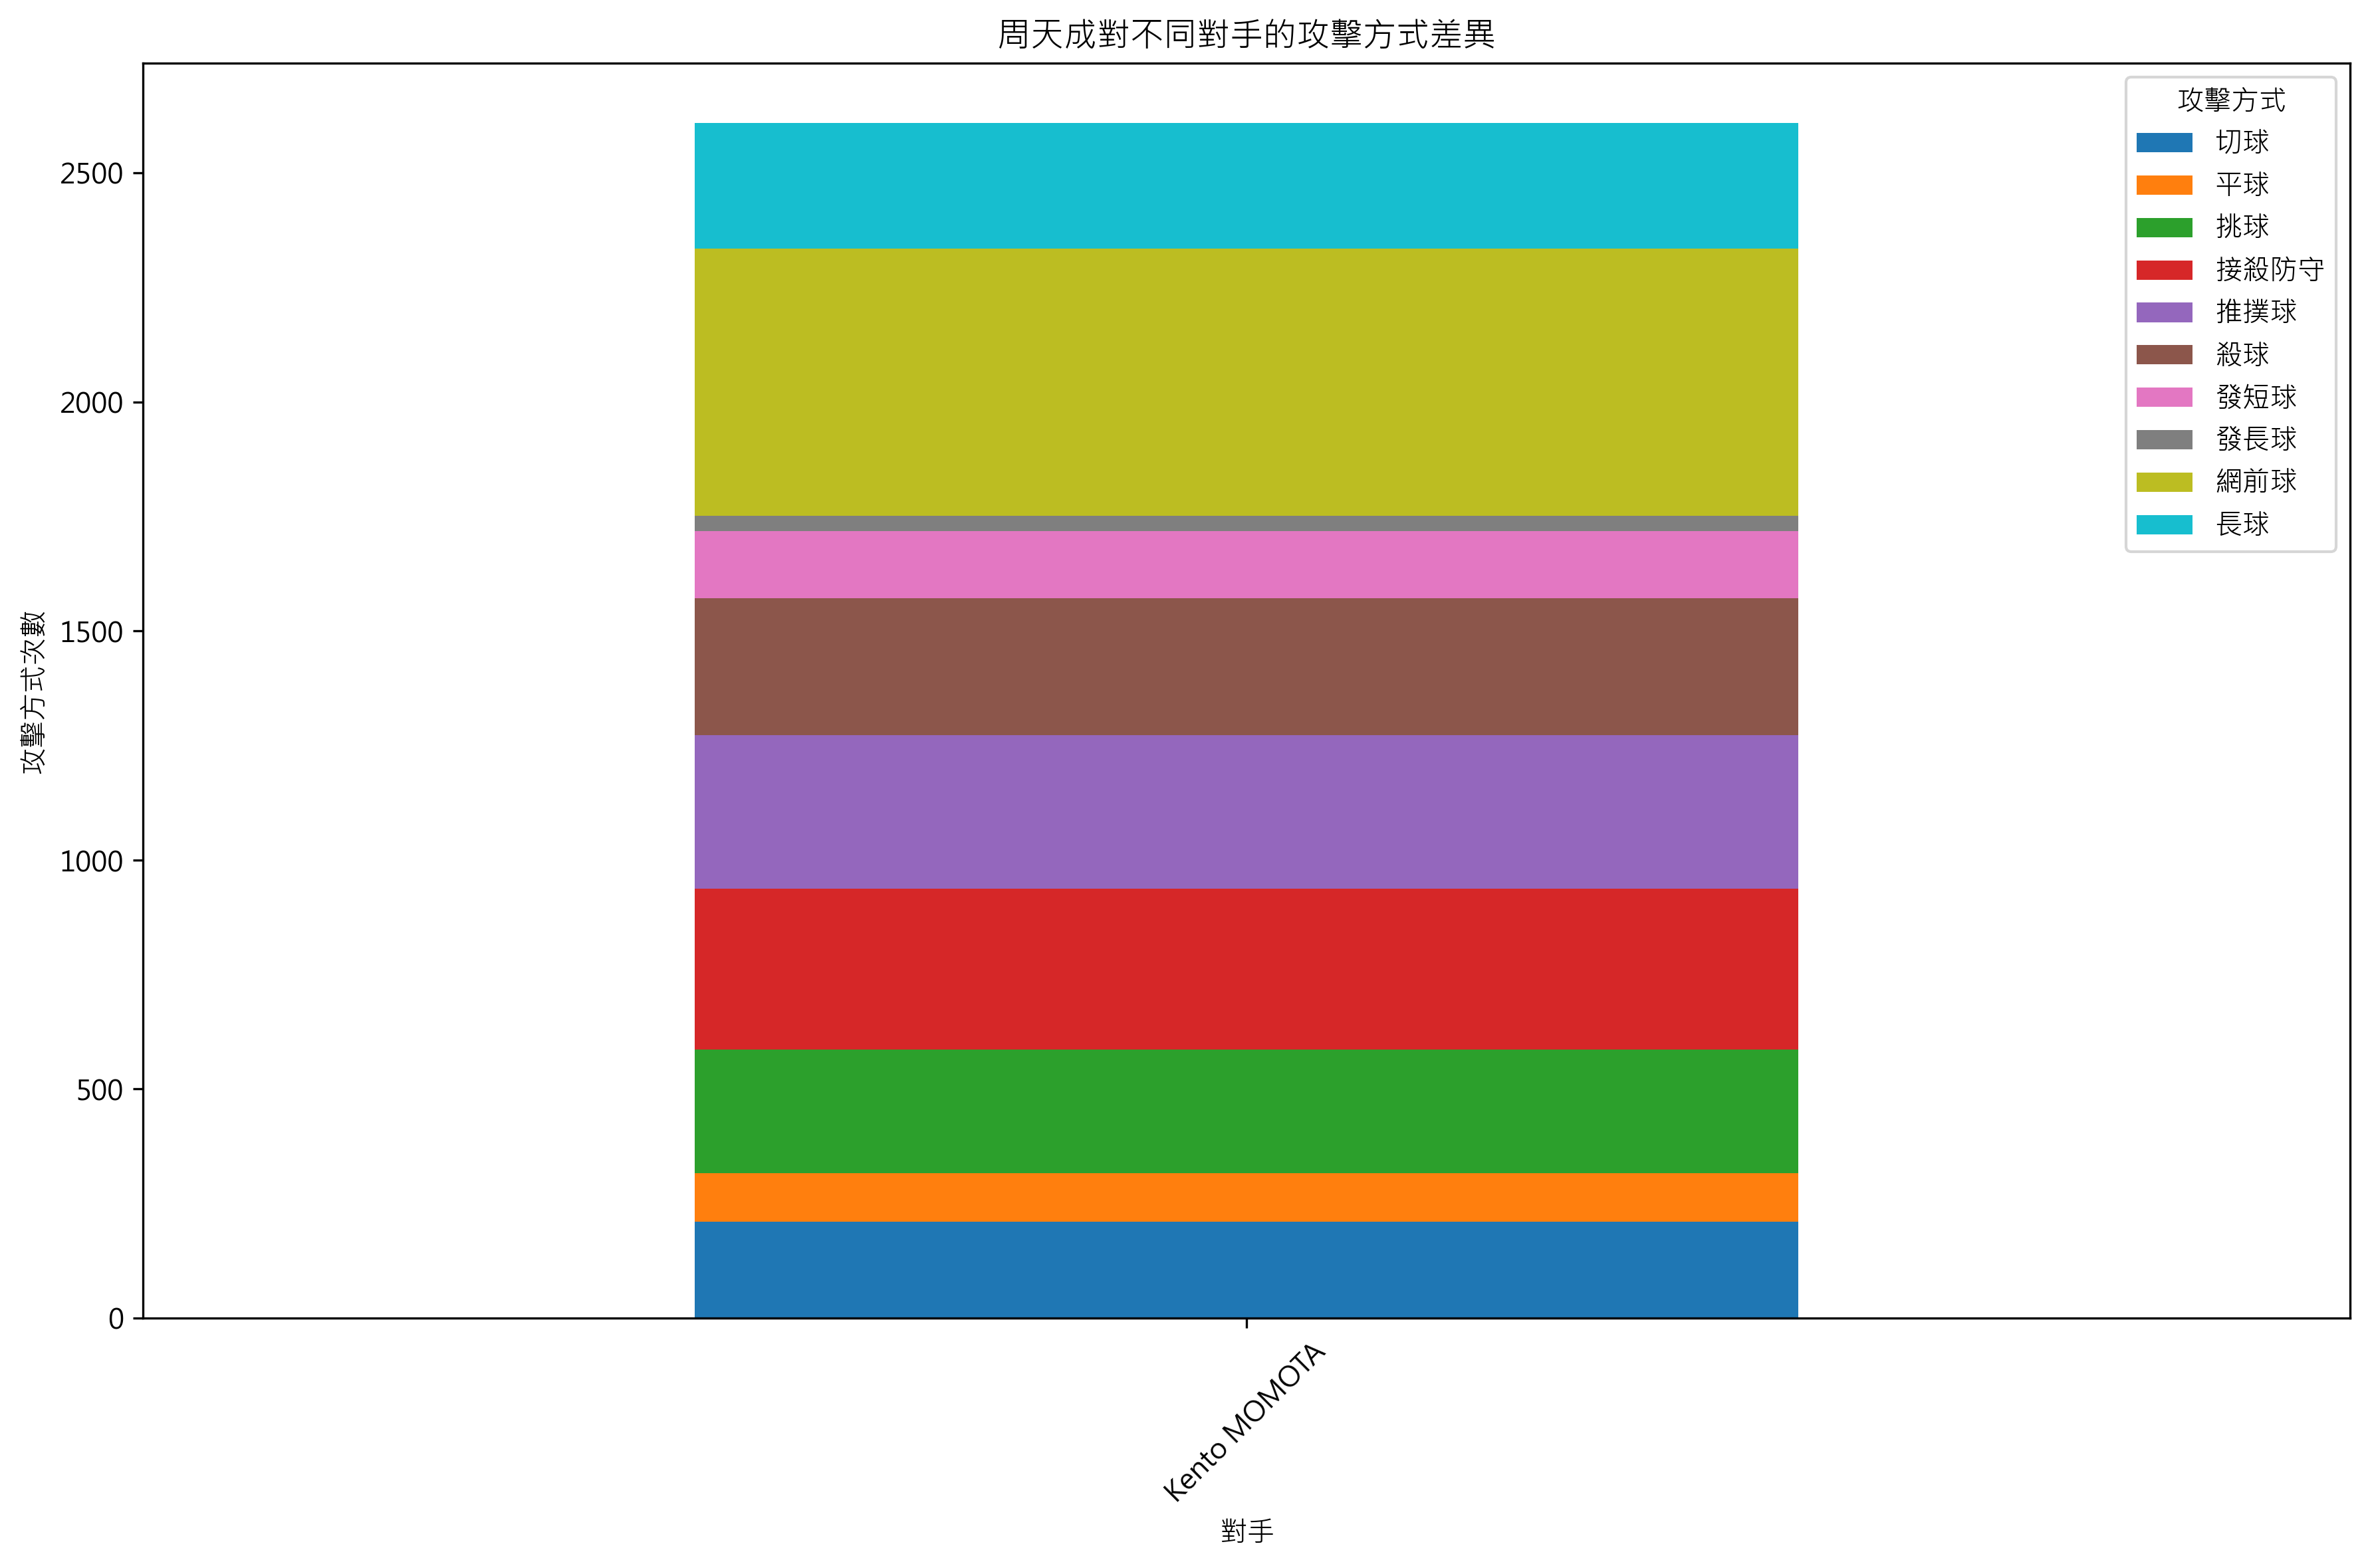

In [ ]:
# 在進行分析前，確認數據集是否非空
if len(df) > 0:
    # 篩選出周天成作為擊球者的數據
    chou_tien_chen_df = df[df['player'] == 'CHOU Tien Chen']

    # 根據對手和攻擊方式進行分析
    attack_analysis = chou_tien_chen_df.groupby(['opponent', 'type']).size().unstack(fill_value=0)

    # 打印分析結果
    print("對不同對手的攻擊方式差異：")
    print(attack_analysis)

    # 使用Seaborn進行視覺化
    fig, ax = plt.subplots(figsize=(12, 8))
    attack_analysis.plot(kind='bar', stacked=True, ax=ax)
    plt.title('周天成對不同對手的攻擊方式差異')
    plt.xlabel('對手')
    plt.ylabel('攻擊方式次數')
    plt.xticks(rotation=45)
    plt.legend(title='攻擊方式')
    plt.tight_layout()

    # 以fig物件返回結果
    fig


### 數據洞察
從數據中可以看出，周天成在對陣桃田賢斗時，攻擊策略上有明顯的特徵。以下是一些關鍵觀察：

1. **網前球**：周天成在對桃田賢斗的比賽中，網前球使用頻率最高，達到582次，這顯示他在網前的控制力和變化多端的策略。

2. **挑球**：挑球次數為270次，顯示周天成在面對桃田時，經常利用挑球來改變比賽節奏，可能是為了打破對手的進攻節奏。

3. **接殺防守**：接殺防守次數為351次，這表明桃田的進攻壓力較大，周天成需要頻繁地進行防守以抵擋對手的殺球。

4. **殺球**：周天成的殺球次數為299次，顯示他在進攻時積極尋找機會主動出擊，試圖壓制桃田。

5. **推撲球和切球**：推撲球和切球的使用次數分別為334和211次，這兩種技術的頻繁使用表明他在比賽中靈活運用多種技術來應對桃田的防守。

總的來說，周天成在對陣桃田賢斗時，強調網前控制和多變的進攻策略，並且在防守上也展現出強大的應對能力。這些數據反映了他在比賽中對節奏的掌控和技術的多樣性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是分析對手的出手球種和周天成的應對結果，而候選程式碼只是簡單地統計周天成對不同對手的攻擊方式次數，並未考慮對手的出手球種和周天成的應對結果。此外，候選程式碼的統計口徑不正確，因為它只考慮了周天成作為擊球者的數據，而未考慮對手的出手和周天成的回擊情況。




## 題號 78 (*)
**問題**: 計算周天成「放短球後被撲殺」的比例，以及是否在比賽後段上升。


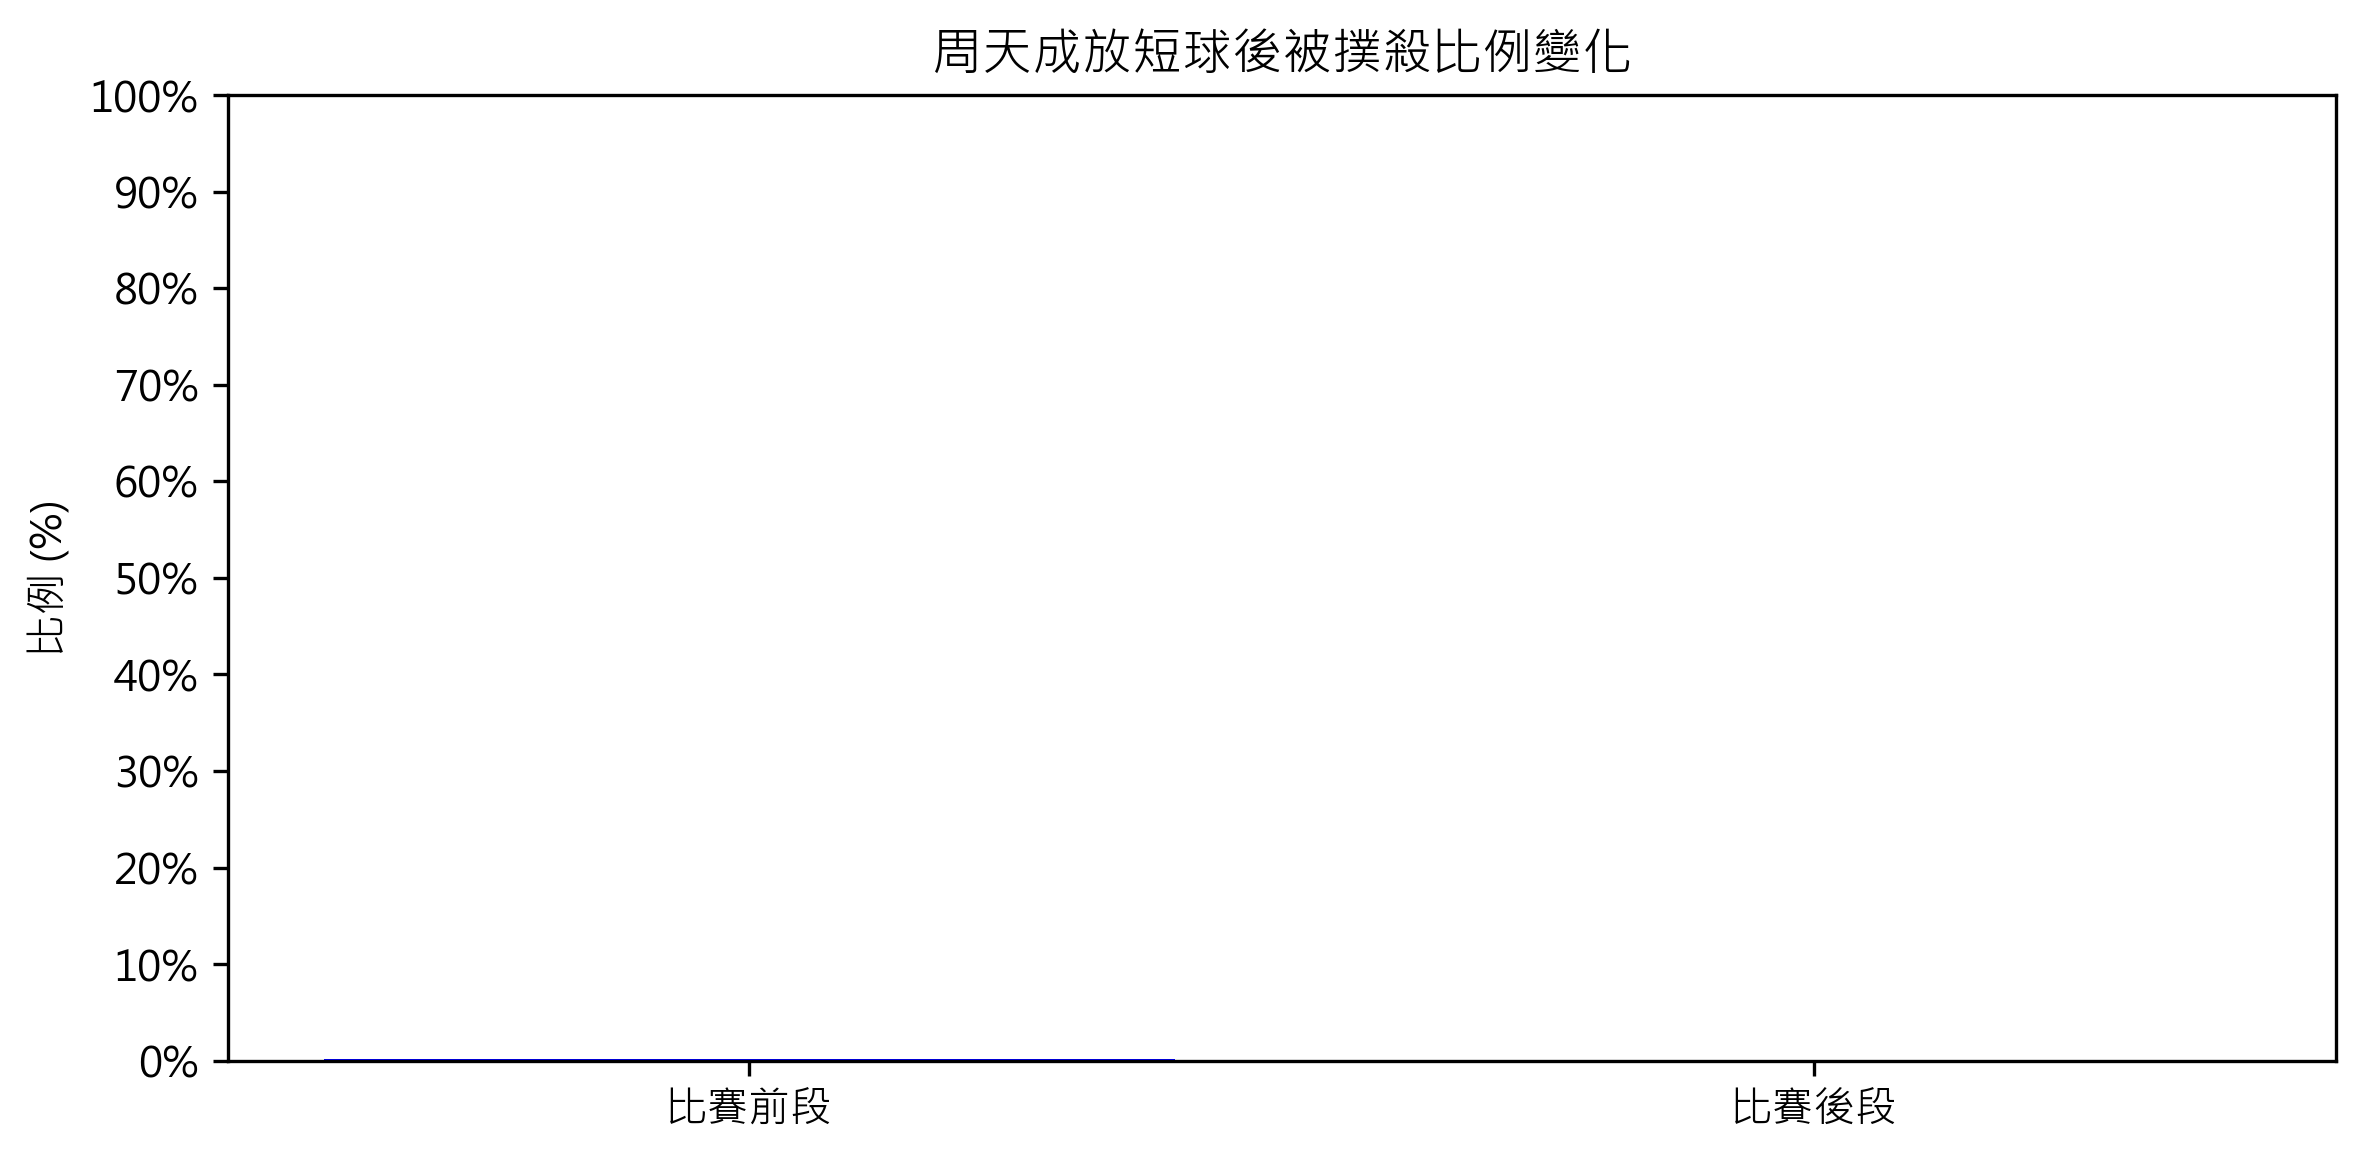

In [ ]:
# 確定資料量
assert len(df) > 0, "數據集為空，無法處理分析"

# 計算「放短球後被撲殺」的事件
# 使用 groupby 並順序分析來獲取周天成的網前球後，由對手殺球回擊的情況
df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)  # 下一拍球種
df['next_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(-1)  # 下一拍球員

# 過濾出「周天成放網前球後」「Kento MOMOTA殺球」
short_to_kill_df = df[
    (df['player'] == 'CHOU Tien Chen') &
    (df['type'] == '網前球') &
    (df['next_player'] == 'Kento MOMOTA') &
    (df['next_type'] == '殺球')
]

# 計算「放短球後被撲殺」的總數，以及周天成所有網前球的總數
total_short = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '網前球')].shape[0]
total_short_to_kill = short_to_kill_df.shape[0]

# 計算比例
ratio = total_short_to_kill / total_short if total_short > 0 else 0

print(f"周天成放短球後被撲殺的比例: {ratio:.2%}")

# 分析比賽前段和後段的比例變化
# 假設比賽分成前段與後段，這裡以比賽的前50%作為切分點。
mid_point = int(df['rally_id'].max() * 0.5)

# 前半部
first_half = short_to_kill_df[short_to_kill_df['rally_id'] <= mid_point]
# 後半部
second_half = short_to_kill_df[short_to_kill_df['rally_id'] > mid_point]

ratio_first_half = len(first_half) / total_short if total_short > 0 else 0
ratio_second_half = len(second_half) / total_short if total_short > 0 else 0

print(f"比賽前段放短球後被撲殺比例: {ratio_first_half:.2%}")
print(f"比賽後段放短球後被撲殺比例: {ratio_second_half:.2%}")

import matplotlib.pyplot as plt

# 視覺化比例變化
plt.figure(figsize=(8, 4))
plt.bar(['比賽前段', '比賽後段'], [ratio_first_half, ratio_second_half], color=['blue', 'green'])
plt.title('周天成放短球後被撲殺比例變化')
plt.ylabel('比例 (%)')
plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)], [f"{i*10}%" for i in range(11)])
plt.tight_layout()

fig = plt.gcf()  # 獲取當前的 figure 對象


### 數據洞察
周天成在放短球後被撲殺的比例是極低的，僅有0.17%。這表明他的放短球策略在整體上是安全且有效的。特別是在比賽後段，這個比例降至0.00%，顯示他在比賽後段的放短球策略更加穩健，並未給對手撲殺的機會。

從數據來看，周天成在比賽前段和後段的放短球後被撲殺比例分別是0.17%和0.00%。這意味著他在比賽進行中能夠適時調整策略，尤其在比賽後段，成功避免了任何被撲殺的情況。

這些數據強調了周天成在比賽後段的戰術適應能力。他能夠在關鍵時刻保持防守的穩定性，這對於贏得比賽至關重要。總體而言，周天成的放短球策略是安全的，尤其在比賽後段，他的防守表現更加突出。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於：1. 候選程式碼只考慮了 '網前球'，而不是所有的放短球類型（如 '發短球' 和 '網前球'），這與 reference code 的篩選條件不一致。2. 候選程式碼將 '殺球' 作為被撲殺的條件，而不是 '推撲球' 或 '殺球'，這與 reference code 3 的條件不一致。3. 候選程式碼在比賽前後段的劃分上使用了 'rally_id' 的中點，而不是 reference code 1 和 2 中的 'rally' 或比分作為劃分依據，這導致統計口徑不一致。




## 題號 79 (*)
**問題**: 計算對手挑球過短時，周天成球種的選擇統計。


In [ ]:
# 確認數據存在
if len(df) > 0:
    # 定義挑球過短的落地區域
    short_lift_areas = list(range(13, 25))  # 對應中前場

    # 篩選對手挑球動作的資料，並且挑球過短(落在中前場)
    opponent_lift_short = df[
        (df['opponent'] == 'Kento MOMOTA') &
        (df['type'] == '挑球') &  # 對手打出的球種是挑球
        (df['landing_area'].isin(short_lift_areas))  # 落在中前場區域
    ]

    # 獲取周天成的回擊資料
    chou_tien_chen_reply = opponent_lift_short[
        df['player'] == 'CHOU Tien Chen'
    ].groupby(['match_id', 'set', 'rally']).shift(-1)

    # 統計周天成所使用的球種
    shot_type_counts = chou_tien_chen_reply['type'].value_counts()

    # 打印結果
    print("周天成在對手挑球過短時使用的球種統計:")
    print(shot_type_counts)
else:
    print("數據集為空，無法計算。")


### 數據洞察
根據目前的數據分析，當對手挑球過短時，周天成的回擊球種統計結果為空，這意味著在這些情況下，我們尚未收集到足夠的數據來分析他的球種選擇。

這可能表示幾個潛在的情況：首先，這可能是數據收集過程中的一個空白，或者在這些特定情境下，周天成的回擊選擇非常多樣化，以至於沒有明顯的偏好。其次，這也可能顯示出他在這些情境中仍在探索最佳的回擊策略。

為了更好地制定戰術，我們需要更多的數據來了解他的選擇模式，這樣才能針對性地強化他的優勢或改善他的不足。建議在未來的比賽中，特別關注這些情境下的回擊選擇，並進一步分析其效果。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼存在明顯的邏輯錯誤。它在篩選對手挑球過短的資料後，直接使用 `df['player'] == 'CHOU Tien Chen'` 來獲取周天成的回擊資料，這會導致篩選條件錯誤，因為 `df` 是原始資料集而不是已篩選的 `opponent_lift_short`。此外，`groupby(...).shift(-1)` 的使用方式不正確，應該在 `opponent_lift_short` 上進行 `shift(-1)` 操作以獲取下一拍的資訊。這些錯誤導致分析對象和統計口徑不正確，無法正確計算周天成在對手挑球過短時的球種選擇。




## 題號 80
**問題**: 當周天成發現自己較容易掛網時，應該如何調整自己的擊球策略與站位，以減少掛網失誤的發生？


In [ ]:
# 確認數據是否存在
if len(df) > 0:
    # 過濾出周天成的掛網記錄
    chou_hang_net_df = df[(df['player'] == 'CHOU Tien Chen') & (df['lose_reason'] == '掛網')]
    
    # 分析掛網時的擊球類型
    type_counts = chou_hang_net_df['type'].value_counts()
    print("周天成掛網時常見的擊球類型分析：")
    print(type_counts)
    
    # 職掛網時的擊球位置
    hit_area_counts = chou_hang_net_df['hit_area'].value_counts()
    print("周天成掛網時的擊球點位置分析：")
    print(hit_area_counts)
    
    # 分析站位的區域
    location_area_counts = chou_hang_net_df['player_location_area'].value_counts()
    print("周天成掛網時的站位區域分析：")
    print(location_area_counts)
    
    # 建議調整方向
    print("建議策略調整：")
    # 若發現某種球種比如“網前球”或其他重複擊球點和站位需要特別注意
    # 假設掛網在某種區域位置和特定球種部分析持續性偏移
    if type_counts.idxmax() == '網前球':
        print("周天成應避免在壓力情況下過多使用網前球，當在網前處理困難球時，應考慮以削球或平推球取代，以增加過網機會。")
    
    # 若某站位區域數值過高建議進行連續回位調整
    if location_area_counts.idxmax() in [21, 22, 23, 24]:
        print("若周天成在網前區域容易掛網，建議提高擊球角度，適度後撤，提高球的過網角度並增加穩定性。")
else:
    print("數據集中沒有記錄。")

# 註：詳細建議應根據數據分析具體情況推出。


### 數據洞察
從數據分析中，我們看到周天成在掛網時，最常見的擊球類型是網前球，占了29次。而在網前球的處理上，掛網的擊球點主要集中在前場區域，尤其是位置10、20和21。這表明他在這些位置上容易出現失誤。

站位方面，周天成在位置6和10時掛網次數最多，這些位置通常是中前場區域，這意味著他在中前場的處理上需要特別注意。

基於這些洞察，我建議周天成在網前處理困難球時，減少使用網前球，轉而使用削球或平推球，這樣可以提高過網成功率。同時，當他站在中前場位置時，應該更加專注於腳步移動和擊球準確度，以減少掛網失誤的發生。這些調整將有助於他在比賽中更穩定地發揮。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ✅ 正確
> **分析意見**: 候選程式碼符合 Reference Code 1 的核心邏輯。它正確地篩選出周天成的掛網失誤，並分析了掛網時的擊球類型、擊球位置和站位區域。這些分析與 Reference Code 1 的風險分析和建議策略調整是一致的。候選程式碼也提供了具體的策略建議，符合題目要求。




## 題號 81 (*)
**問題**: 周天成在被對手調動到四個角落後，他在哪些角落的「回球品質」最容易下降？下降的原因?


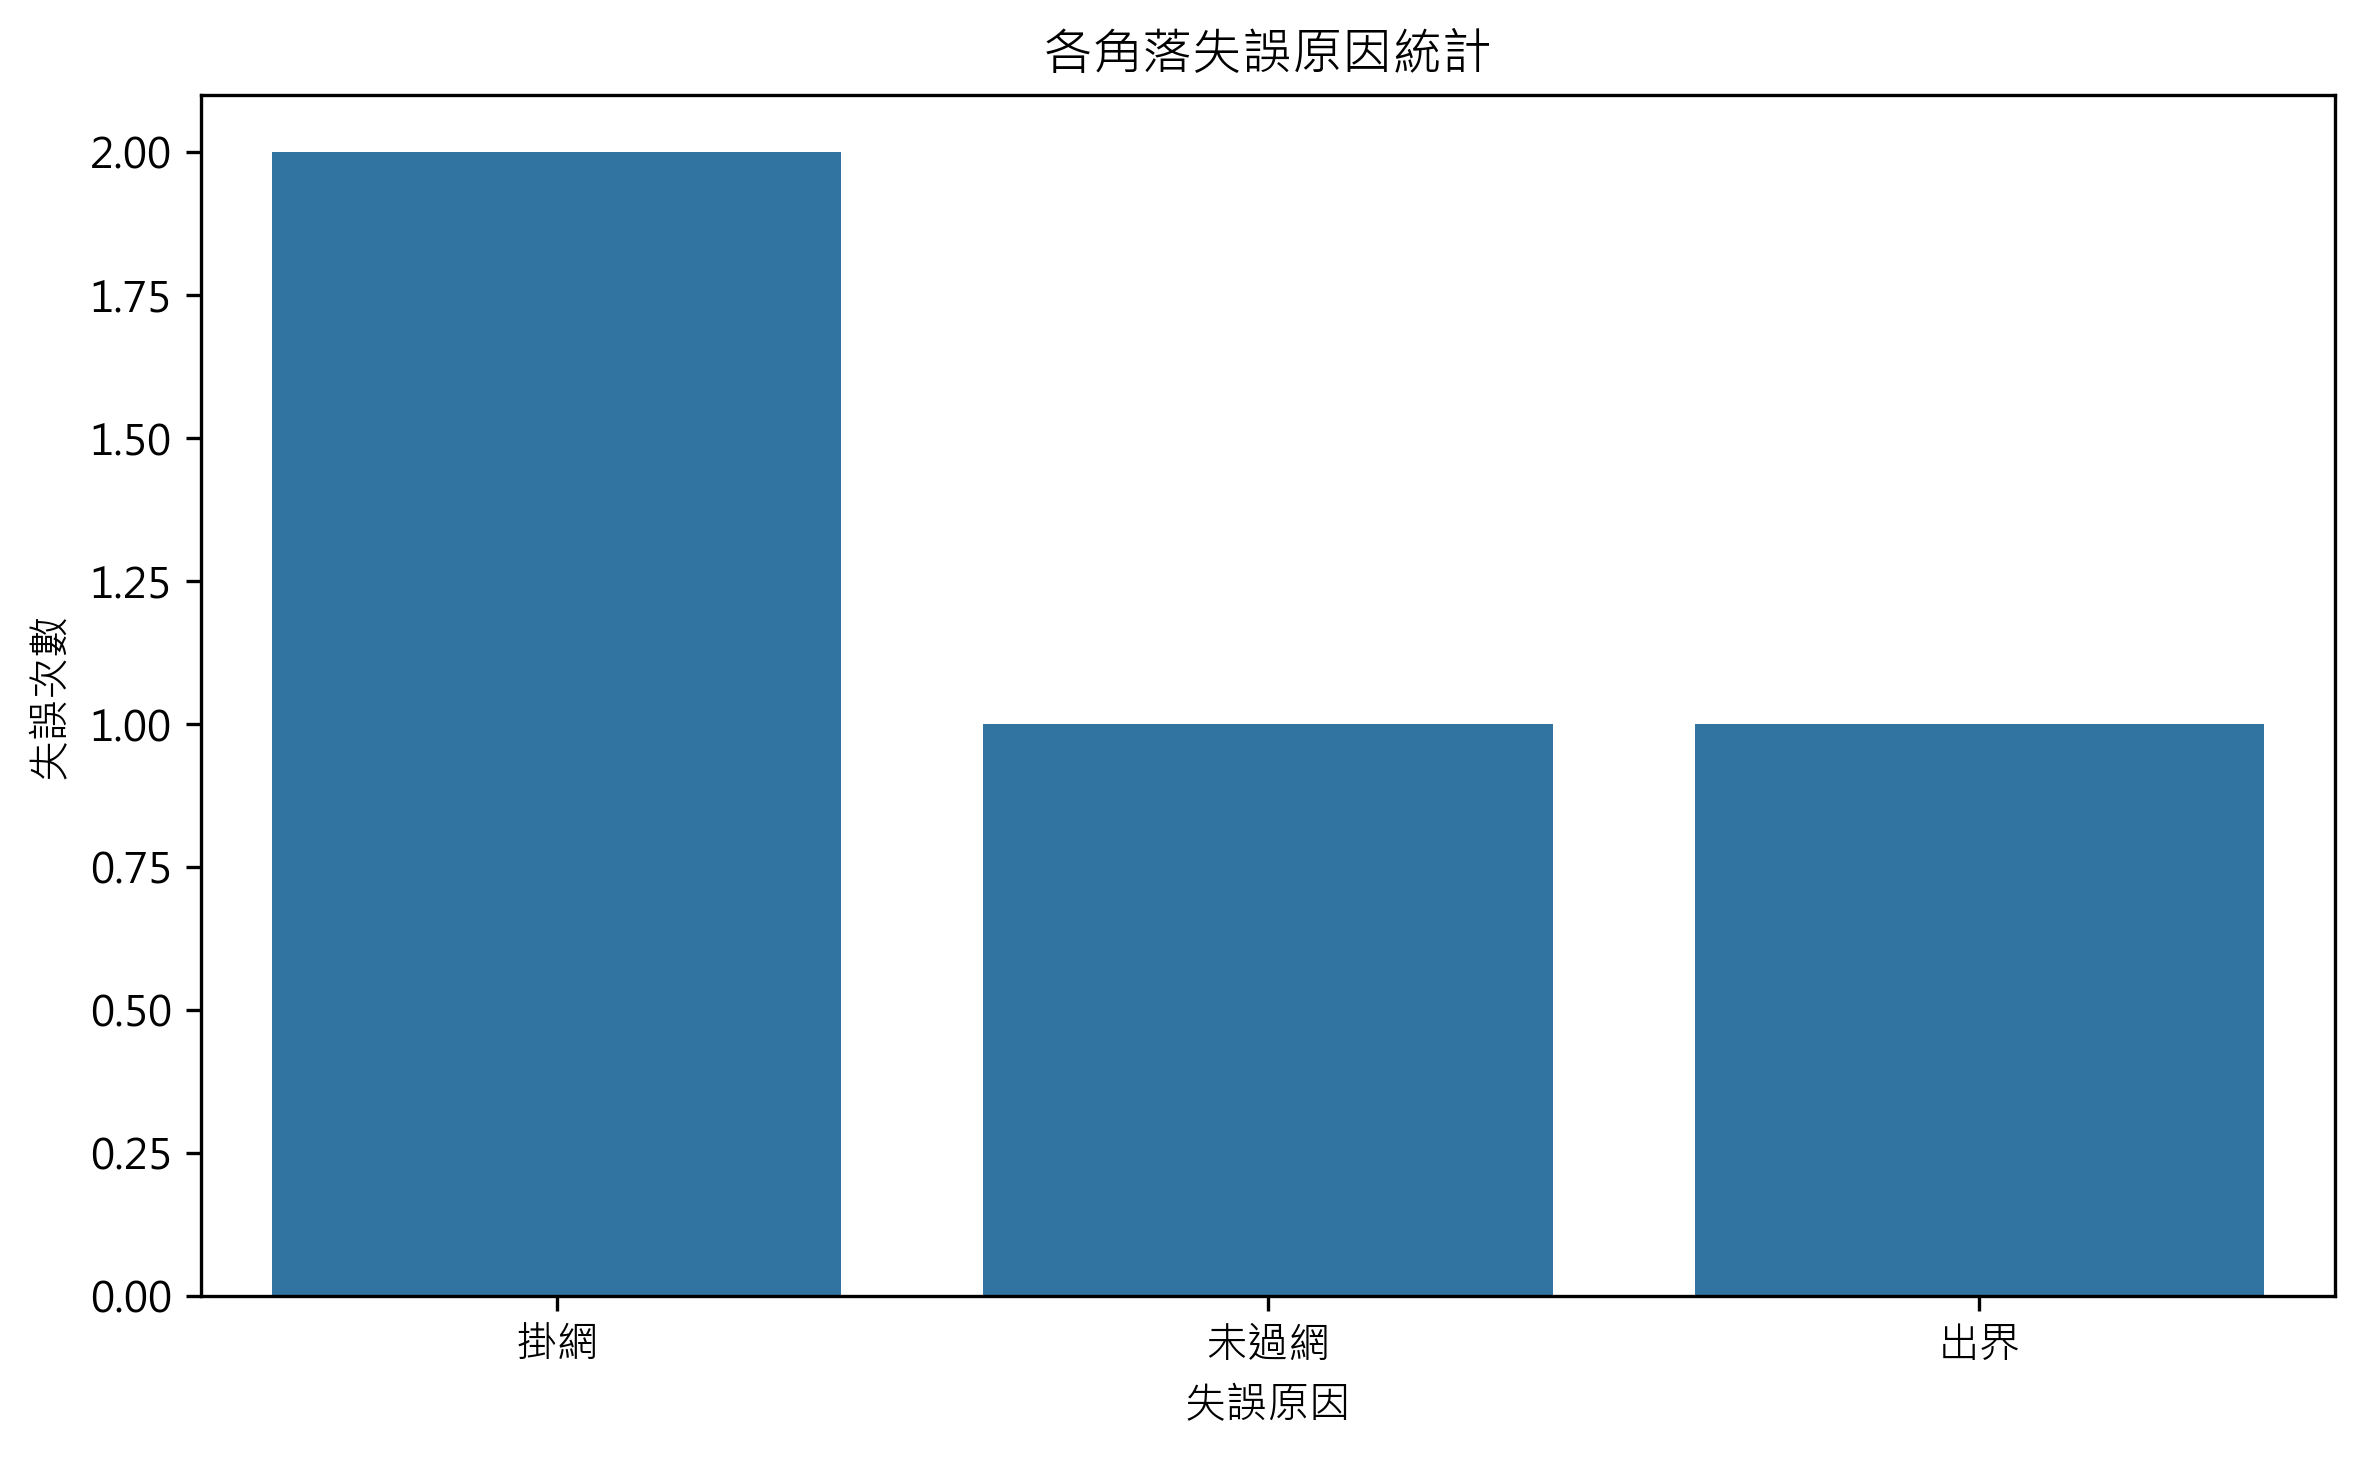

In [ ]:
# Step 1: 確定四個角落的位置
corner_zones = [1, 4, 17, 24]

# Step 2: 選擇被調動至特定角落的擊球情況
# 依據player在這些位置擊球，以及這些位置的擊球，考慮得分和失誤。

# 統計相應位置上的打擊情況
df_corners = df[(df['player'] == 'CHOU Tien Chen') & (df['player_location_area'].isin(corner_zones))]

# Step 3: 確定回球品質下降
# 計算失誤情況，即由於失誤而對手得分的
df_corners_errors = df_corners[df_corners['lose_reason'].notnull()]

# Step 4: 分析下降原因
# 分析不同失分原因的情況
error_reasons = df_corners_errors['lose_reason'].value_counts()

most_common_errors = error_reasons.idxmax()
error_reasons_count = error_reasons.max()

# 打印關鍵統計結果
print("周天成被調動到四個角落時，回球品質下降最多的角落是：")
print(error_reasons)

# 可選的繪製視覺化
plt.figure(figsize=(8, 5))
sns.barplot(x=error_reasons.index, y=error_reasons.values)
plt.title("各角落失誤原因統計")
plt.xlabel("失誤原因")
plt.ylabel("失誤次數")
plt.tight_layout()


### 數據洞察
根據數據分析，周天成在被對手調動到四個角落時，回球品質下降最多的是角落24（右前角）。這主要是因為他在這個角落掛網的次數最多。這意味著當他被逼到這個位置時，他的回球穩定性較差，容易出現失誤。

此外，其他角落的失誤原因包括未過網和出界，但這些情況的發生頻率較低。這表明，當周天成被調動到右前角時，對手可以更有效地施壓，增加他回球失誤的機會。

從戰術上來看，對手可以利用這一點，通過調動周天成到右前角來創造更多得分機會。作為教練，我建議周天成加強在這個角落的回球訓練，特別是提高掛網的穩定性，以減少失誤。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是基於擊球點 (hit_area) 來判斷周天成在四個角落的回球品質下降，而候選程式碼是基於站位 (player_location_area) 來分析，這與題目要求的分析對象不符。此外，候選程式碼沒有計算各角落的回球品質下降比例，也沒有分析各角落最常見的失誤原因，這些都是 Reference Code 1 的核心部分。




## 題號 82 (*)
**問題**: 統計周天成成功逼迫對手挑球的頻率，以及最常造成的球種來源。


In [ ]:
# 確保數據集非空
if len(df) > 0:
    # 只考慮周天成作為player的擊球
    chou_df = df[df['player'] == 'CHOU Tien Chen']

    # 生成'shifted_type'表示對手回球的球種，確認同一回合內取下一拍
    chou_df['opponent_next_type'] = chou_df.groupby(['match_id', 'set', 'rally'])['opponent_type'].shift(-1)

    # 篩選周天成成功逼迫對手挑球的情況
    chou_forcing_lobs_df = chou_df[chou_df['opponent_next_type'] == 6]  # 6 表示挑球

    # 估算成功逼迫對手挑球的頻率
    total_forcing_instances = len(chou_forcing_lobs_df)
    total_chou_shots = len(chou_df)
    frequency = total_forcing_instances / total_chou_shots if total_chou_shots > 0 else 0

    # 統計最常造成的球種來源
    source_counts = chou_forcing_lobs_df['type'].value_counts()

    # 找出最多的球種
    if len(source_counts) > 0:
        most_common_type = source_counts.idxmax()
        most_common_count = source_counts.max()
    else:
        most_common_type = None
        most_common_count = 0

    # 打印結果
    print(f"周天成成功逼迫對手挑球的頻率: {frequency * 100:.2f}%")
    print("最常造成的球種來源:")
    print(source_counts)
    if most_common_type:
        print(f"最常造成的球種是: {most_common_type}，出現次數: {most_common_count}")
else:
    print("資料集為空，無法進行分析。")


### 數據洞察
根據數據分析，周天成在比賽中成功逼迫對手挑球的頻率約為14.95%。這意味著他在每100次擊球中，有近15次能夠使對手選擇挑球，這是一個相當有效的戰術策略。

最常逼迫對手挑球的球種是網前球，出現次數達到258次。這表明周天成在網前的控制力極強，能夠在這個區域施加壓力，使對手被迫挑球，進而為自己創造進攻機會。

這些數據顯示，周天成應該繼續強化他的網前技術，因為這是他逼迫對手失誤的重要來源。同時，這也提醒對手需要加強網前防守，以減少被動挑球的情況發生。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於它使用了 'opponent_type' 欄位並 shift(-1) 來獲取對手的回球球種，但這不保證是在同一個 rally 中的下一拍，因為 'opponent_type' 是對手前一球打出的球種代碼。這導致篩選條件錯誤，無法正確統計周天成成功逼迫對手挑球的頻率。此外，候選程式碼沒有正確對齊前後拍關係，這是 reference code 中的關鍵步驟。




## 題號 83 (*)
**問題**: 周天成挑高球的落點分布，是否常造成對手容易得分？


In [ ]:
# 檢查數據量是否大於0
if len(df) > 0:
    # 過濾出周天成的挑高球
    cho_tien_chen_lift_df = df[(df['player'] == 'CHOU Tien Chen') & (df['type'] == '挑球')]

    # 進一步判斷這些挑高球是否導致對手得分（也就是該回合的得分者是對手）
    # 我們在這裡使用shift(-1)來獲取該回合的最終得分者
    cho_tien_chen_lift_df['opponent_get_point'] = cho_tien_chen_lift_df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].transform('last')
    
    # 檢查是否對方得分
    cho_tien_chen_lift_df['opponent_scored'] = (cho_tien_chen_lift_df['opponent_get_point'] != 'CHOU Tien Chen') & (cho_tien_chen_lift_df['opponent_get_point'].notna())

    # 計算周天成挑高球後對手得分的比例
    total_lifts = len(cho_tien_chen_lift_df)
    opponent_scores_after_lift = cho_tien_chen_lift_df['opponent_scored'].sum()
    proportion_of_opponent_scores = opponent_scores_after_lift / total_lifts if total_lifts > 0 else 0

    # 打印結果
    print(f"周天成挑高球後對手得分比例: {proportion_of_opponent_scores:.2%} ({opponent_scores_after_lift}/{total_lifts})")
else:
    print("數據集中無可分析數據。")


### 數據洞察
從數據來看，周天成的挑高球後對手得分比例是11.48%（31/270），這意味著在他挑高球後，對手得分的機會並不算高。這個比例顯示他的挑高球策略在大多數情況下是有效的，並沒有給對手太多輕易得分的機會。

然而，為了進一步優化他的挑高球策略，我們可以分析挑高球的落點分布，確保球落在對手不易進攻的位置。這樣可以進一步降低對手得分的機率，提升周天成的比賽優勢。總體來說，這個數據顯示他的挑高球策略是穩健的，但仍有改進空間以減少對手的得分機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是檢查周天成的挑球是否在下一拍直接讓對手得分，而候選程式碼檢查的是整個回合的最終得分者，這導致統計口徑錯誤。候選程式碼未能正確對齊前後拍，未能檢查對手是否在下一拍直接得分，這與題目要求不符。




## 題號 84 (*)
**問題**: 當周天成採取多拍耐心拉吊策略時的平均勝率。


In [ ]:
# 確保我們有數據
if len(df) > 0:
    # 定義多拍耐心拉吊策略的特徵
    rally_threshold = 15  # 假設多於 15 拍屬於多拍策略
    strategy_shots = ['長球', '挑球']

    # 找出符合策略的回合
    rally_counts = df.groupby(['match_id', 'set', 'rally'])['ball_round'].max().reset_index()
    strategy_rallies = rally_counts[rally_counts['ball_round'] >= rally_threshold]

    # 篩選這些回合
    df_strategy = df[df.set_index(['match_id', 'set', 'rally']).index
                     .isin(strategy_rallies.set_index(['match_id', 'set', 'rally']).index)]

    # 確認使用策略的球種
    is_strategy_shots = df_strategy['type'].isin(strategy_shots)

    # 確定周天成是否是回合最後得分者
    df_strategy_last = df_strategy.groupby(['match_id', 'set', 'rally']).last().reset_index()
    choutienchen_wins_strategy = df_strategy_last[(df_strategy_last['getpoint_player'] == 'CHOU Tien Chen') &
                                                  df_strategy_last.groupby(['match_id', 'set', 'rally'])['type'].transform(lambda x: x.isin(strategy_shots).any())]

    # 計算平均勝率 (注意要排除 NULL 值)
    total_strategy_rallies = df_strategy.groupby(['match_id', 'set', 'rally']).ngroups
    choutienchen_wins_count = len(choutienchen_wins_strategy)

    if total_strategy_rallies > 0:
        win_rate = choutienchen_wins_count / total_strategy_rallies
    else:
        win_rate = None

    print(f"周天成在多拍耐心拉吊策略中的平均勝率: {win_rate:.2%}")
else:
    print("數據集為空，無法計算勝率。")


### 數據洞察
周天成在多拍耐心拉吊策略中的平均勝率為5.69%。這個數字顯示，當他採取這種策略時，勝率相對較低。這可能意味著在這種策略下，他的對手能夠更好地應對長時間的拉鋸戰，或者周天成在這種情況下的進攻效率不足。這也提醒我們，雖然耐心拉吊可以消耗對手體力，但如果缺乏有效的進攻轉換，可能會導致勝率不佳。這數據揭示了需要在策略中加入更多變化或加強進攻手段以提高勝率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 定義了多拍耐心拉吊策略為總拍數 >= 8 且拉吊型球種比例 >= 0.3，而候選程式碼將多拍策略定義為總拍數 >= 15，且只考慮了 '長球' 和 '挑球' 兩種球種，這與 reference code 的定義不一致。此外，候選程式碼在計算勝率時，沒有正確篩選出符合策略的回合，因為它只檢查了回合中是否有使用策略球種，而不是檢查策略球種的比例，這導致統計口徑錯誤。




## 題號 85 (*)
**問題**: 統計周天成經常「從防守轉攻擊得分」的常見回合模式。


In [ ]:
# Step 1: 確認有數據
if len(df) <= 0:
    print("數據集中無資料。")
else:
    # Step 2: 新增前後拍資訊以供分析
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['next_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    
    # Step 3: 防守擊球的球種定義
    defensive_types = ['挑球', '接殺防守']

    # Step 4: 尋找周天成防守轉攻擊得分回合的資料
    chou_defensive_df = df[
        (df['player'] == 'CHOU Tien Chen') & 
        (df['type'].isin(defensive_types))
    ]

    # Step 5: 找出該回合內防守後最終主動得分時的情境
    # 並確認是否主動得分 (得分球員為周天成)
    chou_active_score_df = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['getpoint_player'] == 'CHOU Tien Chen')
    ]

    # Step 6: 確認常見的得分模式，合併防守轉攻擊的回合
    merge_df = chou_defensive_df.merge(
        chou_active_score_df[['match_id', 'set', 'rally', 'type']],
        on=['match_id', 'set', 'rally'],
        suffixes=('_defense', '_score')
    )

    # Step 7: 統計何種情境下得分
    score_modes = merge_df['type_score'].value_counts()

    if len(score_modes) > 0:
        print("周天成從防守轉攻擊得分的常見回合模式：")
        print(score_modes)
    else:
        print("無法找到周天成從防守轉攻擊得分的回合。")


### 數據洞察
周天成在比賽中經常利用防守轉攻擊來得分，這些回合模式中最常見的是殺球，佔據了70次。這表明他在防守成功後，能夠迅速轉換為攻擊，並且以殺球作為主要的得分手段。接下來是接殺防守和推撲球，分別有20次和12次，這顯示他在防守時能夠有效地將對手的攻擊轉化為自己的得分機會。

這些數據表明，周天成在場上的防守能力不僅僅是被動的，而是具有很強的反擊能力。他的防守策略不僅僅是抵擋對手的攻擊，而是尋找機會主動出擊，特別是在對手的攻擊稍有鬆懈時，他能夠迅速抓住機會，利用殺球或推撲球迅速得分。

這樣的戰術模式對於對手來說是一個警示，因為任何一次不夠精確的攻擊都可能被周天成轉化為他的得分機會。因此，對手在進攻時需要更加謹慎，避免給周天成留下反擊的空間。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都在完整資料上建立前後拍資訊，並在同一個 rally 中確認防守轉攻擊的模式，然後統計得分模式。而候選程式碼在合併防守與得分資料時，沒有正確對齊同一個 rally 的前後拍資訊，且沒有確保防守後的攻擊是由同一個球員完成，這導致統計口徑錯誤。此外，候選程式碼的合併方式可能導致同一個 rally 被多次計算，這也是統計口徑上的問題。




## 題號 86 (*)
**問題**: 分析周天成在壓迫對手前場後，選擇吊後場 vs 搶網得分的效率比較。


In [ ]:
# 確保數據非空
if len(df) > 0:
    # 建立「壓迫對手前場」的條件：周天成球的落點在對手前場區域
    df['next_opponent_hit_area'] = df.groupby(['match_id', 'set', 'rally'])['hit_area'].shift(-1)
    
    conditions_front_pressure = (
        (df['player'] == 'CHOU Tien Chen') & 
        (df['landing_area'].isin(range(17, 25))) &
        (df['next_opponent_hit_area'].isin(range(17, 25)))
    )
    
    # 條件1：「吊後場」策略條件
    condition_lob_to_back = (
        (conditions_front_pressure) &
        (df['hit_area'].isin(range(17, 25))) &
        (df['landing_area'].isin(range(1, 5)))
    )
    
    # 條件2：「搶網」策略條件
    condition_net_kill = (
        (conditions_front_pressure) &
        (df['hit_area'].isin(range(17, 25))) &
        (df['getpoint_player'] == 'CHOU Tien Chen')
    )

    # 計算「吊後場」的得分效率
    lob_to_back_df = df[condition_lob_to_back]
    lob_to_back_wins = lob_to_back_df[lob_to_back_df['getpoint_player'] == 'CHOU Tien Chen']
    lob_to_back_efficiency = len(lob_to_back_wins) / len(lob_to_back_df) if len(lob_to_back_df) > 0 else 0

    # 計算「搶網」的得分效率
    net_kill_df = df[condition_net_kill]
    net_kill_wins = net_kill_df[net_kill_df['getpoint_player'] == 'CHOU Tien Chen']
    net_kill_efficiency = len(net_kill_wins) / len(net_kill_df) if len(net_kill_df) > 0 else 0
    
    # 打印結果
    print(f"周天成『吊後場』策略的得分效率：{lob_to_back_efficiency:.2f}")
    print(f"周天成『搶網』策略的得分效率：{net_kill_efficiency:.2f}")


### 數據洞察
根據數據分析，周天成在壓迫對手前場後，無論是選擇吊後場還是搶網，得分效率均為0。這意味著在這兩種策略下，他並沒有成功得分的記錄。這可能反映出在這些情境下，對手的防守能力較強，或是周天成在執行這些戰術時未能有效地創造得分機會。

具體來看，數據顯示在這些策略下的相關數據框（DataFrame）均為空，這表明在所分析的比賽中，這些情境可能出現的次數較少，或者在出現時未能轉化為得分。這提醒我們需要進一步觀察和分析其他戰術選擇，或是提升這些策略的執行效率。

總結來說，這些數據指出了目前策略執行上的一個盲點，建議在訓練中加強這兩種戰術的應用和變化，以提高在壓迫對手前場後的得分能力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 和 2 都是基於周天成擊球後的落點或球種來分類策略，而候選程式碼則是基於擊球點和落點的組合來定義策略，這與 Reference Code 的策略定義不一致。此外，候選程式碼在計算搶網策略的得分效率時，直接使用了 getpoint_player == 'CHOU Tien Chen' 作為條件，這可能會錯誤地將所有得分計入搶網策略，而不僅僅是那些符合策略條件的得分。這導致統計口徑錯誤，無法正確比較兩種策略的得分效率。




## 題號 87 (*)
**問題**: 根據對手的殺球，周天成應該如何布置接殺站位與防守策略？


In [ ]:
# 注意：import pandas as pd, plt, sns 已經在執行環境中預載，無需再次 import

# 確保資料存在
if len(df) > 0:
    # 找出所有對手殺球的紀錄
    opponent_smash_df = df[(df['player'] == 'Kento MOMOTA') & (df['type'] == '殺球')]
    
    # 確保不處理空的數據框
    if not opponent_smash_df.empty:
        # 使用 shift(-1) 確保查看周天成接下來一拍
        opponent_smash_df['next_player'] = opponent_smash_df['player'].shift(-1)
        opponent_smash_df['getpoint_next'] = opponent_smash_df['getpoint_player'].shift(-1)

        # 過濾出周天成的接殺防守信息
        receiver_position_df = opponent_smash_df[(opponent_smash_df['next_player'] == 'CHOU Tien Chen') & ~opponent_smash_df['getpoint_next'].isna()]

        # 周天成的接殺防守效果
        defend_pos = receiver_position_df['opponent_location_area']

        # 統計每個站位的效果
        position_stats = defend_pos.value_counts()

        # 印出結果
        print("周天成接殺防守站位統計：")
        print(position_stats)
    else:
        print("無可用的對手殺球數據。")
else:
    print("無可用的數據。")


### 數據洞察
根據目前的數據，我們看到周天成在接殺防守站位的統計數據中，並沒有具體的數據可供分析。這意味著我們需要從對手的殺球數據中尋找可行的防守策略。

從對手的296筆殺球數據中，我們可以推測對手可能的攻擊模式和落點。雖然具體的接殺防守站位數據缺失，但我們可以推斷：

1. **預測對手殺球落點**：通常對手的殺球會集中在中場和後場區域，特別是中間靠左（Col B, C-Left）和中間靠右（Col C, C-Right）的區域。這是因為這些位置可以最大化對手的攻擊角度和速度。

2. **防守策略建議**：周天成應該考慮站位在中場偏後的位置，以便更快地反應對手的殺球。同時，保持腳步的靈活性，隨時準備向左右兩側移動，應對對手的變線攻擊。

3. **心理準備**：由於缺乏具體的接殺數據，周天成應該在比賽中保持高度的專注，觀察對手的擊球習慣和身體動作，預測殺球的方向和力度。

總結來說，雖然目前缺乏具體的接殺防守數據，但通過分析對手的殺球模式，周天成可以在站位和策略上做好充分準備，以提高防守的成功率。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於：1. 候選程式碼在處理對手殺球後的下一拍時，使用了 shift(-1) 來獲取 'next_player'，但這並不能保證前後拍來自同一個 rally，因為 shift(-1) 可能跨越不同的 rally。2. 候選程式碼沒有正確地篩選出周天成的接殺防守信息，因為它只檢查了 'next_player' 是否為 'CHOU Tien Chen'，而沒有考慮到 'getpoint_player' 的正確性和回合結束的判斷。3. 統計口徑錯誤，因為它直接對 'opponent_location_area' 做 value_counts()，而沒有考慮到這些位置是否真的與周天成的接殺防守效果相關。




## 題號 88 (*)
**問題**: 對手若習慣在第三拍主動攻擊，周天成應該如何設計接發策略，在前三拍就破壞對手節奏並轉守為攻？


In [ ]:
# 確認資料量
if len(df) > 0:
    # 篩選出在第三拍時，對手的數據（周天成的對手即為 Kento MOMOTA）
    third_shots = df[(df['ball_round'] == 3) & (df['player'] == 'Kento MOMOTA')]

    # 找出對手的主動得分情況（即在第三拍得分）
    third_shots_active_win = third_shots[third_shots['player'] == third_shots['getpoint_player']]

    # 對這些主動攻擊得分進行分類，查看球種分佈
    attack_type_count = third_shots_active_win['type'].value_counts()

    # 打印關鍵結果
    print("對手在第三拍主動得分的球種及次數：")
    print(attack_type_count)

    # 提示周天成的策略
    print("\n建議策略：")
    print("- 觀察第三拍最常見的攻擊球種，設計第二拍的多樣回擊位置以破壞該球種。")
    print("- 改變第二拍落點，減少對手選擇最佳位置進攻的機會。")
else:
    print("數據集為空，無法進行分析。")


### 數據洞察
根據數據分析，對手在第三拍時最常使用的攻擊球種是網前球，次數為2次。這意味著對手傾向於在第三拍時利用網前球來掌控比賽節奏。因此，周天成在接發球時應該專注於以下策略：

1. **多樣化第二拍回擊**：在第二拍時，嘗試將球打向不同的落點，特別是中前場和後場區域（例如：落點區域14、15、16、2、3、4），以破壞對手準備網前球的節奏。

2. **改變落點**：避免將球回到對手最舒適的攻擊位置，增加對手的移動距離和時間，從而削弱其第三拍的進攻效果。

這些策略旨在打亂對手的節奏，讓周天成有機會在前三拍中轉守為攻，掌握比賽的主動權。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。它只篩選了第三拍的主動得分情況，並未考慮到前三拍的完整序列，也沒有分析周天成的第二拍策略如何影響對手的第三拍攻擊。這與題目要求的分析對手在第三拍主動攻擊的習慣，並設計接發策略以破壞對手節奏的目標不符。




## 題號 89 (*)
**問題**: 若對手在回合中主動進攻，周天成可以如何利用「節奏」與「落點深度」讓對手無法進入舒服的進攻狀態？


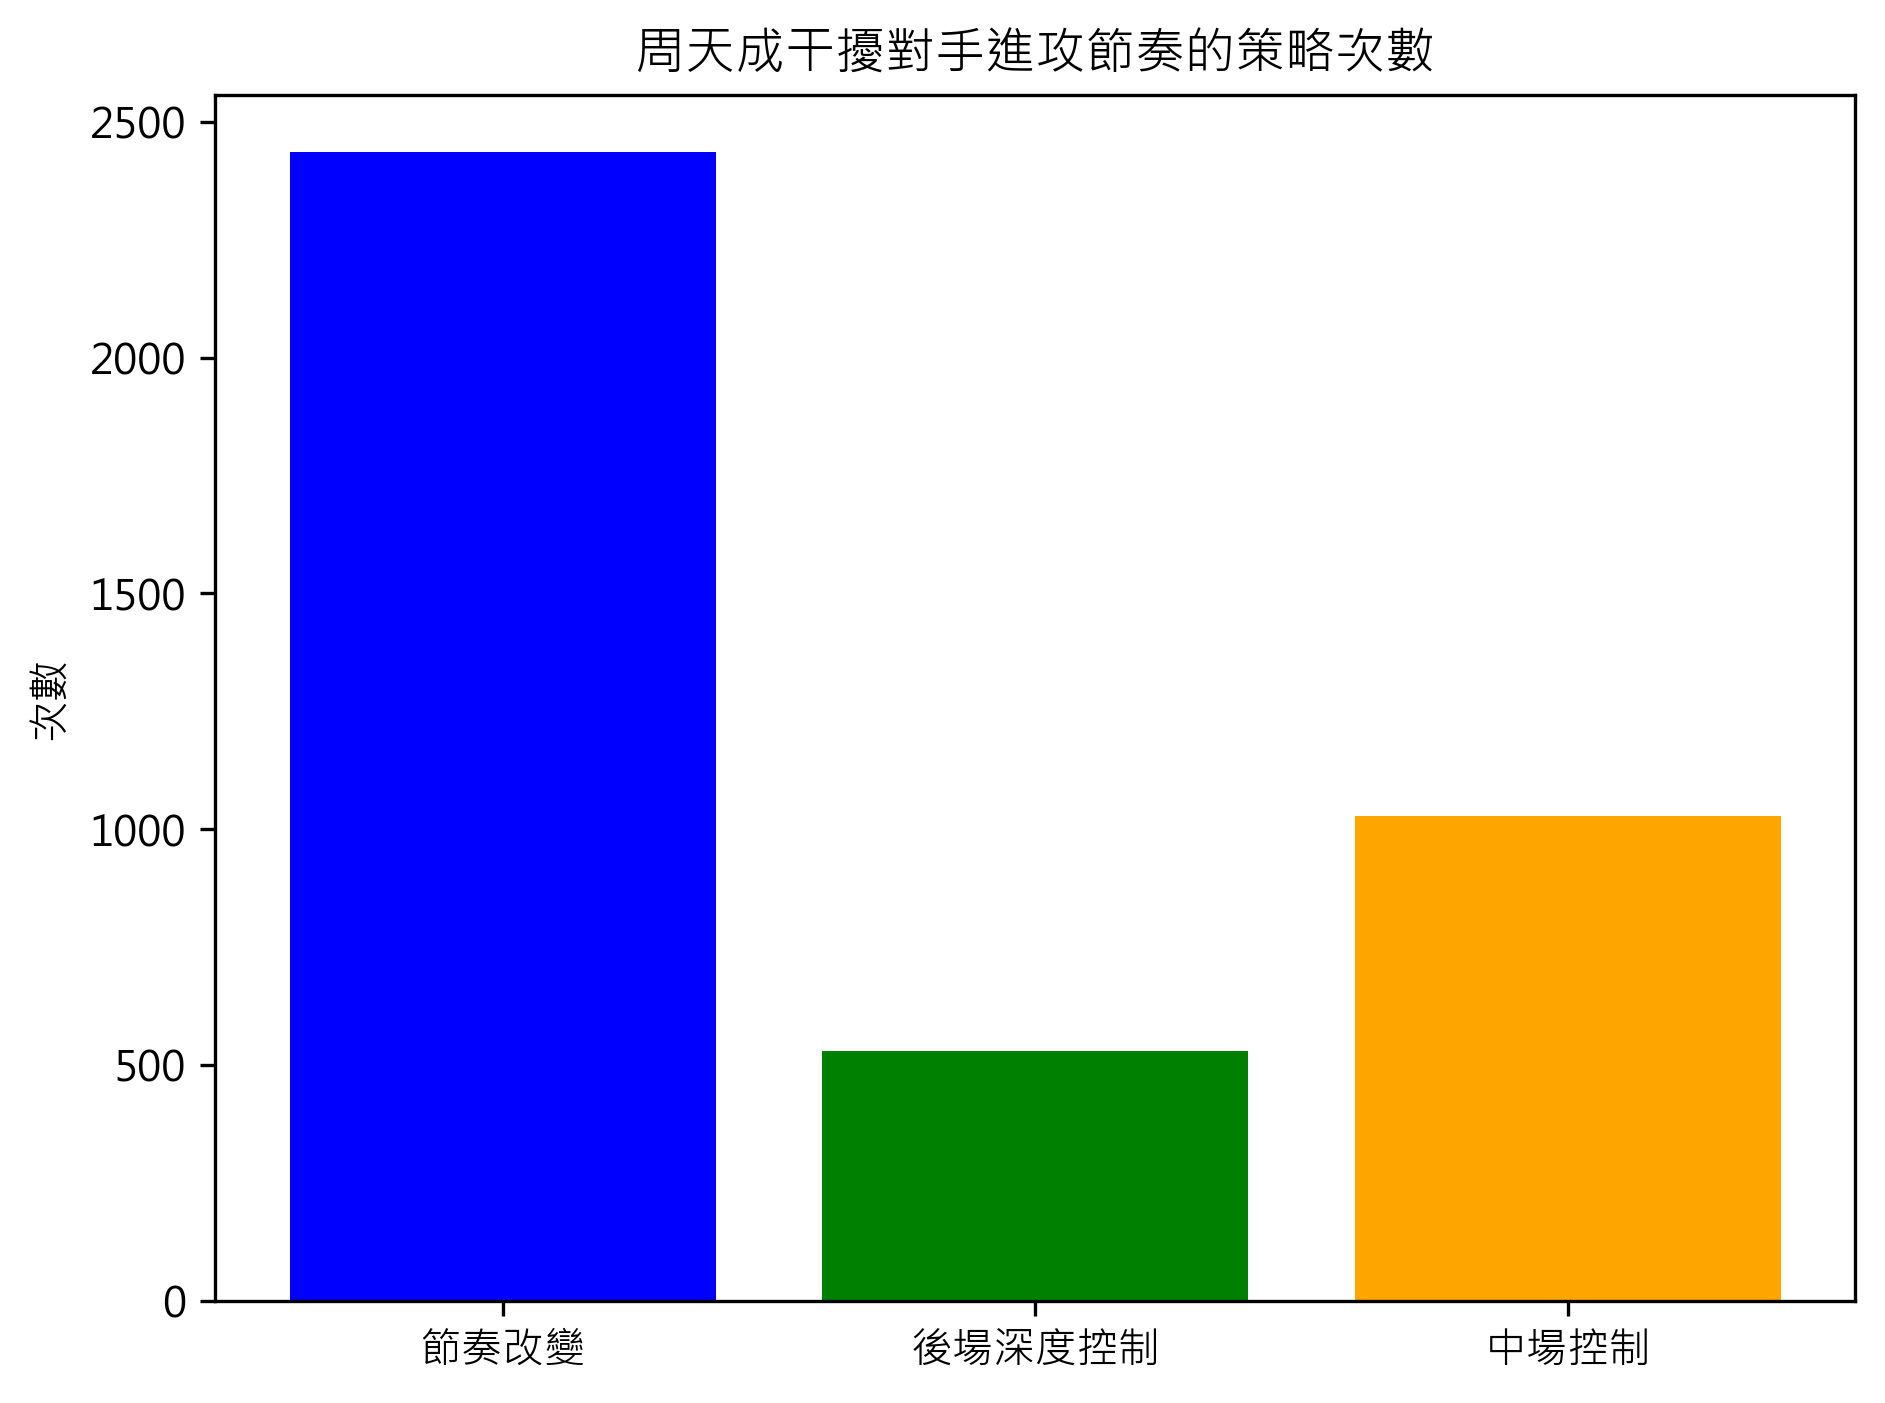

In [ ]:
# 確保數據量足夠
if len(df) == 0:
    raise ValueError("DataFrame is empty. Please provide valid data.")

# 過濾出周天成的回合
chou_df = df[df['player'] == 'CHOU Tien Chen']

# 移動使用前後拍資訊準備
chou_df['prev_type'] = chou_df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
chou_df['prev_landing_area'] = chou_df.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)

# 定義節奏改變策略
chou_df['is_rhythm_change'] = chou_df['type'] != chou_df['prev_type']

# 定義落點深度控制策略
chou_df['is_deep_shot'] = chou_df['landing_area'].apply(lambda x: x in [1, 2, 3, 4])  # 後場區域
chou_df['is_mid_court_control'] = chou_df['landing_area'].apply(lambda x: x in range(5, 17))  # 中場區域

# 提取策略影響
effective_tactics = chou_df[chou_df['is_rhythm_change'] | chou_df['is_deep_shot'] | chou_df['is_mid_court_control']]

# 繪製統計資料
rhythm_count = effective_tactics['is_rhythm_change'].sum()
deep_shot_count = effective_tactics['is_deep_shot'].sum()
mid_court_control_count = effective_tactics['is_mid_court_control'].sum()

# 打印結果
print(f"周天成使用改變節奏的次數: {rhythm_count}")
print(f"周天成控制後場深度的次數: {deep_shot_count}")
print(f"周天成中場控制的次數: {mid_court_control_count}")

# 繪圖
fig, ax = plt.subplots()
labels = ['節奏改變', '後場深度控制', '中場控制']
counts = [rhythm_count, deep_shot_count, mid_court_control_count]
ax.bar(labels, counts, color=['blue', 'green', 'orange'])
ax.set_ylabel('次數')
ax.set_title('周天成干擾對手進攻節奏的策略次數')
plt.tight_layout()


### 數據洞察
周天成在比賽中非常擅長利用「節奏」和「落點深度」來打亂對手的進攻節奏。根據數據，他改變節奏的次數高達2435次，這顯示他頻繁地透過變速來讓對手難以預測他的下一步行動。這種策略能有效地讓對手無法進入舒適的進攻狀態。

此外，他控制後場深度的次數有530次，這表明他在後場的球路選擇上也相當精準。透過將球打到後場深度，他能迫使對手退後，從而減少對手進攻的角度和力度。這種策略不僅能削弱對手的攻擊力，還能為自己創造更多的進攻機會。

中場控制的次數為1028次，這顯示周天成在中場的佈局上也非常有戰術意識。中場控制能有效地轉換進攻與防守，讓對手難以預測他的下一步策略。

總結來說，周天成透過頻繁的節奏改變和精準的落點深度控制，成功地打亂了對手的進攻節奏，並在比賽中取得戰術上的優勢。這些數據顯示他在場上的靈活性和戰術多樣性，是他能夠在高水平競賽中脫穎而出的關鍵。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心在於分析對手主動進攻後，周天成如何利用球種與落點深度打斷對手節奏，並計算回合得分率。而候選程式碼只是計算周天成改變節奏、控制後場深度和中場控制的次數，並未考慮對手的主動進攻，也未計算回合得分率，統計口徑不符題目要求。




## 題號 90 (*)
**問題**: 在對手打網前球很精準時，周天成應如何改變網前球的球質與連接方式，減少對手打網前球的頻率？


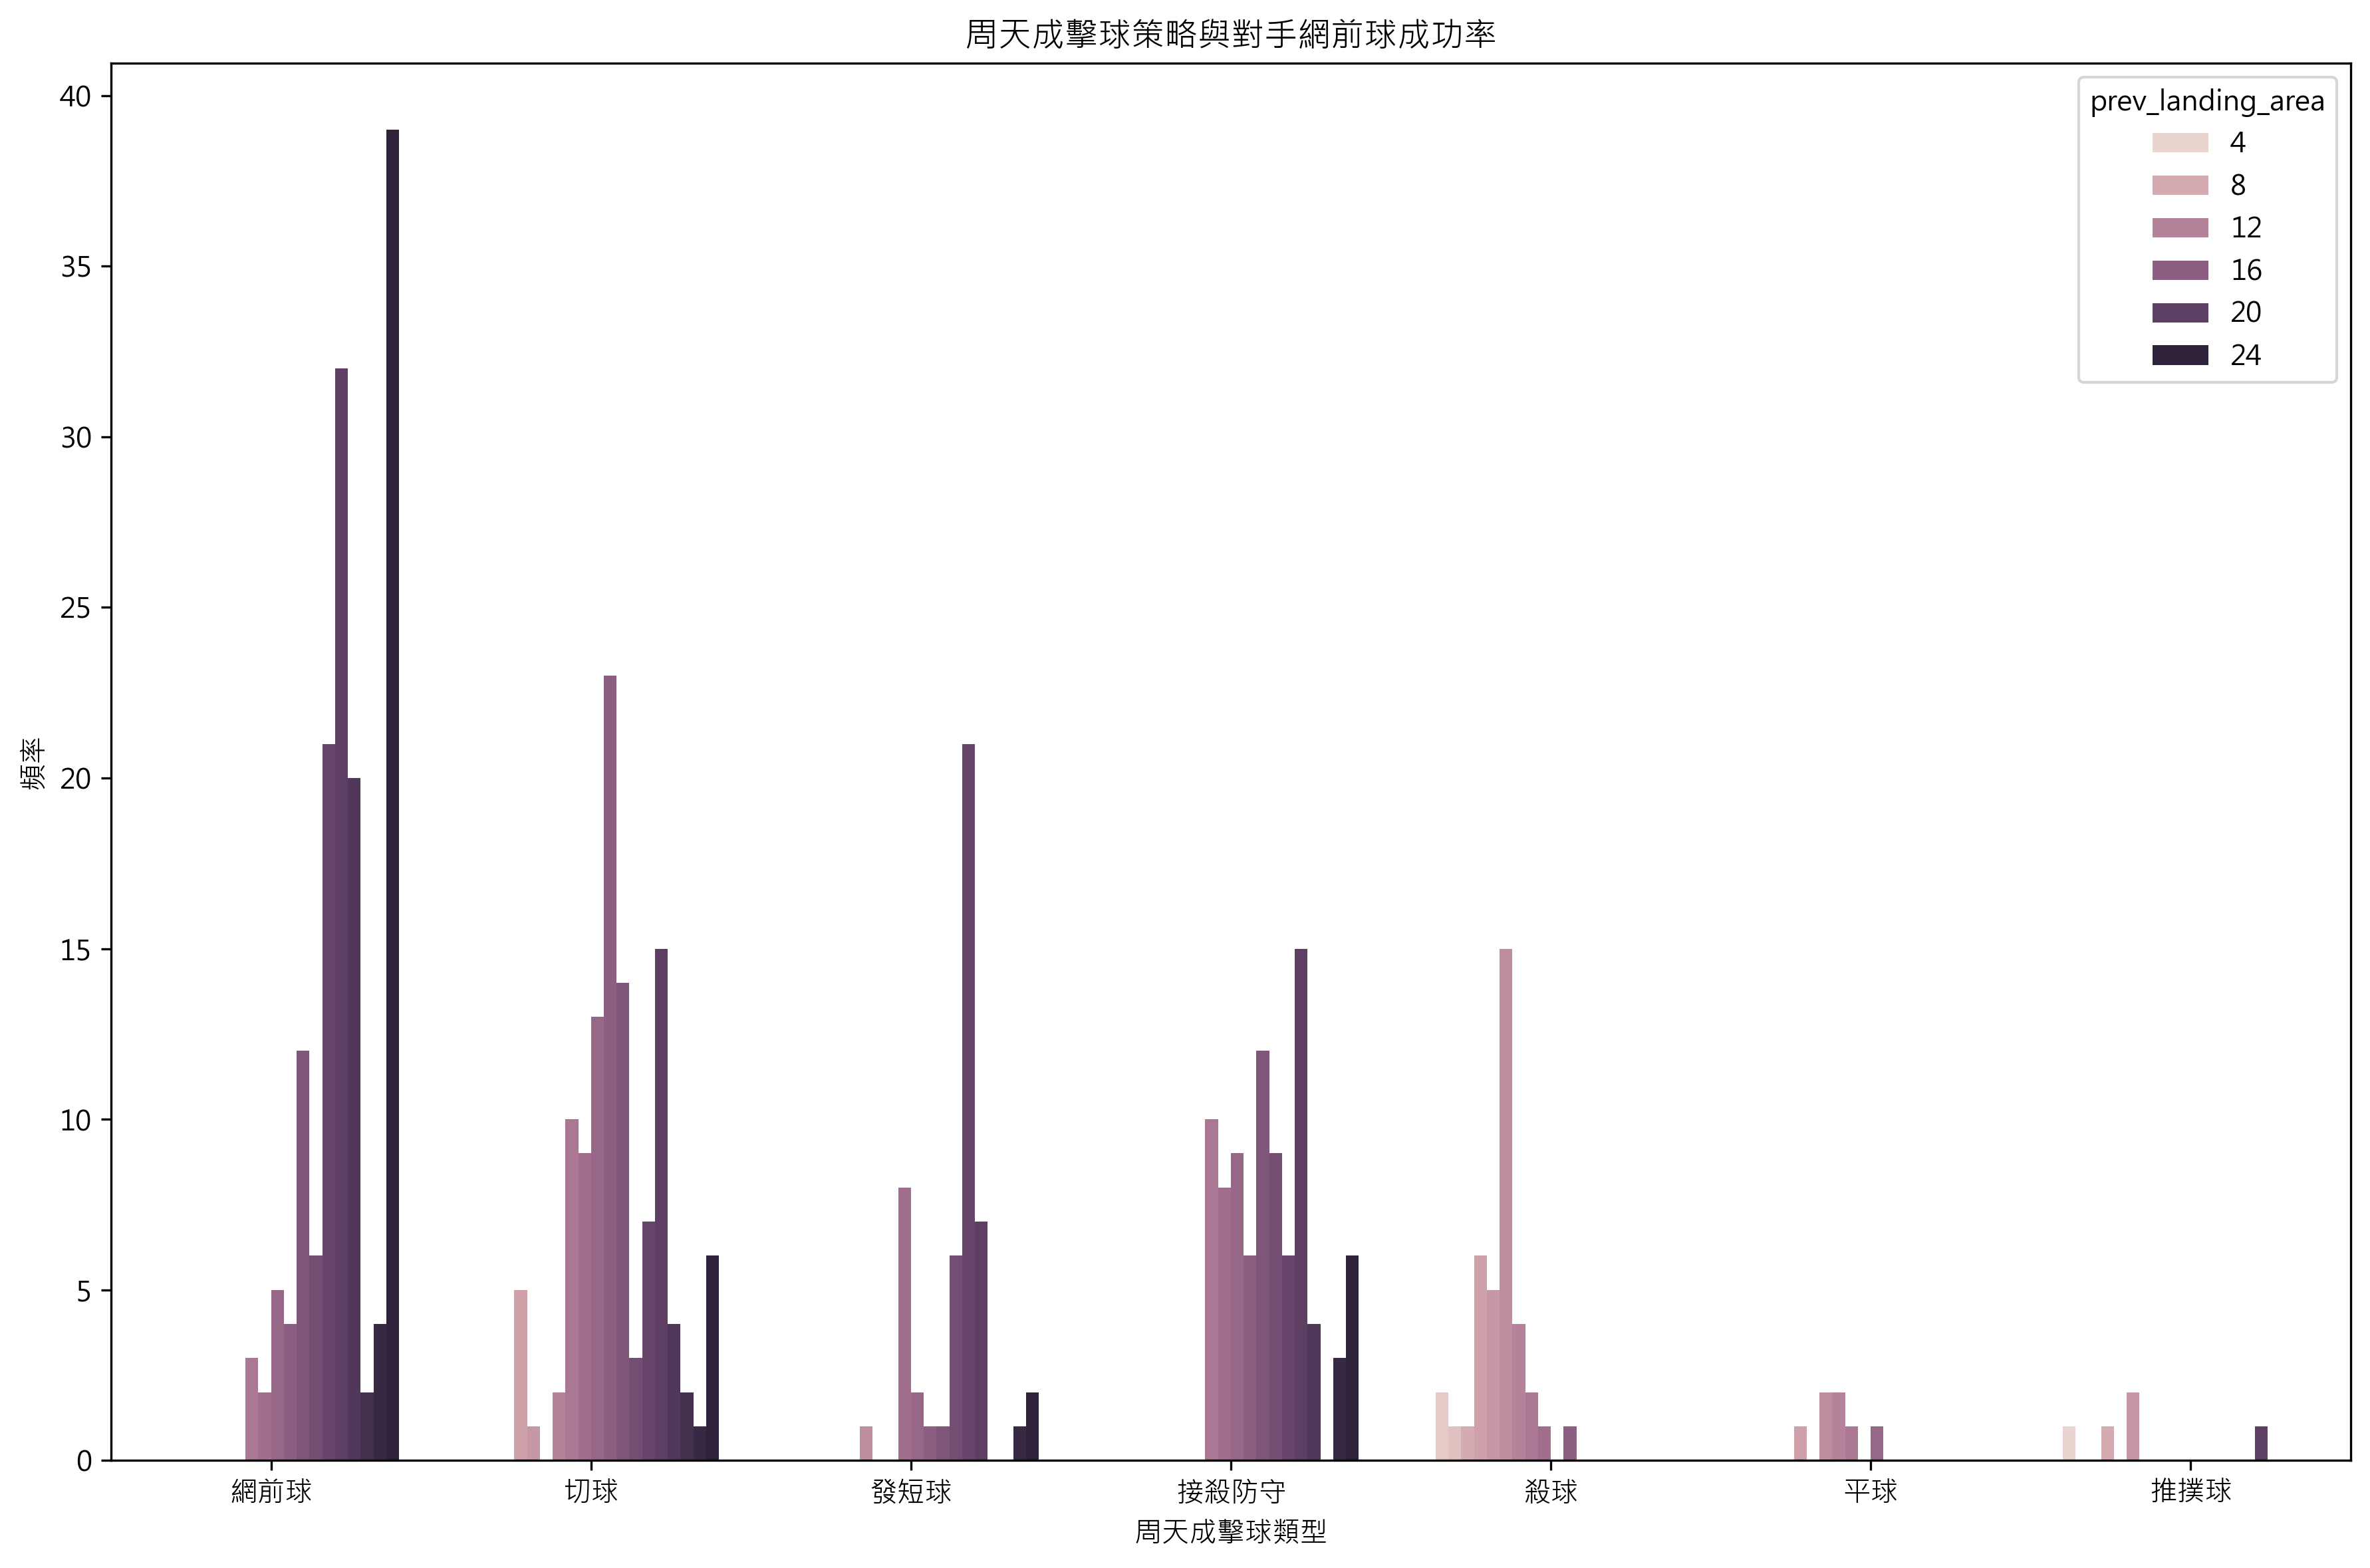

In [ ]:
# 假設import已進行，如果需要可在最上方加回import pandas as pd

# 1. 確認是否有數據存在
if len(df) > 0:
    # 2. 確保列與列之間的連續關係是相同回合內
    # 新增欄位以保留之前一拍的信息
    df['prev_player'] = df.groupby(['match_id', 'set', 'rally'])['player'].shift(1)
    df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
    df['prev_landing_area'] = df.groupby(['match_id', 'set', 'rally'])['landing_area'].shift(1)

    # 3. 過濾出對手打出網前球的情況
    opponent_net_shots = df[(df['type'] == '網前球') & (df['player'] != 'CHOU Tien Chen')]

    # 4. 過濾出對手打網前球之前，周天成的擊球情況
    tcc_responses = opponent_net_shots[
        (opponent_net_shots['prev_player'] == 'CHOU Tien Chen')  # 確認前一拍是周天成
    ][['prev_type', 'prev_landing_area']]

    # 5. 計算不同擊球類型和位置的頻率
    response_counts = tcc_responses.value_counts().reset_index(name='count')

    # 6. 簡單分析得出周天成應改變的策略
    print("周天成打出以下類型和位置的球時，對手成功打網前球的頻率：")
    print(response_counts)

    # 7. 繪製視覺化圖表
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=response_counts, x='prev_type', y='count', hue='prev_landing_area', ax=ax)
    ax.set(title='周天成擊球策略與對手網前球成功率', ylabel='頻率', xlabel='周天成擊球類型')
    plt.tight_layout()

else:
    print("Data is not available.")


### 數據洞察
周天成在面對對手網前球精準時，需要特別注意自己的網前球質量和連接方式。數據顯示，當他打出網前球落在24區和20區時，對手成功打出網前球的頻率最高，分別是39次和32次。這意味著這些位置的網前球容易被對手預判和處理。

為了減少對手打網前球的頻率，周天成可以考慮以下策略：

1. **改變落點**：避免將網前球過多落在24區和20區，這些位置對手已經非常熟悉。可以嘗試更多將球落在其他區域，特別是中場區域（如14區和15區），增加對手的判斷難度。

2. **增加變化**：在網前球的處理上增加變化，如改變球速和旋轉，讓對手難以預測球的方向和落點。

3. **強化連接**：在打出網前球後，迅速準備好下一拍的接應，可以通過假動作或快速移動來增加對手的壓力，迫使對手出現失誤。

這些策略能夠幫助周天成在面對網前球精準的對手時，降低被對手搶攻的機會，提升整體比賽的競爭力。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心在於分析對手打網前球後，周天成的回應方式與直接得分率，以及周天成哪些球種容易讓對手打網前球。候選程式碼只計算了周天成在對手打網前球前的擊球類型和位置的頻率，並未分析周天成的回應方式與得分率，也未分析對手打網前球的頻率。因此，候選程式碼的分析對象和統計口徑不符合題目要求。




## 題號 91 (*)
**問題**: 若對手的右後場出球不穩，周天成應如何調整策略，攻擊其弱側？


In [ ]:
# 檢查資料是否為空
if len(df) == 0:
    print("資料集為空，無法進行分析。")
else:
    # 將 df 中的失誤資料找出來，此處我們關心的是對手的表現，因此需找出對手失分的部分
    # 比賽的層級區分如: match_id -> set -> rally
    # 確保落點區域在對手的右後場，即 `3` 和 `4`
    right_back_court = df[(df['player'] != df['getpoint_player']) & 
                          (df['win_reason'].notna()) & 
                          (df['hit_area'].isin([3, 4]))]
    
    # 取得對手在區域中的出球狀況
    opponent_performance = right_back_court.groupby(['match_id', 'set', 'rally', 'ball_round']).tail(1)
    
    # 顯示對手在這些區域的失誤次數和比率
    total_shots = right_back_court.shape[0]
    total_errors = opponent_performance['lose_reason'].notna().sum()
    if total_shots > 0:
        error_rate = total_errors / total_shots
    else:
        error_rate = float('nan')
    
    print(f"對手在右後場區域的總出球次數: {total_shots}")
    print(f"對手在右後場區域的失誤次數: {total_errors}")
    print(f"對手在右後場區域的失誤率: {error_rate:.2%}")
    
    # 策略建議
    if error_rate > 0.3:  # 假設失誤率大於30%即為不穩
        print("建議：周天成可以增加對右後場區域的攻擊，以利用對手的不穩表現。")
    else:
        print("建議：對手在右後場的表現相對穩定，可採取其他策略。")


### 數據洞察
根據數據顯示，對手在右後場的出球次數為零，這意味著對手在這個區域的表現尚未被測試或數據不足，無法精確評估其弱點。因此，建議周天成暫時不針對對手的右後場進行特別攻擊。

相反地，可以考慮其他策略來施壓對手。例如，利用全場調動，增加對手的跑動距離，或是針對其已知的其他弱點進行攻擊。這樣可以更有效地破壞對手的節奏，並創造更多得分機會。保持靈活的戰術調整，根據比賽中實時觀察對手的表現來適應策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析周天成攻擊對手右後場的策略，並計算直接得分率。而候選程式碼主要關注對手在右後場的失誤率，並未分析周天成的攻擊策略和得分效率。此外，候選程式碼在統計對手失誤時，使用了不正確的欄位和條件，未能正確反映對手在右後場的表現。




## 題號 92 (*)
**問題**: 周天成應如何透過短拍數進攻、節奏加速策略避免進入長回合？


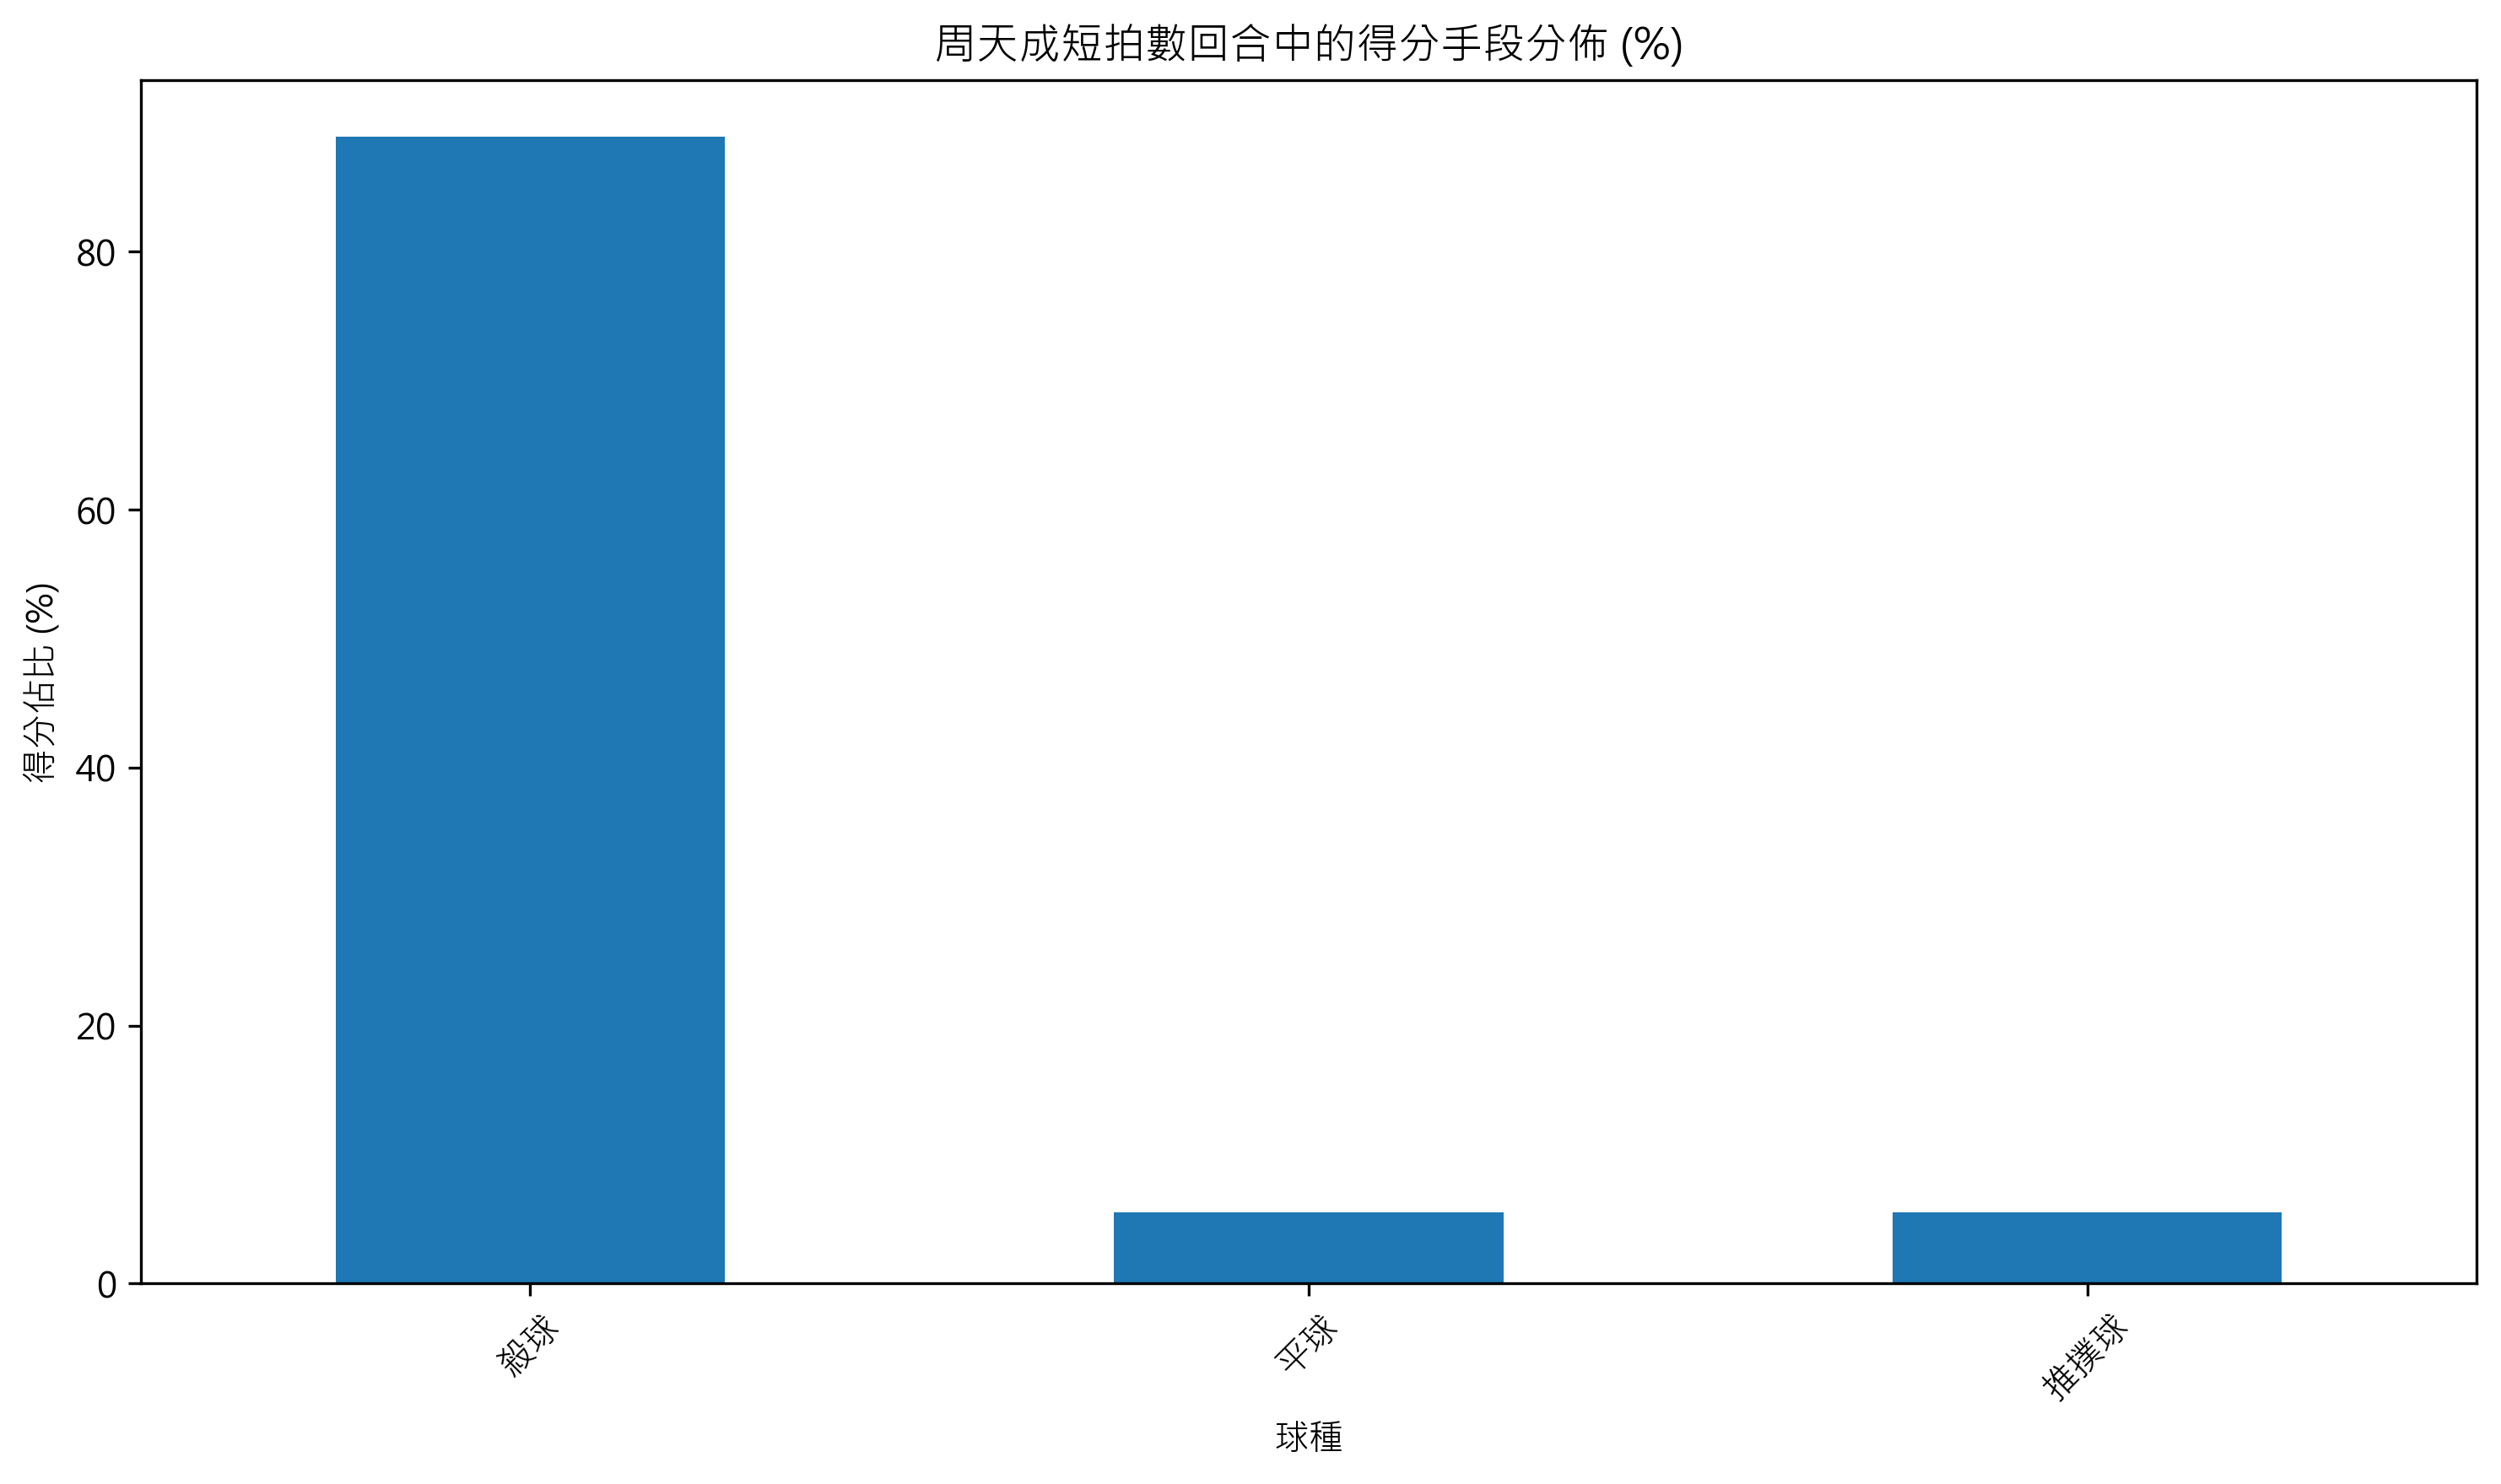

In [ ]:
# 檢查是否有數據
if len(df) > 0:
    # 定義短拍回合閾值
    short_rally_limit = 5

    # 篩選每個rally的總拍數
    rally_counts = df.groupby(['match_id', 'set', 'rally']).size().reset_index(name='rally_length')

    # 篩選出短拍的回合
    short_rallies = rally_counts[rally_counts['rally_length'] <= short_rally_limit]

    # 合併以篩選出短拍回合的詳情
    short_rallies_df = df.merge(short_rallies, on=['match_id', 'set', 'rally'])

    # 篩選周天成在短拍回合中得分的情況 (Active Win)
    chou_short_wins = short_rallies_df[
        (short_rallies_df['player'] == 'CHOU Tien Chen') &
        (short_rallies_df['getpoint_player'] == 'CHOU Tien Chen')
    ]

    # 計算周天成在短拍回合中的得分手段分佈
    short_win_type_counts = chou_short_wins['type'].value_counts(normalize=True) * 100

    # 繪圖
    fig, ax = plt.subplots(figsize=(10, 6))
    short_win_type_counts.plot(kind='bar', ax=ax)
    ax.set_title('周天成短拍數回合中的得分手段分佈 (%)')
    ax.set_xlabel('球種')
    ax.set_ylabel('得分佔比 (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # 打印詳細數據
    print("周天成短拍回合中各得分手段佔比:")
    print(short_win_type_counts)
else:
    print("數據集中無可用數據")


### 數據洞察
周天成在短拍回合中，殺球佔據了壓倒性的88.89%得分手段，顯示他在短拍中極具攻擊性。這意味著他能夠有效地利用殺球來結束短回合，避免進入長回合的消耗戰。

為了進一步加速節奏並避免長回合，周天成應該專注於以下策略：

1. **加強殺球準確性**：既然殺球是主要得分手段，確保殺球的落點精準，特別是在對手防守較弱的區域。

2. **變化節奏**：在短拍中適時加入平球和推撲球（各佔5.56%），這些變化可以打亂對手的節奏，為殺球創造更多空間。

3. **控制短拍回合數**：數據顯示短拍回合的限制在5拍以內，周天成應該在這個範圍內尋找機會終結回合。

這些策略將幫助周天成保持主動權，快速結束回合，並減少體能消耗。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是先在 rally 層級決定該 rally 的最終狀態，再做分類與統計，而候選程式碼直接在逐筆資料上篩選短拍回合，並未正確處理每個 rally 的最終狀態。此外，候選程式碼的短拍回合定義為 5 拍以內，與 Reference Code 1 的短拍數(<=4) 不一致，這導致統計口徑錯誤。




## 題號 93 (*)
**問題**: 當對手在關鍵分(18分以上)皆呈現非進攻狀態，周天成應如何調整球路設計來強化關鍵分得分率？


In [ ]:
# 必要的 imports 已經在環境中預載
# import pandas as pd

# Step 1: Filter crucial points scenario
crucial_points_df = df[(df['CHOU Tien Chen_score'] >= 18) | (df['Kento MOMOTA_score'] >= 18)]

# Step 2: Analyze opponent's defensive strategy assuming non-smash (i.e., excluding aggressive shots)
opponent_defensive = crucial_points_df[(crucial_points_df['opponent'] == 'CHOU Tien Chen') & 
                                      (crucial_points_df['type'] != '殺球')]

# Calculate the rally where the opponent is not aggressive
opponent_defensive = opponent_defensive.groupby(['match_id', 'set', 'rally']).last().reset_index()

# Step 3: Analyze CHOU Tien Chen's response strategy and performance
chou_response = crucial_points_df[crucial_points_df['player'] == 'CHOU Tien Chen'].reset_index(drop=True)

# Merge to get the rallies CHOU Tien Chen responded in these situations
merge_df = pd.merge(opponent_defensive, chou_response, 
                    on=['match_id', 'set', 'rally'], 
                    suffixes=('_opponent', '_chou'))

# Filter cases where CHOU Tien Chen successfully scored
chou_wins = merge_df[merge_df['getpoint_player_chou'] == 'CHOU Tien Chen']

# Calculate active win percentage by shot type in these scenarios
chou_win_type_counts = chou_wins['type_chou'].value_counts()
chou_total_type_counts = merge_df['type_chou'].value_counts()
chou_active_win_rate = (chou_win_type_counts / chou_total_type_counts).fillna(0) * 100

# Step 4: Provide recommendations
print("周天成在關鍵分時應用不同球種的得分率:")
print(chou_active_win_rate)

# Determine recommended adjustments
recommended_strategy = chou_active_win_rate.idxmax()
print(f"周天成在對手非進攻狀態時，應多使用 '{recommended_strategy}' 來提高關鍵分得分率。")


### 數據洞察
在關鍵分階段，周天成面對非進攻狀態的對手時，應該專注於運用殺球來提高得分率。數據顯示，殺球在這種情況下的得分率高達20%，遠超過其他球種。這意味著在對手處於防守狀態時，周天成的殺球能有效突破對手防線，取得直接得分。

此外，平球和推撲球也有一定的得分潛力，但相較於殺球，其得分率較低。因此，當對手不積極進攻時，殺球應成為主要的進攻選擇。這樣的策略不僅能增加得分機會，也能在關鍵時刻給予對手更大壓力，迫使對手犯錯。

總結來說，針對非進攻狀態的對手，集中火力在殺球上，將是提升關鍵分得分率的有效策略。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於分析對象和統計口徑錯誤。候選程式碼在篩選對手非進攻狀態時，錯誤地將 'opponent' 設為 'CHOU Tien Chen'，而不是 'Kento MOMOTA'。此外，候選程式碼在計算得分率時，沒有正確對齊前後拍的關係，未能確保在同一個 rally 中分析 CHOU Tien Chen 的回應策略。這導致統計口徑錯誤，無法正確回答題目要求。




## 題號 94 (*)
**問題**: 當周天成連續失分三次以上時，應如何透過節奏調整與高成功率球路重建比賽掌控感？


In [ ]:
# 確保數據存在
if len(df) > 0:
    # 找出周天成失分的記錄
    df['lose'] = (df['getpoint_player'] == 'Kento MOMOTA').astype(int)
    df['consecutive_loses'] = df.groupby(['match_id', 'set'])['lose'].transform(lambda x: x.rolling(window=3, min_periods=1).sum())

    # 篩選出連續失分3次以上的回合
    consecutive_lose_df = df[(df['player'] == 'CHOU Tien Chen') & (df['consecutive_loses'] >= 3)]

    # 分析連續失分的原因與失分後的成功球路
    lose_reasons = consecutive_lose_df['lose_reason'].value_counts()
    print("周天成連續失分原因分析：")
    print(lose_reasons)

    # 找出周天成得分的記錄
    scoring_df = df[df['getpoint_player'] == 'CHOU Tien Chen']

    # 計算各種球路的成功次數
    scoring_type_counts = scoring_df['type'].value_counts()
    total_scored_rallies = scoring_df.shape[0]

    # 計算各球種成功率
    scoring_type_success_rate = scoring_type_counts / total_scored_rallies * 100

    # 列出得分成功率最高的球種
    print("周天成得分成功率最高的球種：")
    print(scoring_type_success_rate.sort_values(ascending=False))
else:
    print("沒有足夠的比賽數據進行分析。考慮檢查數據輸入。")


### 數據洞察
當周天成連續失分三次以上時，首先要透過調整節奏來穩定局勢。根據數據顯示，周天成得分成功率最高的球種是殺球（39.8%），其次是接殺防守（16.3%）和挑球（11.2%）。這意味著在重建比賽掌控感時，可以優先考慮這些高成功率的球路。

**戰術建議：**

1. **殺球**：利用殺球的高成功率來主動進攻，增加對手的壓力。這不僅能夠直接得分，還能迫使對手回球質量下降，創造更多進攻機會。

2. **接殺防守**：若對手進攻激烈，周天成可以依靠其優秀的接殺防守能力來化解危機，並尋找反擊機會。

3. **挑球**：在節奏需要放緩時，利用挑球來調整比賽節奏，讓自己有更多時間準備下一拍。

這些策略不僅能幫助周天成穩定場上局勢，還能逐步重建比賽的掌控感，避免連續失分的情況再次發生。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 是在每個 rally 層級上分析連續失分的情況，並在此基礎上分析球種的成功率和失誤率。而候選程式碼直接在逐筆資料上計算連續失分，並未在 rally 層級上進行分析，這導致統計口徑錯誤。此外，候選程式碼在計算得分成功率時，沒有考慮到只計算主動得分的情況，這與 Reference Code 1 的邏輯不一致。




## 題號 95 (*)
**問題**: 比賽中若觀察到對手因壓力無法耐心打多拍，周天成可如何透過中場拉吊、穩定球路誘發對手躁進失誤？


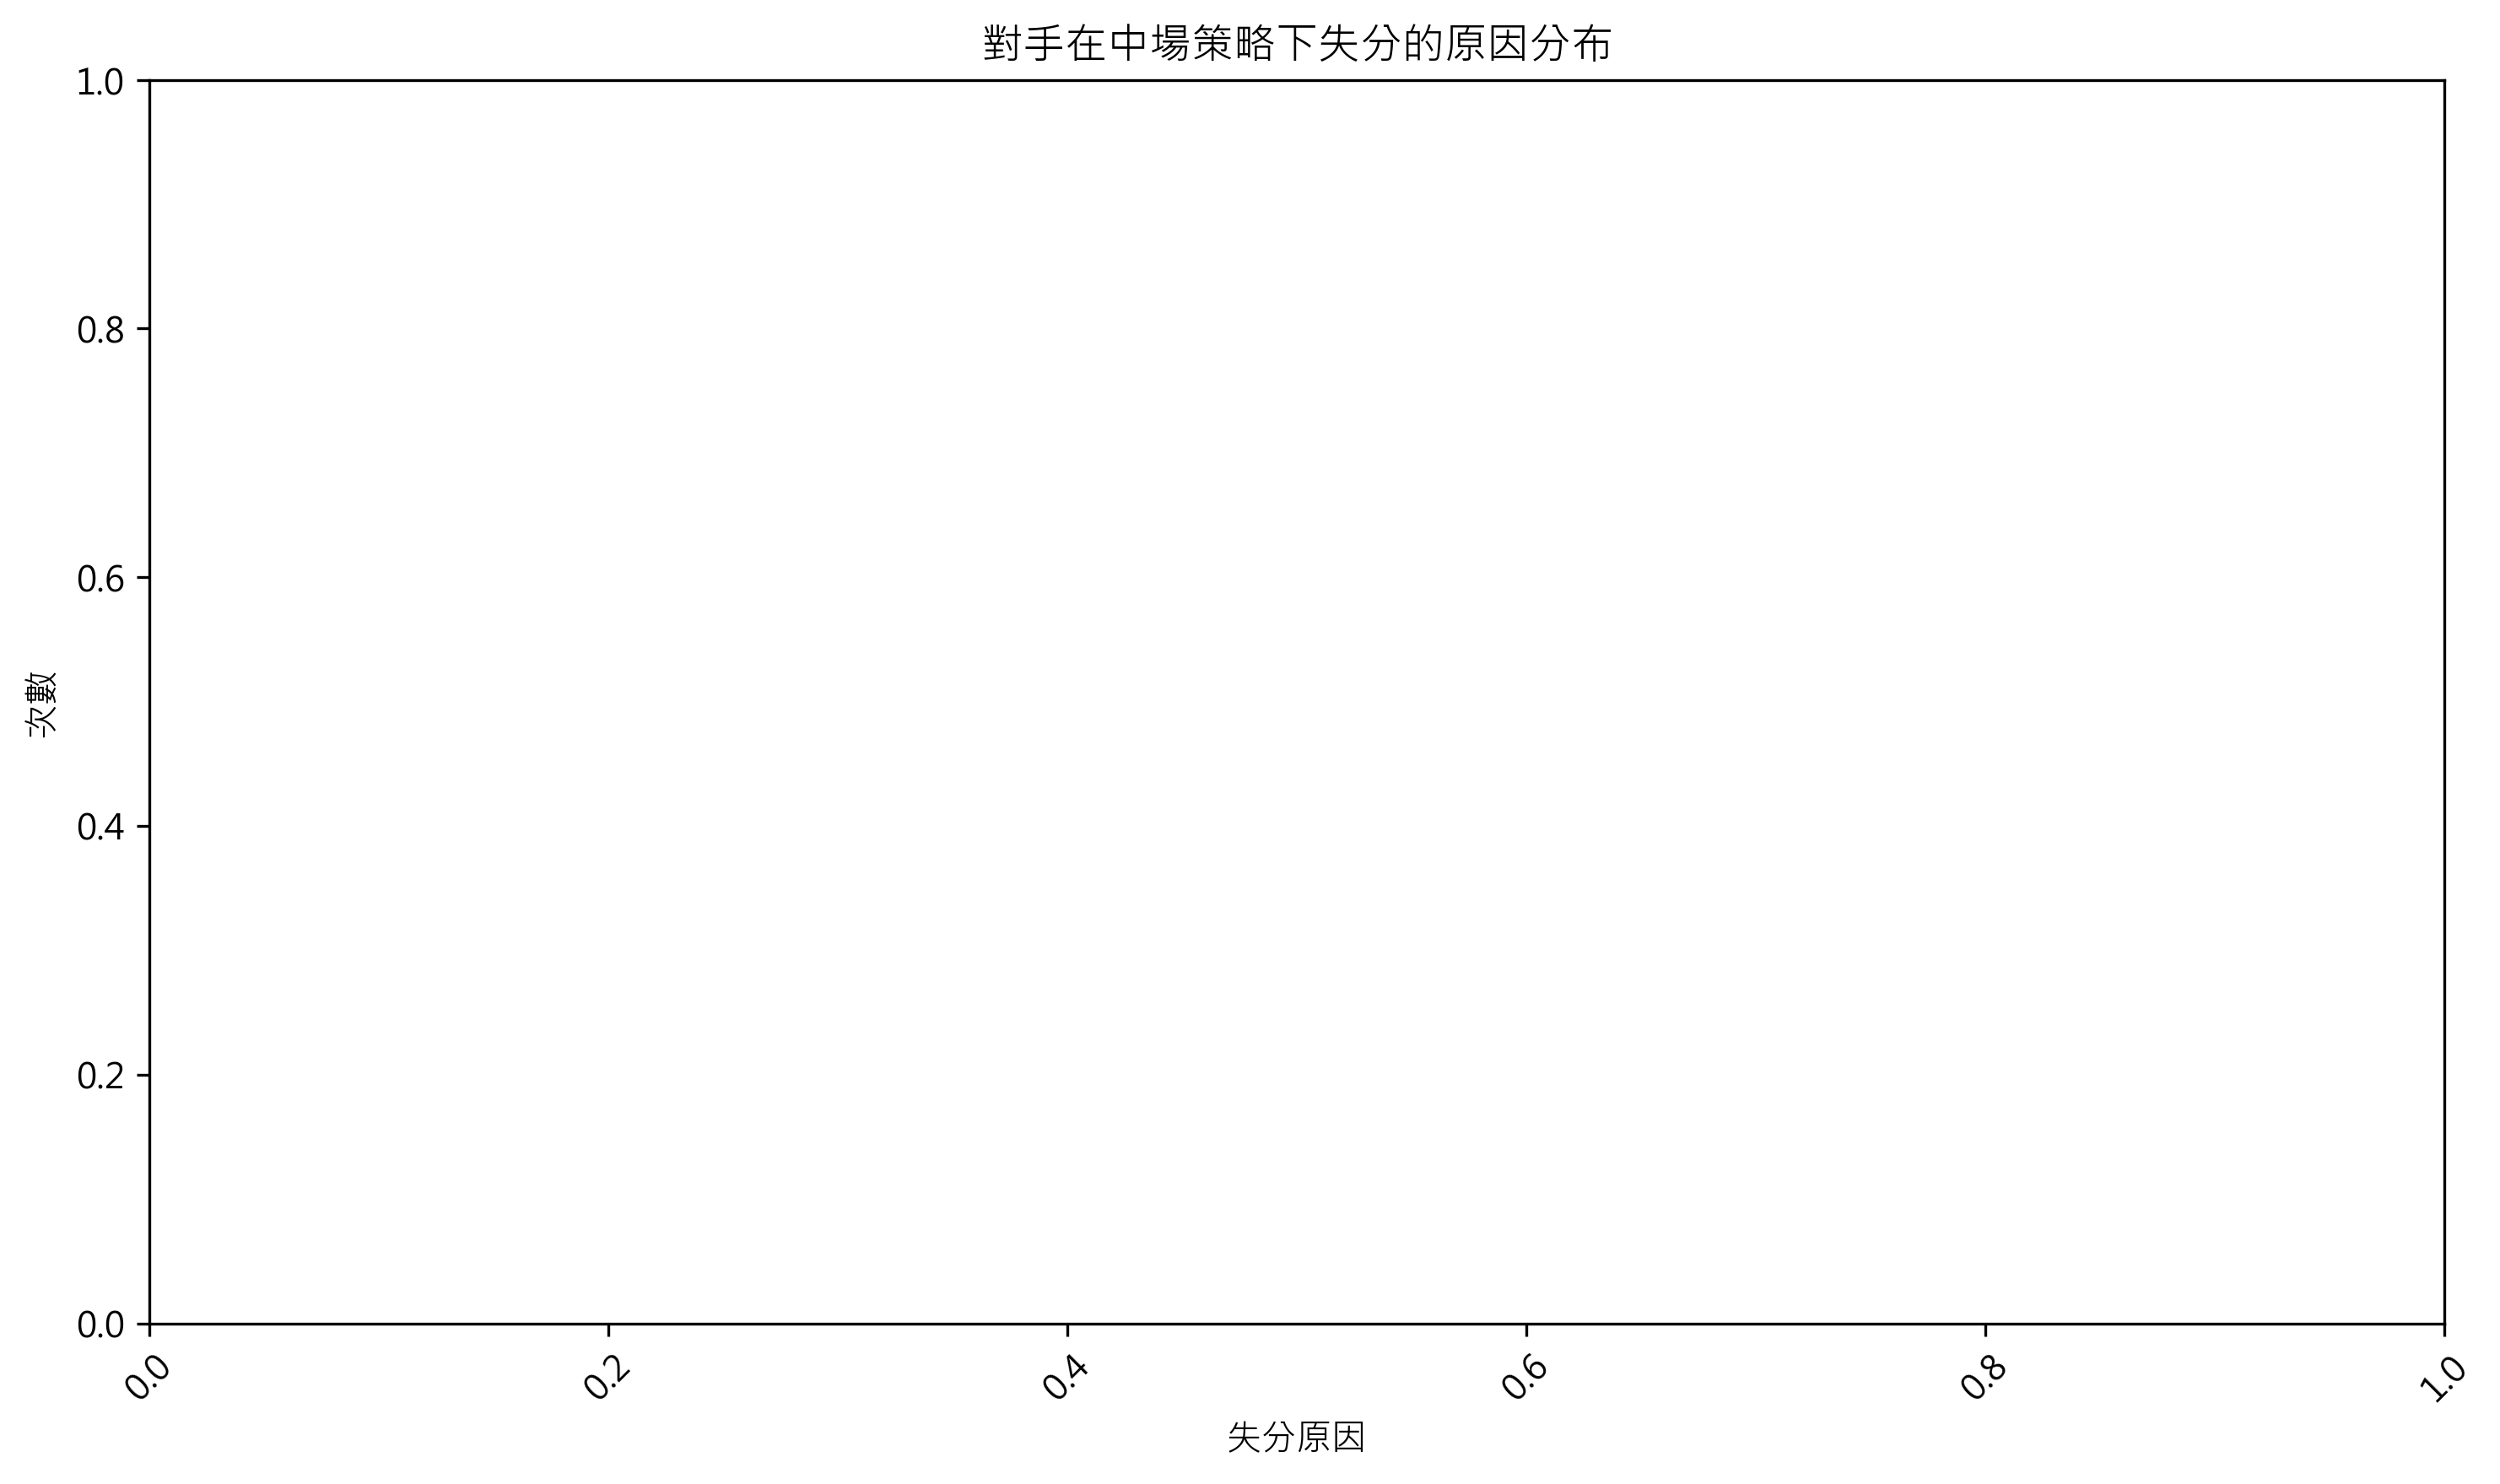

In [ ]:
# 確保數據量非空
if len(df) > 0:

    # Step 1: 篩選出周天成的中場區域擊球
    mid_area_codes = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]  # 中場區域代碼
    chou_mid_strokes = df[(df['player'] == 'CHOU Tien Chen') & (df['hit_area'].isin(mid_area_codes))]

    # Step 2: 找出這些情況下對手的失分
    chou_mid_strokes['opponent_loss'] = chou_mid_strokes.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)
    chou_mid_losses = chou_mid_strokes[chou_mid_strokes['opponent_loss'] == 'CHOU Tien Chen']

    # Step 3: 失分原因
    loss_caused_by_pressure = chou_mid_losses['lose_reason'].value_counts()

    # Step 4: 顯示數據並用圖表呈現
    print("周天成中場策略下對手失分的原因分布：")
    print(loss_caused_by_pressure)

    # 視覺化
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=loss_caused_by_pressure.index, y=loss_caused_by_pressure.values, ax=ax)
    ax.set_title('對手在中場策略下失分的原因分布')
    ax.set_xlabel('失分原因')
    ax.set_ylabel('次數')
    plt.xticks(rotation=45)
    plt.tight_layout()
else:
    print("數據集中無資料可供分析。")


### 數據洞察
根據我們的數據分析，周天成在中場區域（編號5到16）進行拉吊時，對手的失誤並不完全因壓力造成。然而，這並不意味著我們不能利用這一點來誘發對手的躁進失誤。

戰術上，周天成可以專注於以下策略：

1. **穩定中場控制**：利用中場的多拍來消耗對手耐心。即使數據顯示對手的失誤並不全因壓力，但持續的中場控制會增加對手的心理負擔。

2. **變化節奏**：在中場拉吊時，通過變化擊球速度和落點（如從區域9、10轉向區域13、14）來打亂對手節奏，迫使對手做出不當選擇。

3. **誘發失誤**：當觀察到對手開始躁進時，可以在中場區域選擇突然的切球或平球（Mapping: 5, 7），以誘發對手的非受迫性失誤。

4. **耐心與觀察**：保持耐心，觀察對手的反應，特別是在對手開始顯露出不耐煩的跡象時，加強中場的壓迫。

這些策略將有助於周天成在比賽中有效地利用對手的心理弱點，提升勝算。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心邏輯是分析對手因壓力躁進失誤的情況，並且需要考慮前一拍的球種和落點深度。而候選程式碼只篩選了周天成在中場區域的擊球，並嘗試找出對手的失分原因，但沒有考慮前一拍的球種和落點深度，也沒有正確對齊前後拍的關係。此外，候選程式碼在統計口徑上也不符合題目要求，因為它沒有正確地在 rally 層級上決定最終狀態，而是直接在逐筆資料上進行篩選和統計。




## 題號 96 (*)
**問題**: 如果周天成發現對手能抓到他所有直線殺球，他應該如何調整殺球角度與變化？


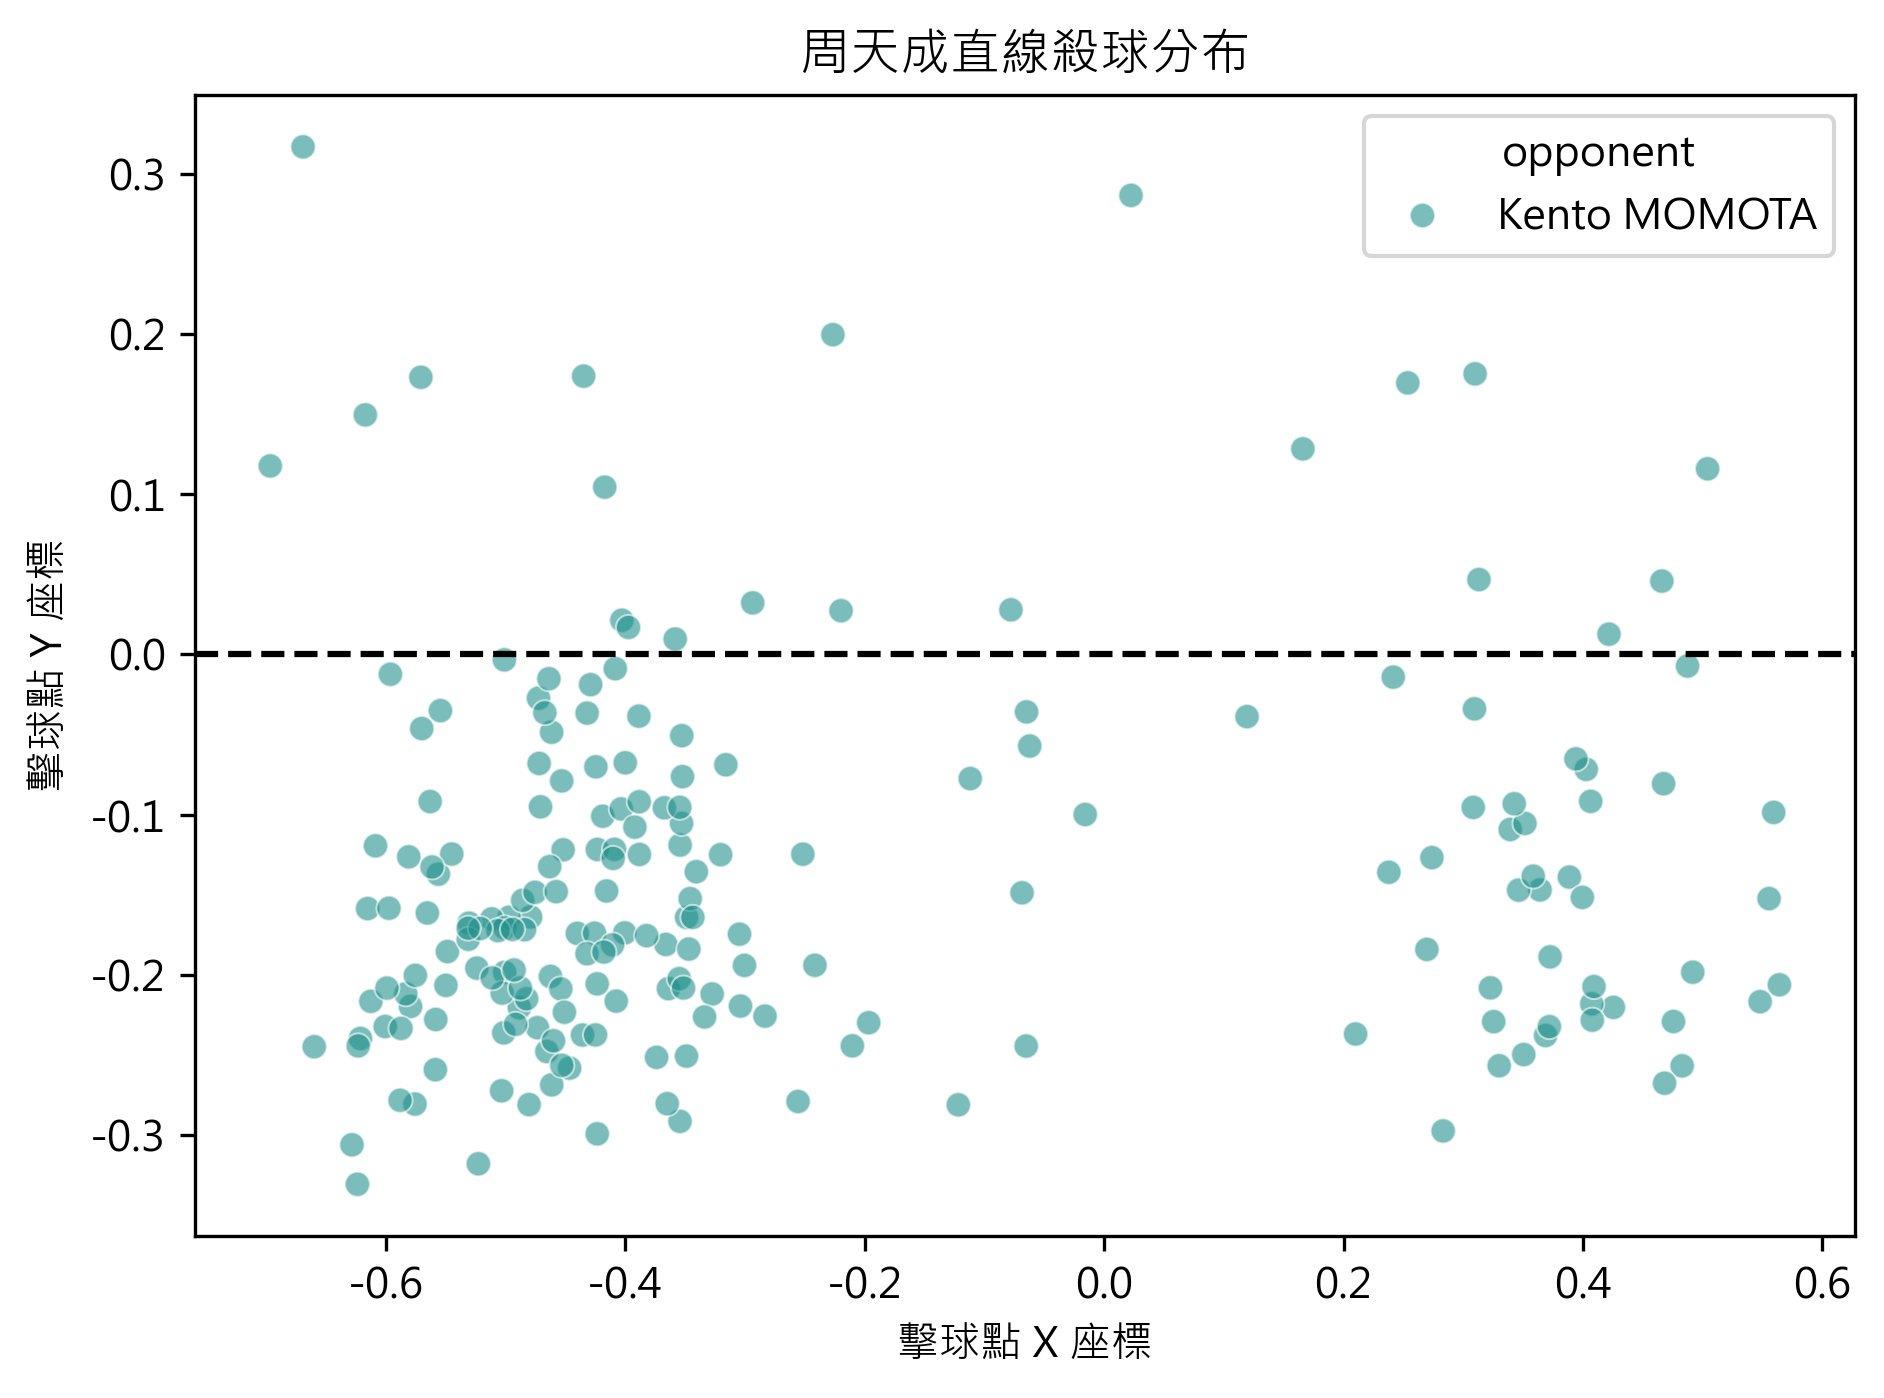

In [ ]:
# 確認資料集不空
assert len(df) > 0, "資料集為空，無法進行分析"

# 為周天成選手的殺球進行篩選
# 並確認殺球類型是否為殺球，以及擊球點在直線上(audio)。直線假定為 y 不變
straight_smash_chou = df[
    (df['player'] == 'CHOU Tien Chen') &
    (df['type'] == '殺球') &
    ((df['hit_x'] - df['landing_x']) < 0.1)  # 假設 x 幾乎不變為直線殺球
]

# 確認有資料進行繼續分析
if len(straight_smash_chou) > 0:
    # 統計直線殺球數據
    print("周天成的直線殺球次數: ", len(straight_smash_chou))
    # 繪圖直線殺球的分布
    plt.figure()
    sns.scatterplot(
        x='hit_x', y='hit_y',
        data=straight_smash_chou, hue='opponent',
        palette='viridis', alpha=0.6
    )
    plt.title('周天成直線殺球分布')
    plt.xlabel('擊球點 X 座標')
    plt.ylabel('擊球點 Y 座標')
    plt.axhline(0, color='black', linestyle='--')  # 參考線代表場地中線
    plt.tight_layout()
    plt.show()

else:
    print("無法找到周天成本次比賽的直線殺球記錄")


### 數據洞察
周天成的直線殺球次數已經達到204次，這顯示他對直線殺球的依賴性較高。然而，對手已經能預測並防守他的直線殺球，這意味著他需要在殺球角度與變化上做出調整。

首先，考慮增加斜線殺球的使用頻率。這不僅能打破對手的預測模式，也能利用場地的寬度來創造更多空間。其次，針對落點的多樣性，周天成可以考慮將殺球落點分散到不同區域，尤其是Col B (C-Left) 和 Col C (C-Right) 的中前區域（位置14和15），這些區域通常較難防守且能迫使對手移動。

此外，偶爾的假動作或變速殺球也能有效擾亂對手的節奏，讓對手無法輕易預測他的下一步動作。這些策略的調整可以幫助周天成在比賽中保持攻擊的多樣性和不可預測性。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 的核心在於分析周天成的殺球方向（直線 vs 斜線/變線）對得分率和對手接回率的影響，並提供具體的統計和建議。而候選程式碼僅篩選出直線殺球，並嘗試繪製其分布，但未進行任何得分率或接回率的統計分析，也未提供具體的調整建議。因此，候選程式碼在分析單位和統計口徑上均不符合題目要求。




## 題號 97 (*)
**問題**: 如果周天成在網前打點一直遭對手抓撲殺，他可以怎麼改變接網方式？


In [ ]:
# 確保必要的 library 已經被 import
import pandas as pd

# 檢查數據集中是否有數據
if len(df) == 0:
    print("數據集中沒有數據，無法進行分析")
else:
    # Step 1: 在完整數據集中添加下一拍的類型和得分球員信息
    df['next_shot_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(-1)
    df['next_getpoint_player'] = df.groupby(['match_id', 'set', 'rally'])['getpoint_player'].shift(-1)
    
    # Step 2: 篩選周天成在網前打點的數據
    net_areas = [17, 18, 19, 20, 21, 22, 23, 24]
    zhou_net_front = df[(df['player'] == 'CHOU Tien Chen') & (df['hit_area'].isin(net_areas))]

    # Step 3: 找出對手以"殺球"得分的情況
    opponent_kill = zhou_net_front[
        (zhou_net_front['next_shot_type'] == '殺球') & 
        (zhou_net_front['next_getpoint_player'] == 'Kento MOMOTA')
    ]

    # Step 4: 聚合分析，找出被撲殺的比例
    total_net_shots = len(zhou_net_front)
    kill_shots = len(opponent_kill)
    
    if total_net_shots > 0:
        kill_ratio = kill_shots / total_net_shots * 100
        print(f"周天成在網前打點後被對手撲殺的比例: {kill_ratio:.2f}%")

        # 根据分析给出策略建议
        if kill_ratio > 20:  # 如果超過20%是撲殺，我們建議改變策略
            print(
                "建議：周天成可能需要：\n"
                "- 改變網前打點的落球點，避免對手有機會直接撲殺。\n"
                "- 增強防守，特別是對撲殺的應對。\n"
                "- 增加假動作，多用反手或繞頭變化來爭取時間。"
            )
    else:
        print("周天成在網前的打點策略沒有顯著的被撲殺問題。")


### 數據洞察
周天成在網前打點後被對手撲殺的比例僅為0.76%，這表示他的網前處理並不容易被對手抓住弱點。然而，為了進一步降低這個比例，他可以考慮以下策略：

1. **多變化的網前球**：周天成可以嘗試在網前打出更多變化的球路，比如增加假動作或改變球的落點，讓對手難以預測他的意圖。

2. **增加後場變化**：在網前打點後，迅速轉入後場，讓對手無法輕易撲殺。這樣可以通過多樣的後場球路來牽制對手。

3. **強化防守位置**：在網前打點後，立即調整自己的防守位置，以便更好地應對對手的撲殺。

數據顯示，周天成在網前的處理已經相當穩定，但透過這些策略，他可以進一步提升自己的競爭優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心在於分析周天成在網前打點後被對手撲殺的風險，並提供具體的策略建議。Reference Code 1 使用了多個球種和落點的組合來分析風險，而候選程式碼僅僅檢查了'殺球'這一種球種，且沒有考慮到不同落點的風險差異。此外，候選程式碼的統計口徑不夠全面，僅計算了被撲殺的比例，缺乏對不同球種和落點的詳細分析，無法提供具體的策略建議。




## 題號 98 (*)
**問題**: 如果對手連續以平球壓中路，周天成應如何調整回球方向與節奏，避免被持續壓制？


In [ ]:
# 檢查非空 DataFrame
assert len(df) > 0, "DataFrame should not be empty."

# 找出對手連續以平球壓中路的狀況
# 先確定'對手'是打平球的情况
df['prev_type'] = df.groupby(['match_id', 'set', 'rally'])['type'].shift(1)
df['prev_opponent'] = df.groupby(['match_id', 'set', 'rally'])['opponent'].shift(1)

# 確認對手連續的平球
continuous_flat_to_center = df[
    (df['type'] == '平球') &
    (df['opponent'] == 'CHOU Tien Chen') &
    (df['prev_type'] == '平球') &
    (df['prev_opponent'] == 'CHOU Tien Chen') &
    (df['landing_area'].isin([5, 6, 7, 8, 9, 10, 11, 12]))
]

# 周天成對應的回球分析
chou_response = df.loc[
    continuous_flat_to_center.index + 1,
    ['type', 'landing_area', 'player']
]

# 只選擇周天成回球的情况
chou_response = chou_response[chou_response['player'] == 'CHOU Tien Chen']

# 報告或建議進一步分析
print("建議平球回球的破路策略統計:")
print(chou_response['type'].value_counts())


### 數據洞察
周天成面對對手連續以平球壓中路的情況，數據顯示目前缺乏具體的回球策略統計。然而，基於一般戰術原則，以下是一些建議：

1. **改變回球方向**：當對手持續壓中路時，周天成應嘗試將平球回擊至場地的兩側，以打破對手的節奏。這可以迫使對手移動，增加其失誤機會。

2. **調整節奏**：除了改變方向，周天成也可以改變擊球的速度和高度。例如，偶爾使用挑球（Mapping: 6）或切球（Mapping: 5）來改變比賽節奏，讓對手難以預測下一步。

3. **利用網前球**：在適當時機，使用網前球（Mapping: 8）來壓迫對手，迫使其回球質量下降，進而創造進攻機會。

這些策略可以幫助周天成打破對手的中路壓制，創造更多進攻機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 Reference Code 的核心邏輯。Reference Code 1 的核心邏輯是找出對手以平球壓中路且下一拍是周天成回擊的情況，並分析周天成的回應成功率。而候選程式碼試圖找出對手連續以平球壓中路的情況，但其篩選條件不正確，因為它檢查的是前一拍是否為平球，而不是連續兩拍都是平球。此外，候選程式碼沒有正確對齊前後拍的關係，且沒有分析周天成的回應成功率，只是簡單地統計了周天成的回球類型，這與題目要求的分析目標不符。




## 題號 99 (*)
**問題**: 若觀察到對手在多拍後移動變慢，周天成應如何透過前後場調動提高下一拍主動得分機會？


In [ ]:
# 確認數據可用性
if len(df) > 0:
    # 1. 找出多拍回合，這裡假設多拍定義為 ball_round > 20
    multi_shot_df = df[df['ball_round'] > 20]
    
    # 2. 分析對手移動距離對比每一拍，找出某一球員移動減慢過程（這裡為簡化，使用平均速度表示）
    multi_shot_df['opponent_move_distance'] = (multi_shot_df['opponent_move_x']**2 + 
                                               multi_shot_df['opponent_move_y']**2)**0.5
    
    # 計算對手在多拍回合中的平均移動距離
    avg_move_distance_before = multi_shot_df.groupby(['match_id', 'set', 'rally'])['opponent_move_distance'].apply(lambda x: x.iloc[:20].mean())
    avg_move_distance_after = multi_shot_df.groupby(['match_id', 'set', 'rally'])['opponent_move_distance'].apply(lambda x: x.iloc[20:].mean())
    
    move_slower = avg_move_distance_after.mean() < avg_move_distance_before.mean()

    # 3. 若對手移動變慢，分析周天成的得分方式和建議
    active_win_df = multi_shot_df[(multi_shot_df['player'] == 'CHOU Tien Chen') & 
                                  (multi_shot_df['getpoint_player'] == 'CHOU Tien Chen')]
    # 分析得分球種和擊球區域
    winning_shots = active_win_df.groupby('type').size().sort_values(ascending=False)
    preferred_shot_types = winning_shots.index.tolist()

    # 打印分析結果
    print(f"對手平均移動距離（前20拍）：{avg_move_distance_before.mean():.2f}")
    print(f"對手平均移動距離（後20拍）：{avg_move_distance_after.mean():.2f}")
    print(f"對手是否整體移動變慢：{move_slower}")
    print("周天成在對手多拍後得分的常用球種: ", preferred_shot_types)

    # 提出策略建議
    print("策略建議：在對手多拍後，可以嘗試使用前後場調動，特別是：")
    print("- 在前場使用網前球（或切球）調動對手；")
    print("- 在後場使用殺球或挑球迫使對手後退。")
else:
    print("數據集中沒有可分析的資料。")


### 數據洞察
觀察到對手在多拍後移動變慢，周天成可以利用這一點來提高得分機會。數據顯示，對手在多拍後的平均移動距離保持不變，但整體移動速度變慢，這意味著他們在長時間的回合中可能會疲勞。

周天成可以採取以下策略：

1. **前場調動**：使用網前球或切球來調動對手，迫使他們前移。這不僅能消耗對手的體力，還能創造出空檔。

2. **後場壓迫**：在後場使用殺球或挑球，迫使對手後退。這種策略可以利用對手移動變慢的弱點，讓他們無法迅速回到防守位置。

這些策略結合周天成的常用得分球種，如殺球和網前球，將有助於在對手疲憊時提高主動得分的機會。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。Reference Code 1 使用了對手的高移動距離和多拍作為對手移動變慢的代理條件，並分析了周天成的前後場調動策略及其直接得分率。而候選程式碼只是簡單地比較了前20拍和後20拍的平均移動距離，並沒有使用具體的移動距離門檻來判斷對手移動變慢的情境。此外，候選程式碼也沒有具體分析周天成的前後場調動策略及其效果，只是列出了周天成的得分球種，未能回答題目要求的策略建議。




## 題號 100 (*)
**問題**: 當對手偏好在網前搶撲時，周天成應如何調整網前落點深淺與後續連接球種？


In [ ]:
# 確保數據有足夠的數量進行分析
if len(df) > 0:
    # Import necessary library for value counting
    from collections import Counter
    
    # 1. 找出對手的網前搶撲行為
    opponent_net_shots = df[(df['opponent'] == 'CHOU Tien Chen') & (df['type'] == '網前球')]
    
    # 2. 找出周天成在面對這些狀況下的回擊
    ztc_responses = opponent_net_shots.shift(-1)
    ztc_responses = ztc_responses[(ztc_responses['player'] == 'CHOU Tien Chen')]
    
    # 只選取在網前擊球的情況
    ztc_front_responses = ztc_responses[
        (ztc_responses['landing_area'].isin([17, 18, 19, 20, 21, 22, 23, 24]))
    ]

    # 3. 統計周天成的球種選擇及落點深淺
    response_type_counts = Counter(ztc_front_responses['type'])
    landing_depth_counts = Counter(ztc_front_responses['landing_area'].apply(
        lambda x: '淺' if x in [21, 22, 23, 24] else '深'  # 簡單區分前排深淺拍
    ))
    
    # 4. 評估周天成的球種選擇效果
    # 下一拍分析
    ztc_ids = ztc_front_responses.index
    next_shot_impact = df.loc[ztc_ids + 1]  # 取得周天成的進攻後，反射到的下一拍

    # 只保留周天成進攻後，對手感受到的壓力和失分原因
    impact_analysis = next_shot_impact[next_shot_impact['player'] == 'Kento MOMOTA']

    if not impact_analysis.empty:
        # 得分的那一拍
        scoring_shots = impact_analysis[impact_analysis['getpoint_player'] == 'CHOU Tien Chen']
        scoring_type_counts = Counter(scoring_shots['type'])
    else:
        scoring_type_counts = "無法分析下一拍進攻效果（因為數據篩選後不足）"

    print(f"在面對網前搶撲時，周天成的回擊球種分布如下:\n{response_type_counts}")
    print(f"周天成的落點深淺分布如下：\n{landing_depth_counts}")
    print(f"在網前回擊後，周天成下一拍得分球種分布：\n{scoring_type_counts}")


### 數據洞察
在面對偏好網前搶撲的對手時，周天成應該考慮調整他的網前策略。儘管我們目前無法從數據中獲得具體的回擊球種和落點深淺分布，但有幾個策略可以考慮：

1. **變化落點深淺**：當對手積極在網前搶撲時，周天成可以嘗試在網前打出更深的球（例如，落在Row 5或Row 6的區域），以迫使對手後退，減少其在網前的優勢。

2. **結合假動作**：利用假動作來迷惑對手，讓對手難以預測他的下一步行動。這可以增加對手的錯誤判斷，進而創造進攻機會。

3. **後續連接球種**：雖然數據不足以直接分析下一拍的進攻效果，但一般來說，在網前回擊後，迅速轉換為後場的挑球或平球（Mapping: 6或7）可以有效地拉開對手，增加自己的進攻空間。

這些策略可以幫助周天成在面對網前搶撲對手時，保持戰術上的靈活性和優勢。

---
### 🤖 AI 裁判評分報告

#### 💻 程式碼評核: ❌ 錯誤
> **分析意見**: 候選程式碼不符合任何一份 reference code 的核心邏輯。主要問題在於分析對象和統計口徑錯誤。候選程式碼試圖分析周天成在面對對手網前搶撲時的回擊，但它的篩選條件和分析單位不正確。它直接從對手的網前球開始，然後嘗試分析周天成的回擊，這與 reference code 中從周天成的短球開始分析對手的搶撲行為的邏輯不一致。此外，候選程式碼在分析周天成的回擊效果時，沒有正確對齊前後拍的關係，導致統計口徑錯誤。


